In [1]:
# Loading the required Python libraries
import pandas as pd
import numpy as np
import os

print("Python libraries loaded successfully.")

Python libraries loaded successfully.


In [2]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Importing the data files
import os

os.listdir("/content/drive/MyDrive/Colab Notebooks/NHANES")

['DEMO_J.xpt',
 'BMX_J.xpt',
 'PAQ_J.xpt',
 'PAQY_J.xpt',
 'SLQ_J.xpt',
 'WHQ_J.xpt',
 'DPQ_J.XPT',
 'DR1TOT_J.xpt',
 'Dataset_File_Summary.csv',
 'Preliminary_Missing_Data_Summary.csv']

In [4]:
# Reading each NHANES file
base_path = "/content/drive/MyDrive/Colab Notebooks/NHANES"

demo = pd.read_sas(f"{base_path}/DEMO_J.xpt", format="xport")
bmx = pd.read_sas(f"{base_path}/BMX_J.xpt", format="xport")
dpq = pd.read_sas(f"{base_path}/DPQ_J.XPT", format="xport")
paq = pd.read_sas(f"{base_path}/PAQ_J.xpt", format="xport")
slq = pd.read_sas(f"{base_path}/SLQ_J.xpt", format="xport")
diet = pd.read_sas(f"{base_path}/DR1TOT_J.xpt", format="xport")
whq = pd.read_sas(f"{base_path}/WHQ_J.xpt", format="xport")

print("All files loaded successfully.")

All files loaded successfully.


In [5]:
# Checking the number of participants and variables
datasets = {
    "Demographics": demo,
    "Body Measures": bmx,
    "Depression Screener": dpq,
    "Physical Activity": paq,
    "Sleep": slq,
    "Diet": diet,
    "Weight History": whq
}

summary = []

for name, dataframe in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": dataframe.shape[0],
        "Columns": dataframe.shape[1]
    })

dataset_summary = pd.DataFrame(summary)
dataset_summary

,Dataset,Rows,Columns
0,Demographics,9254,46
1,Body Measures,8704,21
2,Depression Screener,5533,11
3,Physical Activity,5856,17
4,Sleep,6161,11
5,Diet,8704,168
6,Weight History,6161,37


In [6]:
# Confirming the common participant identifier
for name, dataframe in datasets.items():
    print(name, "contains SEQN:", "SEQN" in dataframe.columns)

Demographics contains SEQN: True
Body Measures contains SEQN: True
Depression Screener contains SEQN: True
Physical Activity contains SEQN: True
Sleep contains SEQN: True
Diet contains SEQN: True
Weight History contains SEQN: True


In [7]:
# Merging the files

merged = demo.copy()

for dataframe in [bmx, dpq, paq, slq, diet, whq]:
    merged = merged.merge(
        dataframe,
        on="SEQN",
        how="left"
    )

print("Merged dataset shape:", merged.shape)
merged.head()

Merged dataset shape: (9254, 305)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,WHD080U,WHD080L,WHQ225,WHD110,WHD120,WHD130,WHD140,WHQ150,WHQ190,WHQ200
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,NaN,NaN,4.0,150.0,130.0,63.0,170.0,62.0,2.0,NaN
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,...,NaN,NaN,5.0,NaN,NaN,NaN,150.0,17.0,2.0,NaN
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Saving the merged raw dataset

merged.to_csv(
    "/content/NHANES_2017_2018_Merged_Raw.csv",
    index=False
)

print("Merged raw dataset saved.")

Merged raw dataset saved.


In [9]:
# Creating the adult study population (proposed study focuses on adults aged 20 and above)

adults = merged[merged["RIDAGEYR"] >= 20].copy()

print("All NHANES participants:", len(merged))
print("Participants aged 20 and above:", len(adults))

All NHANES participants: 9254
Participants aged 20 and above: 5569


In [10]:
# Excluding pregnant participants

if "RIDEXPRG" in adults.columns:
    adults = adults[
        (adults["RIDEXPRG"] != 1) |
        (adults["RIDEXPRG"].isna())
    ].copy()

print("Adult participants after pregnancy exclusion:", len(adults))

Adult participants after pregnancy exclusion: 5514


In [11]:
# Retaining participants with measured BMI

study_data = adults[
    adults["BMXBMI"].notna()
].copy()

print("Adults with valid measured BMI:", len(study_data))

Adults with valid measured BMI: 5120


In [12]:
# Checking for availability of depression-screening variables

phq_items = [
    "DPQ010", "DPQ020", "DPQ030",
    "DPQ040", "DPQ050", "DPQ060",
    "DPQ070", "DPQ080", "DPQ090"
]

for variable in phq_items:
    print(variable, variable in study_data.columns)

DPQ010 True
DPQ020 True
DPQ030 True
DPQ040 True
DPQ050 True
DPQ060 True
DPQ070 True
DPQ080 True
DPQ090 True


In [13]:
# Calculating the PHQ-9 psychological well-being score
# NHANES PHQ responses normally use values from 0 to 3.
# Codes such as 7 and 9 represent responses such as refusal or “do not know” and should not be treated as valid scores.

for variable in phq_items:

    # Correct SAS-imported zero values
    study_data.loc[
        (study_data[variable] > 0) &
        (study_data[variable] < 1),
        variable
    ] = 0

    # Convert refusal and don't-know responses to missing
    study_data.loc[
        study_data[variable].isin([7, 9]),
        variable
    ] = np.nan

study_data["PHQ9_TOTAL"] = study_data[phq_items].sum(
    axis=1,
    min_count=9
)

print(
    "Participants with complete PHQ-9:",
    study_data["PHQ9_TOTAL"].notna().sum()
)

study_data["PHQ9_TOTAL"].describe()


Participants with complete PHQ-9: 4729


,PHQ9_TOTAL
count,4729.000000
mean,3.223726
std,4.243321
min,0.000000
25%,0.000000
50%,2.000000
75%,5.000000
max,25.000000


In [14]:
#  Creating a preliminary healthy-weight target

def bmi_category(bmi):
    if pd.isna(bmi):
        return np.nan
    elif bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Healthy weight"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obesity"

study_data["BMI_CATEGORY"] = study_data["BMXBMI"].apply(bmi_category)

study_data["BMI_CATEGORY"].value_counts(dropna=False)

,count
BMI_CATEGORY,
Obesity,2142
Overweight,1650
Healthy weight,1246
Underweight,82


In [15]:
# Excluding underweight participants
#  1 = healthy weight
#  0 = above healthy weight

binary_data = study_data[
    study_data["BMXBMI"] >= 18.5
].copy()

binary_data["HEALTHY_WEIGHT"] = np.where(
    binary_data["BMXBMI"] < 25,
    1,
    0
)

binary_data["HEALTHY_WEIGHT"].value_counts()

,count
HEALTHY_WEIGHT,
0,3792
1,1246


In [16]:
#  Counting participants with BMI and PHQ-9 data

analysis_ready_initial = binary_data[
    binary_data["PHQ9_TOTAL"].notna()
].copy()

print(
    "Participants with valid BMI category and complete PHQ-9:",
    len(analysis_ready_initial)
)

print("\nHealthy-weight outcome distribution:")
print(
    analysis_ready_initial["HEALTHY_WEIGHT"]
    .value_counts()
)

print("\nOutcome percentages:")
print(
    analysis_ready_initial["HEALTHY_WEIGHT"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Participants with valid BMI category and complete PHQ-9: 4657

Healthy-weight outcome distribution:
HEALTHY_WEIGHT
0    3523
1    1134
Name: count, dtype: int64

Outcome percentages:
HEALTHY_WEIGHT
0    75.65
1    24.35
Name: proportion, dtype: float64


In [17]:
# Examining missing data

initial_variables = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTL",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "PHQ9_TOTAL",
    "DR1TKCAL"
]

available_variables = [
    variable for variable in initial_variables
    if variable in analysis_ready_initial.columns
]

missing_summary = pd.DataFrame({
    "Variable": available_variables,
    "Missing_Count": [
        analysis_ready_initial[v].isna().sum()
        for v in available_variables
    ],
    "Missing_Percentage": [
        analysis_ready_initial[v].isna().mean() * 100
        for v in available_variables
    ]
})

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Percentage"].round(2)
)

missing_summary

,Variable,Missing_Count,Missing_Percentage
0,RIDAGEYR,0,0.00
1,RIAGENDR,0,0.00
2,RIDRETH3,0,0.00
3,DMDEDUC2,0,0.00
4,DMDMARTL,0,0.00
5,INDFMPIR,573,12.30
6,BMXBMI,0,0.00
7,BMXWAIST,140,3.01
8,PHQ9_TOTAL,0,0.00
9,DR1TKCAL,257,5.52


In [18]:
#  Saving the preliminary analysis dataset

analysis_ready_initial.to_csv(
    "/content/NHANES_Preliminary_Analysis_Dataset.csv",
    index=False
)

print("Preliminary analysis dataset saved.")

Preliminary analysis dataset saved.


In [19]:
#  Saving the dataset summary tables

dataset_summary.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/NHANES/Dataset_File_Summary.csv",
    index=False
)

missing_summary.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/NHANES/Preliminary_Missing_Data_Summary.csv",
    index=False
)

**Sample Size Calculation**

In [20]:
# ============================================================
# SAMPLE SIZE CALCULATION FOR RESEARCH QUESTIONS RQ1-RQ4
# ============================================================

import math
import numpy as np
import pandas as pd

from scipy.stats import norm, f, ncf
from scipy.optimize import brentq
from statsmodels.stats.power import NormalIndPower


# ------------------------------------------------------------
# General assumptions
# ------------------------------------------------------------

alpha = 0.05
power = 0.80
confidence_level = 0.95
margin_of_error = 0.05


# ------------------------------------------------------------
# RQ1
# Association between depressive symptom severity and
# healthy weight status
#
# Planning approximation:
# Two-group comparison of healthy-weight proportions using
# a small standardized effect size, Cohen's h = 0.20.
# ------------------------------------------------------------

rq1_effect_size_h = 0.20

rq1_n_per_group = NormalIndPower().solve_power(
    effect_size=rq1_effect_size_h,
    alpha=alpha,
    power=power,
    ratio=1.0,
    alternative="two-sided"
)

rq1_minimum_n = math.ceil(rq1_n_per_group * 2)


# ------------------------------------------------------------
# RQ2
# Incremental predictive value of depressive symptom severity
#
# Planning approximation:
# Test of incremental explained variation when PHQ-9 is added
# to a baseline model.
#
# Cohen's f-squared = 0.02 represents a small incremental effect.
# q = number of newly tested predictors.
# k = approximate total number of predictors in the expanded model.
# ------------------------------------------------------------

rq2_effect_size_f2 = 0.02
rq2_tested_predictors = 1
rq2_total_predictors = 10


def incremental_model_power(
    sample_size,
    effect_size_f2,
    tested_predictors,
    total_predictors,
    alpha_level
):
    """
    Approximate power for testing incremental model contribution
    using a noncentral F distribution.
    """

    df_numerator = tested_predictors
    df_denominator = sample_size - total_predictors - 1

    if df_denominator <= 0:
        return 0

    critical_f = f.ppf(
        1 - alpha_level,
        df_numerator,
        df_denominator
    )

    noncentrality_parameter = effect_size_f2 * sample_size

    calculated_power = ncf.sf(
        critical_f,
        df_numerator,
        df_denominator,
        noncentrality_parameter
    )

    return calculated_power


rq2_required_n = brentq(
    lambda n: incremental_model_power(
        sample_size=n,
        effect_size_f2=rq2_effect_size_f2,
        tested_predictors=rq2_tested_predictors,
        total_predictors=rq2_total_predictors,
        alpha_level=alpha
    ) - power,
    rq2_total_predictors + 2,
    10000
)

rq2_minimum_n = math.ceil(rq2_required_n)


# ------------------------------------------------------------
# RQ3
# Comparison of predictive model performance
#
# Confidence-interval calculation:
# n = Z^2 * p(1-p) / e^2
#
# p = 0.50 is used because it gives the most conservative,
# largest sample-size estimate.
# ------------------------------------------------------------

z_score = norm.ppf(1 - (1 - confidence_level) / 2)
expected_proportion = 0.50

rq3_minimum_n = math.ceil(
    (
        z_score ** 2
        * expected_proportion
        * (1 - expected_proportion)
    )
    / margin_of_error ** 2
)


# ------------------------------------------------------------
# RQ4
# Explainability and interpretation of the selected model
#
# The same confidence-interval criterion is applied because
# explanations will be generated from the validated analytical
# sample used for predictive modelling.
# ------------------------------------------------------------

rq4_minimum_n = rq3_minimum_n


# ------------------------------------------------------------
# Select the largest minimum sample required
# ------------------------------------------------------------

minimum_sample_sizes = [
    rq1_minimum_n,
    rq2_minimum_n,
    rq3_minimum_n,
    rq4_minimum_n
]

final_required_sample_size = max(minimum_sample_sizes)


# ------------------------------------------------------------
# Obtain the actual analytical sample size
# ------------------------------------------------------------

actual_sample_size = len(analysis_ready_initial)

sample_adequate = actual_sample_size >= final_required_sample_size


# ------------------------------------------------------------
# Create the synopsis sample-size table
# ------------------------------------------------------------

sample_size_table = pd.DataFrame({
    "Research Question": [
        "RQ1",
        "RQ2",
        "RQ3",
        "RQ4"
    ],

    "Method Used": [
        "Power analysis: two-proportion comparison",
        "Power analysis: incremental model contribution",
        "Confidence interval",
        "Confidence interval / validated-model sample"
    ],

    "Key Parameters": [
        (
            f"α = {alpha}, power = {power}, "
            f"Cohen's h = {rq1_effect_size_h}, "
            "two-sided test, equal group allocation"
        ),
        (
            f"α = {alpha}, power = {power}, "
            f"Cohen's f² = {rq2_effect_size_f2}, "
            f"{rq2_tested_predictors} tested predictor, "
            f"{rq2_total_predictors} total predictors"
        ),
        (
            f"95% CI, Z = {z_score:.3f}, "
            f"e = {margin_of_error}, p = {expected_proportion}"
        ),
        (
            f"95% CI, Z = {z_score:.3f}, "
            f"e = {margin_of_error}, p = {expected_proportion}"
        )
    ],

    "Minimum Sample Size (N)": [
        rq1_minimum_n,
        rq2_minimum_n,
        rq3_minimum_n,
        rq4_minimum_n
    ]
})


print("Sample Size Calculation")
print("-" * 70)

display(sample_size_table)

print(f"\nMinimum sample required across all research questions: "
      f"{final_required_sample_size}")

print(f"Actual analytical sample available: {actual_sample_size}")

print(f"Is the available sample adequate? {sample_adequate}")


# ------------------------------------------------------------
# Save the table for use in the synopsis and GitHub repository
# ------------------------------------------------------------

sample_size_table.to_csv(
    "/content/NHANES_Sample_Size_Calculation.csv",
    index=False
)

print(
    "\nSample-size table saved as "
    "'NHANES_Sample_Size_Calculation.csv'."
)

Sample Size Calculation
----------------------------------------------------------------------


,Research Question,Method Used,Key Parameters,Minimum Sample Size (N)
0,RQ1,Power analysis: two-proportion comparison,"α = 0.05, power = 0.8, Cohen's h = 0.2, two-si...",785
1,RQ2,Power analysis: incremental model contribution,"α = 0.05, power = 0.8, Cohen's f² = 0.02, 1 te...",395
2,RQ3,Confidence interval,"95% CI, Z = 1.960, e = 0.05, p = 0.5",385
3,RQ4,Confidence interval / validated-model sample,"95% CI, Z = 1.960, e = 0.05, p = 0.5",385



Minimum sample required across all research questions: 785
Actual analytical sample available: 4657
Is the available sample adequate? True

Sample-size table saved as 'NHANES_Sample_Size_Calculation.csv'.


## Interim Report Analysis

### Step 1: Final Analytical Dataset Integrity and Data Quality Audit

Before exploratory analysis and predictive modelling, the final analytical sample was
systematically assessed for dataset dimensions, duplicate participant records, missing values,
invalid values, and potential outliers. This audit was conducted to ensure that subsequent
statistical and machine learning analyses were based on a consistent and reproducible
analysis-ready population.

In [21]:
# ============================================================
# STEP 1: FINAL ANALYTICAL DATASET INTEGRITY CHECK
# ============================================================

print("=" * 70)
print("FINAL ANALYTICAL DATASET INTEGRITY CHECK")
print("=" * 70)

# Dataset dimensions
print(f"\nNumber of participants (rows): {analysis_ready_initial.shape[0]:,}")
print(f"Number of variables (columns): {analysis_ready_initial.shape[1]:,}")

# Participant identifier check
print("\n--- Participant Identifier Check ---")

missing_seqn = analysis_ready_initial["SEQN"].isna().sum()
duplicate_seqn = analysis_ready_initial["SEQN"].duplicated().sum()

print(f"Missing SEQN values: {missing_seqn}")
print(f"Duplicate SEQN values: {duplicate_seqn}")
print(
    f"Unique participants: "
    f"{analysis_ready_initial['SEQN'].nunique():,}"
)

# Entire-row duplicate check
duplicate_rows = analysis_ready_initial.duplicated().sum()

print("\n--- Complete Row Duplicate Check ---")
print(f"Completely duplicated rows: {duplicate_rows}")

# Target validity check
print("\n--- Target Variable Check ---")

print(
    analysis_ready_initial["HEALTHY_WEIGHT"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nTarget percentages:")
print(
    analysis_ready_initial["HEALTHY_WEIGHT"]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
    .mul(100)
    .round(2)
)

# Check that only expected target codes are present
unexpected_target_values = set(
    analysis_ready_initial["HEALTHY_WEIGHT"].dropna().unique()
) - {0, 1}

print(
    "\nUnexpected HEALTHY_WEIGHT values:",
    unexpected_target_values if unexpected_target_values else "None"
)

# PHQ-9 validity
print("\n--- PHQ-9 Validity Check ---")

print(
    analysis_ready_initial["PHQ9_TOTAL"]
    .describe()
    .round(2)
)

invalid_phq9 = analysis_ready_initial[
    (analysis_ready_initial["PHQ9_TOTAL"] < 0) |
    (analysis_ready_initial["PHQ9_TOTAL"] > 27)
]

print(
    f"\nPHQ-9 scores outside valid 0–27 range: "
    f"{len(invalid_phq9)}"
)

# BMI validity within the final binary analysis population
print("\n--- BMI Validity Check ---")

print(
    analysis_ready_initial["BMXBMI"]
    .describe()
    .round(2)
)

bmi_below_18_5 = (
    analysis_ready_initial["BMXBMI"] < 18.5
).sum()

print(
    f"\nParticipants with BMI below 18.5 in final binary dataset: "
    f"{bmi_below_18_5}"
)

print("\nIntegrity audit completed.")

FINAL ANALYTICAL DATASET INTEGRITY CHECK

Number of participants (rows): 4,657
Number of variables (columns): 308

--- Participant Identifier Check ---
Missing SEQN values: 0
Duplicate SEQN values: 0
Unique participants: 4,657

--- Complete Row Duplicate Check ---
Completely duplicated rows: 0

--- Target Variable Check ---
HEALTHY_WEIGHT
0    3523
1    1134
Name: count, dtype: int64

Target percentages:
HEALTHY_WEIGHT
0    75.65
1    24.35
Name: proportion, dtype: float64

Unexpected HEALTHY_WEIGHT values: None

--- PHQ-9 Validity Check ---
count    4657.00
mean        3.21
std         4.24
min         0.00
25%         0.00
50%         2.00
75%         5.00
max        25.00
Name: PHQ9_TOTAL, dtype: float64

PHQ-9 scores outside valid 0–27 range: 0

--- BMI Validity Check ---
count    4657.00
mean       30.11
std         7.29
min        18.50
25%        25.10
50%        28.80
75%        33.70
max        86.20
Name: BMXBMI, dtype: float64

Participants with BMI below 18.5 in final binar

### Step 1D: Missing Data Audit

Missingness was evaluated in the final analytical population before selecting the final
predictor set. Missing-value counts and percentages were calculated for all variables to identify
variables with substantial incomplete data and to inform subsequent feature-selection and
imputation decisions.

In [22]:
# ============================================================
# STEP 1D: COMPREHENSIVE MISSING DATA AUDIT
# ============================================================

print("=" * 70)
print("COMPREHENSIVE MISSING DATA AUDIT")
print("=" * 70)

n_rows = len(analysis_ready_initial)

# Calculate missingness for every variable
missing_summary = pd.DataFrame({
    "Variable": analysis_ready_initial.columns,
    "Missing_Count": analysis_ready_initial.isnull().sum().values
})

missing_summary["Missing_Percent"] = (
    missing_summary["Missing_Count"] / n_rows * 100
).round(2)

# Sort from highest to lowest missingness
missing_summary = (
    missing_summary
    .sort_values("Missing_Percent", ascending=False)
    .reset_index(drop=True)
)

# Overall summary
total_variables = analysis_ready_initial.shape[1]
variables_no_missing = (missing_summary["Missing_Count"] == 0).sum()
variables_with_missing = (missing_summary["Missing_Count"] > 0).sum()

print(f"\nTotal variables: {total_variables}")
print(f"Variables with no missing values: {variables_no_missing}")
print(f"Variables with at least one missing value: {variables_with_missing}")

# Missingness categories
missing_categories = pd.DataFrame({
    "Missingness Category": [
        "0%",
        ">0% to 10%",
        ">10% to 20%",
        ">20% to 40%",
        ">40% to 60%",
        ">60%"
    ],
    "Number of Variables": [
        (missing_summary["Missing_Percent"] == 0).sum(),
        (
            (missing_summary["Missing_Percent"] > 0) &
            (missing_summary["Missing_Percent"] <= 10)
        ).sum(),
        (
            (missing_summary["Missing_Percent"] > 10) &
            (missing_summary["Missing_Percent"] <= 20)
        ).sum(),
        (
            (missing_summary["Missing_Percent"] > 20) &
            (missing_summary["Missing_Percent"] <= 40)
        ).sum(),
        (
            (missing_summary["Missing_Percent"] > 40) &
            (missing_summary["Missing_Percent"] <= 60)
        ).sum(),
        (missing_summary["Missing_Percent"] > 60).sum()
    ]
})

print("\n--- Distribution of Variables by Missingness ---")
print(missing_categories.to_string(index=False))

# Display variables with highest missingness
print("\n--- Top 30 Variables with Highest Missingness ---")
print(
    missing_summary.head(30).to_string(index=False)
)

# Variables with no missingness
complete_variables = missing_summary[
    missing_summary["Missing_Count"] == 0
]["Variable"].tolist()

print(f"\nNumber of completely observed variables: {len(complete_variables)}")

# Save summary for later use in report / GitHub
missing_summary.to_csv(
    "Final_Analytical_Missing_Data_Summary.csv",
    index=False
)

print(
    "\nMissing-data summary exported as: "
    "Final_Analytical_Missing_Data_Summary.csv"
)

COMPREHENSIVE MISSING DATA AUDIT

Total variables: 308
Variables with no missing values: 66
Variables with at least one missing value: 242

--- Distribution of Variables by Missingness ---
Missingness Category  Number of Variables
                  0%                   66
          >0% to 10%                  106
         >10% to 20%                    3
         >20% to 40%                   25
         >40% to 60%                   18
                >60%                   90

--- Top 30 Variables with Highest Missingness ---
Variable  Missing_Count  Missing_Percent
RIDAGEMN           4657           100.00
 BMXHEAD           4657           100.00
BMIRECUM           4657           100.00
BMXRECUM           4657           100.00
 BMIHEAD           4657           100.00
DMDEDUC3           4657           100.00
RIDEXAGM           4657           100.00
 DRQSDT5           4656            99.98
 DRQSDT6           4654            99.94
DRD370PQ           4652            99.89
DRD350JQ       

### Step 2: Candidate Predictor Identification

Candidate predictors were identified a priori based on the study's conceptual framework
and research questions. Variables were considered across demographic, socioeconomic,
lifestyle, sleep, dietary, and psychological domains. Variables directly used to construct
the healthy-weight outcome were excluded from consideration as predictors to prevent
target leakage.

In [23]:
# ============================================================
# STEP 2A: IDENTIFY AVAILABLE CANDIDATE PREDICTORS
# ============================================================

print("=" * 75)
print("AVAILABLE CANDIDATE VARIABLES BY ANALYTICAL DOMAIN")
print("=" * 75)

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def show_variables_by_prefix(df, prefixes, domain_name):
    """
    Display variables in the dataframe whose names begin with
    one or more NHANES prefixes.
    """

    matching_vars = [
        col for col in df.columns
        if any(col.startswith(prefix) for prefix in prefixes)
    ]

    print(f"\n{'-' * 75}")
    print(domain_name)
    print(f"{'-' * 75}")
    print(f"Number of matching variables: {len(matching_vars)}")

    if matching_vars:
        for i, var in enumerate(matching_vars, start=1):
            missing_n = df[var].isna().sum()
            missing_pct = (missing_n / len(df)) * 100

            print(
                f"{i:>3}. {var:<15} "
                f"Missing: {missing_n:>4} "
                f"({missing_pct:>6.2f}%)"
            )
    else:
        print("No matching variables found.")

    return matching_vars


# ------------------------------------------------------------
# 1. DEMOGRAPHIC / SOCIOECONOMIC VARIABLES
# ------------------------------------------------------------

demographic_vars = show_variables_by_prefix(
    analysis_ready_initial,
    prefixes=[
        "RIDAGE",   # age
        "RIAGENDR", # sex
        "RIDRETH",  # race / ethnicity
        "DMDEDUC",  # education
        "DMDMARTL", # marital status
        "INDFMPIR", # family income-to-poverty ratio
        "INDHHIN",  # household income
        "INDFMIN"   # family income
    ],
    domain_name="1. DEMOGRAPHIC / SOCIOECONOMIC"
)


# ------------------------------------------------------------
# 2. PHYSICAL ACTIVITY / SEDENTARY BEHAVIOUR
# ------------------------------------------------------------

physical_activity_vars = show_variables_by_prefix(
    analysis_ready_initial,
    prefixes=[
        "PAQ",
        "PAD"
    ],
    domain_name="2. PHYSICAL ACTIVITY / SEDENTARY BEHAVIOUR"
)


# ------------------------------------------------------------
# 3. SLEEP VARIABLES
# ------------------------------------------------------------

sleep_vars = show_variables_by_prefix(
    analysis_ready_initial,
    prefixes=[
        "SLQ",
        "SLD"
    ],
    domain_name="3. SLEEP"
)


# ------------------------------------------------------------
# 4. DIETARY / NUTRITION VARIABLES
# ------------------------------------------------------------

dietary_vars = show_variables_by_prefix(
    analysis_ready_initial,
    prefixes=[
        "DR1T",
        "DR2T",
        "DR1TK",
        "DR2TK"
    ],
    domain_name="4. DIETARY / NUTRITION"
)


# ------------------------------------------------------------
# 5. DEPRESSION / PHQ-9 VARIABLES
# ------------------------------------------------------------

depression_vars = show_variables_by_prefix(
    analysis_ready_initial,
    prefixes=[
        "DPQ"
    ],
    domain_name="5. DEPRESSION / PHQ-9"
)

# Add derived PHQ-9 variables if present
for derived_var in ["PHQ9_TOTAL", "PHQ9_SEVERITY"]:
    if derived_var in analysis_ready_initial.columns:
        if derived_var not in depression_vars:
            depression_vars.append(derived_var)

print("\nDerived depression variables available:")
for var in ["PHQ9_TOTAL", "PHQ9_SEVERITY"]:
    if var in analysis_ready_initial.columns:
        missing_n = analysis_ready_initial[var].isna().sum()
        missing_pct = missing_n / len(analysis_ready_initial) * 100
        print(
            f"{var:<15} Missing: {missing_n:>4} "
            f"({missing_pct:.2f}%)"
        )


# ------------------------------------------------------------
# 6. ANTHROPOMETRIC / WEIGHT VARIABLES
#    These are inspected ONLY to identify leakage variables.
# ------------------------------------------------------------

anthropometric_vars = show_variables_by_prefix(
    analysis_ready_initial,
    prefixes=[
        "BMX",
        "BMI"
    ],
    domain_name="6. ANTHROPOMETRIC / WEIGHT VARIABLES "
                "(INSPECT FOR TARGET LEAKAGE)"
)


# ------------------------------------------------------------
# Explicit leakage variables
# ------------------------------------------------------------

known_leakage_vars = [
    var for var in [
        "BMXBMI",
        "BMI_CATEGORY",
        "HEALTHY_WEIGHT"
    ]
    if var in analysis_ready_initial.columns
]

print("\n" + "=" * 75)
print("KNOWN TARGET / LEAKAGE VARIABLES — DO NOT USE AS PREDICTORS")
print("=" * 75)

for var in known_leakage_vars:
    print(f"- {var}")


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DOMAIN SUMMARY")
print("=" * 75)

domain_summary = pd.DataFrame({
    "Domain": [
        "Demographic / socioeconomic",
        "Physical activity / sedentary behaviour",
        "Sleep",
        "Dietary / nutrition",
        "Depression / PHQ-9",
        "Anthropometric / weight"
    ],
    "Available_Variables": [
        len(demographic_vars),
        len(physical_activity_vars),
        len(sleep_vars),
        len(dietary_vars),
        len(depression_vars),
        len(anthropometric_vars)
    ]
})

print(domain_summary.to_string(index=False))

AVAILABLE CANDIDATE VARIABLES BY ANALYTICAL DOMAIN

---------------------------------------------------------------------------
1. DEMOGRAPHIC / SOCIOECONOMIC
---------------------------------------------------------------------------
Number of matching variables: 11
  1. RIAGENDR        Missing:    0 (  0.00%)
  2. RIDAGEYR        Missing:    0 (  0.00%)
  3. RIDAGEMN        Missing: 4657 (100.00%)
  4. RIDRETH1        Missing:    0 (  0.00%)
  5. RIDRETH3        Missing:    0 (  0.00%)
  6. DMDEDUC3        Missing: 4657 (100.00%)
  7. DMDEDUC2        Missing:    0 (  0.00%)
  8. DMDMARTL        Missing:    0 (  0.00%)
  9. INDHHIN2        Missing:  221 (  4.75%)
 10. INDFMIN2        Missing:  207 (  4.44%)
 11. INDFMPIR        Missing:  573 ( 12.30%)

---------------------------------------------------------------------------
2. PHYSICAL ACTIVITY / SEDENTARY BEHAVIOUR
---------------------------------------------------------------------------
Number of matching variables: 16
  1. PAQ

### Step 2C: Candidate Predictor Quality Audit

A focused candidate predictor set was defined based on the conceptual framework of the
study. The selected variables represent demographic, socioeconomic, physical activity,
sedentary behaviour, sleep, dietary, and psychological domains. Variables used directly
to construct the outcome were excluded to prevent target leakage.

Before finalizing the modelling dataset, candidate predictors were examined for missingness,
observed values, ranges, and NHANES special response codes such as refusal and
"don't know" responses.

In [24]:
# ============================================================
# STEP 2C: CANDIDATE PREDICTOR QUALITY AUDIT
# ============================================================

candidate_predictors = [
    # Demographic
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",

    # Socioeconomic
    "DMDEDUC2",
    "DMDMARTL",
    "INDFMPIR",

    # Physical activity
    "PAQ605",
    "PAQ620",
    "PAQ650",
    "PAQ665",

    # Sedentary behaviour
    "PAD680",

    # Sleep
    "SLD012",

    # Dietary
    "DR1TKCAL",
    "DR1TPROT",
    "DR1TCARB",
    "DR1TTFAT",
    "DR1TFIBE",

    # Psychological
    "PHQ9_TOTAL"
]

target_variable = "HEALTHY_WEIGHT"


# ------------------------------------------------------------
# Confirm all variables exist
# ------------------------------------------------------------

missing_columns = [
    var for var in candidate_predictors + [target_variable]
    if var not in analysis_ready_initial.columns
]

print("=" * 80)
print("CANDIDATE PREDICTOR QUALITY AUDIT")
print("=" * 80)

if missing_columns:
    print("\nWARNING: The following requested variables are absent:")
    for var in missing_columns:
        print(f"- {var}")
else:
    print("\nAll proposed candidate predictors are present in the dataset.")


# ------------------------------------------------------------
# Missingness summary
# ------------------------------------------------------------

candidate_summary = []

for var in candidate_predictors:
    if var in analysis_ready_initial.columns:

        series = analysis_ready_initial[var]

        candidate_summary.append({
            "Variable": var,
            "Non_Missing_N": series.notna().sum(),
            "Missing_N": series.isna().sum(),
            "Missing_Percent": round(series.isna().mean() * 100, 2),
            "Unique_Values": series.nunique(dropna=True),
            "Minimum": series.min(skipna=True),
            "Maximum": series.max(skipna=True)
        })

candidate_summary = pd.DataFrame(candidate_summary)

print("\n--- Candidate Predictor Summary ---")
print(candidate_summary.to_string(index=False))


# ------------------------------------------------------------
# Examine categorical/questionnaire values
# ------------------------------------------------------------

categorical_candidates = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTL",
    "PAQ605",
    "PAQ620",
    "PAQ650",
    "PAQ665"
]

print("\n" + "=" * 80)
print("OBSERVED VALUES FOR CATEGORICAL / QUESTIONNAIRE VARIABLES")
print("=" * 80)

for var in categorical_candidates:

    if var in analysis_ready_initial.columns:

        print(f"\n--- {var} ---")

        counts = (
            analysis_ready_initial[var]
            .value_counts(dropna=False)
            .sort_index()
        )

        print(counts)


# ------------------------------------------------------------
# Continuous-variable descriptive statistics
# ------------------------------------------------------------

continuous_candidates = [
    "RIDAGEYR",
    "INDFMPIR",
    "PAD680",
    "SLD012",
    "DR1TKCAL",
    "DR1TPROT",
    "DR1TCARB",
    "DR1TTFAT",
    "DR1TFIBE",
    "PHQ9_TOTAL"
]

print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS FOR CONTINUOUS CANDIDATES")
print("=" * 80)

available_continuous = [
    var for var in continuous_candidates
    if var in analysis_ready_initial.columns
]

print(
    analysis_ready_initial[available_continuous]
    .describe()
    .T
    .round(2)
)


# ------------------------------------------------------------
# Save candidate predictor audit
# ------------------------------------------------------------

candidate_summary.to_csv(
    "Candidate_Predictor_Quality_Audit.csv",
    index=False
)

print(
    "\nCandidate predictor audit exported as: "
    "Candidate_Predictor_Quality_Audit.csv"
)

CANDIDATE PREDICTOR QUALITY AUDIT

All proposed candidate predictors are present in the dataset.

--- Candidate Predictor Summary ---
  Variable  Non_Missing_N  Missing_N  Missing_Percent  Unique_Values      Minimum  Maximum
  RIDAGEYR           4657          0             0.00             61 2.000000e+01    80.00
  RIAGENDR           4657          0             0.00              2 1.000000e+00     2.00
  RIDRETH3           4657          0             0.00              6 1.000000e+00     7.00
  DMDEDUC2           4657          0             0.00              7 1.000000e+00     9.00
  DMDMARTL           4657          0             0.00              7 1.000000e+00    77.00
  INDFMPIR           4084        573            12.30            421 5.397605e-79     5.00
    PAQ605           4657          0             0.00              3 1.000000e+00     9.00
    PAQ620           4657          0             0.00              3 1.000000e+00     9.00
    PAQ650           4657          0           

In [25]:
# ============================================================
# STEP 3A: CLEAN SPECIAL / NON-SUBSTANTIVE RESPONSE CODES
# ============================================================

import numpy as np
import pandas as pd

print("=" * 75)
print("STEP 3A: SPECIAL-CODE CLEANING")
print("=" * 75)

# ------------------------------------------------------------
# 1. Create cleaned copies of variables
# ------------------------------------------------------------

variables_to_clean = [
    "DMDEDUC2",
    "DMDMARTL",
    "PAQ605",
    "PAQ620",
    "PAQ650",
    "PAQ665",
    "PAD680"
]

for var in variables_to_clean:
    analysis_ready_initial[f"{var}_CLEAN"] = analysis_ready_initial[var].copy()


# ------------------------------------------------------------
# 2. Define special NHANES response codes observed in our data
# ------------------------------------------------------------

special_codes = {
    "DMDEDUC2_CLEAN": [7, 9],
    "DMDMARTL_CLEAN": [77, 99],
    "PAQ605_CLEAN": [7, 9],
    "PAQ620_CLEAN": [7, 9],
    "PAQ650_CLEAN": [7, 9],
    "PAQ665_CLEAN": [7, 9],
    "PAD680_CLEAN": [7777, 9999]
}


# ------------------------------------------------------------
# 3. Replace special codes with NaN
# ------------------------------------------------------------

print("\nSpecial-code replacements:")

for var, codes in special_codes.items():

    before_missing = analysis_ready_initial[var].isna().sum()

    # Count actual special-code observations before replacement
    special_count = analysis_ready_initial[var].isin(codes).sum()

    analysis_ready_initial[var] = analysis_ready_initial[var].replace(
        codes, np.nan
    )

    after_missing = analysis_ready_initial[var].isna().sum()

    print(
        f"{var:<20} "
        f"Special codes found: {special_count:<5} "
        f"Missing before: {before_missing:<5} "
        f"Missing after: {after_missing:<5}"
    )


# ------------------------------------------------------------
# 4. Post-cleaning validation
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("POST-CLEANING VALIDATION")
print("=" * 75)

for var in variables_to_clean:

    clean_var = f"{var}_CLEAN"

    print(f"\n--- {clean_var} ---")

    if clean_var == "PAD680_CLEAN":
        print(analysis_ready_initial[clean_var].describe())
    else:
        print(
            analysis_ready_initial[clean_var]
            .value_counts(dropna=False)
            .sort_index()
        )


# ------------------------------------------------------------
# 5. Compare PAD680 before and after cleaning
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PAD680 BEFORE VS AFTER CLEANING")
print("=" * 75)

print("\nBEFORE:")
print(analysis_ready_initial["PAD680"].describe())

print("\nAFTER:")
print(analysis_ready_initial["PAD680_CLEAN"].describe())


# ------------------------------------------------------------
# 6. Summary of newly introduced missing values
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CLEANED VARIABLE MISSINGNESS")
print("=" * 75)

cleaned_vars = [f"{v}_CLEAN" for v in variables_to_clean]

cleaning_summary = pd.DataFrame({
    "Variable": cleaned_vars,
    "Missing_N": [
        analysis_ready_initial[v].isna().sum()
        for v in cleaned_vars
    ],
    "Missing_Percent": [
        analysis_ready_initial[v].isna().mean() * 100
        for v in cleaned_vars
    ]
})

cleaning_summary["Missing_Percent"] = (
    cleaning_summary["Missing_Percent"].round(2)
)

print(cleaning_summary.to_string(index=False))

print("\nStep 3A special-code cleaning completed.")

STEP 3A: SPECIAL-CODE CLEANING

Special-code replacements:
DMDEDUC2_CLEAN       Special codes found: 6     Missing before: 0     Missing after: 6    
DMDMARTL_CLEAN       Special codes found: 5     Missing before: 0     Missing after: 5    
PAQ605_CLEAN         Special codes found: 4     Missing before: 0     Missing after: 4    
PAQ620_CLEAN         Special codes found: 3     Missing before: 0     Missing after: 3    
PAQ650_CLEAN         Special codes found: 0     Missing before: 0     Missing after: 0    
PAQ665_CLEAN         Special codes found: 0     Missing before: 0     Missing after: 0    
PAD680_CLEAN         Special codes found: 24    Missing before: 9     Missing after: 33   

POST-CLEANING VALIDATION

--- DMDEDUC2_CLEAN ---
DMDEDUC2_CLEAN
1.0     365
2.0     495
3.0    1122
4.0    1524
5.0    1145
NaN       6
Name: count, dtype: int64

--- DMDMARTL_CLEAN ---
DMDMARTL_CLEAN
1.0    2337
2.0     343
3.0     538
4.0     175
5.0     829
6.0     430
NaN       5
Name: count, dtype

In [26]:
# ============================================================
# STEP 3B: DEFINE FINAL CANDIDATE PREDICTOR SET
# ============================================================

print("=" * 75)
print("STEP 3B: FINAL CANDIDATE PREDICTOR SET")
print("=" * 75)

# ------------------------------------------------------------
# 1. Define predictor groups
# ------------------------------------------------------------

demographic_predictors = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2_CLEAN",
    "DMDMARTL_CLEAN",
    "INDFMPIR"
]

physical_activity_predictors = [
    "PAQ605_CLEAN",
    "PAQ620_CLEAN",
    "PAQ650_CLEAN",
    "PAQ665_CLEAN",
    "PAD680_CLEAN"
]

sleep_predictors = [
    "SLD012"
]

dietary_predictors = [
    "DR1TKCAL",
    "DR1TPROT",
    "DR1TCARB",
    "DR1TTFAT",
    "DR1TFIBE"
]

# ------------------------------------------------------------
# 2. Baseline predictor set
#    PHQ-9 is deliberately excluded here
# ------------------------------------------------------------

baseline_predictors = (
    demographic_predictors
    + physical_activity_predictors
    + sleep_predictors
    + dietary_predictors
)

# ------------------------------------------------------------
# 3. Extended predictor set
#    Same baseline predictors + PHQ-9
# ------------------------------------------------------------

extended_predictors = baseline_predictors + ["PHQ9_TOTAL"]

target_variable = "HEALTHY_WEIGHT"


# ------------------------------------------------------------
# 4. Explicit target-leakage exclusion
# ------------------------------------------------------------

leakage_variables = [
    "BMXBMI",
    "BMI_CATEGORY",
    "HEALTHY_WEIGHT"
]

print("\nVariables explicitly excluded from predictors because of target leakage:")
for var in leakage_variables:
    print(f"  - {var}")


# ------------------------------------------------------------
# 5. Validate availability
# ------------------------------------------------------------

required_variables = list(
    dict.fromkeys(
        extended_predictors + [target_variable]
    )
)

missing_required = [
    var for var in required_variables
    if var not in analysis_ready_initial.columns
]

if len(missing_required) == 0:
    print("\nAll required analytical variables are available.")
else:
    print("\nWARNING - Missing required variables:")
    print(missing_required)


# ------------------------------------------------------------
# 6. Ensure leakage variables are absent from predictors
# ------------------------------------------------------------

leakage_in_baseline = [
    var for var in leakage_variables
    if var in baseline_predictors
]

leakage_in_extended = [
    var for var in leakage_variables
    if var in extended_predictors
]

print("\nTarget-leakage check:")

print(
    "Leakage variables in baseline predictor set:",
    leakage_in_baseline if leakage_in_baseline else "None"
)

print(
    "Leakage variables in extended predictor set:",
    leakage_in_extended if leakage_in_extended else "None"
)


# ------------------------------------------------------------
# 7. Display final predictor architecture
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PREDICTOR ARCHITECTURE")
print("=" * 75)

print(f"\nBaseline model predictors: {len(baseline_predictors)}")
for i, var in enumerate(baseline_predictors, 1):
    print(f"{i:>2}. {var}")

print(f"\nExtended model predictors: {len(extended_predictors)}")
for i, var in enumerate(extended_predictors, 1):
    print(f"{i:>2}. {var}")

print(f"\nTarget variable: {target_variable}")


# ------------------------------------------------------------
# 8. Create focused modelling dataframe
# ------------------------------------------------------------

modeling_df = analysis_ready_initial[
    required_variables
].copy()

print("\n" + "=" * 75)
print("FOCUSED MODELLING DATASET")
print("=" * 75)

print(f"Rows: {modeling_df.shape[0]:,}")
print(f"Columns: {modeling_df.shape[1]}")

print("\nVariables:")
print(modeling_df.columns.tolist())


# ------------------------------------------------------------
# 9. Missingness in selected analytical variables
# ------------------------------------------------------------

selected_missingness = pd.DataFrame({
    "Variable": modeling_df.columns,
    "Missing_N": [
        modeling_df[v].isna().sum()
        for v in modeling_df.columns
    ],
    "Missing_Percent": [
        modeling_df[v].isna().mean() * 100
        for v in modeling_df.columns
    ]
})

selected_missingness["Missing_Percent"] = (
    selected_missingness["Missing_Percent"].round(2)
)

print("\n" + "=" * 75)
print("MISSINGNESS IN FINAL SELECTED VARIABLES")
print("=" * 75)

print(
    selected_missingness
    .sort_values(
        "Missing_Percent",
        ascending=False
    )
    .to_string(index=False)
)


# ------------------------------------------------------------
# 10. Save audit table
# ------------------------------------------------------------

selected_missingness.to_csv(
    "Final_Selected_Predictor_Missingness.csv",
    index=False
)

print(
    "\nSelected-variable missingness exported as: "
    "Final_Selected_Predictor_Missingness.csv"
)

print("\nStep 3B completed.")

STEP 3B: FINAL CANDIDATE PREDICTOR SET

Variables explicitly excluded from predictors because of target leakage:
  - BMXBMI
  - BMI_CATEGORY
  - HEALTHY_WEIGHT

All required analytical variables are available.

Target-leakage check:
Leakage variables in baseline predictor set: None
Leakage variables in extended predictor set: None

PREDICTOR ARCHITECTURE

Baseline model predictors: 17
 1. RIDAGEYR
 2. RIAGENDR
 3. RIDRETH3
 4. DMDEDUC2_CLEAN
 5. DMDMARTL_CLEAN
 6. INDFMPIR
 7. PAQ605_CLEAN
 8. PAQ620_CLEAN
 9. PAQ650_CLEAN
10. PAQ665_CLEAN
11. PAD680_CLEAN
12. SLD012
13. DR1TKCAL
14. DR1TPROT
15. DR1TCARB
16. DR1TTFAT
17. DR1TFIBE

Extended model predictors: 18
 1. RIDAGEYR
 2. RIAGENDR
 3. RIDRETH3
 4. DMDEDUC2_CLEAN
 5. DMDMARTL_CLEAN
 6. INDFMPIR
 7. PAQ605_CLEAN
 8. PAQ620_CLEAN
 9. PAQ650_CLEAN
10. PAQ665_CLEAN
11. PAD680_CLEAN
12. SLD012
13. DR1TKCAL
14. DR1TPROT
15. DR1TCARB
16. DR1TTFAT
17. DR1TFIBE
18. PHQ9_TOTAL

Target variable: HEALTHY_WEIGHT

FOCUSED MODELLING DATASET
Rows

In [27]:
# ============================================================
# STEP 3C: MISSING-DATA STRATEGY AND COMPLETE-CASE AUDIT
# ============================================================

print("=" * 75)
print("STEP 3C: MISSING-DATA STRATEGY")
print("=" * 75)

# ------------------------------------------------------------
# 1. Variable types for preprocessing
# ------------------------------------------------------------

continuous_predictors = [
    "RIDAGEYR",
    "INDFMPIR",
    "PAD680_CLEAN",
    "SLD012",
    "DR1TKCAL",
    "DR1TPROT",
    "DR1TCARB",
    "DR1TTFAT",
    "DR1TFIBE"
]

categorical_predictors = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2_CLEAN",
    "DMDMARTL_CLEAN",
    "PAQ605_CLEAN",
    "PAQ620_CLEAN",
    "PAQ650_CLEAN",
    "PAQ665_CLEAN"
]

print(f"\nContinuous predictors: {len(continuous_predictors)}")
for var in continuous_predictors:
    print(f"  - {var}")

print(f"\nCategorical predictors: {len(categorical_predictors)}")
for var in categorical_predictors:
    print(f"  - {var}")


# ------------------------------------------------------------
# 2. Confirm all baseline predictors have been classified
# ------------------------------------------------------------

classified_predictors = (
    continuous_predictors + categorical_predictors
)

unclassified = [
    var for var in baseline_predictors
    if var not in classified_predictors
]

unexpected = [
    var for var in classified_predictors
    if var not in baseline_predictors
]

print("\nPredictor-type validation:")
print(
    "Baseline predictors not classified:",
    unclassified if unclassified else "None"
)
print(
    "Classified variables not in baseline set:",
    unexpected if unexpected else "None"
)


# ------------------------------------------------------------
# 3. Complete-case audit
# ------------------------------------------------------------

baseline_complete_mask = modeling_df[
    baseline_predictors
].notna().all(axis=1)

n_total = len(modeling_df)
n_complete = baseline_complete_mask.sum()
n_incomplete = n_total - n_complete

pct_complete = (n_complete / n_total) * 100
pct_lost = (n_incomplete / n_total) * 100

print("\n" + "=" * 75)
print("COMPLETE-CASE AUDIT")
print("=" * 75)

print(f"Total analytical participants: {n_total:,}")
print(f"Complete cases: {n_complete:,} ({pct_complete:.2f}%)")
print(
    f"Participants excluded under complete-case analysis: "
    f"{n_incomplete:,} ({pct_lost:.2f}%)"
)


# ------------------------------------------------------------
# 4. Compare target distribution
#    Full sample vs complete-case sample
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("TARGET DISTRIBUTION: FULL VS COMPLETE-CASE SAMPLE")
print("=" * 75)

full_target = (
    modeling_df[target_variable]
    .value_counts(normalize=True)
    .sort_index() * 100
)

complete_target = (
    modeling_df.loc[
        baseline_complete_mask,
        target_variable
    ]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_comparison = pd.DataFrame({
    "Full_Sample_Percent": full_target,
    "Complete_Case_Percent": complete_target
})

target_comparison["Difference_Percentage_Points"] = (
    target_comparison["Complete_Case_Percent"]
    - target_comparison["Full_Sample_Percent"]
)

print(target_comparison.round(2))


# ------------------------------------------------------------
# 5. PHQ-9 missingness
# ------------------------------------------------------------

phq_missing = modeling_df["PHQ9_TOTAL"].isna().sum()

print("\nPHQ-9 missing observations:", phq_missing)

if phq_missing == 0:
    print(
        "PHQ9_TOTAL requires no imputation in the current "
        "analytical sample."
    )


# ------------------------------------------------------------
# 6. Document planned modelling strategy
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PLANNED MISSING-DATA HANDLING FOR MODELLING")
print("=" * 75)

print("""
1. Missing predictor values will NOT be imputed before
   train/test splitting.

2. Continuous predictors will use median imputation.

3. Categorical predictors will use most-frequent (mode)
   imputation.

4. Imputation parameters will be learned from the training
   data only using a scikit-learn preprocessing pipeline.

5. The fitted preprocessing pipeline will then be applied
   to the held-out test data.

6. PHQ9_TOTAL currently has no missing values and therefore
   requires no imputation.

7. The target variable HEALTHY_WEIGHT has no missing values.

This approach preserves the analytical sample while preventing
information leakage from the test set into preprocessing.
""")

print("Step 3C completed.")

STEP 3C: MISSING-DATA STRATEGY

Continuous predictors: 9
  - RIDAGEYR
  - INDFMPIR
  - PAD680_CLEAN
  - SLD012
  - DR1TKCAL
  - DR1TPROT
  - DR1TCARB
  - DR1TTFAT
  - DR1TFIBE

Categorical predictors: 8
  - RIAGENDR
  - RIDRETH3
  - DMDEDUC2_CLEAN
  - DMDMARTL_CLEAN
  - PAQ605_CLEAN
  - PAQ620_CLEAN
  - PAQ650_CLEAN
  - PAQ665_CLEAN

Predictor-type validation:
Baseline predictors not classified: None
Classified variables not in baseline set: None

COMPLETE-CASE AUDIT
Total analytical participants: 4,657
Complete cases: 3,846 (82.59%)
Participants excluded under complete-case analysis: 811 (17.41%)

TARGET DISTRIBUTION: FULL VS COMPLETE-CASE SAMPLE
                Full_Sample_Percent  Complete_Case_Percent  \
HEALTHY_WEIGHT                                               
0                             75.65                  75.38   
1                             24.35                  24.62   

                Difference_Percentage_Points  
HEALTHY_WEIGHT                                
0

## Step 4: Comprehensive Exploratory Data Analysis

Exploratory data analysis (EDA) was performed to characterize the analytical sample,
assess the distributions and quality of the selected predictors, examine class imbalance,
identify potential outliers and skewness, and explore preliminary relationships between
healthy-weight status, depressive symptom severity, demographic characteristics,
lifestyle behaviours, sleep, and dietary factors.

EDA was conducted on observed data before model-based imputation. Missing values were
therefore retained during descriptive analyses and explicitly reported rather than being
artificially replaced.

The analyses included univariate distributions, grouped descriptive statistics,
categorical cross-tabulations, correlation analysis, outlier diagnostics, and exploratory
measures of association. Formal multivariable hypothesis testing is conducted separately
in the inferential-analysis section.

In [28]:
# ============================================================
# STEP 4: COMPREHENSIVE EXPLORATORY DATA ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

print("=" * 85)
print("STEP 4: COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("=" * 85)

# Work on a copy so the modelling dataframe remains traceable
eda_df = modeling_df.copy()

# ------------------------------------------------------------
# Human-readable labels
# ------------------------------------------------------------

eda_df["SEX"] = eda_df["RIAGENDR"].map({
    1: "Male",
    2: "Female"
})

eda_df["RACE_ETHNICITY"] = eda_df["RIDRETH3"].map({
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other / Multiracial"
})

eda_df["EDUCATION"] = eda_df["DMDEDUC2_CLEAN"].map({
    1: "Less than 9th grade",
    2: "9th–11th grade",
    3: "High school / GED",
    4: "Some college / AA",
    5: "College graduate or above"
})

eda_df["MARITAL_STATUS"] = eda_df["DMDMARTL_CLEAN"].map({
    1: "Married",
    2: "Widowed",
    3: "Divorced",
    4: "Separated",
    5: "Never married",
    6: "Living with partner"
})

eda_df["VIGOROUS_WORK"] = eda_df["PAQ605_CLEAN"].map({
    1: "Yes",
    2: "No"
})

eda_df["MODERATE_WORK"] = eda_df["PAQ620_CLEAN"].map({
    1: "Yes",
    2: "No"
})

eda_df["VIGOROUS_RECREATION"] = eda_df["PAQ650_CLEAN"].map({
    1: "Yes",
    2: "No"
})

eda_df["MODERATE_RECREATION"] = eda_df["PAQ665_CLEAN"].map({
    1: "Yes",
    2: "No"
})

eda_df["WEIGHT_STATUS"] = eda_df["HEALTHY_WEIGHT"].map({
    0: "Above healthy weight",
    1: "Healthy weight"
})


# ------------------------------------------------------------
# Age categories - for descriptive presentation only
# ------------------------------------------------------------

eda_df["AGE_GROUP"] = pd.cut(
    eda_df["RIDAGEYR"],
    bins=[19, 39, 59, 80],
    labels=[
        "20–39 years",
        "40–59 years",
        "60–80 years"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# PHQ-9 categories - descriptive only
# ------------------------------------------------------------

eda_df["PHQ9_SEVERITY"] = pd.cut(
    eda_df["PHQ9_TOTAL"],
    bins=[-1, 4, 9, 14, 19, 27],
    labels=[
        "Minimal",
        "Mild",
        "Moderate",
        "Moderately severe",
        "Severe"
    ]
)


# ------------------------------------------------------------
# Sleep categories - descriptive only
# ------------------------------------------------------------

eda_df["SLEEP_CATEGORY"] = pd.cut(
    eda_df["SLD012"],
    bins=[0, 6.999, 9, np.inf],
    labels=[
        "Short (<7 h)",
        "7–9 h",
        "Long (>9 h)"
    ]
)

print("\nEDA dataset prepared.")
print(f"Rows: {eda_df.shape[0]:,}")
print(f"Columns: {eda_df.shape[1]}")

STEP 4: COMPREHENSIVE EXPLORATORY DATA ANALYSIS

EDA dataset prepared.
Rows: 4,657
Columns: 31


In [29]:
# ============================================================
# STEP 4B: OVERALL SAMPLE PROFILE
# ============================================================

print("\n" + "=" * 85)
print("4B. OVERALL SAMPLE PROFILE")
print("=" * 85)

print(f"\nTotal participants: {len(eda_df):,}")

print(
    f"Age: Mean = {eda_df['RIDAGEYR'].mean():.2f}, "
    f"SD = {eda_df['RIDAGEYR'].std():.2f}, "
    f"Median = {eda_df['RIDAGEYR'].median():.2f}, "
    f"Range = {eda_df['RIDAGEYR'].min():.0f}–"
    f"{eda_df['RIDAGEYR'].max():.0f}"
)

print(
    f"PHQ-9: Mean = {eda_df['PHQ9_TOTAL'].mean():.2f}, "
    f"SD = {eda_df['PHQ9_TOTAL'].std():.2f}, "
    f"Median = {eda_df['PHQ9_TOTAL'].median():.2f}, "
    f"Range = {eda_df['PHQ9_TOTAL'].min():.0f}–"
    f"{eda_df['PHQ9_TOTAL'].max():.0f}"
)

print(
    f"Healthy-weight participants: "
    f"{(eda_df['HEALTHY_WEIGHT'] == 1).sum():,} "
    f"({(eda_df['HEALTHY_WEIGHT'] == 1).mean()*100:.2f}%)"
)

print(
    f"Above-healthy-weight participants: "
    f"{(eda_df['HEALTHY_WEIGHT'] == 0).sum():,} "
    f"({(eda_df['HEALTHY_WEIGHT'] == 0).mean()*100:.2f}%)"
)


4B. OVERALL SAMPLE PROFILE

Total participants: 4,657
Age: Mean = 51.41, SD = 17.38, Median = 53.00, Range = 20–80
PHQ-9: Mean = 3.21, SD = 4.24, Median = 2.00, Range = 0–25
Healthy-weight participants: 1,134 (24.35%)
Above-healthy-weight participants: 3,523 (75.65%)


In [30]:
# ============================================================
# STEP 4C: DESCRIPTIVE STATISTICS FOR CONTINUOUS VARIABLES
# ============================================================

continuous_eda_vars = [
    "RIDAGEYR",
    "INDFMPIR",
    "PAD680_CLEAN",
    "SLD012",
    "DR1TKCAL",
    "DR1TPROT",
    "DR1TCARB",
    "DR1TTFAT",
    "DR1TFIBE",
    "PHQ9_TOTAL"
]

continuous_labels = {
    "RIDAGEYR": "Age (years)",
    "INDFMPIR": "Income-to-poverty ratio",
    "PAD680_CLEAN": "Sedentary time (minutes/day)",
    "SLD012": "Sleep duration (hours/day)",
    "DR1TKCAL": "Energy intake (kcal/day)",
    "DR1TPROT": "Protein intake (g/day)",
    "DR1TCARB": "Carbohydrate intake (g/day)",
    "DR1TTFAT": "Total fat intake (g/day)",
    "DR1TFIBE": "Dietary fibre intake (g/day)",
    "PHQ9_TOTAL": "PHQ-9 total score"
}

descriptive_rows = []

for var in continuous_eda_vars:

    s = eda_df[var].dropna()

    descriptive_rows.append({
        "Variable": continuous_labels[var],
        "N": len(s),
        "Missing_N": eda_df[var].isna().sum(),
        "Missing_%": eda_df[var].isna().mean() * 100,
        "Mean": s.mean(),
        "SD": s.std(),
        "Median": s.median(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "Minimum": s.min(),
        "Maximum": s.max(),
        "Skewness": s.skew(),
        "Kurtosis": s.kurt()
    })

continuous_descriptive_table = pd.DataFrame(descriptive_rows)

print("\nCONTINUOUS VARIABLE DESCRIPTIVE STATISTICS")
print(
    continuous_descriptive_table
    .round(2)
    .to_string(index=False)
)

continuous_descriptive_table.to_csv(
    "EDA_Table_Continuous_Descriptive_Statistics.csv",
    index=False
)


CONTINUOUS VARIABLE DESCRIPTIVE STATISTICS
                    Variable    N  Missing_N  Missing_%    Mean      SD  Median      Q1      Q3  Minimum  Maximum  Skewness  Kurtosis
                 Age (years) 4657          0       0.00   51.41   17.38   53.00   36.00   65.00     20.0    80.00     -0.08     -1.10
     Income-to-poverty ratio 4084        573      12.30    2.60    1.61    2.20    1.22    4.16      0.0     5.00      0.29     -1.30
Sedentary time (minutes/day) 4624         33       0.71  331.30  200.83  300.00  180.00  480.00      0.0  1320.00      0.88      0.67
  Sleep duration (hours/day) 4627         30       0.64    7.54    1.62    7.50    6.50    8.50      2.0    14.00     -0.04      1.12
    Energy intake (kcal/day) 4400        257       5.52 2115.41 1027.19 1946.50 1414.00 2631.00      0.0 11710.00      1.54      5.67
      Protein intake (g/day) 4400        257       5.52   79.81   43.48   72.00   50.91  100.53      0.0   545.20      1.78      7.81
 Carbohydrate inta

In [31]:
# ============================================================
# STEP 4D: DISTRIBUTION-SHAPE INTERPRETATION
# ============================================================

print("\n" + "=" * 85)
print("4D. DISTRIBUTION SHAPE / SKEWNESS")
print("=" * 85)

def interpret_skewness(skew):
    if abs(skew) < 0.5:
        return "approximately symmetric"
    elif abs(skew) < 1:
        return "moderately right-skewed" if skew > 0 else "moderately left-skewed"
    else:
        return "strongly right-skewed" if skew > 0 else "strongly left-skewed"

for var in continuous_eda_vars:

    skew = eda_df[var].dropna().skew()

    print(
        f"{continuous_labels[var]}: "
        f"skewness = {skew:.2f} → "
        f"{interpret_skewness(skew)}"
    )


4D. DISTRIBUTION SHAPE / SKEWNESS
Age (years): skewness = -0.08 → approximately symmetric
Income-to-poverty ratio: skewness = 0.29 → approximately symmetric
Sedentary time (minutes/day): skewness = 0.88 → moderately right-skewed
Sleep duration (hours/day): skewness = -0.04 → approximately symmetric
Energy intake (kcal/day): skewness = 1.54 → strongly right-skewed
Protein intake (g/day): skewness = 1.78 → strongly right-skewed
Carbohydrate intake (g/day): skewness = 1.64 → strongly right-skewed
Total fat intake (g/day): skewness = 1.58 → strongly right-skewed
Dietary fibre intake (g/day): skewness = 1.58 → strongly right-skewed
PHQ-9 total score: skewness = 1.92 → strongly right-skewed


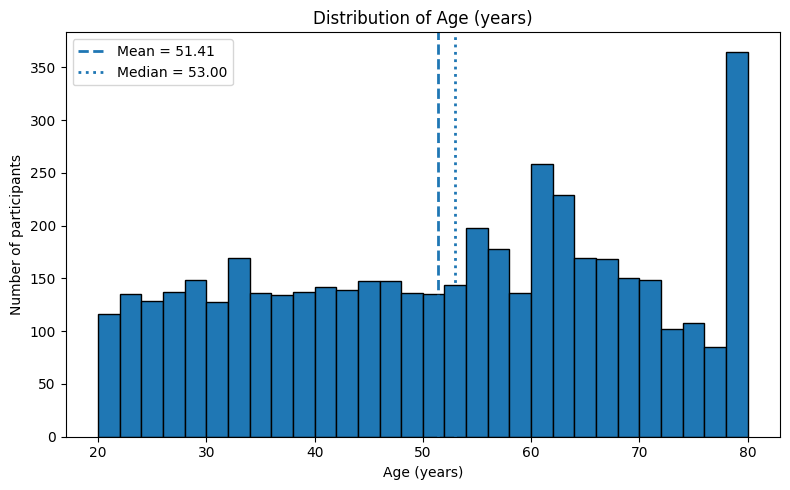

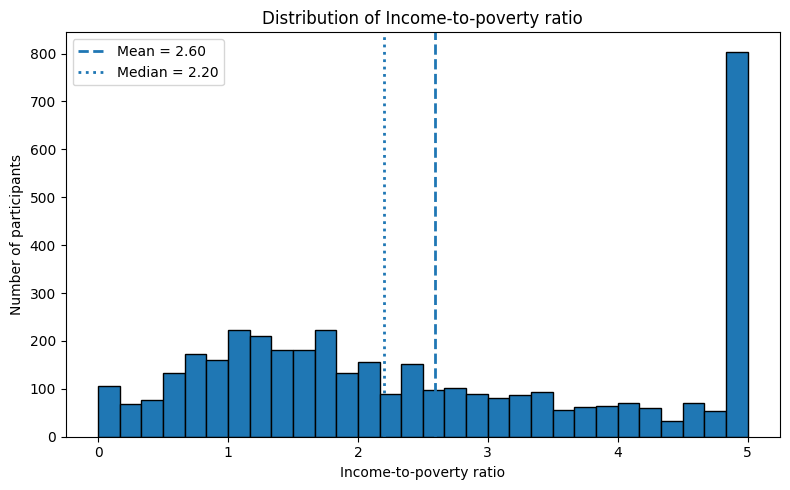

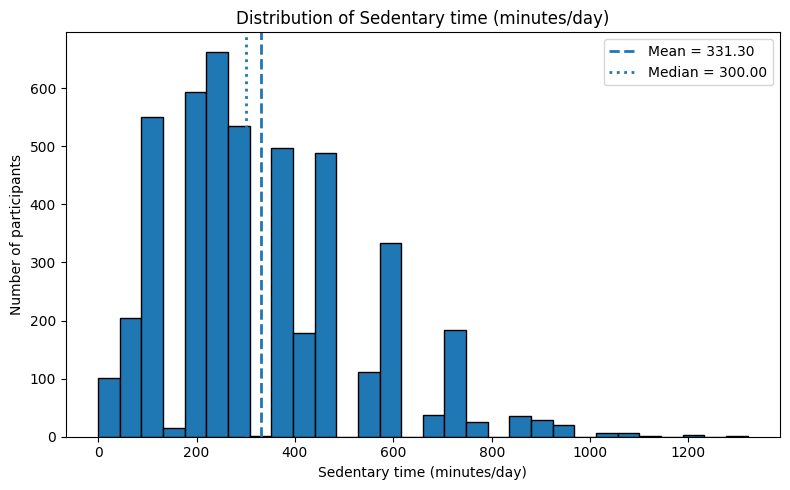

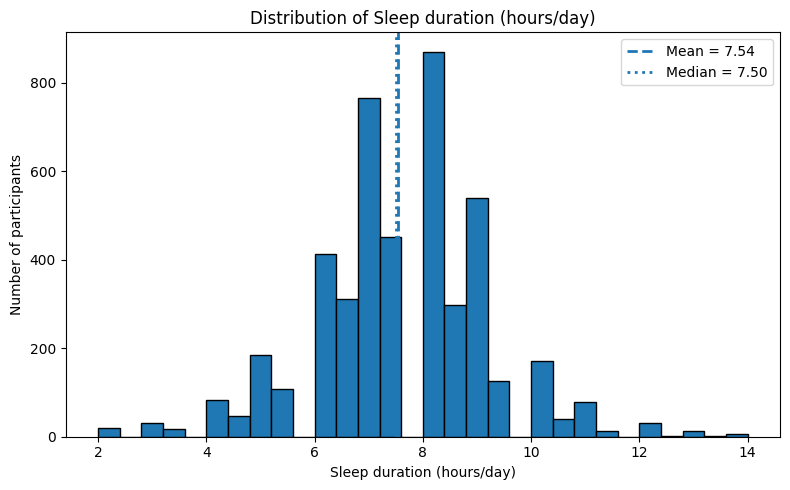

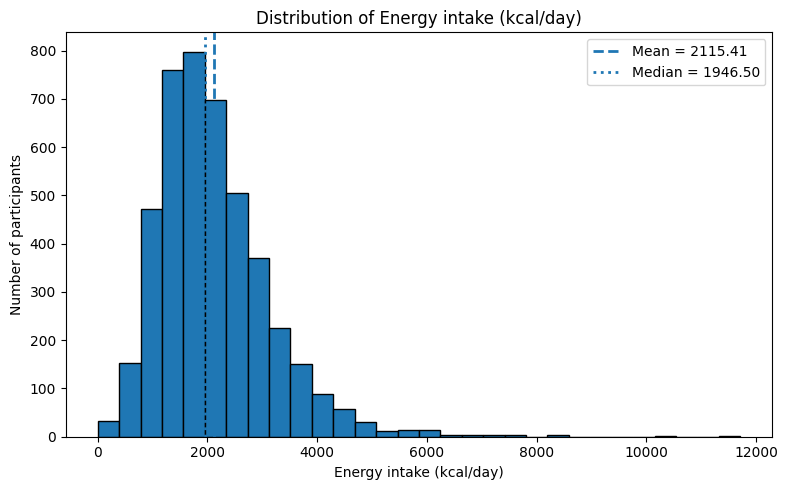

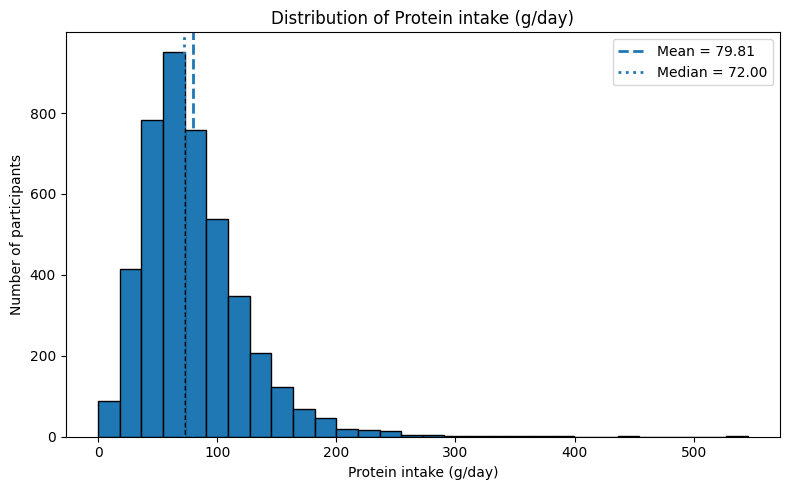

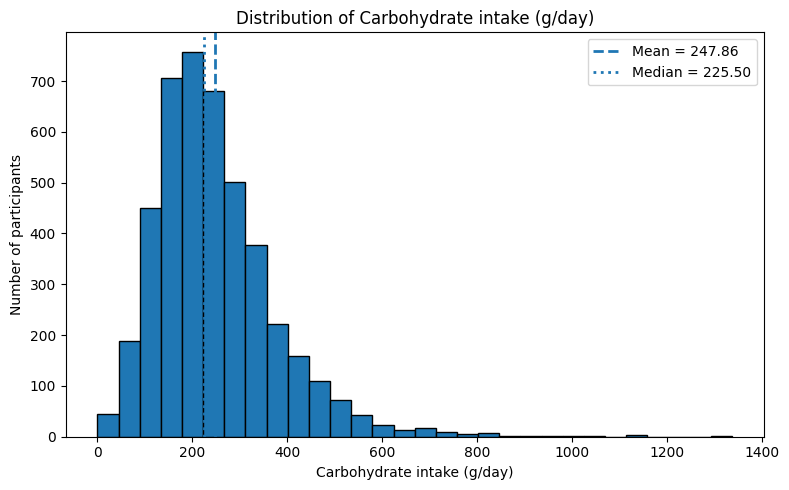

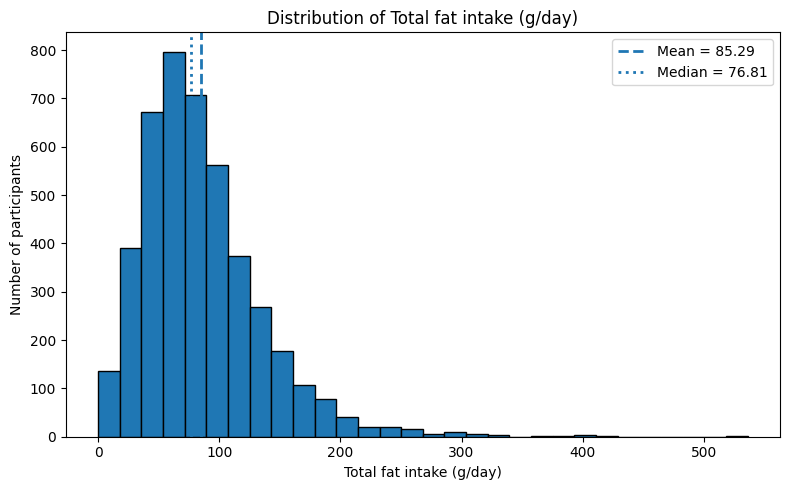

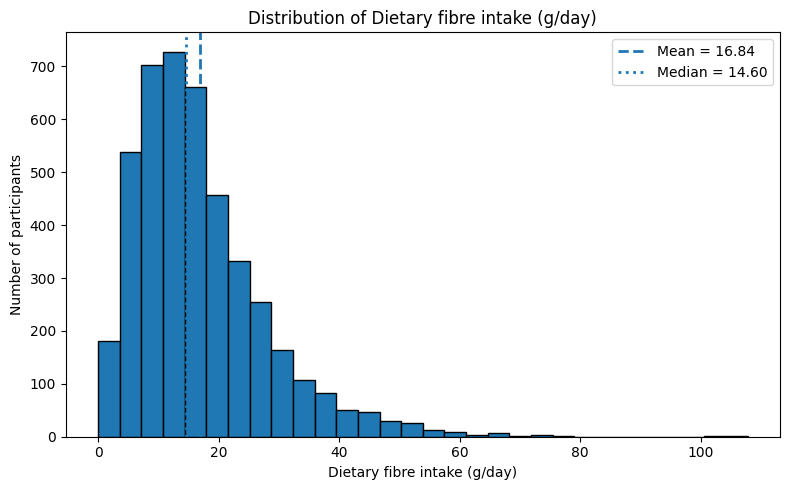

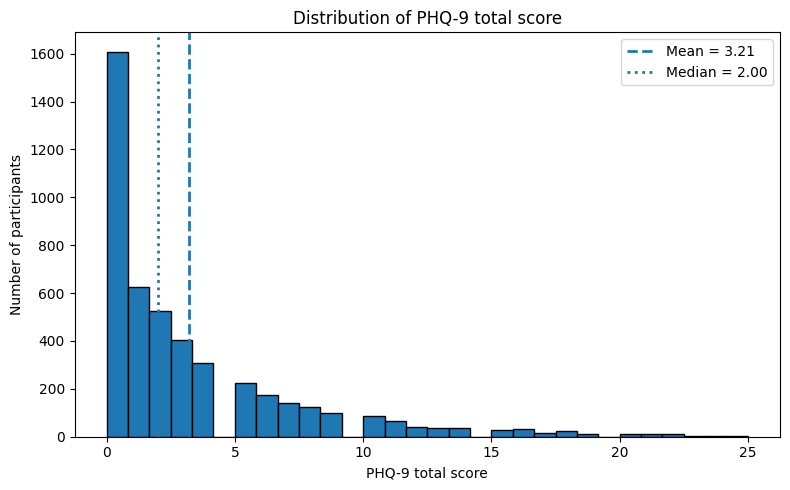

In [32]:
# ============================================================
# STEP 4E: HISTOGRAMS
# ============================================================

for var in continuous_eda_vars:

    data = eda_df[var].dropna()

    plt.figure(figsize=(8, 5))

    plt.hist(
        data,
        bins=30,
        edgecolor="black"
    )

    plt.axvline(
        data.mean(),
        linestyle="--",
        linewidth=2,
        label=f"Mean = {data.mean():.2f}"
    )

    plt.axvline(
        data.median(),
        linestyle=":",
        linewidth=2,
        label=f"Median = {data.median():.2f}"
    )

    plt.xlabel(continuous_labels[var])
    plt.ylabel("Number of participants")
    plt.title(f"Distribution of {continuous_labels[var]}")
    plt.legend()

    plt.tight_layout()

    safe_name = var.replace("/", "_")

    plt.savefig(
        f"EDA_Histogram_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


4F. IQR-BASED POTENTIAL OUTLIER DIAGNOSTICS


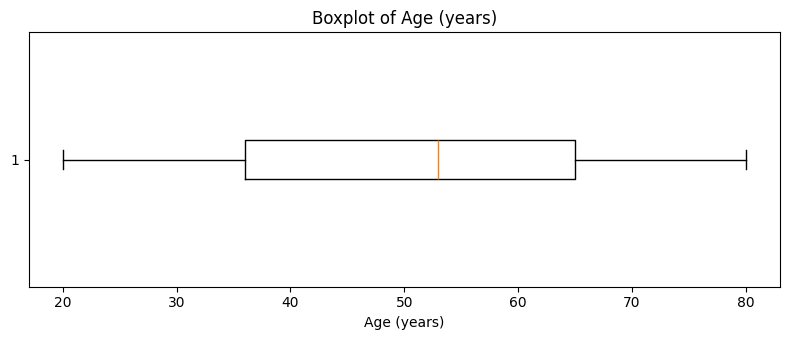

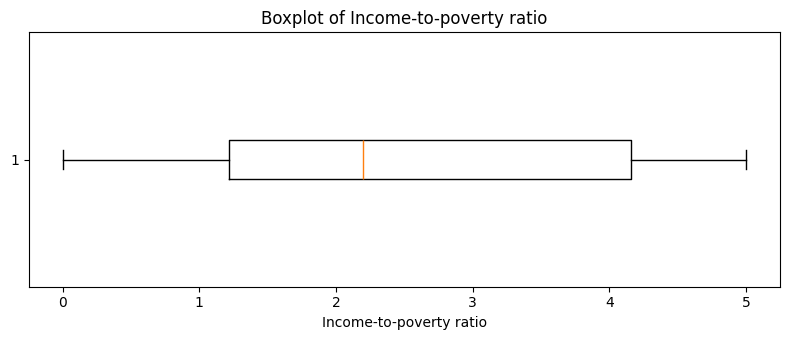

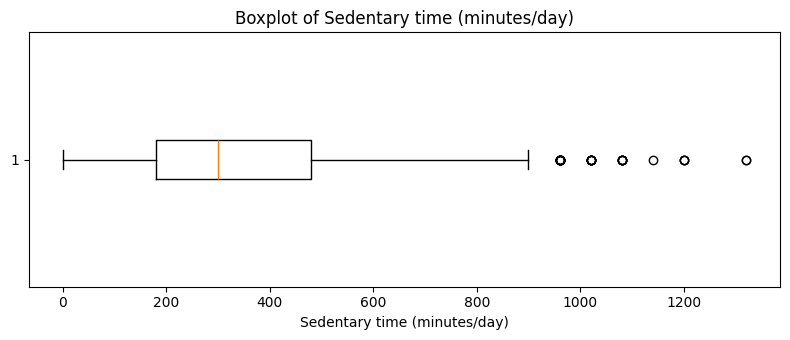

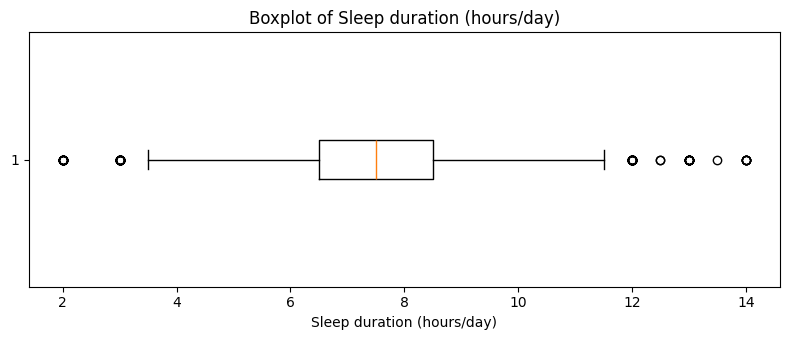

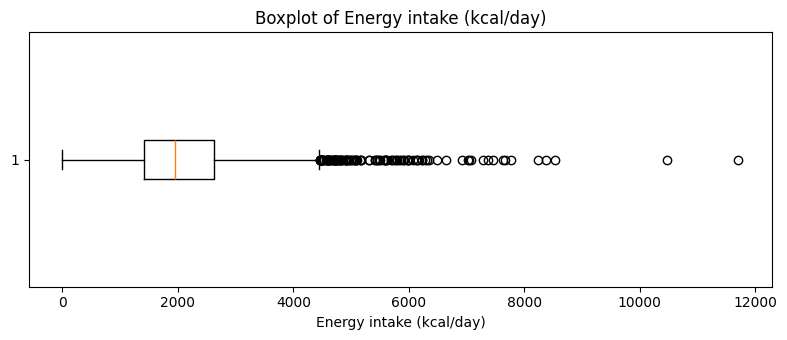

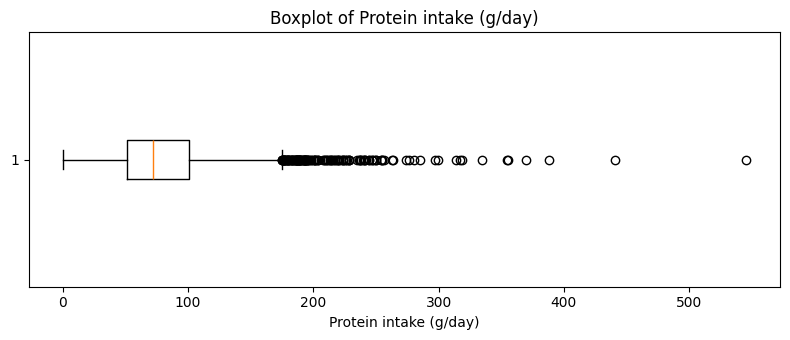

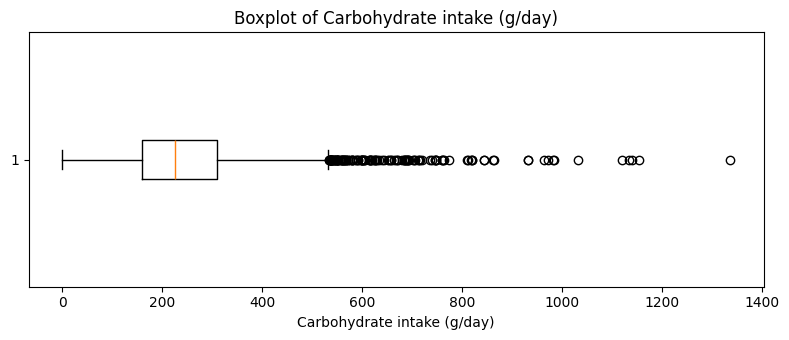

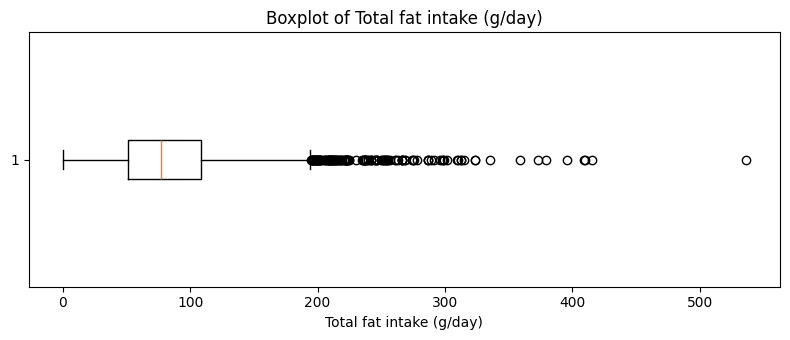

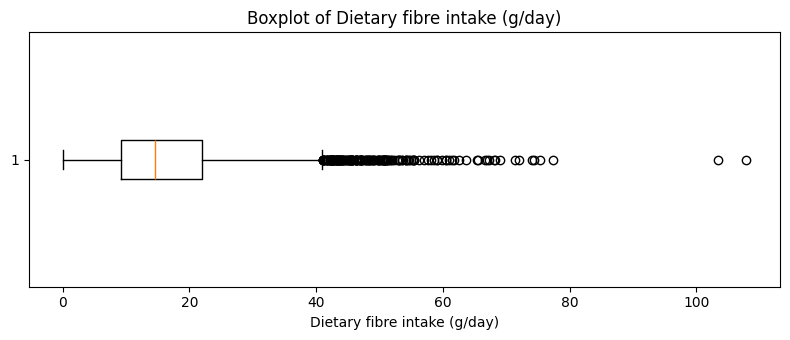

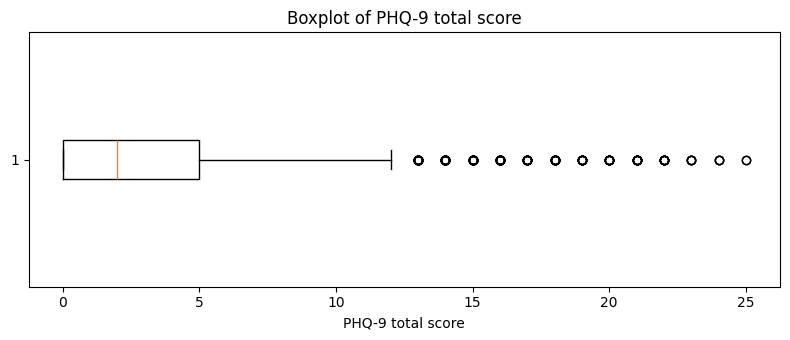

                    Variable      Q1      Q3     IQR  Lower_IQR_Bound  Upper_IQR_Bound  Potential_Outlier_N  Potential_Outlier_%
                 Age (years)   36.00   65.00   29.00            -7.50           108.50                    0                 0.00
     Income-to-poverty ratio    1.22    4.16    2.94            -3.19             8.57                    0                 0.00
Sedentary time (minutes/day)  180.00  480.00  300.00          -270.00           930.00                   40                 0.87
  Sleep duration (hours/day)    6.50    8.50    2.00             3.50            11.50                  106                 2.29
    Energy intake (kcal/day) 1414.00 2631.00 1217.00          -411.50          4456.50                  120                 2.73
      Protein intake (g/day)   50.91  100.53   49.62           -23.52           174.96                  138                 3.14
 Carbohydrate intake (g/day)  160.70  309.51  148.81           -62.52           532.73           

In [33]:
# ============================================================
# STEP 4F: OUTLIER ANALYSIS
# ============================================================

print("\n" + "=" * 85)
print("4F. IQR-BASED POTENTIAL OUTLIER DIAGNOSTICS")
print("=" * 85)

outlier_results = []

for var in continuous_eda_vars:

    s = eda_df[var].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = s[
        (s < lower_bound) |
        (s > upper_bound)
    ]

    outlier_results.append({
        "Variable": continuous_labels[var],
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_IQR_Bound": lower_bound,
        "Upper_IQR_Bound": upper_bound,
        "Potential_Outlier_N": len(outliers),
        "Potential_Outlier_%": len(outliers) / len(s) * 100
    })


    # Separate boxplot for every variable
    plt.figure(figsize=(8, 3.5))

    plt.boxplot(
        s,
        vert=False
    )

    plt.xlabel(continuous_labels[var])
    plt.title(
        f"Boxplot of {continuous_labels[var]}"
    )

    plt.tight_layout()

    plt.savefig(
        f"EDA_Boxplot_{var}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


outlier_table = pd.DataFrame(outlier_results)

print(
    outlier_table
    .round(2)
    .to_string(index=False)
)

outlier_table.to_csv(
    "EDA_Table_Potential_Outliers.csv",
    index=False
)

In [34]:
# ============================================================
# STEP 4G: CATEGORICAL DISTRIBUTIONS
# ============================================================

categorical_eda_vars = {
    "SEX": "Sex",
    "AGE_GROUP": "Age group",
    "RACE_ETHNICITY": "Race / ethnicity",
    "EDUCATION": "Education",
    "MARITAL_STATUS": "Marital status",
    "VIGOROUS_WORK": "Vigorous work activity",
    "MODERATE_WORK": "Moderate work activity",
    "VIGOROUS_RECREATION": "Vigorous recreational activity",
    "MODERATE_RECREATION": "Moderate recreational activity",
    "SLEEP_CATEGORY": "Sleep category",
    "PHQ9_SEVERITY": "PHQ-9 severity"
}

categorical_distribution_tables = {}

for var, label in categorical_eda_vars.items():

    counts = eda_df[var].value_counts(
        dropna=False,
        sort=False
    )

    percents = eda_df[var].value_counts(
        dropna=False,
        normalize=True,
        sort=False
    ) * 100

    table = pd.DataFrame({
        "N": counts,
        "Percent": percents
    })

    categorical_distribution_tables[var] = table

    print("\n" + "-" * 80)
    print(label.upper())
    print("-" * 80)
    print(table.round(2))

    table.to_csv(
        f"EDA_Distribution_{var}.csv"
    )


--------------------------------------------------------------------------------
SEX
--------------------------------------------------------------------------------
           N  Percent
SEX                  
Female  2360    50.68
Male    2297    49.32

--------------------------------------------------------------------------------
AGE GROUP
--------------------------------------------------------------------------------
                N  Percent
AGE_GROUP                 
20–39 years  1370    29.42
40–59 years  1504    32.30
60–80 years  1783    38.29

--------------------------------------------------------------------------------
RACE / ETHNICITY
--------------------------------------------------------------------------------
                        N  Percent
RACE_ETHNICITY                    
Non-Hispanic Black   1090    23.41
Non-Hispanic Asian    628    13.49
Non-Hispanic White   1643    35.28
Other / Multiracial   242     5.20
Mexican American      626    13.44
Other Hispan

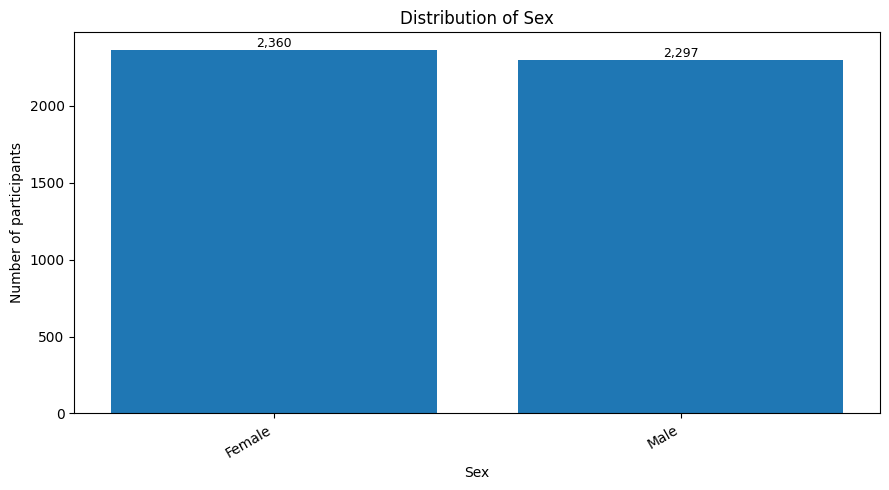

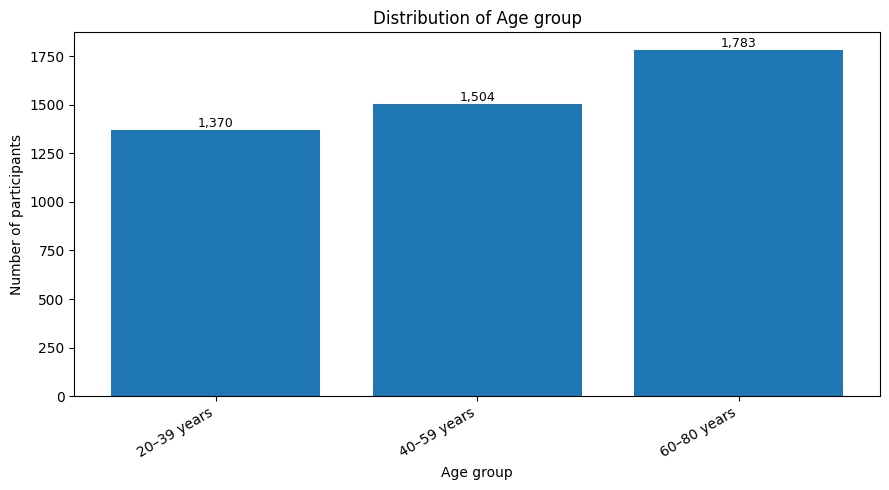

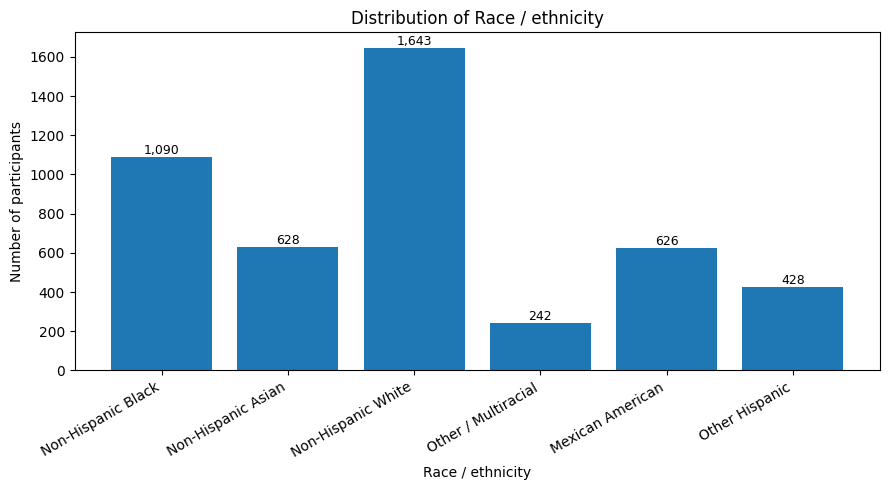

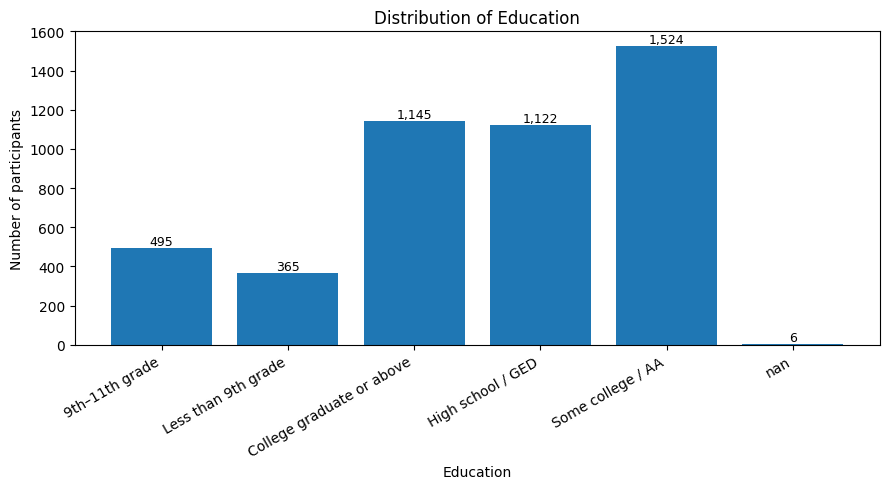

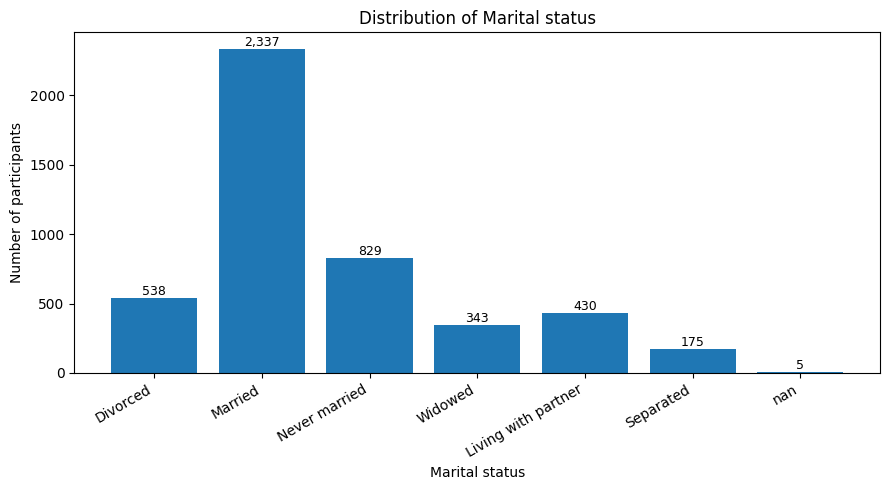

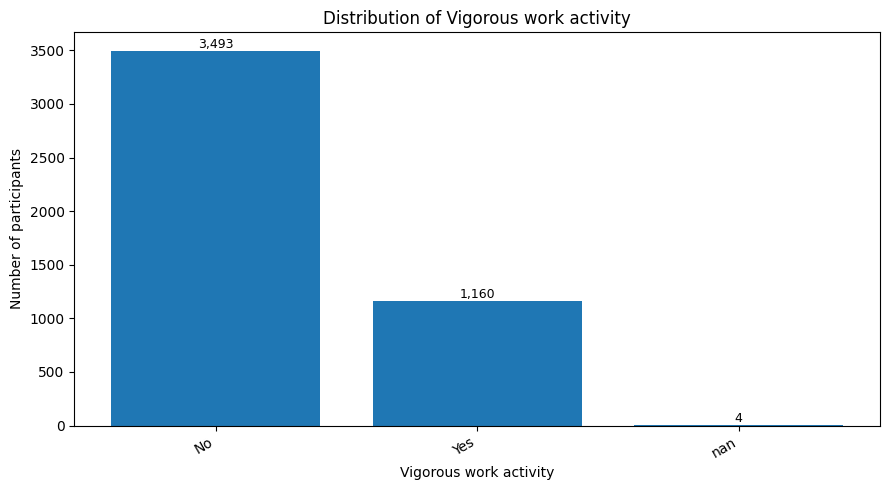

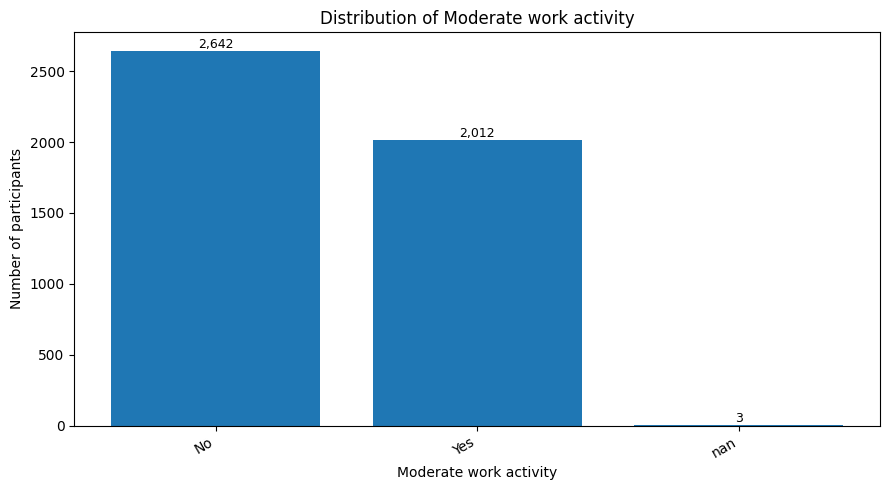

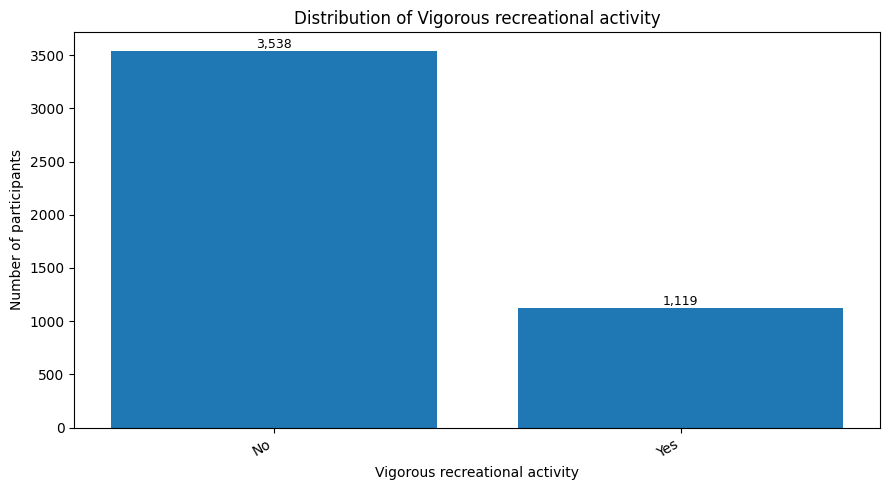

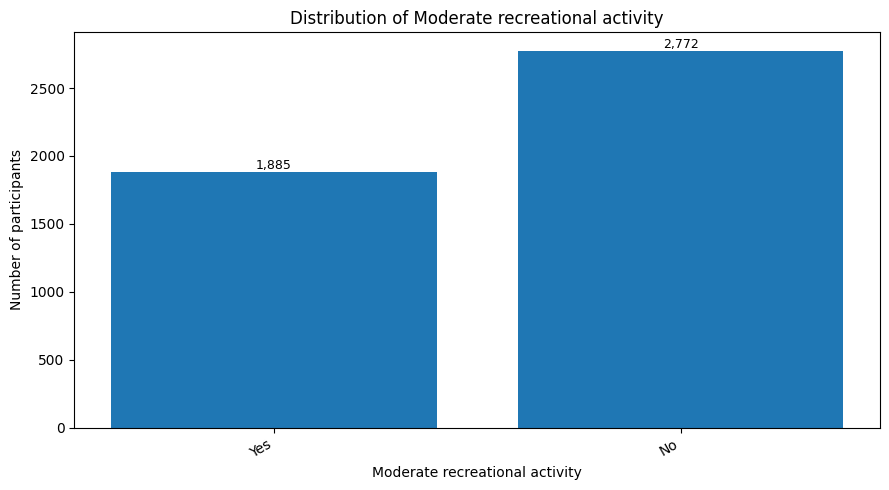

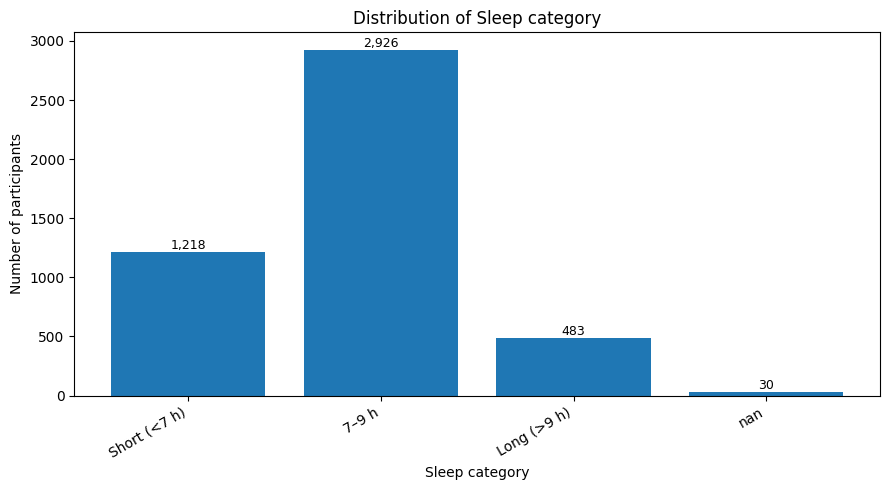

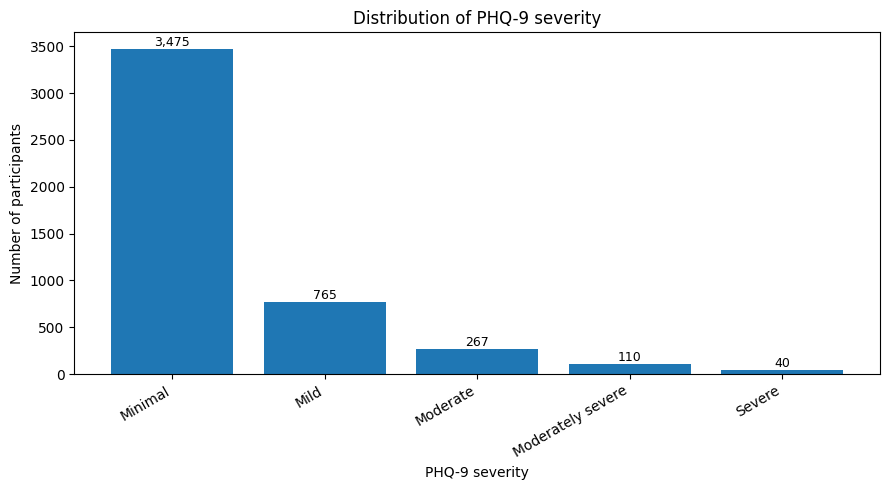

In [35]:
# ============================================================
# STEP 4H: CATEGORICAL DISTRIBUTION FIGURES
# ============================================================

for var, label in categorical_eda_vars.items():

    counts = eda_df[var].value_counts(
        dropna=False,
        sort=False
    )

    plt.figure(figsize=(9, 5))

    bars = plt.bar(
        counts.index.astype(str),
        counts.values
    )

    plt.xlabel(label)
    plt.ylabel("Number of participants")
    plt.title(f"Distribution of {label}")

    plt.xticks(
        rotation=30,
        ha="right"
    )

    for bar, value in zip(bars, counts.values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            value,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()

    plt.savefig(
        f"EDA_Bar_{var}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


4I. HEALTHY-WEIGHT OUTCOME DISTRIBUTION
                         N  Percent
WEIGHT_STATUS                      
Above healthy weight  3523    75.65
Healthy weight        1134    24.35


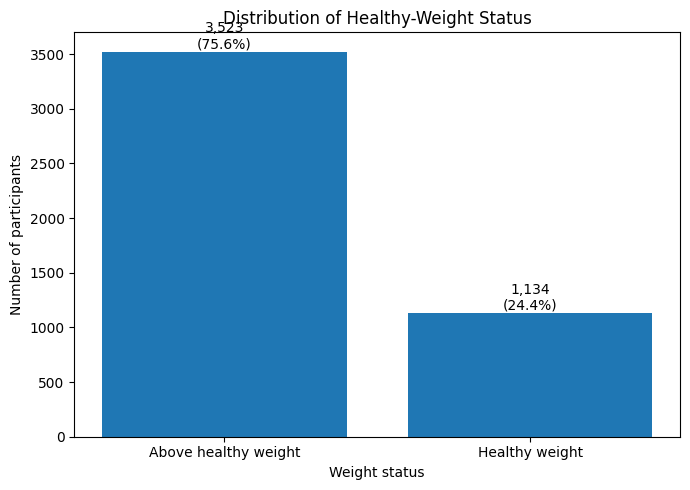

In [36]:
# ============================================================
# STEP 4I: OUTCOME DISTRIBUTION
# ============================================================

outcome_counts = (
    eda_df["WEIGHT_STATUS"]
    .value_counts()
)

outcome_pct = (
    eda_df["WEIGHT_STATUS"]
    .value_counts(normalize=True)
    * 100
)

outcome_table = pd.DataFrame({
    "N": outcome_counts,
    "Percent": outcome_pct
})

print("\n" + "=" * 85)
print("4I. HEALTHY-WEIGHT OUTCOME DISTRIBUTION")
print("=" * 85)

print(outcome_table.round(2))


plt.figure(figsize=(7, 5))

bars = plt.bar(
    outcome_table.index,
    outcome_table["N"]
)

for bar, n, pct in zip(
    bars,
    outcome_table["N"],
    outcome_table["Percent"]
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{n:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.ylabel("Number of participants")
plt.xlabel("Weight status")
plt.title("Distribution of Healthy-Weight Status")

plt.tight_layout()

plt.savefig(
    "EDA_Figure_Healthy_Weight_Status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

outcome_table.to_csv(
    "EDA_Table_Healthy_Weight_Status.csv"
)

In [37]:
# ============================================================
# STEP 4J: CONTINUOUS VARIABLES BY HEALTHY-WEIGHT STATUS
# ============================================================

grouped_continuous_rows = []

for var in continuous_eda_vars:

    for status_value, status_name in [
        (0, "Above healthy weight"),
        (1, "Healthy weight")
    ]:

        s = eda_df.loc[
            eda_df["HEALTHY_WEIGHT"] == status_value,
            var
        ].dropna()

        grouped_continuous_rows.append({
            "Variable": continuous_labels[var],
            "Weight_Status": status_name,
            "N": len(s),
            "Mean": s.mean(),
            "SD": s.std(),
            "Median": s.median(),
            "Q1": s.quantile(0.25),
            "Q3": s.quantile(0.75)
        })


continuous_by_weight = pd.DataFrame(
    grouped_continuous_rows
)

print("\n" + "=" * 85)
print("4J. CONTINUOUS VARIABLES BY HEALTHY-WEIGHT STATUS")
print("=" * 85)

print(
    continuous_by_weight
    .round(2)
    .to_string(index=False)
)

continuous_by_weight.to_csv(
    "EDA_Table_Continuous_by_Healthy_Weight.csv",
    index=False
)


4J. CONTINUOUS VARIABLES BY HEALTHY-WEIGHT STATUS
                    Variable        Weight_Status    N    Mean      SD  Median      Q1      Q3
                 Age (years) Above healthy weight 3523   52.20   16.79   54.00   38.00   65.00
                 Age (years)       Healthy weight 1134   48.95   18.91   49.00   31.00   64.00
     Income-to-poverty ratio Above healthy weight 3073    2.59    1.59    2.22    1.22    4.10
     Income-to-poverty ratio       Healthy weight 1011    2.62    1.66    2.16    1.18    4.30
Sedentary time (minutes/day) Above healthy weight 3497  337.44  202.84  300.00  180.00  480.00
Sedentary time (minutes/day)       Healthy weight 1127  312.25  193.28  240.00  180.00  480.00
  Sleep duration (hours/day) Above healthy weight 3500    7.50    1.63    7.50    6.50    8.50
  Sleep duration (hours/day)       Healthy weight 1127    7.66    1.61    8.00    7.00    8.50
    Energy intake (kcal/day) Above healthy weight 3331 2117.30  995.15 1954.00 1438.00 2641.00

/tmp/ipykernel_918/2069671123.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


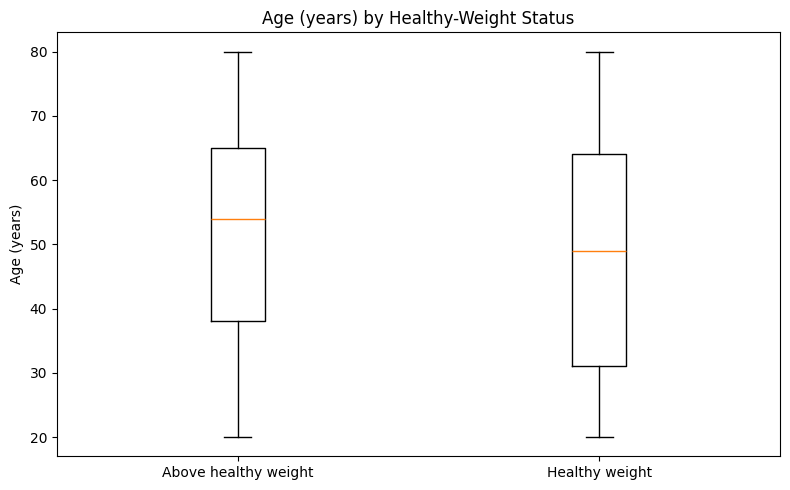

/tmp/ipykernel_918/2069671123.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


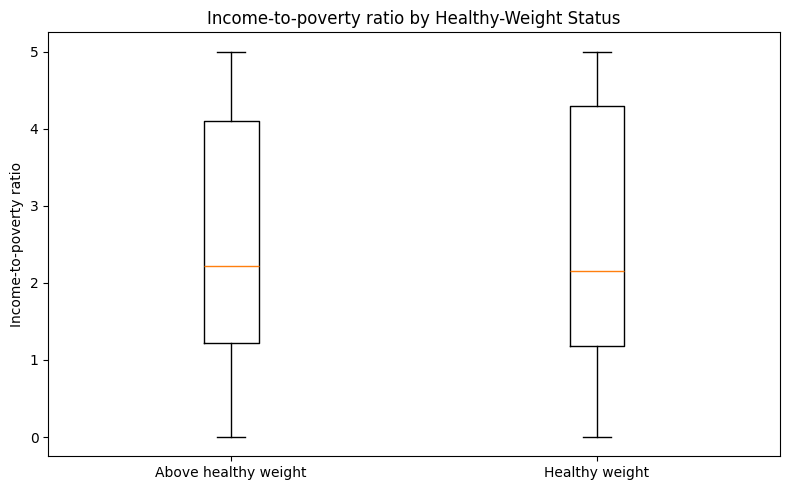

/tmp/ipykernel_918/2069671123.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


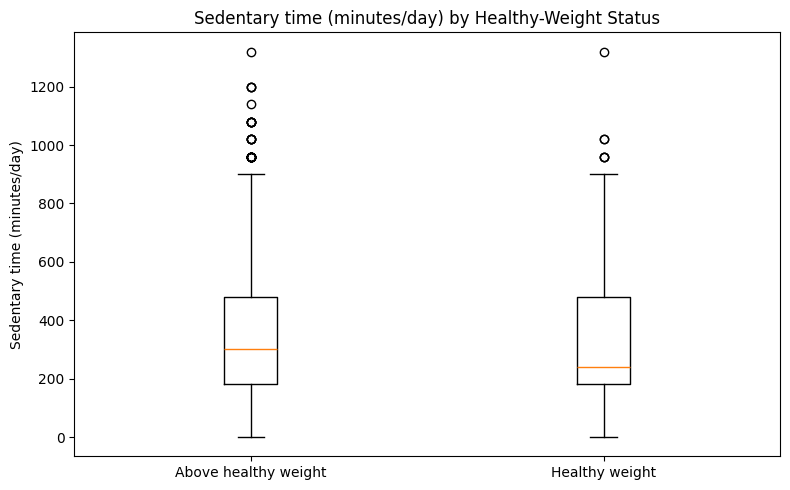

/tmp/ipykernel_918/2069671123.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


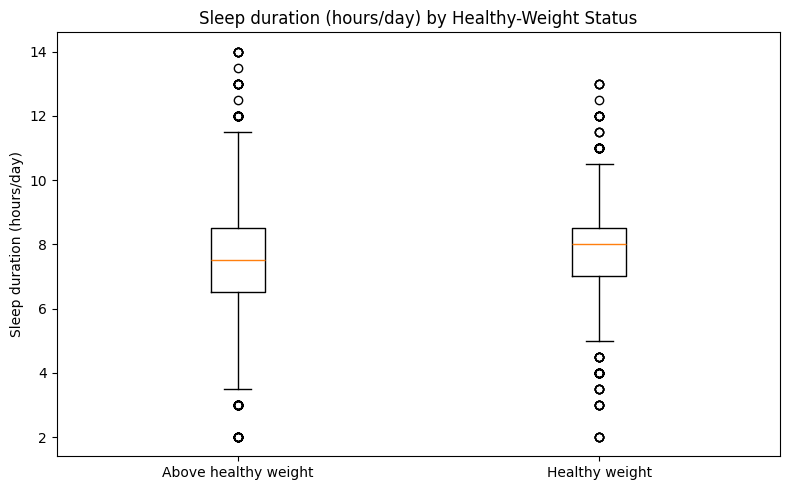

/tmp/ipykernel_918/2069671123.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


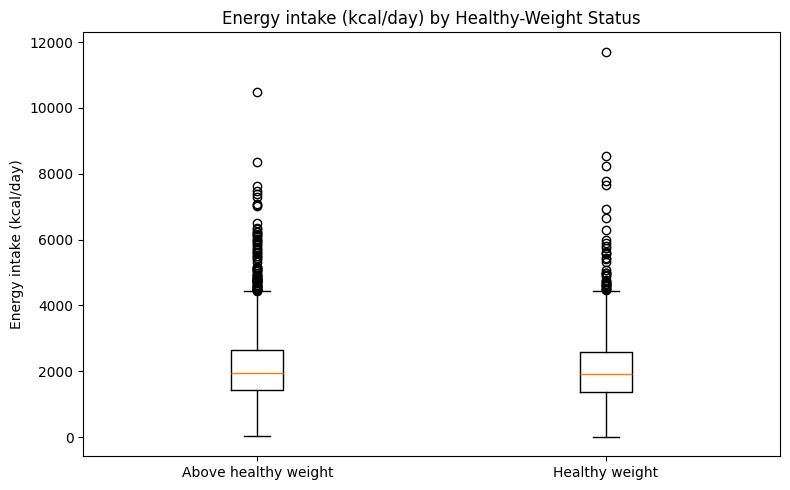

/tmp/ipykernel_918/2069671123.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


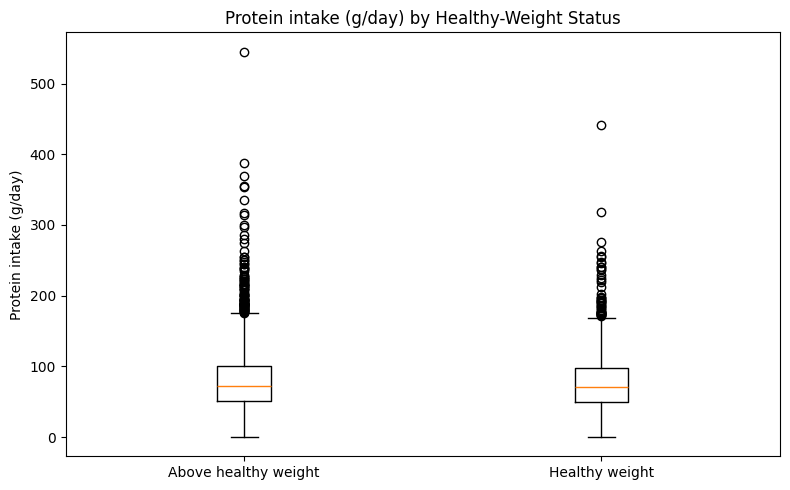

/tmp/ipykernel_918/2069671123.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


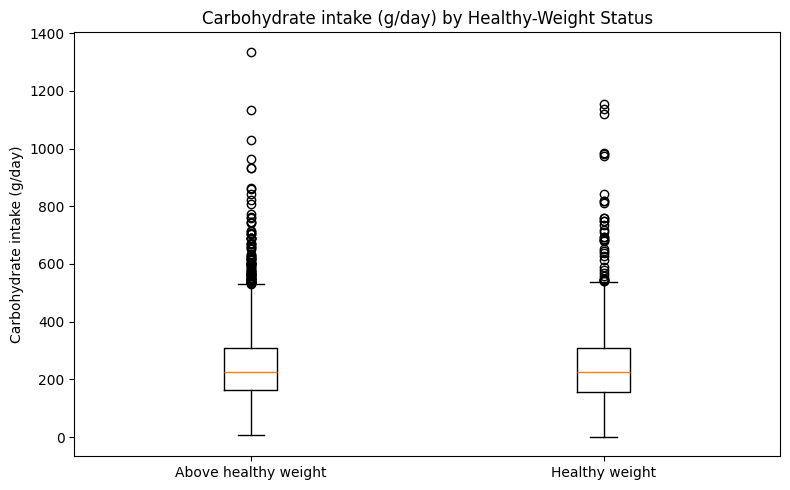

/tmp/ipykernel_918/2069671123.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


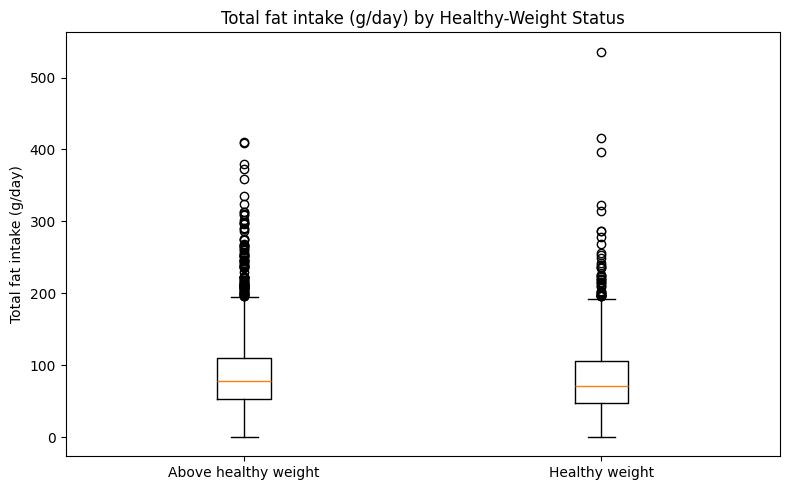

/tmp/ipykernel_918/2069671123.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


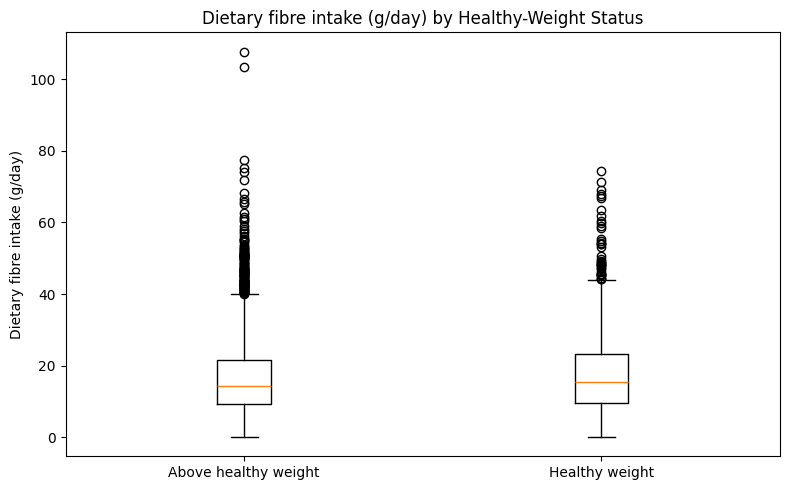

/tmp/ipykernel_918/2069671123.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


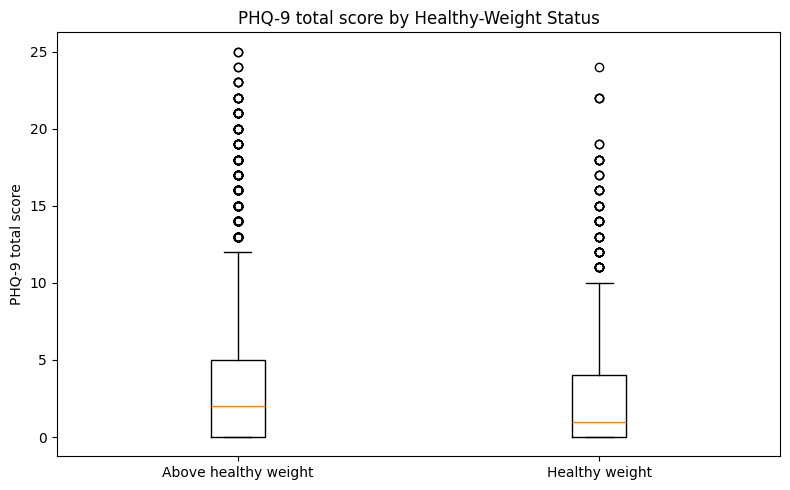

In [38]:
# ============================================================
# STEP 4K: CONTINUOUS PREDICTORS VS HEALTHY-WEIGHT STATUS
# ============================================================

for var in continuous_eda_vars:

    unhealthy = eda_df.loc[
        eda_df["HEALTHY_WEIGHT"] == 0,
        var
    ].dropna()

    healthy = eda_df.loc[
        eda_df["HEALTHY_WEIGHT"] == 1,
        var
    ].dropna()

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        [unhealthy, healthy],
        labels=[
            "Above healthy weight",
            "Healthy weight"
        ]
    )

    plt.ylabel(continuous_labels[var])

    plt.title(
        f"{continuous_labels[var]} by Healthy-Weight Status"
    )

    plt.tight_layout()

    plt.savefig(
        f"EDA_Boxplot_{var}_by_Healthy_Weight.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [39]:
# ============================================================
# STEP 4L: HEALTHY-WEIGHT PREVALENCE BY CATEGORICAL VARIABLES
# ============================================================

categorical_weight_results = {}

for var, label in categorical_eda_vars.items():

    if var == "PHQ9_SEVERITY":
        pass

    table = pd.crosstab(
        eda_df[var],
        eda_df["WEIGHT_STATUS"],
        normalize="index"
    ) * 100

    categorical_weight_results[var] = table

    print("\n" + "-" * 80)
    print(f"HEALTHY-WEIGHT STATUS BY {label.upper()}")
    print("-" * 80)

    print(table.round(2))

    table.to_csv(
        f"EDA_HealthyWeight_by_{var}.csv"
    )


--------------------------------------------------------------------------------
HEALTHY-WEIGHT STATUS BY SEX
--------------------------------------------------------------------------------
WEIGHT_STATUS  Above healthy weight  Healthy weight
SEX                                                
Female                        74.28           25.72
Male                          77.06           22.94

--------------------------------------------------------------------------------
HEALTHY-WEIGHT STATUS BY AGE GROUP
--------------------------------------------------------------------------------
WEIGHT_STATUS  Above healthy weight  Healthy weight
AGE_GROUP                                          
20–39 years                   68.39           31.61
40–59 years                   79.26           20.74
60–80 years                   78.18           21.82

--------------------------------------------------------------------------------
HEALTHY-WEIGHT STATUS BY RACE / ETHNICITY
------------------

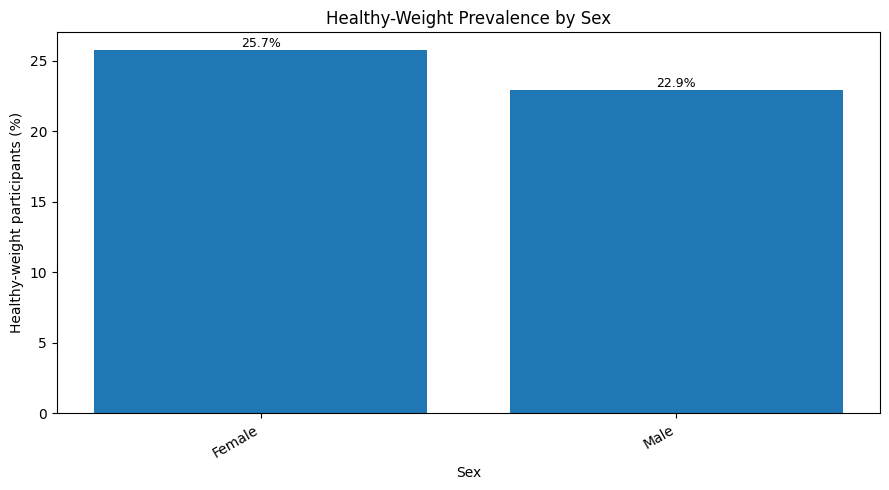

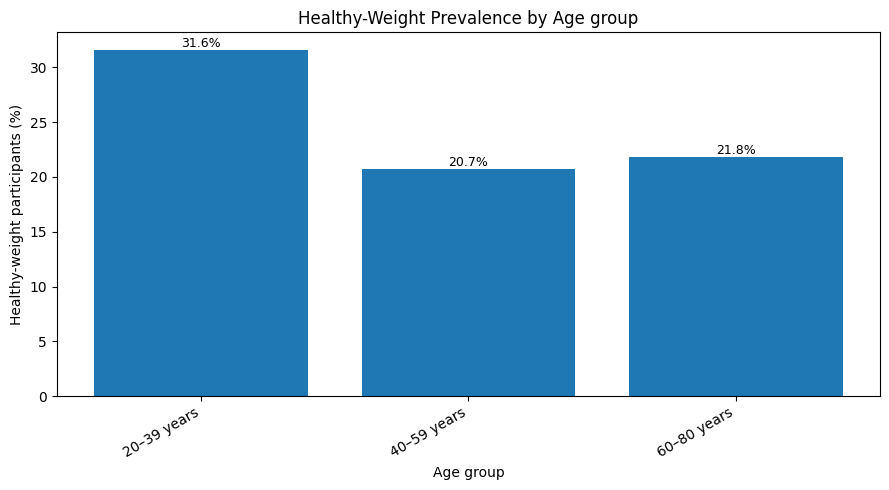

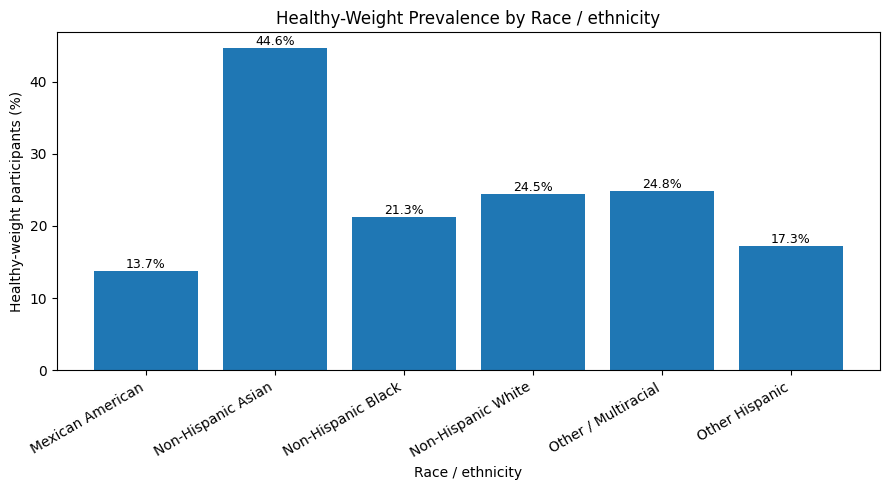

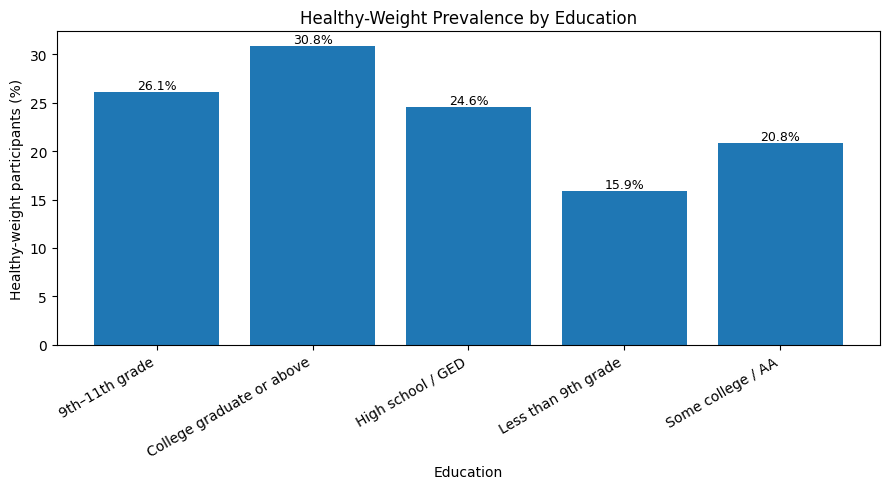

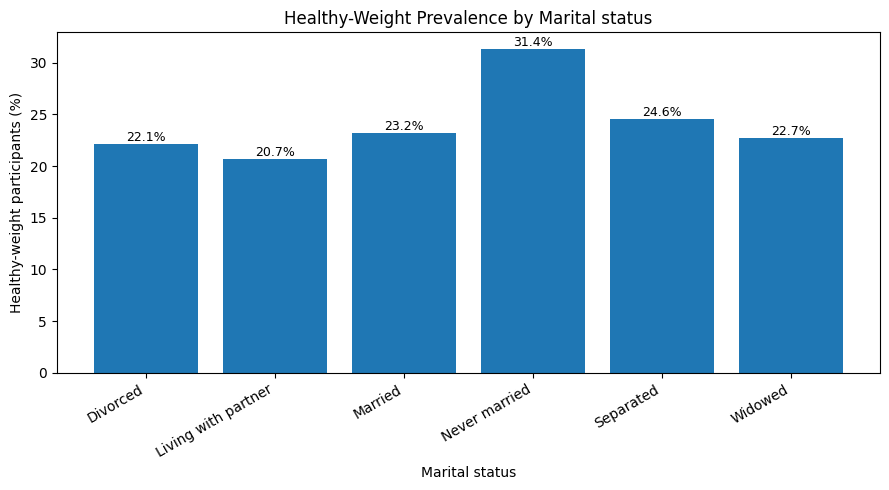

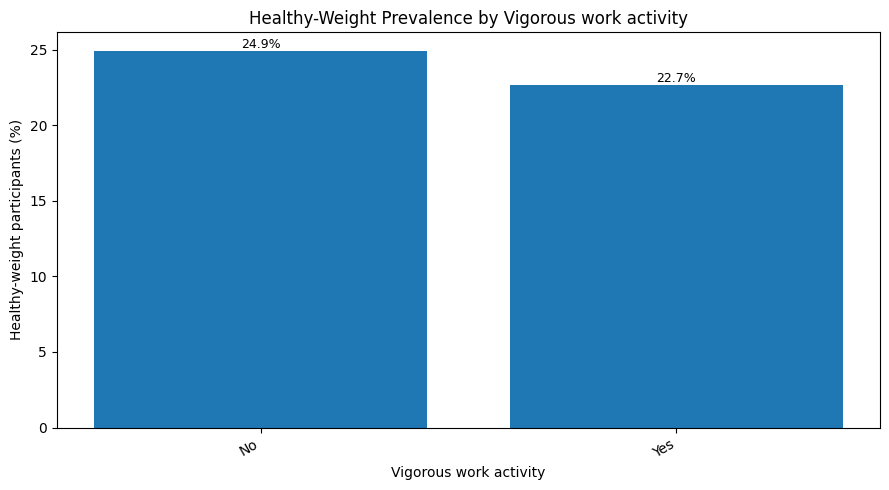

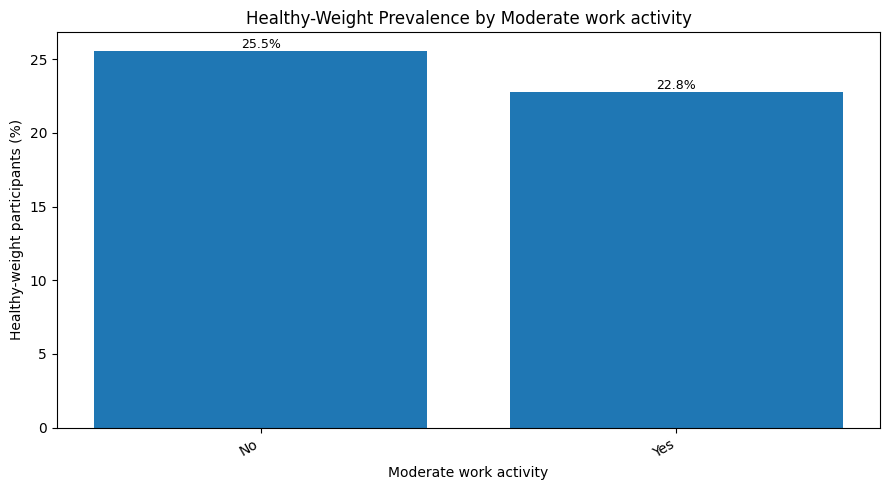

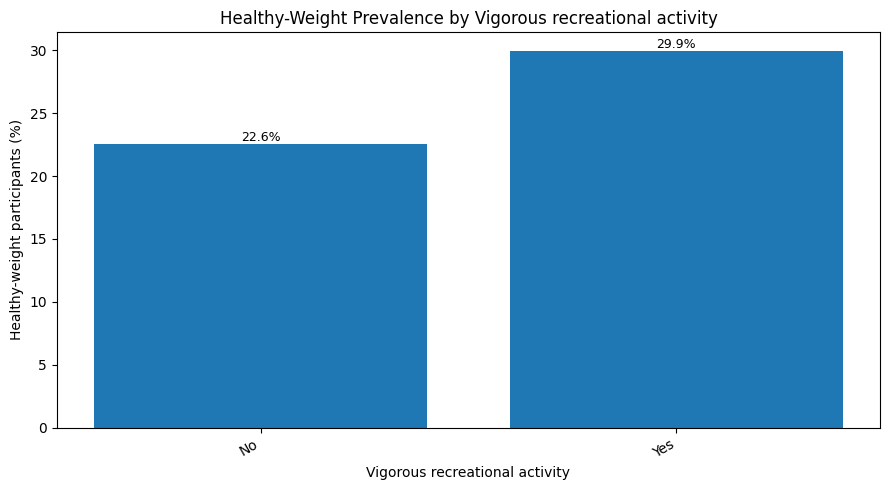

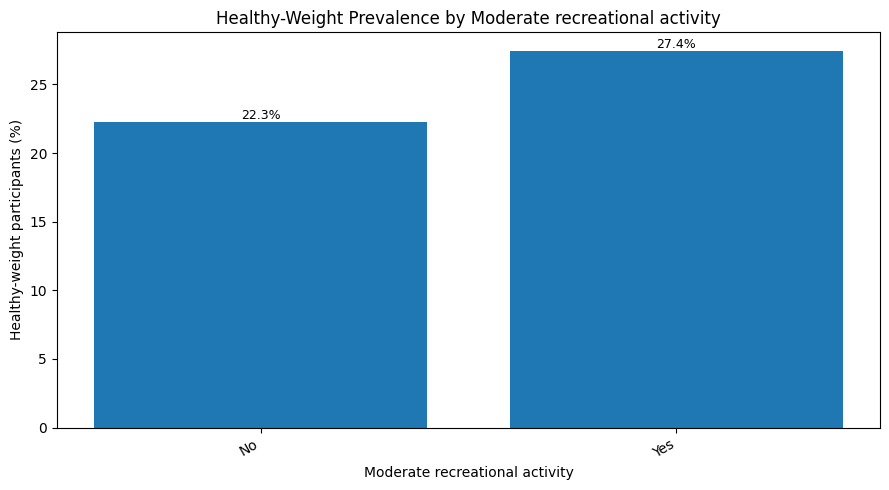

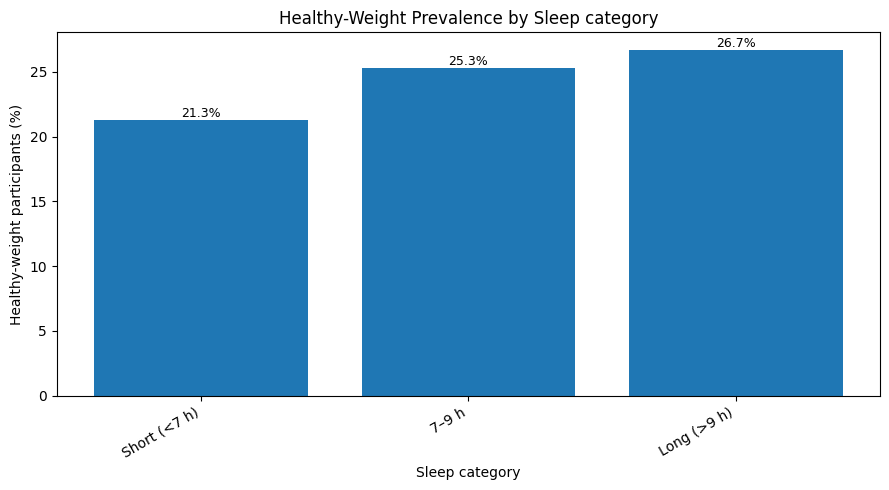

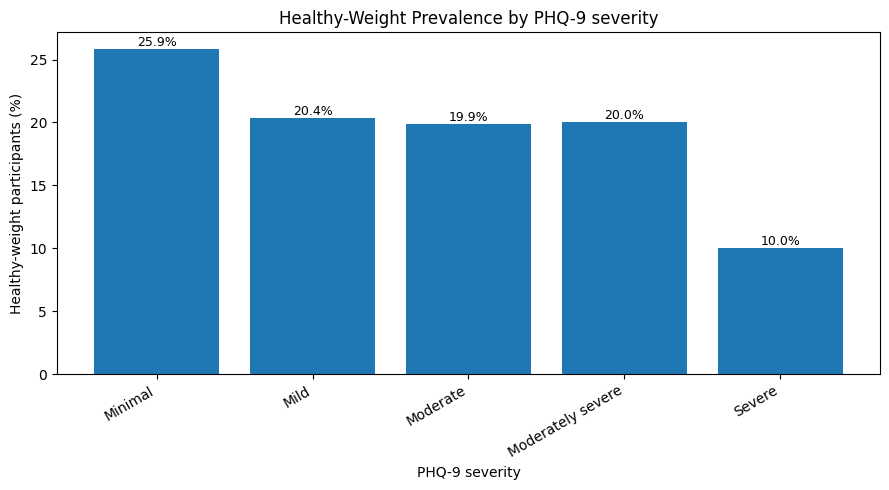

In [40]:
# ============================================================
# STEP 4M: HEALTHY-WEIGHT PERCENTAGE BY CATEGORICAL GROUP
# ============================================================

for var, label in categorical_eda_vars.items():

    grouped = (
        eda_df
        .groupby(var, observed=True)["HEALTHY_WEIGHT"]
        .mean()
        .mul(100)
    )

    plt.figure(figsize=(9, 5))

    bars = plt.bar(
        grouped.index.astype(str),
        grouped.values
    )

    plt.ylabel("Healthy-weight participants (%)")
    plt.xlabel(label)

    plt.title(
        f"Healthy-Weight Prevalence by {label}"
    )

    plt.xticks(
        rotation=30,
        ha="right"
    )

    for bar, value in zip(bars, grouped.values):

        plt.text(
            bar.get_x() + bar.get_width()/2,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()

    plt.savefig(
        f"EDA_HealthyWeight_Percent_by_{var}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [41]:
# ============================================================
# STEP 4N: PHQ-9 DEEP-DIVE EDA
# ============================================================

print("\n" + "=" * 85)
print("4N. PHQ-9 / DEPRESSION EXPLORATORY ANALYSIS")
print("=" * 85)


# PHQ distribution
print("\nPHQ-9 descriptive statistics:")
print(
    eda_df["PHQ9_TOTAL"]
    .describe()
    .round(2)
)


# Severity distribution
severity_table = pd.DataFrame({
    "N": eda_df["PHQ9_SEVERITY"].value_counts(
        sort=False
    ),
    "Percent": eda_df["PHQ9_SEVERITY"].value_counts(
        normalize=True,
        sort=False
    ) * 100
})

print("\nPHQ-9 severity categories:")
print(severity_table.round(2))


# PHQ by outcome
phq_by_weight = (
    eda_df
    .groupby(
        "WEIGHT_STATUS",
        observed=True
    )["PHQ9_TOTAL"]
    .agg(
        N="count",
        Mean="mean",
        SD="std",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
)

print("\nPHQ-9 by healthy-weight status:")
print(phq_by_weight.round(2))


# Healthy-weight prevalence by PHQ severity
phq_healthy_pct = (
    eda_df
    .groupby(
        "PHQ9_SEVERITY",
        observed=True
    )["HEALTHY_WEIGHT"]
    .agg(["count", "mean"])
)

phq_healthy_pct["Healthy_Weight_Percent"] = (
    phq_healthy_pct["mean"] * 100
)

print(
    "\nHealthy-weight prevalence "
    "by PHQ-9 severity:"
)

print(
    phq_healthy_pct[
        ["count", "Healthy_Weight_Percent"]
    ].round(2)
)


4N. PHQ-9 / DEPRESSION EXPLORATORY ANALYSIS

PHQ-9 descriptive statistics:
count    4657.00
mean        3.21
std         4.24
min         0.00
25%         0.00
50%         2.00
75%         5.00
max        25.00
Name: PHQ9_TOTAL, dtype: float64

PHQ-9 severity categories:
                      N  Percent
PHQ9_SEVERITY                   
Minimal            3475    74.62
Mild                765    16.43
Moderate            267     5.73
Moderately severe   110     2.36
Severe               40     0.86

PHQ-9 by healthy-weight status:
                         N  Mean    SD  Median  Minimum  Maximum
WEIGHT_STATUS                                                   
Above healthy weight  3523  3.35  4.35     2.0      0.0     25.0
Healthy weight        1134  2.79  3.82     1.0      0.0     24.0

Healthy-weight prevalence by PHQ-9 severity:
                   count  Healthy_Weight_Percent
PHQ9_SEVERITY                                   
Minimal             3475                   25.87
Mild      

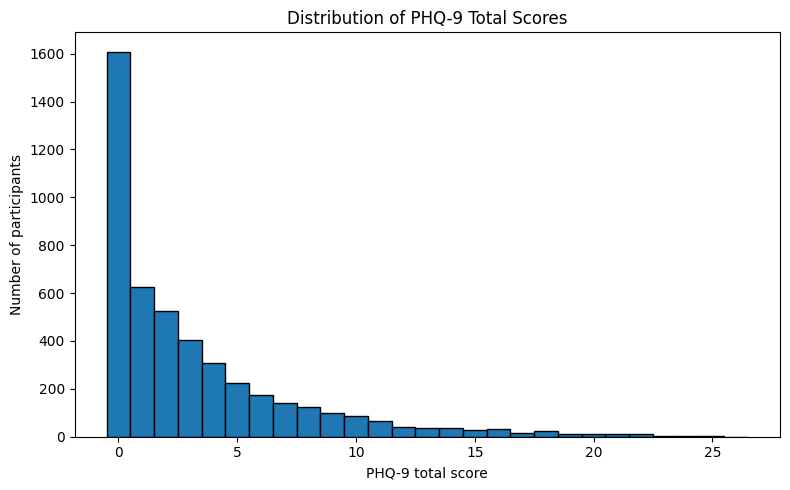

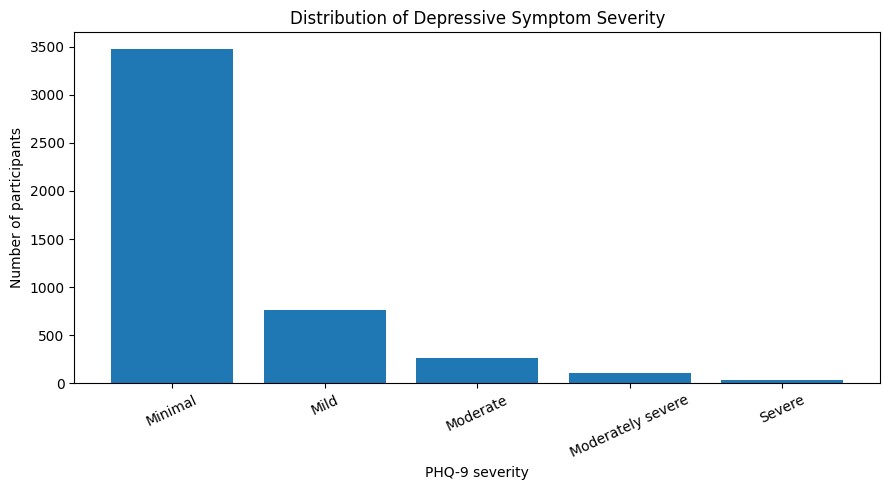

/tmp/ipykernel_918/2535537505.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


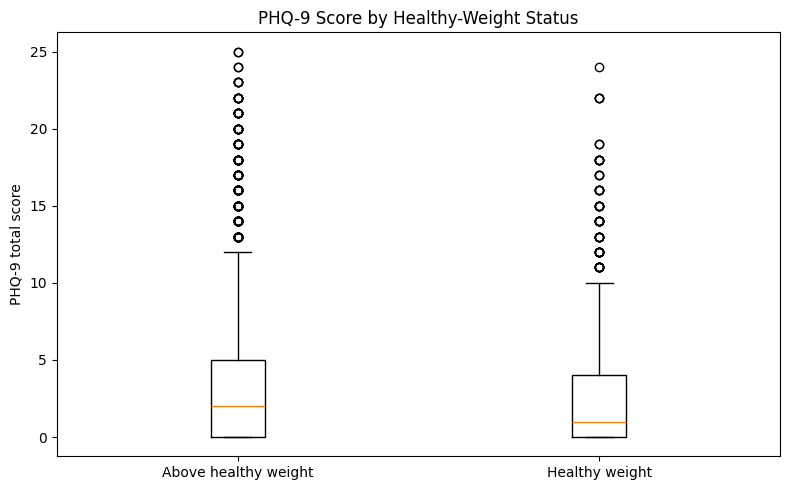

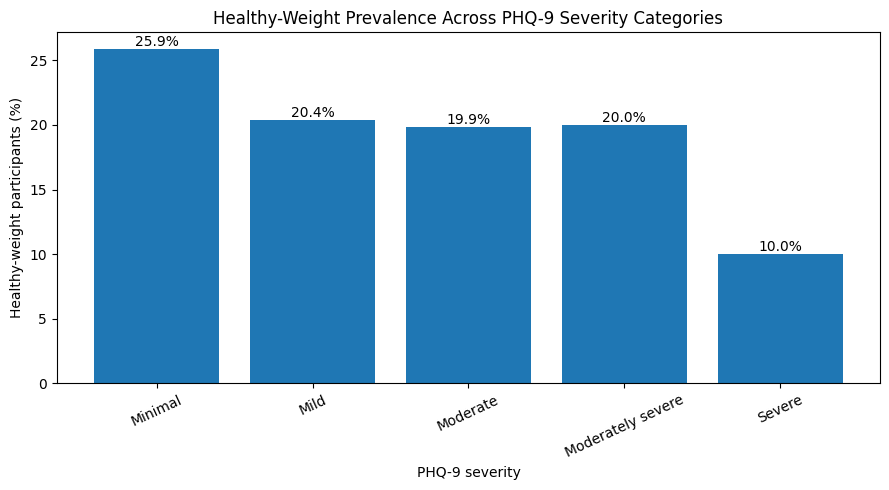

In [42]:
# PHQ-9 histogram
plt.figure(figsize=(8, 5))

plt.hist(
    eda_df["PHQ9_TOTAL"],
    bins=np.arange(-0.5, 27.5, 1),
    edgecolor="black"
)

plt.xlabel("PHQ-9 total score")
plt.ylabel("Number of participants")
plt.title("Distribution of PHQ-9 Total Scores")

plt.tight_layout()

plt.savefig(
    "EDA_PHQ9_Histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# PHQ severity
severity_counts = (
    eda_df["PHQ9_SEVERITY"]
    .value_counts(sort=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    severity_counts.index.astype(str),
    severity_counts.values
)

plt.xlabel("PHQ-9 severity")
plt.ylabel("Number of participants")
plt.title("Distribution of Depressive Symptom Severity")

plt.xticks(rotation=25)

plt.tight_layout()

plt.savefig(
    "EDA_PHQ9_Severity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# PHQ score by healthy weight
healthy_phq = eda_df.loc[
    eda_df["HEALTHY_WEIGHT"] == 1,
    "PHQ9_TOTAL"
]

unhealthy_phq = eda_df.loc[
    eda_df["HEALTHY_WEIGHT"] == 0,
    "PHQ9_TOTAL"
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [unhealthy_phq, healthy_phq],
    labels=[
        "Above healthy weight",
        "Healthy weight"
    ]
)

plt.ylabel("PHQ-9 total score")
plt.title(
    "PHQ-9 Score by Healthy-Weight Status"
)

plt.tight_layout()

plt.savefig(
    "EDA_PHQ9_by_Healthy_Weight.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Healthy-weight % by severity
healthy_by_severity = (
    eda_df
    .groupby(
        "PHQ9_SEVERITY",
        observed=True
    )["HEALTHY_WEIGHT"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    healthy_by_severity.index.astype(str),
    healthy_by_severity.values
)

plt.ylabel("Healthy-weight participants (%)")
plt.xlabel("PHQ-9 severity")

plt.title(
    "Healthy-Weight Prevalence "
    "Across PHQ-9 Severity Categories"
)

plt.xticks(rotation=25)

for bar, value in zip(
    bars,
    healthy_by_severity.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "EDA_HealthyWeight_by_PHQ9_Severity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


4P. PEARSON CORRELATION MATRIX
                RIDAGEYR  INDFMPIR  PAD680_CLEAN  SLD012  DR1TKCAL  DR1TPROT  \
RIDAGEYR           1.000     0.051         0.026   0.062    -0.143    -0.116   
INDFMPIR           0.051     1.000         0.169  -0.066     0.016     0.069   
PAD680_CLEAN       0.026     0.169         1.000  -0.022     0.028     0.005   
SLD012             0.062    -0.066        -0.022   1.000    -0.081    -0.084   
DR1TKCAL          -0.143     0.016         0.028  -0.081     1.000     0.781   
DR1TPROT          -0.116     0.069         0.005  -0.084     0.781     1.000   
DR1TCARB          -0.116    -0.043         0.016  -0.066     0.872     0.541   
DR1TTFAT          -0.102     0.041         0.047  -0.067     0.887     0.727   
DR1TFIBE           0.004     0.085        -0.026  -0.002     0.524     0.440   
PHQ9_TOTAL        -0.024    -0.189         0.040  -0.025    -0.003    -0.027   
HEALTHY_WEIGHT    -0.080     0.007        -0.054   0.042    -0.003    -0.015   

       

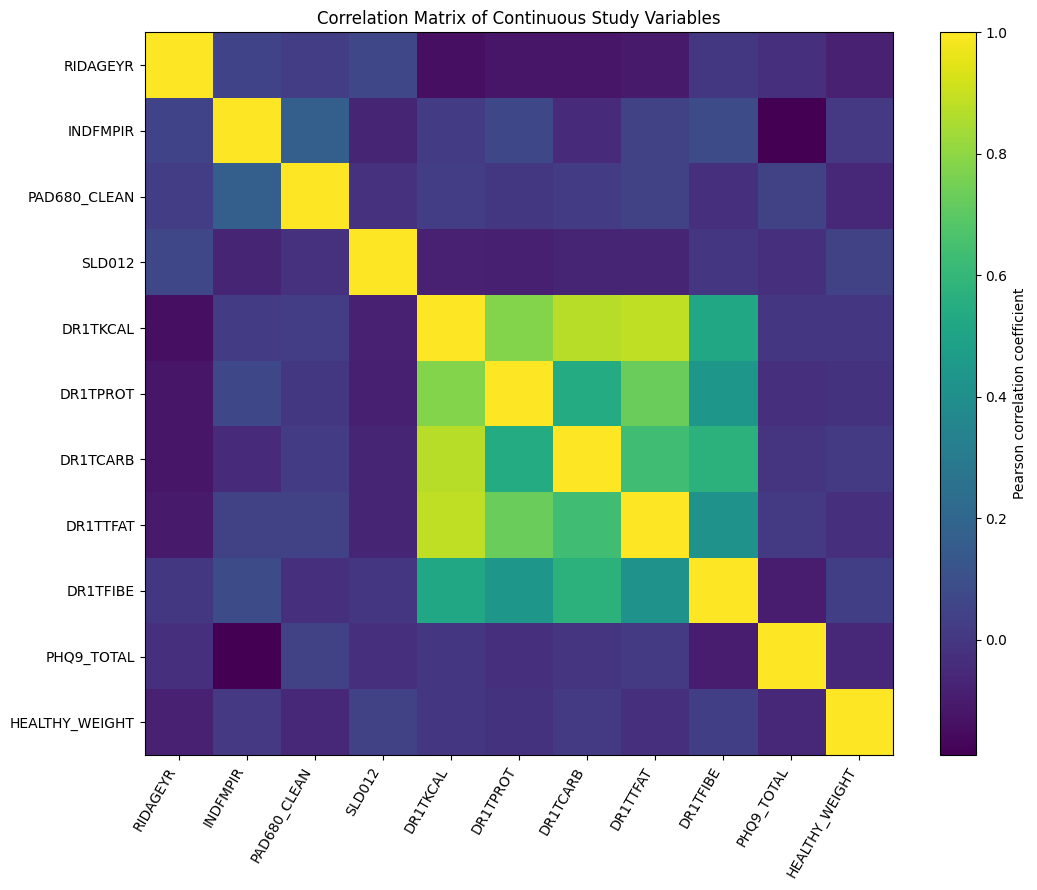

In [43]:
# ============================================================
# STEP 4P: CORRELATION ANALYSIS
# ============================================================

correlation_vars = continuous_eda_vars + [
    "HEALTHY_WEIGHT"
]

corr_matrix = (
    eda_df[correlation_vars]
    .corr(method="pearson")
)

print("\n" + "=" * 85)
print("4P. PEARSON CORRELATION MATRIX")
print("=" * 85)

print(corr_matrix.round(3))


plt.figure(figsize=(11, 9))

plt.imshow(
    corr_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Pearson correlation coefficient"
)

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=60,
    ha="right"
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

plt.title(
    "Correlation Matrix of Continuous Study Variables"
)

plt.tight_layout()

plt.savefig(
    "EDA_Correlation_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


corr_matrix.to_csv(
    "EDA_Correlation_Matrix.csv"
)

In [44]:
spearman_matrix = (
    eda_df[correlation_vars]
    .corr(method="spearman")
)

print("\n" + "=" * 85)
print("SPEARMAN RANK CORRELATION MATRIX")
print("=" * 85)

print(
    spearman_matrix
    .round(3)
)

spearman_matrix.to_csv(
    "EDA_Spearman_Correlation_Matrix.csv"
)


SPEARMAN RANK CORRELATION MATRIX
                RIDAGEYR  INDFMPIR  PAD680_CLEAN  SLD012  DR1TKCAL  DR1TPROT  \
RIDAGEYR           1.000     0.059         0.034   0.077    -0.138    -0.106   
INDFMPIR           0.059     1.000         0.189  -0.069     0.049     0.091   
PAD680_CLEAN       0.034     0.189         1.000  -0.010     0.048     0.020   
SLD012             0.077    -0.069        -0.010   1.000    -0.076    -0.077   
DR1TKCAL          -0.138     0.049         0.048  -0.076     1.000     0.784   
DR1TPROT          -0.106     0.091         0.020  -0.077     0.784     1.000   
DR1TCARB          -0.114    -0.006         0.027  -0.060     0.860     0.549   
DR1TTFAT          -0.090     0.070         0.071  -0.061     0.878     0.725   
DR1TFIBE           0.011     0.107        -0.016  -0.002     0.546     0.476   
PHQ9_TOTAL        -0.041    -0.177         0.035  -0.019    -0.012    -0.037   
HEALTHY_WEIGHT    -0.078     0.002        -0.056   0.051    -0.025    -0.025   

     

In [45]:
# ============================================================
# STEP 4R: STRONGEST CONTINUOUS CORRELATIONS
# ============================================================

pairs = []

for i in range(len(continuous_eda_vars)):
    for j in range(i + 1, len(continuous_eda_vars)):

        v1 = continuous_eda_vars[i]
        v2 = continuous_eda_vars[j]

        r = corr_matrix.loc[v1, v2]

        pairs.append({
            "Variable_1": continuous_labels[v1],
            "Variable_2": continuous_labels[v2],
            "Pearson_r": r,
            "Absolute_r": abs(r)
        })

correlation_pairs = (
    pd.DataFrame(pairs)
    .sort_values(
        "Absolute_r",
        ascending=False
    )
)

print("\nStrongest continuous-variable correlations:")

print(
    correlation_pairs
    .head(15)
    .round(3)
    .to_string(index=False)
)

correlation_pairs.to_csv(
    "EDA_Strongest_Correlation_Pairs.csv",
    index=False
)


Strongest continuous-variable correlations:
                 Variable_1                   Variable_2  Pearson_r  Absolute_r
   Energy intake (kcal/day)     Total fat intake (g/day)      0.887       0.887
   Energy intake (kcal/day)  Carbohydrate intake (g/day)      0.872       0.872
   Energy intake (kcal/day)       Protein intake (g/day)      0.781       0.781
     Protein intake (g/day)     Total fat intake (g/day)      0.727       0.727
Carbohydrate intake (g/day)     Total fat intake (g/day)      0.633       0.633
Carbohydrate intake (g/day) Dietary fibre intake (g/day)      0.576       0.576
     Protein intake (g/day)  Carbohydrate intake (g/day)      0.541       0.541
   Energy intake (kcal/day) Dietary fibre intake (g/day)      0.524       0.524
     Protein intake (g/day) Dietary fibre intake (g/day)      0.440       0.440
   Total fat intake (g/day) Dietary fibre intake (g/day)      0.420       0.420
    Income-to-poverty ratio            PHQ-9 total score     -0.189       0

In [46]:
# ============================================================
# STEP 4S: MULTICOLLINEARITY / VIF SCREENING
# ============================================================

vif_vars = [
    "RIDAGEYR",
    "INDFMPIR",
    "PAD680_CLEAN",
    "SLD012",
    "DR1TKCAL",
    "DR1TPROT",
    "DR1TCARB",
    "DR1TTFAT",
    "DR1TFIBE",
    "PHQ9_TOTAL"
]

# VIF requires complete rows.
# This diagnostic is exploratory only.
vif_data = (
    eda_df[vif_vars]
    .dropna()
    .copy()
)

X_vif = add_constant(vif_data)

vif_results = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(
            X_vif.shape[1]
        )
    ]
})

vif_results = vif_results[
    vif_results["Variable"] != "const"
]

print("\n" + "=" * 85)
print("4S. VARIANCE INFLATION FACTORS")
print("=" * 85)

print(
    vif_results
    .sort_values(
        "VIF",
        ascending=False
    )
    .round(2)
    .to_string(index=False)
)

vif_results.to_csv(
    "EDA_VIF_Diagnostics.csv",
    index=False
)


4S. VARIANCE INFLATION FACTORS
    Variable   VIF
    DR1TKCAL 31.41
    DR1TCARB 10.35
    DR1TTFAT  8.25
    DR1TPROT  3.71
    DR1TFIBE  1.67
    INDFMPIR  1.11
  PHQ9_TOTAL  1.05
PAD680_CLEAN  1.04
    RIDAGEYR  1.04
      SLD012  1.02


In [47]:
# ============================================================
# STEP 4T: EXPLORATORY CATEGORICAL ASSOCIATION SCREENING
# ============================================================

def cramers_v(contingency_table):

    chi2 = chi2_contingency(
        contingency_table
    )[0]

    n = contingency_table.sum().sum()

    min_dim = min(
        contingency_table.shape
    ) - 1

    if min_dim == 0:
        return np.nan

    return np.sqrt(
        chi2 / (
            n * min_dim
        )
    )


categorical_association_vars = {
    "SEX": "Sex",
    "AGE_GROUP": "Age group",
    "RACE_ETHNICITY": "Race / ethnicity",
    "EDUCATION": "Education",
    "MARITAL_STATUS": "Marital status",
    "VIGOROUS_WORK": "Vigorous work activity",
    "MODERATE_WORK": "Moderate work activity",
    "VIGOROUS_RECREATION": "Vigorous recreation",
    "MODERATE_RECREATION": "Moderate recreation",
    "SLEEP_CATEGORY": "Sleep category",
    "PHQ9_SEVERITY": "PHQ-9 severity"
}

association_rows = []

for var, label in categorical_association_vars.items():

    temp = eda_df[
        [var, "HEALTHY_WEIGHT"]
    ].dropna()

    contingency = pd.crosstab(
        temp[var],
        temp["HEALTHY_WEIGHT"]
    )

    chi2, p, dof, expected = (
        chi2_contingency(
            contingency
        )
    )

    v = cramers_v(
        contingency
    )

    association_rows.append({
        "Predictor": label,
        "N": len(temp),
        "Chi_Square": chi2,
        "Degrees_of_Freedom": dof,
        "p_value": p,
        "Cramers_V": v
    })


categorical_association_table = pd.DataFrame(
    association_rows
)

print("\n" + "=" * 85)
print("4T. CATEGORICAL ASSOCIATION SCREENING")
print("=" * 85)

print(
    categorical_association_table
    .sort_values(
        "Cramers_V",
        ascending=False
    )
    .round(4)
    .to_string(index=False)
)

categorical_association_table.to_csv(
    "EDA_Categorical_Association_Screening.csv",
    index=False
)


4T. CATEGORICAL ASSOCIATION SCREENING
             Predictor    N  Chi_Square  Degrees_of_Freedom  p_value  Cramers_V
      Race / ethnicity 4657    195.0535                   5   0.0000     0.2047
             Age group 4657     55.9766                   2   0.0000     0.1096
             Education 4651     51.5104                   4   0.0000     0.1052
        Marital status 4652     28.7788                   5   0.0000     0.0787
   Vigorous recreation 4657     24.5611                   1   0.0000     0.0726
        PHQ-9 severity 4657     19.4029                   4   0.0007     0.0645
   Moderate recreation 4657     15.9932                   1   0.0001     0.0586
        Sleep category 4627      9.0563                   2   0.0108     0.0442
                   Sex 4657      4.7248                   1   0.0297     0.0319
Moderate work activity 4654      4.6613                   1   0.0308     0.0316
Vigorous work activity 4653      2.2407                   1   0.1344     0.0219


In [48]:
# ============================================================
# STEP 4T: EXPLORATORY CATEGORICAL ASSOCIATION SCREENING
# ============================================================

def cramers_v(contingency_table):

    chi2 = chi2_contingency(
        contingency_table
    )[0]

    n = contingency_table.sum().sum()

    min_dim = min(
        contingency_table.shape
    ) - 1

    if min_dim == 0:
        return np.nan

    return np.sqrt(
        chi2 / (
            n * min_dim
        )
    )


categorical_association_vars = {
    "SEX": "Sex",
    "AGE_GROUP": "Age group",
    "RACE_ETHNICITY": "Race / ethnicity",
    "EDUCATION": "Education",
    "MARITAL_STATUS": "Marital status",
    "VIGOROUS_WORK": "Vigorous work activity",
    "MODERATE_WORK": "Moderate work activity",
    "VIGOROUS_RECREATION": "Vigorous recreation",
    "MODERATE_RECREATION": "Moderate recreation",
    "SLEEP_CATEGORY": "Sleep category",
    "PHQ9_SEVERITY": "PHQ-9 severity"
}

association_rows = []

for var, label in categorical_association_vars.items():

    temp = eda_df[
        [var, "HEALTHY_WEIGHT"]
    ].dropna()

    contingency = pd.crosstab(
        temp[var],
        temp["HEALTHY_WEIGHT"]
    )

    chi2, p, dof, expected = (
        chi2_contingency(
            contingency
        )
    )

    v = cramers_v(
        contingency
    )

    association_rows.append({
        "Predictor": label,
        "N": len(temp),
        "Chi_Square": chi2,
        "Degrees_of_Freedom": dof,
        "p_value": p,
        "Cramers_V": v
    })


categorical_association_table = pd.DataFrame(
    association_rows
)

print("\n" + "=" * 85)
print("4T. CATEGORICAL ASSOCIATION SCREENING")
print("=" * 85)

print(
    categorical_association_table
    .sort_values(
        "Cramers_V",
        ascending=False
    )
    .round(4)
    .to_string(index=False)
)

categorical_association_table.to_csv(
    "EDA_Categorical_Association_Screening.csv",
    index=False
)


4T. CATEGORICAL ASSOCIATION SCREENING
             Predictor    N  Chi_Square  Degrees_of_Freedom  p_value  Cramers_V
      Race / ethnicity 4657    195.0535                   5   0.0000     0.2047
             Age group 4657     55.9766                   2   0.0000     0.1096
             Education 4651     51.5104                   4   0.0000     0.1052
        Marital status 4652     28.7788                   5   0.0000     0.0787
   Vigorous recreation 4657     24.5611                   1   0.0000     0.0726
        PHQ-9 severity 4657     19.4029                   4   0.0007     0.0645
   Moderate recreation 4657     15.9932                   1   0.0001     0.0586
        Sleep category 4627      9.0563                   2   0.0108     0.0442
                   Sex 4657      4.7248                   1   0.0297     0.0319
Moderate work activity 4654      4.6613                   1   0.0308     0.0316
Vigorous work activity 4653      2.2407                   1   0.1344     0.0219


In [49]:
# ============================================================
# STEP 4V: POINT-BISERIAL CORRELATIONS WITH HEALTHY WEIGHT
# ============================================================

point_biserial_rows = []

for var in continuous_eda_vars:

    temp = eda_df[
        ["HEALTHY_WEIGHT", var]
    ].dropna()

    r, p = stats.pointbiserialr(
        temp["HEALTHY_WEIGHT"],
        temp[var]
    )

    point_biserial_rows.append({
        "Variable": continuous_labels[var],
        "N": len(temp),
        "Point_Biserial_r": r,
        "p_value": p,
        "Absolute_r": abs(r)
    })


point_biserial_table = (
    pd.DataFrame(
        point_biserial_rows
    )
    .sort_values(
        "Absolute_r",
        ascending=False
    )
)

print("\n" + "=" * 85)
print("4V. CONTINUOUS VARIABLES VS HEALTHY-WEIGHT STATUS")
print("=" * 85)

print(
    point_biserial_table
    .round(4)
    .to_string(index=False)
)

point_biserial_table.to_csv(
    "EDA_Point_Biserial_Associations.csv",
    index=False
)


4V. CONTINUOUS VARIABLES VS HEALTHY-WEIGHT STATUS
                    Variable    N  Point_Biserial_r  p_value  Absolute_r
                 Age (years) 4657           -0.0804   0.0000      0.0804
           PHQ-9 total score 4657           -0.0566   0.0001      0.0566
Sedentary time (minutes/day) 4624           -0.0539   0.0002      0.0539
  Sleep duration (hours/day) 4627            0.0423   0.0040      0.0423
Dietary fibre intake (g/day) 4400            0.0329   0.0293      0.0329
    Total fat intake (g/day) 4400           -0.0307   0.0416      0.0307
      Protein intake (g/day) 4400           -0.0146   0.3321      0.0146
 Carbohydrate intake (g/day) 4400            0.0140   0.3516      0.0140
     Income-to-poverty ratio 4084            0.0071   0.6519      0.0071
    Energy intake (kcal/day) 4400           -0.0033   0.8290      0.0033


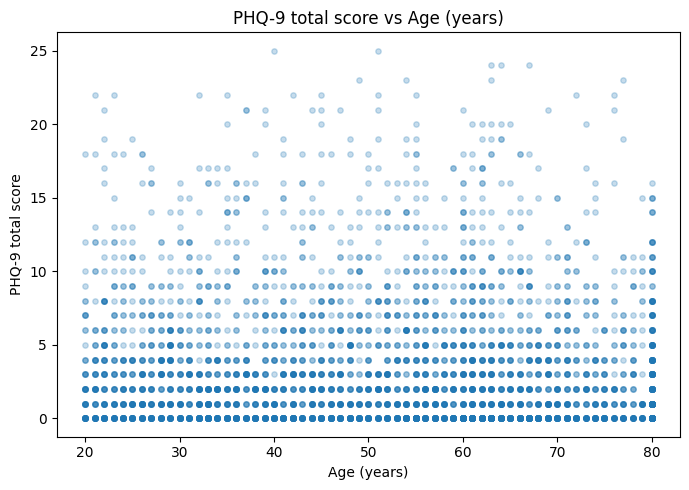

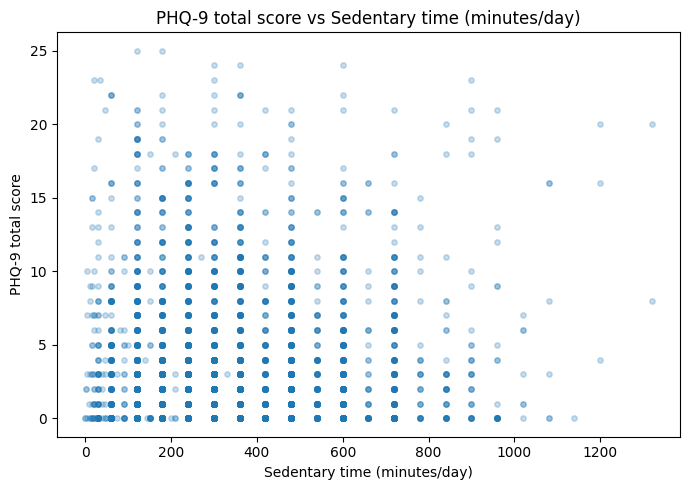

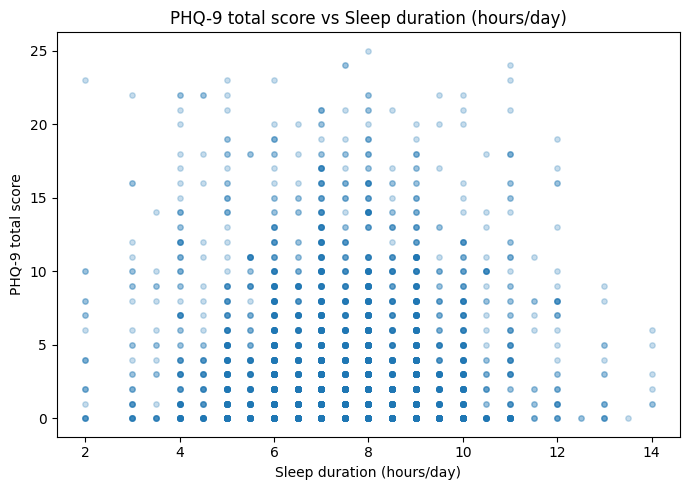

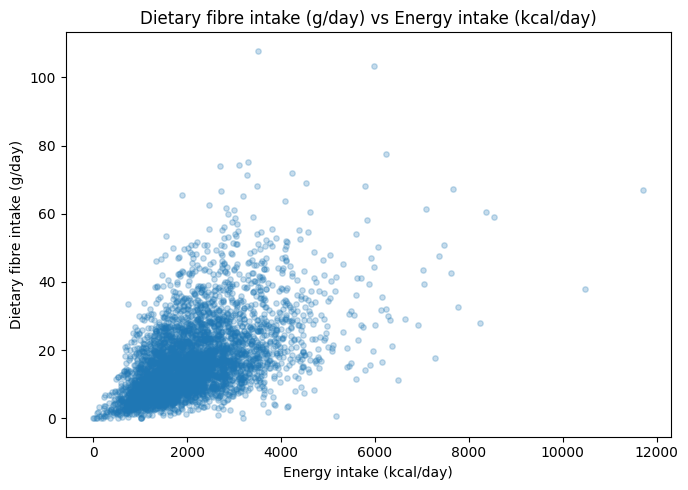

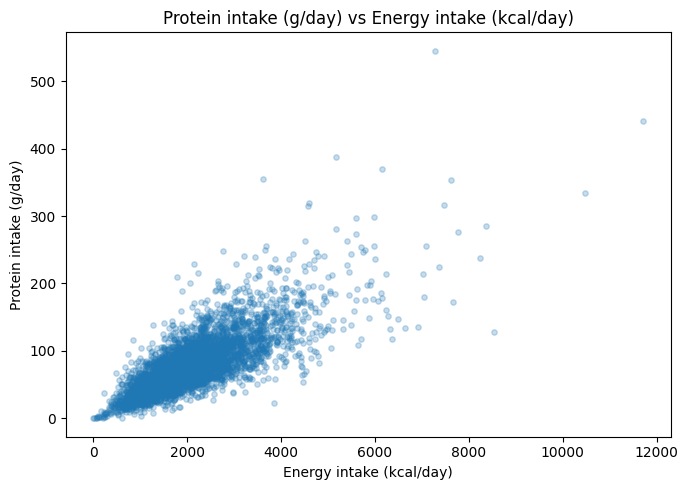

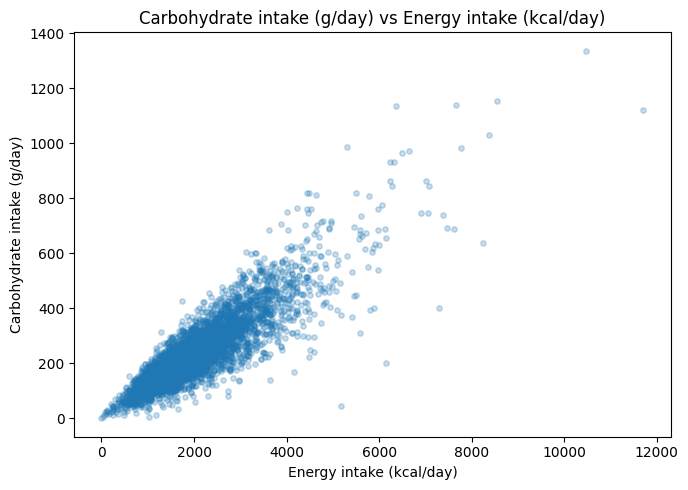

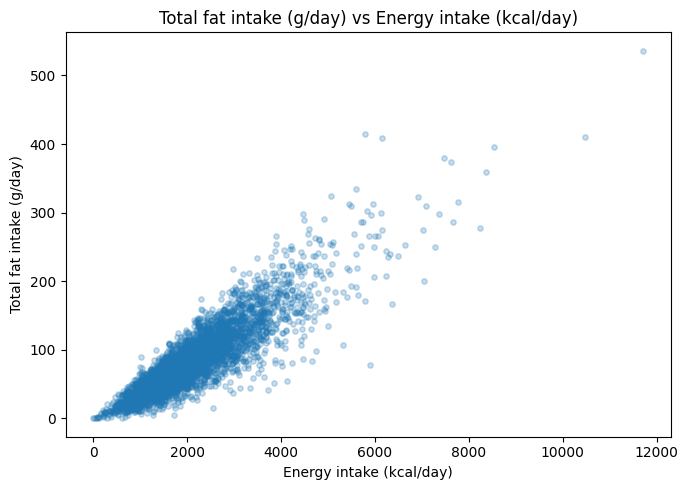

In [50]:
# ============================================================
# STEP 4W: SELECTED SCATTER PLOTS
# ============================================================

scatter_pairs = [
    ("RIDAGEYR", "PHQ9_TOTAL"),
    ("PAD680_CLEAN", "PHQ9_TOTAL"),
    ("SLD012", "PHQ9_TOTAL"),
    ("DR1TKCAL", "DR1TFIBE"),
    ("DR1TKCAL", "DR1TPROT"),
    ("DR1TKCAL", "DR1TCARB"),
    ("DR1TKCAL", "DR1TTFAT")
]

for x_var, y_var in scatter_pairs:

    temp = eda_df[
        [x_var, y_var]
    ].dropna()

    plt.figure(figsize=(7, 5))

    plt.scatter(
        temp[x_var],
        temp[y_var],
        alpha=0.25,
        s=15
    )

    plt.xlabel(
        continuous_labels[x_var]
    )

    plt.ylabel(
        continuous_labels[y_var]
    )

    plt.title(
        f"{continuous_labels[y_var]} vs "
        f"{continuous_labels[x_var]}"
    )

    plt.tight_layout()

    plt.savefig(
        f"EDA_Scatter_{y_var}_vs_{x_var}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

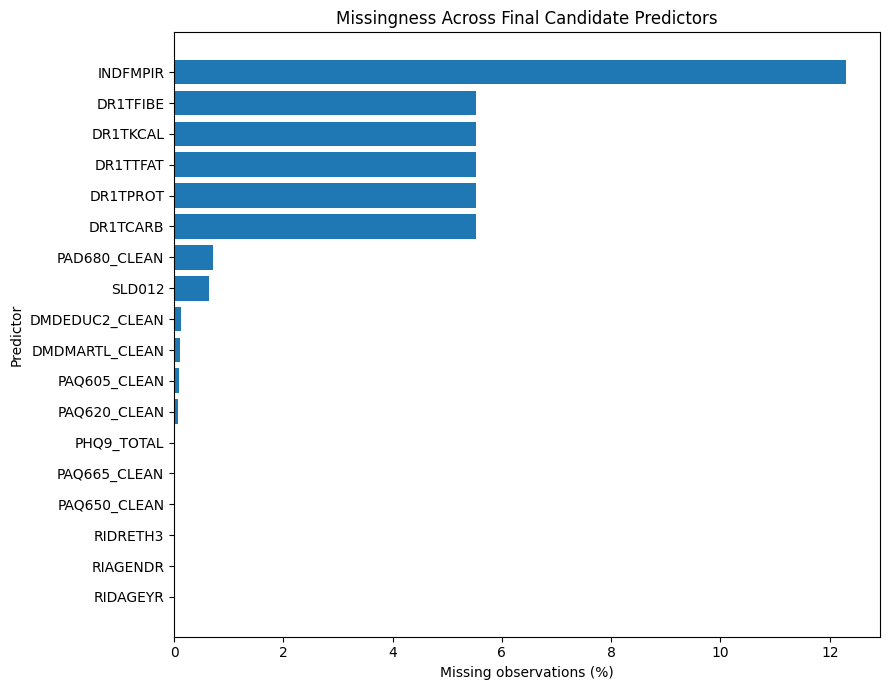

In [51]:
# ============================================================
# STEP 4X: FINAL-PREDICTOR MISSINGNESS VISUALISATION
# ============================================================

eda_missing = pd.DataFrame({
    "Variable": extended_predictors,
    "Missing_Percent": [
        eda_df[var].isna().mean() * 100
        for var in extended_predictors
    ]
})

eda_missing = (
    eda_missing
    .sort_values(
        "Missing_Percent",
        ascending=True
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    eda_missing["Variable"],
    eda_missing["Missing_Percent"]
)

plt.xlabel("Missing observations (%)")
plt.ylabel("Predictor")
plt.title(
    "Missingness Across Final Candidate Predictors"
)

plt.tight_layout()

plt.savefig(
    "EDA_Final_Predictor_Missingness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

eda_missing.to_csv(
    "EDA_Final_Predictor_Missingness.csv",
    index=False
)

In [52]:
# ============================================================
# STEP 4Y: AUTOMATED EDA INSIGHT SUMMARY
# ============================================================

print("\n" + "=" * 85)
print("EDA INSIGHT SUMMARY")
print("=" * 85)


# Outcome imbalance
healthy_pct = (
    eda_df["HEALTHY_WEIGHT"]
    .mean() * 100
)

print(
    f"\n1. OUTCOME BALANCE:\n"
    f"   Healthy weight = {healthy_pct:.2f}%.\n"
    f"   Above healthy weight = {100-healthy_pct:.2f}%.\n"
    f"   The binary outcome is therefore imbalanced, "
    f"and model evaluation should not rely on accuracy alone."
)


# PHQ distribution
phq_skew = (
    eda_df["PHQ9_TOTAL"]
    .skew()
)

print(
    f"\n2. DEPRESSION DISTRIBUTION:\n"
    f"   Mean PHQ-9 = "
    f"{eda_df['PHQ9_TOTAL'].mean():.2f}; "
    f"median = {eda_df['PHQ9_TOTAL'].median():.2f}; "
    f"skewness = {phq_skew:.2f}.\n"
    f"   The PHQ-9 distribution is "
    f"{interpret_skewness(phq_skew)}."
)


# PHQ by target
phq_unhealthy_mean = (
    eda_df.loc[
        eda_df["HEALTHY_WEIGHT"] == 0,
        "PHQ9_TOTAL"
    ]
    .mean()
)

phq_healthy_mean = (
    eda_df.loc[
        eda_df["HEALTHY_WEIGHT"] == 1,
        "PHQ9_TOTAL"
    ]
    .mean()
)

print(
    f"\n3. PHQ-9 AND WEIGHT STATUS:\n"
    f"   Mean PHQ-9 among above-healthy-weight participants = "
    f"{phq_unhealthy_mean:.2f}.\n"
    f"   Mean PHQ-9 among healthy-weight participants = "
    f"{phq_healthy_mean:.2f}.\n"
    f"   This descriptive difference will be formally tested "
    f"in the RQ1 inferential analysis."
)


# Strongest categorical association
top_cat = (
    categorical_association_table
    .sort_values(
        "Cramers_V",
        ascending=False
    )
    .iloc[0]
)

print(
    f"\n4. STRONGEST CATEGORICAL ASSOCIATION:\n"
    f"   {top_cat['Predictor']} had the largest exploratory "
    f"Cramér's V with healthy-weight status "
    f"(V = {top_cat['Cramers_V']:.3f})."
)


# Strongest continuous association
top_cont = (
    point_biserial_table
    .iloc[0]
)

print(
    f"\n5. STRONGEST CONTINUOUS ASSOCIATION:\n"
    f"   {top_cont['Variable']} had the largest absolute "
    f"point-biserial association with healthy-weight status "
    f"(r = {top_cont['Point_Biserial_r']:.3f})."
)


# Missingness
highest_missing_var = (
    eda_missing
    .sort_values(
        "Missing_Percent",
        ascending=False
    )
    .iloc[0]
)

print(
    f"\n6. MISSING DATA:\n"
    f"   The highest missingness among selected predictors was "
    f"{highest_missing_var['Variable']} at "
    f"{highest_missing_var['Missing_Percent']:.2f}%."
)


# VIF
highest_vif = (
    vif_results
    .sort_values(
        "VIF",
        ascending=False
    )
    .iloc[0]
)

print(
    f"\n7. MULTICOLLINEARITY:\n"
    f"   The largest VIF among continuous predictors was "
    f"{highest_vif['Variable']} = "
    f"{highest_vif['VIF']:.2f}.\n"
    f"   VIF results should be reviewed before finalising "
    f"the inferential regression specification."
)


print(
    "\n8. NEXT ANALYTICAL STEP:\n"
    "   Formal RQ1 statistical testing will assess whether "
    "depressive symptom severity is associated with healthy "
    "weight before and after adjustment for relevant "
    "demographic and lifestyle covariates."
)

print("\nComprehensive EDA completed.")


EDA INSIGHT SUMMARY

1. OUTCOME BALANCE:
   Healthy weight = 24.35%.
   Above healthy weight = 75.65%.
   The binary outcome is therefore imbalanced, and model evaluation should not rely on accuracy alone.

2. DEPRESSION DISTRIBUTION:
   Mean PHQ-9 = 3.21; median = 2.00; skewness = 1.92.
   The PHQ-9 distribution is strongly right-skewed.

3. PHQ-9 AND WEIGHT STATUS:
   Mean PHQ-9 among above-healthy-weight participants = 3.35.
   Mean PHQ-9 among healthy-weight participants = 2.79.
   This descriptive difference will be formally tested in the RQ1 inferential analysis.

4. STRONGEST CATEGORICAL ASSOCIATION:
   Race / ethnicity had the largest exploratory Cramér's V with healthy-weight status (V = 0.205).

5. STRONGEST CONTINUOUS ASSOCIATION:
   Age (years) had the largest absolute point-biserial association with healthy-weight status (r = -0.080).

6. MISSING DATA:
   The highest missingness among selected predictors was INDFMPIR at 12.30%.

7. MULTICOLLINEARITY:
   The largest VIF am

In [53]:
# ============================================================
# STEP 4Z: REPORT-READY EDA INSIGHT TABLE
# ============================================================

eda_insight_table = pd.DataFrame({
    "EDA_Area": [
        "Outcome distribution",
        "Missing-data pattern",
        "PHQ-9 distribution",
        "PHQ-9 vs healthy weight",
        "Demographic differences",
        "Physical activity",
        "Sedentary behaviour",
        "Sleep",
        "Dietary factors",
        "Correlation analysis",
        "Multicollinearity",
        "Potential outliers"
    ],

    "Research_Relevance": [
        "RQ2 / RQ3",
        "All RQs",
        "RQ1 / RQ3 / RQ4",
        "RQ1 / RQ3",
        "RQ1 / RQ2",
        "RQ1 / RQ2",
        "RQ1 / RQ2",
        "RQ1 / RQ2",
        "RQ1 / RQ2",
        "RQ2 / RQ3",
        "RQ1 / RQ2",
        "RQ1 / RQ2"
    ],

    "Modelling_Implication": [
        "Use stratified splitting and multiple performance metrics",
        "Use training-only imputation pipeline",
        "Retain PHQ9_TOTAL as continuous; use severity categories descriptively",
        "Formally test association in RQ1",
        "Retain theoretically relevant demographic covariates",
        "Evaluate activity indicators as categorical predictors",
        "Retain continuous sedentary-time measure after special-code cleaning",
        "Evaluate continuous sleep duration; categories used for EDA",
        "Evaluate dietary predictors and assess redundancy",
        "Review highly correlated predictor pairs",
        "Remove or consolidate redundant predictors if necessary",
        "Investigate but do not automatically delete legitimate extreme observations"
    ]
})

print(
    eda_insight_table
    .to_string(index=False)
)

eda_insight_table.to_csv(
    "EDA_Insight_Summary_Template.csv",
    index=False
)

               EDA_Area Research_Relevance                                                       Modelling_Implication
   Outcome distribution          RQ2 / RQ3                   Use stratified splitting and multiple performance metrics
   Missing-data pattern            All RQs                                       Use training-only imputation pipeline
     PHQ-9 distribution    RQ1 / RQ3 / RQ4      Retain PHQ9_TOTAL as continuous; use severity categories descriptively
PHQ-9 vs healthy weight          RQ1 / RQ3                                            Formally test association in RQ1
Demographic differences          RQ1 / RQ2                        Retain theoretically relevant demographic covariates
      Physical activity          RQ1 / RQ2                      Evaluate activity indicators as categorical predictors
    Sedentary behaviour          RQ1 / RQ2        Retain continuous sedentary-time measure after special-code cleaning
                  Sleep          RQ1 / RQ2      

## Step 5: Final Predictor Refinement

### Step 5A: Dietary Multicollinearity Assessment

Exploratory correlation and variance-inflation-factor analyses identified substantial
multicollinearity among total energy intake and the macronutrient variables. Total energy
intake was strongly correlated with carbohydrate, fat, and protein intake, and its initial
variance inflation factor exceeded conventional thresholds.

Because multicollinearity can destabilize regression coefficients and complicate
interpretation, alternative dietary specifications were evaluated before finalizing the
predictor set. Two theoretically defensible specifications were compared: (1) total
energy intake plus dietary fibre and (2) individual macronutrient intakes plus dietary
fibre.

In [54]:
# ============================================================
# STEP 5A: DIETARY MULTICOLLINEARITY REFINEMENT
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd
import numpy as np

print("=" * 85)
print("STEP 5A: DIETARY MULTICOLLINEARITY REFINEMENT")
print("=" * 85)


# ------------------------------------------------------------
# Helper function to calculate VIF
# ------------------------------------------------------------

def calculate_vif(dataframe, variables, specification_name):

    temp = (
        dataframe[variables]
        .dropna()
        .copy()
    )

    X = add_constant(temp)

    vif_table = pd.DataFrame({
        "Variable": X.columns,
        "VIF": [
            variance_inflation_factor(
                X.values,
                i
            )
            for i in range(X.shape[1])
        ]
    })

    vif_table = vif_table[
        vif_table["Variable"] != "const"
    ].copy()

    vif_table["Specification"] = specification_name

    return vif_table


# ------------------------------------------------------------
# Variables that remain constant across both specifications
# ------------------------------------------------------------

common_continuous_predictors = [
    "RIDAGEYR",
    "INDFMPIR",
    "PAD680_CLEAN",
    "SLD012",
    "PHQ9_TOTAL"
]


# ------------------------------------------------------------
# Specification A:
# Total energy + fibre
# ------------------------------------------------------------

specification_A = (
    common_continuous_predictors
    + [
        "DR1TKCAL",
        "DR1TFIBE"
    ]
)


# ------------------------------------------------------------
# Specification B:
# Macronutrients + fibre, without total energy
# ------------------------------------------------------------

specification_B = (
    common_continuous_predictors
    + [
        "DR1TPROT",
        "DR1TCARB",
        "DR1TTFAT",
        "DR1TFIBE"
    ]
)


vif_A = calculate_vif(
    eda_df,
    specification_A,
    "A: Energy + Fibre"
)

vif_B = calculate_vif(
    eda_df,
    specification_B,
    "B: Macronutrients + Fibre"
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 85)
print("SPECIFICATION A: TOTAL ENERGY + FIBRE")
print("=" * 85)

print(
    vif_A
    .sort_values("VIF", ascending=False)
    .round(2)
    .to_string(index=False)
)


print("\n" + "=" * 85)
print("SPECIFICATION B: MACRONUTRIENTS + FIBRE")
print("=" * 85)

print(
    vif_B
    .sort_values("VIF", ascending=False)
    .round(2)
    .to_string(index=False)
)


# ------------------------------------------------------------
# Summarize maximum VIF
# ------------------------------------------------------------

max_vif_A = vif_A["VIF"].max()
max_vif_B = vif_B["VIF"].max()

print("\n" + "=" * 85)
print("SPECIFICATION COMPARISON")
print("=" * 85)

print(
    f"Maximum VIF — Specification A "
    f"(Energy + Fibre): {max_vif_A:.2f}"
)

print(
    f"Maximum VIF — Specification B "
    f"(Macronutrients + Fibre): {max_vif_B:.2f}"
)


# ------------------------------------------------------------
# Automated diagnostic interpretation
# ------------------------------------------------------------

def vif_interpretation(v):

    if v < 5:
        return "acceptable"
    elif v < 10:
        return "potentially concerning"
    else:
        return "high multicollinearity"


print(
    "\nSpecification A maximum VIF is "
    f"{vif_interpretation(max_vif_A)}."
)

print(
    "Specification B maximum VIF is "
    f"{vif_interpretation(max_vif_B)}."
)


# ------------------------------------------------------------
# Save output
# ------------------------------------------------------------

vif_comparison = pd.concat(
    [vif_A, vif_B],
    ignore_index=True
)

vif_comparison.to_csv(
    "Final_Dietary_Multicollinearity_Comparison.csv",
    index=False
)

print(
    "\nVIF comparison exported as: "
    "Final_Dietary_Multicollinearity_Comparison.csv"
)

print("\nStep 5A completed.")

STEP 5A: DIETARY MULTICOLLINEARITY REFINEMENT

SPECIFICATION A: TOTAL ENERGY + FIBRE
    Variable  VIF     Specification
    DR1TKCAL 1.43 A: Energy + Fibre
    DR1TFIBE 1.42 A: Energy + Fibre
    INDFMPIR 1.08 A: Energy + Fibre
  PHQ9_TOTAL 1.05 A: Energy + Fibre
PAD680_CLEAN 1.04 A: Energy + Fibre
    RIDAGEYR 1.03 A: Energy + Fibre
      SLD012 1.02 A: Energy + Fibre

SPECIFICATION B: MACRONUTRIENTS + FIBRE
    Variable  VIF             Specification
    DR1TTFAT 2.58 B: Macronutrients + Fibre
    DR1TPROT 2.26 B: Macronutrients + Fibre
    DR1TCARB 2.14 B: Macronutrients + Fibre
    DR1TFIBE 1.61 B: Macronutrients + Fibre
    INDFMPIR 1.11 B: Macronutrients + Fibre
  PHQ9_TOTAL 1.05 B: Macronutrients + Fibre
PAD680_CLEAN 1.04 B: Macronutrients + Fibre
    RIDAGEYR 1.03 B: Macronutrients + Fibre
      SLD012 1.02 B: Macronutrients + Fibre

SPECIFICATION COMPARISON
Maximum VIF — Specification A (Energy + Fibre): 1.43
Maximum VIF — Specification B (Macronutrients + Fibre): 2.58

Speci

In [55]:
# ============================================================
# STEP 5B: LOCK FINAL PREDICTOR SET
# ============================================================

print("=" * 85)
print("STEP 5B: FINAL PREDICTOR SET")
print("=" * 85)

final_baseline_predictors = [
    # Demographic
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",

    # Socioeconomic
    "DMDEDUC2_CLEAN",
    "DMDMARTL_CLEAN",
    "INDFMPIR",

    # Physical activity / sedentary behaviour
    "PAQ605_CLEAN",
    "PAQ620_CLEAN",
    "PAQ650_CLEAN",
    "PAQ665_CLEAN",
    "PAD680_CLEAN",

    # Sleep
    "SLD012",

    # Dietary
    "DR1TKCAL",
    "DR1TFIBE"
]

final_extended_predictors = (
    final_baseline_predictors
    + ["PHQ9_TOTAL"]
)

target_variable = "HEALTHY_WEIGHT"

print(f"\nFinal baseline predictors: {len(final_baseline_predictors)}")
for i, var in enumerate(final_baseline_predictors, 1):
    print(f"{i:>2}. {var}")

print(f"\nFinal extended predictors: {len(final_extended_predictors)}")
for i, var in enumerate(final_extended_predictors, 1):
    print(f"{i:>2}. {var}")

print(f"\nTarget: {target_variable}")

# Confirm removed dietary variables
removed_due_to_redundancy = [
    "DR1TPROT",
    "DR1TCARB",
    "DR1TTFAT"
]

print("\nDietary variables removed after multicollinearity review:")
for var in removed_due_to_redundancy:
    print(f"- {var}")

# Validate leakage
for leak_var in ["BMXBMI", "BMI_CATEGORY", "HEALTHY_WEIGHT"]:
    assert leak_var not in final_baseline_predictors
    assert leak_var not in final_extended_predictors

print("\nTarget-leakage validation passed.")

# Focused final analytical dataframe
final_modeling_df = analysis_ready_initial[
    final_extended_predictors + [target_variable]
].copy()

print(
    f"\nFinal modelling dataframe shape: "
    f"{final_modeling_df.shape}"
)

print("\nStep 5B completed.")

STEP 5B: FINAL PREDICTOR SET

Final baseline predictors: 14
 1. RIDAGEYR
 2. RIAGENDR
 3. RIDRETH3
 4. DMDEDUC2_CLEAN
 5. DMDMARTL_CLEAN
 6. INDFMPIR
 7. PAQ605_CLEAN
 8. PAQ620_CLEAN
 9. PAQ650_CLEAN
10. PAQ665_CLEAN
11. PAD680_CLEAN
12. SLD012
13. DR1TKCAL
14. DR1TFIBE

Final extended predictors: 15
 1. RIDAGEYR
 2. RIAGENDR
 3. RIDRETH3
 4. DMDEDUC2_CLEAN
 5. DMDMARTL_CLEAN
 6. INDFMPIR
 7. PAQ605_CLEAN
 8. PAQ620_CLEAN
 9. PAQ650_CLEAN
10. PAQ665_CLEAN
11. PAD680_CLEAN
12. SLD012
13. DR1TKCAL
14. DR1TFIBE
15. PHQ9_TOTAL

Target: HEALTHY_WEIGHT

Dietary variables removed after multicollinearity review:
- DR1TPROT
- DR1TCARB
- DR1TTFAT

Target-leakage validation passed.

Final modelling dataframe shape: (4657, 16)

Step 5B completed.


In [56]:
# ============================================================
# STEP 6A: UNADJUSTED ASSOCIATION BETWEEN PHQ-9 AND
#          HEALTHY-WEIGHT STATUS
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats

print("=" * 85)
print("STEP 6A: PHQ-9 SCORE BY HEALTHY-WEIGHT STATUS")
print("=" * 85)

# ------------------------------------------------------------
# 1. Extract groups
# ------------------------------------------------------------

non_healthy_phq = final_modeling_df.loc[
    final_modeling_df["HEALTHY_WEIGHT"] == 0,
    "PHQ9_TOTAL"
].dropna()

healthy_phq = final_modeling_df.loc[
    final_modeling_df["HEALTHY_WEIGHT"] == 1,
    "PHQ9_TOTAL"
].dropna()

print("\nGroup sizes:")
print(f"Not healthy weight (0): {len(non_healthy_phq):,}")
print(f"Healthy weight (1):     {len(healthy_phq):,}")


# ------------------------------------------------------------
# 2. Descriptive statistics
# ------------------------------------------------------------

def descriptive_summary(series):
    return pd.Series({
        "N": series.count(),
        "Mean": series.mean(),
        "SD": series.std(),
        "Median": series.median(),
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75),
        "IQR": series.quantile(0.75) - series.quantile(0.25),
        "Minimum": series.min(),
        "Maximum": series.max()
    })


phq_descriptives = pd.DataFrame({
    "Not_Healthy_Weight": descriptive_summary(non_healthy_phq),
    "Healthy_Weight": descriptive_summary(healthy_phq)
}).T

print("\n" + "=" * 85)
print("DESCRIPTIVE STATISTICS")
print("=" * 85)
print(phq_descriptives.round(3))


# ------------------------------------------------------------
# 3. Skewness
# ------------------------------------------------------------

skew_nonhealthy = stats.skew(
    non_healthy_phq,
    bias=False
)

skew_healthy = stats.skew(
    healthy_phq,
    bias=False
)

print("\n" + "=" * 85)
print("PHQ-9 DISTRIBUTION / SKEWNESS")
print("=" * 85)

print(
    f"Not healthy weight PHQ-9 skewness: "
    f"{skew_nonhealthy:.3f}"
)

print(
    f"Healthy weight PHQ-9 skewness: "
    f"{skew_healthy:.3f}"
)


# ------------------------------------------------------------
# 4. Welch independent-samples t-test
# ------------------------------------------------------------

t_stat, t_p = stats.ttest_ind(
    healthy_phq,
    non_healthy_phq,
    equal_var=False
)

print("\n" + "=" * 85)
print("WELCH INDEPENDENT-SAMPLES T-TEST")
print("=" * 85)

print(f"t statistic: {t_stat:.4f}")
print(f"p-value:     {t_p:.6f}")


# ------------------------------------------------------------
# 5. Mann-Whitney U test
# ------------------------------------------------------------

u_stat, u_p = stats.mannwhitneyu(
    healthy_phq,
    non_healthy_phq,
    alternative="two-sided"
)

print("\n" + "=" * 85)
print("MANN-WHITNEY U TEST")
print("=" * 85)

print(f"U statistic: {u_stat:.2f}")
print(f"p-value:     {u_p:.6f}")


# ------------------------------------------------------------
# 6. Cohen's d
# ------------------------------------------------------------

def cohens_d(group1, group2):

    n1 = len(group1)
    n2 = len(group2)

    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)

    pooled_sd = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2)
        / (n1 + n2 - 2)
    )

    return (
        np.mean(group1) - np.mean(group2)
    ) / pooled_sd


d = cohens_d(
    healthy_phq,
    non_healthy_phq
)

print("\n" + "=" * 85)
print("EFFECT SIZE")
print("=" * 85)

print(
    f"Cohen's d "
    f"(Healthy - Not Healthy): {d:.4f}"
)

if abs(d) < 0.20:
    d_interpretation = "negligible"
elif abs(d) < 0.50:
    d_interpretation = "small"
elif abs(d) < 0.80:
    d_interpretation = "medium"
else:
    d_interpretation = "large"

print(
    f"Approximate effect-size interpretation: "
    f"{d_interpretation}"
)


# ------------------------------------------------------------
# 7. Rank-biserial correlation
# ------------------------------------------------------------

n1 = len(healthy_phq)
n2 = len(non_healthy_phq)

rank_biserial = (
    (2 * u_stat) / (n1 * n2)
) - 1

print(
    f"Rank-biserial correlation: "
    f"{rank_biserial:.4f}"
)


# ------------------------------------------------------------
# 8. Export results
# ------------------------------------------------------------

phq_descriptives.to_csv(
    "PHQ9_Healthy_Weight_Descriptive_Statistics.csv",
    index=True
)

test_results = pd.DataFrame({
    "Analysis": [
        "Welch t-test",
        "Mann-Whitney U",
        "Cohen's d",
        "Rank-biserial correlation"
    ],
    "Statistic": [
        t_stat,
        u_stat,
        d,
        rank_biserial
    ],
    "P_Value": [
        t_p,
        u_p,
        np.nan,
        np.nan
    ]
})

test_results.to_csv(
    "PHQ9_Healthy_Weight_Unadjusted_Tests.csv",
    index=False
)

print("\nResults exported:")
print(
    "- PHQ9_Healthy_Weight_Descriptive_Statistics.csv"
)
print(
    "- PHQ9_Healthy_Weight_Unadjusted_Tests.csv"
)

print("\nStep 6A completed.")

STEP 6A: PHQ-9 SCORE BY HEALTHY-WEIGHT STATUS

Group sizes:
Not healthy weight (0): 3,523
Healthy weight (1):     1,134

DESCRIPTIVE STATISTICS
                         N   Mean     SD  Median   Q1   Q3  IQR  Minimum  \
Not_Healthy_Weight  3523.0  3.347  4.354     2.0  0.0  5.0  5.0      0.0   
Healthy_Weight      1134.0  2.788  3.824     1.0  0.0  4.0  4.0      0.0   

                    Maximum  
Not_Healthy_Weight     25.0  
Healthy_Weight         24.0  

PHQ-9 DISTRIBUTION / SKEWNESS
Not healthy weight PHQ-9 skewness: 1.866
Healthy weight PHQ-9 skewness: 2.097

WELCH INDEPENDENT-SAMPLES T-TEST
t statistic: -4.1312
p-value:     0.000037

MANN-WHITNEY U TEST
U statistic: 1866598.00
p-value:     0.000662

EFFECT SIZE
Cohen's d (Healthy - Not Healthy): -0.1320
Approximate effect-size interpretation: negligible
Rank-biserial correlation: -0.0656

Results exported:
- PHQ9_Healthy_Weight_Descriptive_Statistics.csv
- PHQ9_Healthy_Weight_Unadjusted_Tests.csv

Step 6A completed.


**Observation:** Participants classified as having a healthy weight had lower depressive symptom scores than participants classified as not having a healthy weight. Mean PHQ-9 scores were 2.79 (SD = 3.82) and 3.35 (SD = 4.35), respectively. The difference was statistically significant using both Welch's independent-samples t-test (t = −4.13, p < .001) and the Mann–Whitney U test (U = 1,866,598, p < .001). However, the magnitude of the difference was small, with a negligible Cohen's d of −0.13 and rank-biserial correlation of −0.066. Thus, although depressive symptom severity showed a statistically detectable unadjusted association with healthy-weight status, the practical magnitude of this relationship was limited.

In [57]:
# ============================================================
# STEP 6B: PHQ-9 SEVERITY CATEGORY AND HEALTHY-WEIGHT STATUS
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats

print("=" * 85)
print("STEP 6B: PHQ-9 SEVERITY AND HEALTHY-WEIGHT STATUS")
print("=" * 85)


# ------------------------------------------------------------
# 1. Create standard PHQ-9 severity categories
# ------------------------------------------------------------

phq_bins = [-0.001, 4, 9, 14, 19, 27]

phq_labels = [
    "Minimal (0-4)",
    "Mild (5-9)",
    "Moderate (10-14)",
    "Moderately severe (15-19)",
    "Severe (20-27)"
]

final_modeling_df["PHQ9_SEVERITY"] = pd.cut(
    final_modeling_df["PHQ9_TOTAL"],
    bins=phq_bins,
    labels=phq_labels,
    ordered=True
)


# ------------------------------------------------------------
# 2. Validate category creation
# ------------------------------------------------------------

print("\nPHQ-9 severity category distribution:")

severity_counts = (
    final_modeling_df["PHQ9_SEVERITY"]
    .value_counts(sort=False)
)

severity_percent = (
    final_modeling_df["PHQ9_SEVERITY"]
    .value_counts(normalize=True, sort=False)
    * 100
)

severity_summary = pd.DataFrame({
    "N": severity_counts,
    "Percent": severity_percent
})

print(severity_summary.round(2))

print(
    "\nMissing PHQ-9 severity classifications:",
    final_modeling_df["PHQ9_SEVERITY"].isna().sum()
)


# ------------------------------------------------------------
# 3. Cross-tabulation:
#    PHQ severity × healthy-weight status
# ------------------------------------------------------------

crosstab_counts = pd.crosstab(
    final_modeling_df["PHQ9_SEVERITY"],
    final_modeling_df["HEALTHY_WEIGHT"]
)

# Ensure meaningful column labels
crosstab_counts.columns = [
    "Not_Healthy_Weight",
    "Healthy_Weight"
]

print("\n" + "=" * 85)
print("CROSS-TABULATION: COUNTS")
print("=" * 85)

print(crosstab_counts)


# ------------------------------------------------------------
# 4. Row percentages
#    Healthy-weight prevalence within each PHQ category
# ------------------------------------------------------------

crosstab_row_percent = (
    crosstab_counts
    .div(crosstab_counts.sum(axis=1), axis=0)
    * 100
)

print("\n" + "=" * 85)
print("ROW PERCENTAGES")
print("Percentage within each PHQ-9 severity category")
print("=" * 85)

print(crosstab_row_percent.round(2))


# ------------------------------------------------------------
# 5. Explicit healthy-weight prevalence
# ------------------------------------------------------------

healthy_prevalence = pd.DataFrame({
    "Total_N": crosstab_counts.sum(axis=1),
    "Healthy_Weight_N": crosstab_counts["Healthy_Weight"],
    "Healthy_Weight_Percent":
        crosstab_row_percent["Healthy_Weight"]
})

print("\n" + "=" * 85)
print("HEALTHY-WEIGHT PREVALENCE BY PHQ-9 SEVERITY")
print("=" * 85)

print(healthy_prevalence.round(2))


# ------------------------------------------------------------
# 6. Chi-square test of independence
# ------------------------------------------------------------

chi2, chi_p, dof, expected = stats.chi2_contingency(
    crosstab_counts
)

print("\n" + "=" * 85)
print("CHI-SQUARE TEST OF INDEPENDENCE")
print("=" * 85)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {chi_p:.6f}")


# ------------------------------------------------------------
# 7. Expected-frequency diagnostics
# ------------------------------------------------------------

expected_df = pd.DataFrame(
    expected,
    index=crosstab_counts.index,
    columns=crosstab_counts.columns
)

print("\nExpected frequencies:")
print(expected_df.round(2))

cells_below_5 = (expected < 5).sum()
total_cells = expected.size

print(
    f"\nExpected-frequency cells < 5: "
    f"{cells_below_5}/{total_cells}"
)

print(
    f"Minimum expected frequency: "
    f"{expected.min():.2f}"
)


# ------------------------------------------------------------
# 8. Cramér's V effect size
# ------------------------------------------------------------

n = crosstab_counts.to_numpy().sum()

r, k = crosstab_counts.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, k - 1))
)

print("\n" + "=" * 85)
print("EFFECT SIZE")
print("=" * 85)

print(f"Cramér's V: {cramers_v:.4f}")

if cramers_v < 0.10:
    v_interpretation = "very small / negligible"
elif cramers_v < 0.30:
    v_interpretation = "small"
elif cramers_v < 0.50:
    v_interpretation = "moderate"
else:
    v_interpretation = "large"

print(
    f"Approximate interpretation: "
    f"{v_interpretation}"
)


# ------------------------------------------------------------
# 9. Ordinal trend analysis
#
# Spearman correlation tests whether increasing PHQ severity
# is monotonically associated with healthy-weight status.
# ------------------------------------------------------------

severity_numeric = (
    final_modeling_df["PHQ9_SEVERITY"]
    .cat.codes
)

valid = severity_numeric >= 0

rho, rho_p = stats.spearmanr(
    severity_numeric[valid],
    final_modeling_df.loc[valid, "HEALTHY_WEIGHT"]
)

print("\n" + "=" * 85)
print("ORDINAL TREND ANALYSIS")
print("=" * 85)

print(f"Spearman rho: {rho:.4f}")
print(f"p-value:      {rho_p:.6f}")


# ------------------------------------------------------------
# 10. Export results
# ------------------------------------------------------------

severity_summary.to_csv(
    "PHQ9_Severity_Distribution.csv"
)

crosstab_counts.to_csv(
    "PHQ9_Severity_Healthy_Weight_Counts.csv"
)

crosstab_row_percent.to_csv(
    "PHQ9_Severity_Healthy_Weight_Percentages.csv"
)

healthy_prevalence.to_csv(
    "PHQ9_Severity_Healthy_Weight_Prevalence.csv"
)

expected_df.to_csv(
    "PHQ9_Severity_Expected_Frequencies.csv"
)

statistical_results = pd.DataFrame({
    "Analysis": [
        "Chi-square test",
        "Cramer's V",
        "Spearman ordinal trend"
    ],
    "Statistic": [
        chi2,
        cramers_v,
        rho
    ],
    "Degrees_of_Freedom": [
        dof,
        np.nan,
        np.nan
    ],
    "P_Value": [
        chi_p,
        np.nan,
        rho_p
    ]
})

statistical_results.to_csv(
    "PHQ9_Severity_Statistical_Tests.csv",
    index=False
)


print("\nResults exported:")
print("- PHQ9_Severity_Distribution.csv")
print("- PHQ9_Severity_Healthy_Weight_Counts.csv")
print("- PHQ9_Severity_Healthy_Weight_Percentages.csv")
print("- PHQ9_Severity_Healthy_Weight_Prevalence.csv")
print("- PHQ9_Severity_Expected_Frequencies.csv")
print("- PHQ9_Severity_Statistical_Tests.csv")

print("\nStep 6B completed.")

STEP 6B: PHQ-9 SEVERITY AND HEALTHY-WEIGHT STATUS

PHQ-9 severity category distribution:
                              N  Percent
PHQ9_SEVERITY                           
Minimal (0-4)              3475    74.62
Mild (5-9)                  765    16.43
Moderate (10-14)            267     5.73
Moderately severe (15-19)   110     2.36
Severe (20-27)               40     0.86

Missing PHQ-9 severity classifications: 0

CROSS-TABULATION: COUNTS
                           Not_Healthy_Weight  Healthy_Weight
PHQ9_SEVERITY                                                
Minimal (0-4)                            2576             899
Mild (5-9)                                609             156
Moderate (10-14)                          214              53
Moderately severe (15-19)                  88              22
Severe (20-27)                             36               4

ROW PERCENTAGES
Percentage within each PHQ-9 severity category
                           Not_Healthy_Weight  Healthy_We

**Observation:**

There is a fairly clear overall pattern from 25.9% → 20.4% → 19.9% → 20.0% → 10.0%.

It isn't perfectly monotonic because moderate and moderately severe are essentially identical. That's completely fine. We should describe this as an overall downward trend, not claim that every increase in severity produces a reduction.

The chi-square test confirms an association:

χ²(4) = 19.40, p = .000655

And importantly, the chi-square assumptions look good: 0 of 10 expected cells are below 5, with the smallest expected count being 9.74.

But Cramér's V is only 0.0645, meaning the association is very small.

The ordinal analysis gives:

Spearman ρ = −0.0616, p = .000026

Again: statistically significant negative relationship, but extremely small.

This fits beautifully with Step 6A. Both analyses independently tell essentially the same story:

**Higher depressive symptom severity is associated with a lower likelihood of healthy-weight status, but the unadjusted association is small.**

And this is precisely why the incremental predictive-value research question is worthwhile. Statistical association doesn't automatically mean PHQ-9 will meaningfully improve prediction.

In [58]:
# ============================================================
# STEP 6C: ADJUSTED ASSOCIATION BETWEEN PHQ-9 AND
#          HEALTHY-WEIGHT STATUS
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("=" * 90)
print("STEP 6C: ADJUSTED PHQ-9 ASSOCIATION WITH HEALTHY-WEIGHT STATUS")
print("=" * 90)


# ------------------------------------------------------------
# 1. Variables required for adjusted logistic regression
# ------------------------------------------------------------

continuous_vars = [
    "RIDAGEYR",
    "INDFMPIR",
    "PAD680_CLEAN",
    "SLD012",
    "DR1TKCAL",
    "DR1TFIBE",
    "PHQ9_TOTAL"
]

categorical_vars = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2_CLEAN",
    "DMDMARTL_CLEAN",
    "PAQ605_CLEAN",
    "PAQ620_CLEAN",
    "PAQ650_CLEAN",
    "PAQ665_CLEAN"
]

target = "HEALTHY_WEIGHT"

required_vars = continuous_vars + categorical_vars + [target]


# ------------------------------------------------------------
# 2. Create analysis copy
# ------------------------------------------------------------

reg_df = final_modeling_df[required_vars].copy()

print("\nInitial observations:", len(reg_df))


# ------------------------------------------------------------
# 3. Missing-data handling
#
# For this inferential model:
# Continuous variables -> median
# Categorical variables -> mode
#
# This produces one interpretable adjusted regression model.
# ------------------------------------------------------------

print("\nMissing values before imputation:")

missing_before = reg_df.isna().sum()

print(
    missing_before[missing_before > 0]
    .sort_values(ascending=False)
)


# Continuous median imputation
for var in continuous_vars:

    if reg_df[var].isna().any():

        median_value = reg_df[var].median()

        reg_df[var] = reg_df[var].fillna(median_value)

        print(
            f"{var}: imputed using median = "
            f"{median_value:.3f}"
        )


# Categorical mode imputation
for var in categorical_vars:

    if reg_df[var].isna().any():

        mode_value = reg_df[var].mode(dropna=True)[0]

        reg_df[var] = reg_df[var].fillna(mode_value)

        print(
            f"{var}: imputed using mode = "
            f"{mode_value}"
        )


print(
    "\nTotal missing values after imputation:",
    reg_df.isna().sum().sum()
)


# ------------------------------------------------------------
# 4. Build adjusted logistic-regression formula
#
# C(...) explicitly treats categorical variables as factors.
# ------------------------------------------------------------

formula = """
HEALTHY_WEIGHT ~
RIDAGEYR +
C(RIAGENDR) +
C(RIDRETH3) +
C(DMDEDUC2_CLEAN) +
C(DMDMARTL_CLEAN) +
INDFMPIR +
C(PAQ605_CLEAN) +
C(PAQ620_CLEAN) +
C(PAQ650_CLEAN) +
C(PAQ665_CLEAN) +
PAD680_CLEAN +
SLD012 +
DR1TKCAL +
DR1TFIBE +
PHQ9_TOTAL
"""

formula = " ".join(formula.split())

print("\nRegression formula:")
print(formula)


# ------------------------------------------------------------
# 5. Fit adjusted logistic regression
# ------------------------------------------------------------

adjusted_model = smf.logit(
    formula=formula,
    data=reg_df
).fit()

print("\n" + "=" * 90)
print("FULL ADJUSTED LOGISTIC REGRESSION RESULTS")
print("=" * 90)

print(adjusted_model.summary())


# ------------------------------------------------------------
# 6. Extract PHQ-9 result
# ------------------------------------------------------------

phq_beta = adjusted_model.params["PHQ9_TOTAL"]
phq_se = adjusted_model.bse["PHQ9_TOTAL"]
phq_p = adjusted_model.pvalues["PHQ9_TOTAL"]

conf = adjusted_model.conf_int().loc["PHQ9_TOTAL"]

ci_low_beta = conf[0]
ci_high_beta = conf[1]

phq_or = np.exp(phq_beta)
or_ci_low = np.exp(ci_low_beta)
or_ci_high = np.exp(ci_high_beta)


print("\n" + "=" * 90)
print("PRIMARY RESULT: PHQ-9")
print("=" * 90)

print(f"Coefficient (beta):       {phq_beta:.6f}")
print(f"Standard error:           {phq_se:.6f}")
print(f"Adjusted odds ratio:      {phq_or:.4f}")
print(f"95% CI for odds ratio:    {or_ci_low:.4f} to {or_ci_high:.4f}")
print(f"p-value:                  {phq_p:.6f}")


# ------------------------------------------------------------
# 7. Interpret direction automatically
# ------------------------------------------------------------

if phq_or < 1:
    percent_change = (1 - phq_or) * 100

    print(
        f"\nInterpretation: Each one-point increase in PHQ-9 "
        f"is associated with approximately a "
        f"{percent_change:.2f}% decrease in the adjusted odds "
        f"of healthy-weight status, holding the other "
        f"predictors constant."
    )

elif phq_or > 1:
    percent_change = (phq_or - 1) * 100

    print(
        f"\nInterpretation: Each one-point increase in PHQ-9 "
        f"is associated with approximately a "
        f"{percent_change:.2f}% increase in the adjusted odds "
        f"of healthy-weight status, holding the other "
        f"predictors constant."
    )

else:
    print(
        "\nInterpretation: PHQ-9 shows essentially no change "
        "in the adjusted odds of healthy-weight status."
    )


if phq_p < 0.05:
    print(
        "The adjusted PHQ-9 association is statistically "
        "significant at alpha = 0.05."
    )
else:
    print(
        "The adjusted PHQ-9 association is not statistically "
        "significant at alpha = 0.05."
    )


# ------------------------------------------------------------
# 8. Model-level statistics
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("MODEL-LEVEL STATISTICS")
print("=" * 90)

print(f"N observations:       {int(adjusted_model.nobs):,}")
print(f"Log-likelihood:       {adjusted_model.llf:.4f}")
print(f"LL-Null:              {adjusted_model.llnull:.4f}")
print(f"Likelihood-ratio p:   {adjusted_model.llr_pvalue:.6f}")
print(f"McFadden pseudo-R²:   {adjusted_model.prsquared:.4f}")
print(f"AIC:                  {adjusted_model.aic:.4f}")
print(f"BIC:                  {adjusted_model.bic:.4f}")


# ------------------------------------------------------------
# 9. Create complete odds-ratio table
# ------------------------------------------------------------

params = adjusted_model.params
conf = adjusted_model.conf_int()

odds_ratio_table = pd.DataFrame({
    "Coefficient": params,
    "Std_Error": adjusted_model.bse,
    "Odds_Ratio": np.exp(params),
    "OR_95CI_Lower": np.exp(conf[0]),
    "OR_95CI_Upper": np.exp(conf[1]),
    "P_Value": adjusted_model.pvalues
})

odds_ratio_table.index.name = "Predictor"

print("\n" + "=" * 90)
print("ADJUSTED ODDS-RATIO TABLE")
print("=" * 90)

print(odds_ratio_table.round(4))


# ------------------------------------------------------------
# 10. Export results
# ------------------------------------------------------------

odds_ratio_table.to_csv(
    "Adjusted_Logistic_Regression_Odds_Ratios.csv"
)

phq_result = pd.DataFrame({
    "Variable": ["PHQ9_TOTAL"],
    "Beta": [phq_beta],
    "Standard_Error": [phq_se],
    "Adjusted_Odds_Ratio": [phq_or],
    "OR_95CI_Lower": [or_ci_low],
    "OR_95CI_Upper": [or_ci_high],
    "P_Value": [phq_p],
    "N": [int(adjusted_model.nobs)]
})

phq_result.to_csv(
    "Adjusted_PHQ9_Association.csv",
    index=False
)

model_statistics = pd.DataFrame({
    "Statistic": [
        "N",
        "Log_Likelihood",
        "Null_Log_Likelihood",
        "McFadden_Pseudo_R2",
        "AIC",
        "BIC",
        "Likelihood_Ratio_P"
    ],
    "Value": [
        adjusted_model.nobs,
        adjusted_model.llf,
        adjusted_model.llnull,
        adjusted_model.prsquared,
        adjusted_model.aic,
        adjusted_model.bic,
        adjusted_model.llr_pvalue
    ]
})

model_statistics.to_csv(
    "Adjusted_Logistic_Regression_Model_Statistics.csv",
    index=False
)


print("\nResults exported:")
print("- Adjusted_Logistic_Regression_Odds_Ratios.csv")
print("- Adjusted_PHQ9_Association.csv")
print("- Adjusted_Logistic_Regression_Model_Statistics.csv")

print("\nStep 6C completed.")

STEP 6C: ADJUSTED PHQ-9 ASSOCIATION WITH HEALTHY-WEIGHT STATUS

Initial observations: 4657

Missing values before imputation:
INDFMPIR          573
DR1TFIBE          257
DR1TKCAL          257
PAD680_CLEAN       33
SLD012             30
DMDEDUC2_CLEAN      6
DMDMARTL_CLEAN      5
PAQ605_CLEAN        4
PAQ620_CLEAN        3
dtype: int64
INDFMPIR: imputed using median = 2.200
PAD680_CLEAN: imputed using median = 300.000
SLD012: imputed using median = 7.500
DR1TKCAL: imputed using median = 1946.500
DR1TFIBE: imputed using median = 14.600
DMDEDUC2_CLEAN: imputed using mode = 4.0
DMDMARTL_CLEAN: imputed using mode = 1.0
PAQ605_CLEAN: imputed using mode = 2.0
PAQ620_CLEAN: imputed using mode = 2.0

Total missing values after imputation: 0

Regression formula:
HEALTHY_WEIGHT ~ RIDAGEYR + C(RIAGENDR) + C(RIDRETH3) + C(DMDEDUC2_CLEAN) + C(DMDMARTL_CLEAN) + INDFMPIR + C(PAQ605_CLEAN) + C(PAQ620_CLEAN) + C(PAQ650_CLEAN) + C(PAQ665_CLEAN) + PAD680_CLEAN + SLD012 + DR1TKCAL + DR1TFIBE + PHQ9_TOTAL
O

**Observation: **The key PHQ-9 result is:

β = −0.0275, adjusted OR = 0.9729, 95% CI [0.9552, 0.9910], p = .0034

This means that after adjusting for age, sex, race/ethnicity, education, marital status, income, physical activity, sedentary time, sleep, energy intake, and fibre intake, each additional PHQ-9 point was associated with approximately 2.7% lower odds of being at a healthy weight.

Because the confidence interval for the odds ratio does not include 1.0 and p = .0034, the adjusted association remains statistically significant.

But we need to preserve an important nuance: the magnitude is modest. A one-point PHQ-9 increase does not correspond to a 2.7 percentage-point reduction in probability; it corresponds to a 2.7% reduction in the odds.

Your three analyses now tell a very coherent story:

Step 6A: Mean PHQ-9 was 3.35 among participants not at healthy weight versus 2.79 among those at healthy weight; p < .001, but Cohen's d = −0.132.
Step 6B: Healthy-weight prevalence generally declined with PHQ-9 severity; χ²(4) = 19.40, p < .001, but Cramér's V = 0.0645.
Step 6C: The relationship persists after adjustment: adjusted OR = 0.973, 95% CI 0.955–0.991, p = .003.

So we can now say:

Depressive symptom severity demonstrates a statistically significant but relatively small association with healthy-weight status, both before and after adjustment for demographic and lifestyle factors.

That distinction is particularly valuable for your research question. Statistical significance does not establish incremental predictive value. PHQ-9 can independently predict the outcome statistically and yet add virtually nothing to out-of-sample discrimination. That is exactly what our baseline-vs-extended predictive comparison will test.

Your overall adjusted model is also significant: likelihood-ratio p < .001. McFadden pseudo-R² = 0.0642, indicating that the model has relatively modest explanatory power. I would not describe that as "6.42% of variance explained"; pseudo-R² does not have the same interpretation as ordinary R².

In [59]:
# =============================================================================
# STEP 7A: FIXED STRATIFIED TRAIN/TEST SPLIT FOR PREDICTIVE MODELLING
# =============================================================================

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

print("=" * 90)
print("STEP 7A: FIXED STRATIFIED TRAIN/TEST SPLIT")
print("=" * 90)

# -------------------------------------------------------------------------
# 1. Confirm final predictor architecture
# -------------------------------------------------------------------------

final_baseline_predictors = [
    'RIDAGEYR',
    'RIAGENDR',
    'RIDRETH3',
    'DMDEDUC2_CLEAN',
    'DMDMARTL_CLEAN',
    'INDFMPIR',
    'PAQ605_CLEAN',
    'PAQ620_CLEAN',
    'PAQ650_CLEAN',
    'PAQ665_CLEAN',
    'PAD680_CLEAN',
    'SLD012',
    'DR1TKCAL',
    'DR1TFIBE'
]

final_extended_predictors = final_baseline_predictors + ['PHQ9_TOTAL']

target_variable = 'HEALTHY_WEIGHT'

print("\nPredictor architecture:")
print(f"Baseline predictors: {len(final_baseline_predictors)}")
print(f"Extended predictors: {len(final_extended_predictors)}")
print(f"Target variable: {target_variable}")

# -------------------------------------------------------------------------
# 2. Validate variables
# -------------------------------------------------------------------------

required_variables = list(
    dict.fromkeys(final_extended_predictors + [target_variable])
)

missing_variables = [
    var for var in required_variables
    if var not in final_modeling_df.columns
]

if missing_variables:
    raise ValueError(
        f"Required modelling variables missing from dataframe: "
        f"{missing_variables}"
    )

print("\nAll required modelling variables are available.")

# -------------------------------------------------------------------------
# 3. Create modelling dataset
# -------------------------------------------------------------------------

model_df = final_modeling_df[required_variables].copy()

print("\n" + "=" * 90)
print("MODELLING DATASET")
print("=" * 90)

print(f"Rows: {model_df.shape[0]:,}")
print(f"Columns: {model_df.shape[1]}")

print("\nTarget distribution in full modelling dataset:")
full_target_counts = model_df[target_variable].value_counts().sort_index()
full_target_pct = (
    model_df[target_variable]
    .value_counts(normalize=True)
    .sort_index() * 100
)

full_target_table = pd.DataFrame({
    'Count': full_target_counts,
    'Percent': full_target_pct
})

print(full_target_table.round(2))

# -------------------------------------------------------------------------
# 4. Define X and y
# -------------------------------------------------------------------------

X = model_df[final_extended_predictors].copy()
y = model_df[target_variable].copy()

# IMPORTANT:
# We split using the extended predictor matrix so that baseline and extended
# models subsequently use exactly the same participants and row assignments.

# -------------------------------------------------------------------------
# 5. Create fixed stratified 80/20 train-test split
# -------------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 90)
print("TRAIN/TEST SPLIT")
print("=" * 90)

print(f"Training observations: {len(X_train):,} "
      f"({len(X_train) / len(X) * 100:.2f}%)")

print(f"Test observations:     {len(X_test):,} "
      f"({len(X_test) / len(X) * 100:.2f}%)")

print("\nRandom state: 42")
print("Stratification variable: HEALTHY_WEIGHT")

# -------------------------------------------------------------------------
# 6. Check target distribution after stratification
# -------------------------------------------------------------------------

def target_distribution(y_series, sample_name):
    counts = y_series.value_counts().sort_index()
    percentages = (
        y_series.value_counts(normalize=True)
        .sort_index() * 100
    )

    return pd.DataFrame({
        'Sample': sample_name,
        'HEALTHY_WEIGHT': counts.index,
        'Count': counts.values,
        'Percent': percentages.values
    })


full_dist = target_distribution(y, 'Full Sample')
train_dist = target_distribution(y_train, 'Training Sample')
test_dist = target_distribution(y_test, 'Test Sample')

split_distribution = pd.concat(
    [full_dist, train_dist, test_dist],
    ignore_index=True
)

print("\n" + "=" * 90)
print("TARGET DISTRIBUTION: FULL VS TRAIN VS TEST")
print("=" * 90)

print(
    split_distribution
    .pivot(
        index='HEALTHY_WEIGHT',
        columns='Sample',
        values=['Count', 'Percent']
    )
    .round(2)
)

# -------------------------------------------------------------------------
# 7. Explicitly construct baseline and extended datasets
# -------------------------------------------------------------------------

X_train_baseline = X_train[final_baseline_predictors].copy()
X_test_baseline = X_test[final_baseline_predictors].copy()

X_train_extended = X_train[final_extended_predictors].copy()
X_test_extended = X_test[final_extended_predictors].copy()

print("\n" + "=" * 90)
print("BASELINE VS EXTENDED DATASET VALIDATION")
print("=" * 90)

print("Baseline:")
print(f"  Training shape: {X_train_baseline.shape}")
print(f"  Test shape:     {X_test_baseline.shape}")

print("\nExtended:")
print(f"  Training shape: {X_train_extended.shape}")
print(f"  Test shape:     {X_test_extended.shape}")

# -------------------------------------------------------------------------
# 8. Verify identical participants / rows
# -------------------------------------------------------------------------

same_train_indices = X_train_baseline.index.equals(
    X_train_extended.index
)

same_test_indices = X_test_baseline.index.equals(
    X_test_extended.index
)

print("\nIdentical-row validation:")
print(f"Baseline and extended training rows identical: {same_train_indices}")
print(f"Baseline and extended test rows identical:     {same_test_indices}")

assert same_train_indices, \
    "Training rows differ between baseline and extended models."

assert same_test_indices, \
    "Test rows differ between baseline and extended models."

# -------------------------------------------------------------------------
# 9. Confirm PHQ-9 is the ONLY predictor difference
# -------------------------------------------------------------------------

baseline_set = set(final_baseline_predictors)
extended_set = set(final_extended_predictors)

additional_predictors = extended_set - baseline_set
removed_predictors = baseline_set - extended_set

print("\nPredictor-set comparison:")
print(f"Added to extended model: {additional_predictors}")
print(f"Removed from baseline model: {removed_predictors}")

assert additional_predictors == {'PHQ9_TOTAL'}, \
    "PHQ9_TOTAL should be the only additional predictor."

assert len(removed_predictors) == 0, \
    "No baseline predictors should be removed."

# -------------------------------------------------------------------------
# 10. Missingness audit after splitting
# -------------------------------------------------------------------------

train_missing = pd.DataFrame({
    'Missing_N': X_train_extended.isna().sum(),
    'Missing_Percent':
        X_train_extended.isna().mean() * 100
}).sort_values('Missing_Percent', ascending=False)

test_missing = pd.DataFrame({
    'Missing_N': X_test_extended.isna().sum(),
    'Missing_Percent':
        X_test_extended.isna().mean() * 100
}).sort_values('Missing_Percent', ascending=False)

print("\n" + "=" * 90)
print("TRAINING-SET MISSINGNESS")
print("=" * 90)
print(train_missing.round(2))

print("\n" + "=" * 90)
print("TEST-SET MISSINGNESS")
print("=" * 90)
print(test_missing.round(2))

# -------------------------------------------------------------------------
# 11. Check target integrity
# -------------------------------------------------------------------------

assert y_train.isna().sum() == 0, \
    "Missing target values detected in training data."

assert y_test.isna().sum() == 0, \
    "Missing target values detected in test data."

assert set(y_train.unique()).issubset({0, 1}), \
    "Unexpected target values in training data."

assert set(y_test.unique()).issubset({0, 1}), \
    "Unexpected target values in test data."

print("\nTarget-integrity validation passed.")

# -------------------------------------------------------------------------
# 12. Save split membership for reproducibility
# -------------------------------------------------------------------------

split_membership = pd.DataFrame(
    index=model_df.index
)

split_membership['Dataset_Split'] = 'Not_Assigned'
split_membership.loc[X_train.index, 'Dataset_Split'] = 'Training'
split_membership.loc[X_test.index, 'Dataset_Split'] = 'Test'

if 'SEQN' in final_modeling_df.columns:
    split_membership['SEQN'] = final_modeling_df.loc[
        split_membership.index, 'SEQN'
    ]

split_membership.to_csv(
    'Final_Modelling_Train_Test_Split.csv',
    index=True
)

split_distribution.to_csv(
    'Final_Train_Test_Target_Distribution.csv',
    index=False
)

print("\nFiles exported:")
print("- Final_Modelling_Train_Test_Split.csv")
print("- Final_Train_Test_Target_Distribution.csv")

print("\n" + "=" * 90)
print("STEP 7A VALIDATION SUMMARY")
print("=" * 90)

print("""
1. An 80/20 train-test split has been created.
2. Stratification preserves the HEALTHY_WEIGHT class distribution.
3. random_state=42 makes the split reproducible.
4. Baseline and extended models use exactly the same training participants.
5. Baseline and extended models use exactly the same test participants.
6. PHQ9_TOTAL is the ONLY predictor added to the extended model.
7. Missing predictor values remain un-imputed at this stage.
8. All preprocessing parameters will be learned from training data only.
9. The held-out test set has not been used to estimate preprocessing parameters.
""")

print("Step 7A completed.")

STEP 7A: FIXED STRATIFIED TRAIN/TEST SPLIT

Predictor architecture:
Baseline predictors: 14
Extended predictors: 15
Target variable: HEALTHY_WEIGHT

All required modelling variables are available.

MODELLING DATASET
Rows: 4,657
Columns: 16

Target distribution in full modelling dataset:
                Count  Percent
HEALTHY_WEIGHT                
0                3523    75.65
1                1134    24.35

TRAIN/TEST SPLIT
Training observations: 3,725 (79.99%)
Test observations:     932 (20.01%)

Random state: 42
Stratification variable: HEALTHY_WEIGHT

TARGET DISTRIBUTION: FULL VS TRAIN VS TEST
                     Count                                 Percent  \
Sample         Full Sample Test Sample Training Sample Full Sample   
HEALTHY_WEIGHT                                                       
0                   3523.0       705.0          2818.0       75.65   
1                   1134.0       227.0           907.0       24.35   

                                           

In [60]:
# =============================================================================
# STEP 7B: LEAKAGE-SAFE PREPROCESSING PIPELINES
# =============================================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd
import numpy as np

print("=" * 90)
print("STEP 7B: LEAKAGE-SAFE PREPROCESSING PIPELINES")
print("=" * 90)

# -------------------------------------------------------------------------
# 1. Define predictor types
# -------------------------------------------------------------------------

continuous_baseline = [
    'RIDAGEYR',
    'INDFMPIR',
    'PAD680_CLEAN',
    'SLD012',
    'DR1TKCAL',
    'DR1TFIBE'
]

categorical_predictors = [
    'RIAGENDR',
    'RIDRETH3',
    'DMDEDUC2_CLEAN',
    'DMDMARTL_CLEAN',
    'PAQ605_CLEAN',
    'PAQ620_CLEAN',
    'PAQ650_CLEAN',
    'PAQ665_CLEAN'
]

# PHQ-9 is treated as a continuous score in the extended model.
continuous_extended = continuous_baseline + ['PHQ9_TOTAL']

print("\nPredictor classification:")

print(f"\nBaseline continuous predictors ({len(continuous_baseline)}):")
for var in continuous_baseline:
    print(f" - {var}")

print(f"\nCategorical predictors ({len(categorical_predictors)}):")
for var in categorical_predictors:
    print(f" - {var}")

print(f"\nExtended continuous predictors ({len(continuous_extended)}):")
for var in continuous_extended:
    print(f" - {var}")


# -------------------------------------------------------------------------
# 2. Validate predictor classification
# -------------------------------------------------------------------------

classified_baseline = set(
    continuous_baseline + categorical_predictors
)

classified_extended = set(
    continuous_extended + categorical_predictors
)

baseline_expected = set(final_baseline_predictors)
extended_expected = set(final_extended_predictors)

baseline_missing_from_classification = (
    baseline_expected - classified_baseline
)

baseline_extra_in_classification = (
    classified_baseline - baseline_expected
)

extended_missing_from_classification = (
    extended_expected - classified_extended
)

extended_extra_in_classification = (
    classified_extended - extended_expected
)

print("\n" + "=" * 90)
print("PREDICTOR-TYPE VALIDATION")
print("=" * 90)

print(
    "Baseline predictors not classified:",
    baseline_missing_from_classification
)

print(
    "Extra variables classified for baseline:",
    baseline_extra_in_classification
)

print(
    "Extended predictors not classified:",
    extended_missing_from_classification
)

print(
    "Extra variables classified for extended:",
    extended_extra_in_classification
)

assert len(baseline_missing_from_classification) == 0
assert len(baseline_extra_in_classification) == 0
assert len(extended_missing_from_classification) == 0
assert len(extended_extra_in_classification) == 0

print("\nPredictor-type validation passed.")


# -------------------------------------------------------------------------
# 3. Continuous preprocessing pipeline
# -------------------------------------------------------------------------

continuous_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)


# -------------------------------------------------------------------------
# 4. Categorical preprocessing pipeline
# -------------------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            )
        )
    ]
)


# -------------------------------------------------------------------------
# 5. Baseline preprocessor
# -------------------------------------------------------------------------

baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            'continuous',
            continuous_pipeline,
            continuous_baseline
        ),
        (
            'categorical',
            categorical_pipeline,
            categorical_predictors
        )
    ],
    remainder='drop'
)


# -------------------------------------------------------------------------
# 6. Extended preprocessor
# -------------------------------------------------------------------------

extended_preprocessor = ColumnTransformer(
    transformers=[
        (
            'continuous',
            continuous_pipeline,
            continuous_extended
        ),
        (
            'categorical',
            categorical_pipeline,
            categorical_predictors
        )
    ],
    remainder='drop'
)


# -------------------------------------------------------------------------
# 7. Fit preprocessing ONLY on training data
# -------------------------------------------------------------------------

print("\n" + "=" * 90)
print("FITTING PREPROCESSORS ON TRAINING DATA ONLY")
print("=" * 90)

baseline_preprocessor.fit(X_train_baseline)

extended_preprocessor.fit(X_train_extended)

print("\nBaseline preprocessor fitted on training data.")
print("Extended preprocessor fitted on training data.")

print(
    "\nThe held-out test data were NOT used to estimate "
    "imputation, scaling, or encoding parameters."
)


# -------------------------------------------------------------------------
# 8. Transform training and test datasets
# -------------------------------------------------------------------------

X_train_baseline_processed = baseline_preprocessor.transform(
    X_train_baseline
)

X_test_baseline_processed = baseline_preprocessor.transform(
    X_test_baseline
)

X_train_extended_processed = extended_preprocessor.transform(
    X_train_extended
)

X_test_extended_processed = extended_preprocessor.transform(
    X_test_extended
)

print("\n" + "=" * 90)
print("TRANSFORMED DATASET SHAPES")
print("=" * 90)

print(
    "Baseline training:",
    X_train_baseline_processed.shape
)

print(
    "Baseline test:    ",
    X_test_baseline_processed.shape
)

print(
    "Extended training:",
    X_train_extended_processed.shape
)

print(
    "Extended test:    ",
    X_test_extended_processed.shape
)


# -------------------------------------------------------------------------
# 9. Obtain transformed feature names
# -------------------------------------------------------------------------

baseline_feature_names = (
    baseline_preprocessor.get_feature_names_out()
)

extended_feature_names = (
    extended_preprocessor.get_feature_names_out()
)

print("\n" + "=" * 90)
print("TRANSFORMED FEATURE COUNTS")
print("=" * 90)

print(
    f"Baseline transformed features: "
    f"{len(baseline_feature_names)}"
)

print(
    f"Extended transformed features: "
    f"{len(extended_feature_names)}"
)

print("\nBaseline transformed feature names:")

for i, feature in enumerate(
    baseline_feature_names,
    start=1
):
    print(f"{i:2d}. {feature}")

print("\nExtended transformed feature names:")

for i, feature in enumerate(
    extended_feature_names,
    start=1
):
    print(f"{i:2d}. {feature}")


# -------------------------------------------------------------------------
# 10. Verify PHQ-9 is the only additional transformed feature
# -------------------------------------------------------------------------

baseline_feature_set = set(baseline_feature_names)
extended_feature_set = set(extended_feature_names)

additional_transformed_features = (
    extended_feature_set - baseline_feature_set
)

removed_transformed_features = (
    baseline_feature_set - extended_feature_set
)

print("\n" + "=" * 90)
print("TRANSFORMED FEATURE-SET COMPARISON")
print("=" * 90)

print(
    "Features added to extended representation:",
    additional_transformed_features
)

print(
    "Features removed from baseline representation:",
    removed_transformed_features
)

assert len(additional_transformed_features) == 1, (
    "Extended representation should contain exactly "
    "one additional feature."
)

assert any(
    'PHQ9_TOTAL' in feature
    for feature in additional_transformed_features
), (
    "The additional transformed feature should be PHQ9_TOTAL."
)

assert len(removed_transformed_features) == 0

print(
    "\nValidation passed: PHQ9_TOTAL is the only "
    "additional transformed feature."
)


# -------------------------------------------------------------------------
# 11. Verify no missing values remain after preprocessing
# -------------------------------------------------------------------------

def count_missing_processed(matrix):
    """
    Count NaN values in either dense or sparse
    transformed matrices.
    """

    if hasattr(matrix, 'toarray'):
        matrix = matrix.toarray()

    return np.isnan(
        np.asarray(matrix, dtype=float)
    ).sum()


processed_missingness = {
    'Baseline_Train':
        count_missing_processed(
            X_train_baseline_processed
        ),
    'Baseline_Test':
        count_missing_processed(
            X_test_baseline_processed
        ),
    'Extended_Train':
        count_missing_processed(
            X_train_extended_processed
        ),
    'Extended_Test':
        count_missing_processed(
            X_test_extended_processed
        )
}

print("\n" + "=" * 90)
print("POST-PREPROCESSING MISSINGNESS")
print("=" * 90)

for dataset_name, missing_n in processed_missingness.items():
    print(
        f"{dataset_name}: "
        f"{missing_n} missing transformed values"
    )

assert all(
    value == 0
    for value in processed_missingness.values()
)

print("\nNo missing values remain after preprocessing.")


# -------------------------------------------------------------------------
# 12. Inspect training-derived imputation parameters
# -------------------------------------------------------------------------

print("\n" + "=" * 90)
print("TRAINING-DERIVED IMPUTATION PARAMETERS")
print("=" * 90)

baseline_cont_imputer = (
    baseline_preprocessor
    .named_transformers_['continuous']
    .named_steps['imputer']
)

baseline_cat_imputer = (
    baseline_preprocessor
    .named_transformers_['categorical']
    .named_steps['imputer']
)

continuous_imputation_table = pd.DataFrame({
    'Variable': continuous_baseline,
    'Imputation_Strategy': 'Median',
    'Training_Derived_Value':
        baseline_cont_imputer.statistics_
})

categorical_imputation_table = pd.DataFrame({
    'Variable': categorical_predictors,
    'Imputation_Strategy': 'Most_Frequent',
    'Training_Derived_Value':
        baseline_cat_imputer.statistics_
})

print("\nContinuous predictors:")
print(
    continuous_imputation_table
    .to_string(index=False)
)

print("\nCategorical predictors:")
print(
    categorical_imputation_table
    .to_string(index=False)
)


# -------------------------------------------------------------------------
# 13. Inspect training-derived scaling parameters
# -------------------------------------------------------------------------

baseline_scaler = (
    baseline_preprocessor
    .named_transformers_['continuous']
    .named_steps['scaler']
)

scaling_table = pd.DataFrame({
    'Variable': continuous_baseline,
    'Training_Mean':
        baseline_scaler.mean_,
    'Training_SD':
        baseline_scaler.scale_
})

print("\n" + "=" * 90)
print("TRAINING-DERIVED SCALING PARAMETERS")
print("=" * 90)

print(
    scaling_table
    .round(4)
    .to_string(index=False)
)


# -------------------------------------------------------------------------
# 14. Additional leakage validation
# -------------------------------------------------------------------------

print("\n" + "=" * 90)
print("LEAKAGE-SAFETY VALIDATION")
print("=" * 90)

print(
    f"Training observations used to fit preprocessors: "
    f"{len(X_train):,}"
)

print(
    f"Held-out test observations: "
    f"{len(X_test):,}"
)

print("""
Preprocessing design:
- Continuous missing values: median imputation
- Categorical missing values: most-frequent imputation
- Continuous variables: standardized using training mean and SD
- Categorical variables: one-hot encoded
- First categorical level dropped to provide a reference category
- Unknown test-set categories: safely ignored
- All preprocessing parameters learned from training data only
""")


# -------------------------------------------------------------------------
# 15. Export preprocessing documentation
# -------------------------------------------------------------------------

continuous_imputation_table.to_csv(
    'Training_Continuous_Imputation_Parameters.csv',
    index=False
)

categorical_imputation_table.to_csv(
    'Training_Categorical_Imputation_Parameters.csv',
    index=False
)

scaling_table.to_csv(
    'Training_Continuous_Scaling_Parameters.csv',
    index=False
)

baseline_features_export = pd.DataFrame({
    'Feature': baseline_feature_names
})

extended_features_export = pd.DataFrame({
    'Feature': extended_feature_names
})

baseline_features_export.to_csv(
    'Baseline_Transformed_Features.csv',
    index=False
)

extended_features_export.to_csv(
    'Extended_Transformed_Features.csv',
    index=False
)

print("\nFiles exported:")
print("- Training_Continuous_Imputation_Parameters.csv")
print("- Training_Categorical_Imputation_Parameters.csv")
print("- Training_Continuous_Scaling_Parameters.csv")
print("- Baseline_Transformed_Features.csv")
print("- Extended_Transformed_Features.csv")


# -------------------------------------------------------------------------
# 16. Final Step 7B summary
# -------------------------------------------------------------------------

print("\n" + "=" * 90)
print("STEP 7B VALIDATION SUMMARY")
print("=" * 90)

print("""
1. Baseline and extended preprocessing pipelines were created separately.
2. Continuous predictors use median imputation.
3. Categorical predictors use most-frequent imputation.
4. Continuous predictors are standardized.
5. Categorical predictors are one-hot encoded.
6. Preprocessors were fitted exclusively on training data.
7. Test data were transformed using training-derived parameters.
8. No missing values remain after transformation.
9. PHQ9_TOTAL is the only additional feature in the extended model.
10. The processed datasets are ready for predictive modelling.
""")

print("Step 7B completed.")

STEP 7B: LEAKAGE-SAFE PREPROCESSING PIPELINES

Predictor classification:

Baseline continuous predictors (6):
 - RIDAGEYR
 - INDFMPIR
 - PAD680_CLEAN
 - SLD012
 - DR1TKCAL
 - DR1TFIBE

Categorical predictors (8):
 - RIAGENDR
 - RIDRETH3
 - DMDEDUC2_CLEAN
 - DMDMARTL_CLEAN
 - PAQ605_CLEAN
 - PAQ620_CLEAN
 - PAQ650_CLEAN
 - PAQ665_CLEAN

Extended continuous predictors (7):
 - RIDAGEYR
 - INDFMPIR
 - PAD680_CLEAN
 - SLD012
 - DR1TKCAL
 - DR1TFIBE
 - PHQ9_TOTAL

PREDICTOR-TYPE VALIDATION
Baseline predictors not classified: set()
Extra variables classified for baseline: set()
Extended predictors not classified: set()
Extra variables classified for extended: set()

Predictor-type validation passed.

FITTING PREPROCESSORS ON TRAINING DATA ONLY

Baseline preprocessor fitted on training data.
Extended preprocessor fitted on training data.

The held-out test data were NOT used to estimate imputation, scaling, or encoding parameters.

TRANSFORMED DATASET SHAPES
Baseline training: (3725, 25)
Basel

STEP 7C: BASELINE VS EXTENDED LOGISTIC REGRESSION

Baseline pipeline created.
Extended pipeline created.
Only additional predictor in extended model: PHQ9_TOTAL

Cross-validation design:
- Stratified 5-fold cross-validation
- shuffle=True
- random_state=42
- Conducted on training data only

BASELINE LOGISTIC REGRESSION: 5-FOLD CROSS-VALIDATION

Running extended-model cross-validation...

5-FOLD CROSS-VALIDATION SUMMARY
           Metric  Baseline_Mean  Baseline_SD  Extended_Mean  Extended_SD  Difference_Extended_minus_Baseline
          ROC_AUC         0.6447       0.0334         0.6463       0.0322                              0.0016
           PR_AUC         0.3798       0.0260         0.3836       0.0267                              0.0038
         Accuracy         0.7576       0.0041         0.7592       0.0028                              0.0016
Balanced_Accuracy         0.5224       0.0095         0.5246       0.0070                              0.0022
      Sensitivity         0

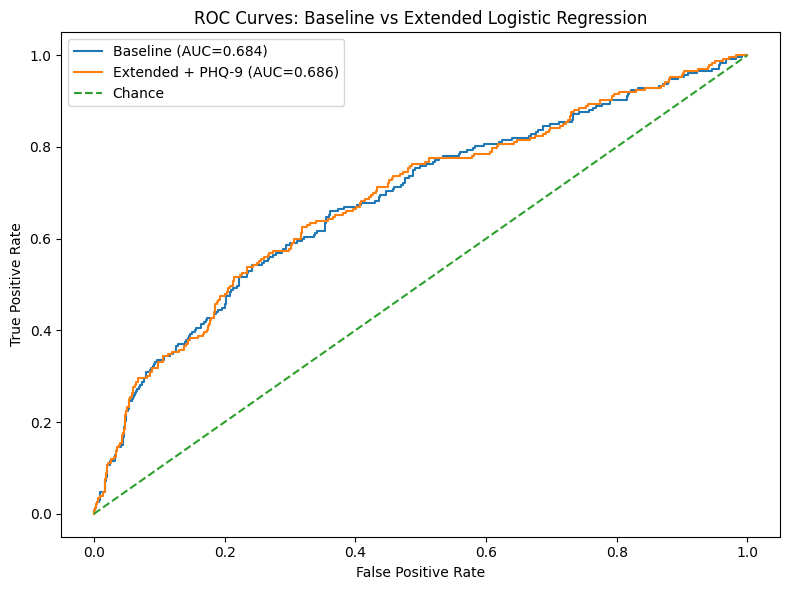

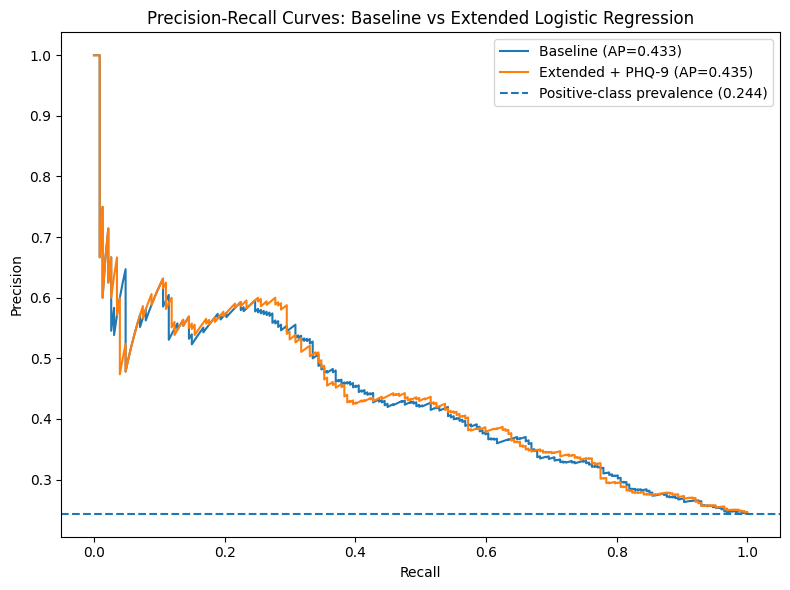


BOOTSTRAP ANALYSIS OF INCREMENTAL PHQ-9 VALUE

Observed ROC-AUC difference (Extended - Baseline): 0.00236
Bootstrap 95% CI: -0.00547 to 0.00937

Observed PR-AUC difference (Extended - Baseline): 0.00232
Bootstrap 95% CI: -0.00599 to 0.01069

PRELIMINARY INCREMENTAL-VALUE INTERPRETATION
The extended model achieved a higher test ROC-AUC than the baseline model.
The bootstrap 95% confidence interval for the ROC-AUC difference includes zero. Therefore, the observed change in discrimination may be compatible with no incremental improvement.

Bootstrap summary:
            Metric  Observed_Difference  Bootstrap_95CI_Lower  Bootstrap_95CI_Upper  Bootstrap_Iterations_Used
ROC_AUC_Difference              0.00236              -0.00547               0.00937                       2000
 PR_AUC_Difference              0.00232              -0.00599               0.01069                       2000

STEP 7C SUMMARY

Training sample: 3,725
Held-out test sample: 932

Baseline predictors:
    14

Extende

In [61]:
# =============================================================================
# STEP 7C: BASELINE VS EXTENDED LOGISTIC REGRESSION
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    make_scorer
)

print("=" * 95)
print("STEP 7C: BASELINE VS EXTENDED LOGISTIC REGRESSION")
print("=" * 95)


# =============================================================================
# 1. CREATE COMPLETE LEAKAGE-SAFE PIPELINES
# =============================================================================
#
# IMPORTANT:
# Preprocessing is contained INSIDE each pipeline.
# During cross-validation, imputation/scaling/encoding will therefore be
# re-learned independently within each training fold.
# =============================================================================

baseline_logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            baseline_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                solver="lbfgs",
                random_state=42
            )
        )
    ]
)

extended_logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            extended_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                solver="lbfgs",
                random_state=42
            )
        )
    ]
)

print("\nBaseline pipeline created.")
print("Extended pipeline created.")
print("Only additional predictor in extended model: PHQ9_TOTAL")


# =============================================================================
# 2. DEFINE STRATIFIED 5-FOLD CROSS-VALIDATION
# =============================================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("\nCross-validation design:")
print("- Stratified 5-fold cross-validation")
print("- shuffle=True")
print("- random_state=42")
print("- Conducted on training data only")


# =============================================================================
# 3. DEFINE CROSS-VALIDATION METRICS
# =============================================================================

specificity_scorer = make_scorer(
    recall_score,
    pos_label=0
)

scoring = {
    "ROC_AUC": "roc_auc",
    "PR_AUC": "average_precision",
    "Accuracy": "accuracy",
    "Balanced_Accuracy": "balanced_accuracy",
    "Sensitivity": "recall",
    "Specificity": specificity_scorer,
    "Precision": "precision",
    "F1": "f1"
}


# =============================================================================
# 4. BASELINE MODEL CROSS-VALIDATION
# =============================================================================

print("\n" + "=" * 95)
print("BASELINE LOGISTIC REGRESSION: 5-FOLD CROSS-VALIDATION")
print("=" * 95)

baseline_cv_results = cross_validate(
    baseline_logistic_pipeline,
    X_train_baseline,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)


# =============================================================================
# 5. EXTENDED MODEL CROSS-VALIDATION
# =============================================================================

print("\nRunning extended-model cross-validation...")

extended_cv_results = cross_validate(
    extended_logistic_pipeline,
    X_train_extended,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)


# =============================================================================
# 6. SUMMARIZE CROSS-VALIDATION RESULTS
# =============================================================================

metric_names = list(scoring.keys())

cv_summary_rows = []

for metric in metric_names:

    baseline_values = baseline_cv_results[
        f"test_{metric}"
    ]

    extended_values = extended_cv_results[
        f"test_{metric}"
    ]

    cv_summary_rows.append({
        "Metric": metric,
        "Baseline_Mean": baseline_values.mean(),
        "Baseline_SD": baseline_values.std(ddof=1),
        "Extended_Mean": extended_values.mean(),
        "Extended_SD": extended_values.std(ddof=1),
        "Difference_Extended_minus_Baseline":
            extended_values.mean() - baseline_values.mean()
    })

cv_summary = pd.DataFrame(cv_summary_rows)

print("\n" + "=" * 95)
print("5-FOLD CROSS-VALIDATION SUMMARY")
print("=" * 95)

print(
    cv_summary
    .round(4)
    .to_string(index=False)
)

cv_summary.to_csv(
    "Logistic_Regression_CrossValidation_Comparison.csv",
    index=False
)


# =============================================================================
# 7. DISPLAY FOLD-BY-FOLD ROC-AUC AND PR-AUC
# =============================================================================

fold_comparison = pd.DataFrame({
    "Fold": np.arange(1, 6),

    "Baseline_ROC_AUC":
        baseline_cv_results["test_ROC_AUC"],

    "Extended_ROC_AUC":
        extended_cv_results["test_ROC_AUC"],

    "Baseline_PR_AUC":
        baseline_cv_results["test_PR_AUC"],

    "Extended_PR_AUC":
        extended_cv_results["test_PR_AUC"]
})

fold_comparison[
    "ROC_AUC_Difference"
] = (
    fold_comparison["Extended_ROC_AUC"]
    - fold_comparison["Baseline_ROC_AUC"]
)

fold_comparison[
    "PR_AUC_Difference"
] = (
    fold_comparison["Extended_PR_AUC"]
    - fold_comparison["Baseline_PR_AUC"]
)

print("\n" + "=" * 95)
print("FOLD-BY-FOLD DISCRIMINATION PERFORMANCE")
print("=" * 95)

print(
    fold_comparison
    .round(4)
    .to_string(index=False)
)

fold_comparison.to_csv(
    "Logistic_Regression_Fold_Comparison.csv",
    index=False
)


# =============================================================================
# 8. FIT FINAL MODELS ON THE COMPLETE TRAINING SET
# =============================================================================

print("\n" + "=" * 95)
print("FIT FINAL MODELS ON COMPLETE TRAINING DATA")
print("=" * 95)

baseline_logistic_pipeline.fit(
    X_train_baseline,
    y_train
)

extended_logistic_pipeline.fit(
    X_train_extended,
    y_train
)

print("\nBaseline model fitted.")
print("Extended model fitted.")
print("Held-out test set has not been used for model fitting.")


# =============================================================================
# 9. GENERATE TEST-SET PREDICTIONS
# =============================================================================

baseline_test_prob = (
    baseline_logistic_pipeline
    .predict_proba(X_test_baseline)[:, 1]
)

extended_test_prob = (
    extended_logistic_pipeline
    .predict_proba(X_test_extended)[:, 1]
)

baseline_test_pred = (
    baseline_logistic_pipeline
    .predict(X_test_baseline)
)

extended_test_pred = (
    extended_logistic_pipeline
    .predict(X_test_extended)
)


# =============================================================================
# 10. HELPER FUNCTION FOR TEST METRICS
# =============================================================================

def calculate_test_metrics(
    y_true,
    predictions,
    probabilities,
    model_name
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "Model": model_name,
        "ROC_AUC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                probabilities
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "Sensitivity_Recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "True_Negatives": tn,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp
    }


# =============================================================================
# 11. CALCULATE HELD-OUT TEST PERFORMANCE
# =============================================================================

baseline_metrics = calculate_test_metrics(
    y_test,
    baseline_test_pred,
    baseline_test_prob,
    "Baseline Logistic Regression"
)

extended_metrics = calculate_test_metrics(
    y_test,
    extended_test_pred,
    extended_test_prob,
    "Extended Logistic Regression"
)

test_performance = pd.DataFrame(
    [
        baseline_metrics,
        extended_metrics
    ]
)

print("\n" + "=" * 95)
print("HELD-OUT TEST-SET PERFORMANCE")
print("=" * 95)

print(
    test_performance
    .round(4)
    .to_string(index=False)
)

test_performance.to_csv(
    "Logistic_Regression_Test_Performance.csv",
    index=False
)


# =============================================================================
# 12. INCREMENTAL PERFORMANCE FROM ADDING PHQ-9
# =============================================================================

comparison_metrics = [
    "ROC_AUC",
    "PR_AUC",
    "Accuracy",
    "Balanced_Accuracy",
    "Sensitivity_Recall",
    "Specificity",
    "Precision",
    "F1"
]

incremental_rows = []

for metric in comparison_metrics:

    baseline_value = baseline_metrics[metric]
    extended_value = extended_metrics[metric]

    incremental_rows.append({
        "Metric": metric,
        "Baseline": baseline_value,
        "Extended": extended_value,
        "Absolute_Difference":
            extended_value - baseline_value
    })

incremental_table = pd.DataFrame(
    incremental_rows
)

print("\n" + "=" * 95)
print("INCREMENTAL VALUE OF ADDING PHQ-9")
print("=" * 95)

print(
    incremental_table
    .round(4)
    .to_string(index=False)
)

incremental_table.to_csv(
    "PHQ9_Incremental_Logistic_Performance.csv",
    index=False
)


# =============================================================================
# 13. CLASSIFICATION REPORTS
# =============================================================================

print("\n" + "=" * 95)
print("BASELINE CLASSIFICATION REPORT")
print("=" * 95)

print(
    classification_report(
        y_test,
        baseline_test_pred,
        target_names=[
            "Not Healthy Weight",
            "Healthy Weight"
        ],
        digits=4,
        zero_division=0
    )
)


print("\n" + "=" * 95)
print("EXTENDED CLASSIFICATION REPORT")
print("=" * 95)

print(
    classification_report(
        y_test,
        extended_test_pred,
        target_names=[
            "Not Healthy Weight",
            "Healthy Weight"
        ],
        digits=4,
        zero_division=0
    )
)


# =============================================================================
# 14. CONFUSION MATRICES
# =============================================================================

baseline_cm = confusion_matrix(
    y_test,
    baseline_test_pred,
    labels=[0, 1]
)

extended_cm = confusion_matrix(
    y_test,
    extended_test_pred,
    labels=[0, 1]
)

print("\n" + "=" * 95)
print("CONFUSION MATRICES")
print("=" * 95)

print("\nBaseline Logistic Regression:")
print(
    pd.DataFrame(
        baseline_cm,
        index=[
            "Actual_Not_Healthy",
            "Actual_Healthy"
        ],
        columns=[
            "Predicted_Not_Healthy",
            "Predicted_Healthy"
        ]
    )
)

print("\nExtended Logistic Regression:")
print(
    pd.DataFrame(
        extended_cm,
        index=[
            "Actual_Not_Healthy",
            "Actual_Healthy"
        ],
        columns=[
            "Predicted_Not_Healthy",
            "Predicted_Healthy"
        ]
    )
)


# =============================================================================
# 15. ROC CURVES
# =============================================================================

baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_test_prob
)

extended_fpr, extended_tpr, _ = roc_curve(
    y_test,
    extended_test_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=(
        f"Baseline "
        f"(AUC={baseline_metrics['ROC_AUC']:.3f})"
    )
)

plt.plot(
    extended_fpr,
    extended_tpr,
    label=(
        f"Extended + PHQ-9 "
        f"(AUC={extended_metrics['ROC_AUC']:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "ROC Curves: Baseline vs Extended Logistic Regression"
)
plt.legend()

plt.tight_layout()

plt.savefig(
    "Logistic_Regression_ROC_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 16. PRECISION-RECALL CURVES
# =============================================================================

baseline_precision_curve, baseline_recall_curve, _ = (
    precision_recall_curve(
        y_test,
        baseline_test_prob
    )
)

extended_precision_curve, extended_recall_curve, _ = (
    precision_recall_curve(
        y_test,
        extended_test_prob
    )
)

positive_prevalence = y_test.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    baseline_recall_curve,
    baseline_precision_curve,
    label=(
        f"Baseline "
        f"(AP={baseline_metrics['PR_AUC']:.3f})"
    )
)

plt.plot(
    extended_recall_curve,
    extended_precision_curve,
    label=(
        f"Extended + PHQ-9 "
        f"(AP={extended_metrics['PR_AUC']:.3f})"
    )
)

plt.axhline(
    positive_prevalence,
    linestyle="--",
    label=(
        f"Positive-class prevalence "
        f"({positive_prevalence:.3f})"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision-Recall Curves: "
    "Baseline vs Extended Logistic Regression"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "Logistic_Regression_PR_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 17. BOOTSTRAP CONFIDENCE INTERVALS FOR INCREMENTAL PERFORMANCE
# =============================================================================
#
# Predictions are already fixed.
# We repeatedly resample the held-out test participants and calculate:
#
# Extended ROC-AUC - Baseline ROC-AUC
# Extended PR-AUC  - Baseline PR-AUC
#
# This helps assess uncertainty around the incremental value of PHQ-9.
# =============================================================================

print("\n" + "=" * 95)
print("BOOTSTRAP ANALYSIS OF INCREMENTAL PHQ-9 VALUE")
print("=" * 95)

rng = np.random.default_rng(42)

y_test_array = np.asarray(y_test)

baseline_prob_array = np.asarray(
    baseline_test_prob
)

extended_prob_array = np.asarray(
    extended_test_prob
)

n_bootstrap = 2000

roc_differences = []
pr_differences = []

n_test = len(y_test_array)

for _ in range(n_bootstrap):

    sampled_indices = rng.integers(
        0,
        n_test,
        n_test
    )

    y_boot = y_test_array[
        sampled_indices
    ]

    # ROC-AUC cannot be computed if a bootstrap
    # sample happens to contain only one class.
    if len(np.unique(y_boot)) < 2:
        continue

    baseline_boot_prob = (
        baseline_prob_array[
            sampled_indices
        ]
    )

    extended_boot_prob = (
        extended_prob_array[
            sampled_indices
        ]
    )

    baseline_boot_roc = roc_auc_score(
        y_boot,
        baseline_boot_prob
    )

    extended_boot_roc = roc_auc_score(
        y_boot,
        extended_boot_prob
    )

    baseline_boot_pr = average_precision_score(
        y_boot,
        baseline_boot_prob
    )

    extended_boot_pr = average_precision_score(
        y_boot,
        extended_boot_prob
    )

    roc_differences.append(
        extended_boot_roc
        - baseline_boot_roc
    )

    pr_differences.append(
        extended_boot_pr
        - baseline_boot_pr
    )


roc_differences = np.array(
    roc_differences
)

pr_differences = np.array(
    pr_differences
)


roc_ci_lower, roc_ci_upper = np.percentile(
    roc_differences,
    [2.5, 97.5]
)

pr_ci_lower, pr_ci_upper = np.percentile(
    pr_differences,
    [2.5, 97.5]
)


observed_roc_difference = (
    extended_metrics["ROC_AUC"]
    - baseline_metrics["ROC_AUC"]
)

observed_pr_difference = (
    extended_metrics["PR_AUC"]
    - baseline_metrics["PR_AUC"]
)


print(
    f"\nObserved ROC-AUC difference "
    f"(Extended - Baseline): "
    f"{observed_roc_difference:.5f}"
)

print(
    f"Bootstrap 95% CI: "
    f"{roc_ci_lower:.5f} to "
    f"{roc_ci_upper:.5f}"
)

print(
    f"\nObserved PR-AUC difference "
    f"(Extended - Baseline): "
    f"{observed_pr_difference:.5f}"
)

print(
    f"Bootstrap 95% CI: "
    f"{pr_ci_lower:.5f} to "
    f"{pr_ci_upper:.5f}"
)


# =============================================================================
# 18. AUTOMATED INTERPRETATION OF INCREMENTAL ROC-AUC
# =============================================================================

print("\n" + "=" * 95)
print("PRELIMINARY INCREMENTAL-VALUE INTERPRETATION")
print("=" * 95)

if observed_roc_difference > 0:

    print(
        "The extended model achieved a higher "
        "test ROC-AUC than the baseline model."
    )

elif observed_roc_difference < 0:

    print(
        "The extended model achieved a lower "
        "test ROC-AUC than the baseline model."
    )

else:

    print(
        "The extended and baseline models achieved "
        "identical test ROC-AUC values."
    )


if roc_ci_lower > 0:

    print(
        "The bootstrap 95% confidence interval for "
        "the ROC-AUC difference is entirely above zero, "
        "providing evidence of improved discrimination "
        "after adding PHQ-9."
    )

elif roc_ci_upper < 0:

    print(
        "The bootstrap 95% confidence interval for "
        "the ROC-AUC difference is entirely below zero, "
        "suggesting worse discrimination after adding PHQ-9."
    )

else:

    print(
        "The bootstrap 95% confidence interval for "
        "the ROC-AUC difference includes zero. "
        "Therefore, the observed change in discrimination "
        "may be compatible with no incremental improvement."
    )


# =============================================================================
# 19. EXPORT BOOTSTRAP RESULTS
# =============================================================================

bootstrap_summary = pd.DataFrame({
    "Metric": [
        "ROC_AUC_Difference",
        "PR_AUC_Difference"
    ],

    "Observed_Difference": [
        observed_roc_difference,
        observed_pr_difference
    ],

    "Bootstrap_95CI_Lower": [
        roc_ci_lower,
        pr_ci_lower
    ],

    "Bootstrap_95CI_Upper": [
        roc_ci_upper,
        pr_ci_upper
    ],

    "Bootstrap_Iterations_Used": [
        len(roc_differences),
        len(pr_differences)
    ]
})

bootstrap_summary.to_csv(
    "PHQ9_Incremental_Performance_Bootstrap.csv",
    index=False
)

print("\nBootstrap summary:")
print(
    bootstrap_summary
    .round(5)
    .to_string(index=False)
)


# =============================================================================
# 20. SAVE INDIVIDUAL TEST PREDICTIONS
# =============================================================================

prediction_results = pd.DataFrame({
    "Actual_HEALTHY_WEIGHT":
        np.asarray(y_test),

    "Baseline_Probability":
        baseline_test_prob,

    "Baseline_Prediction":
        baseline_test_pred,

    "Extended_Probability":
        extended_test_prob,

    "Extended_Prediction":
        extended_test_pred
})

prediction_results.index = y_test.index

prediction_results.to_csv(
    "Logistic_Regression_Test_Predictions.csv",
    index=True
)


# =============================================================================
# 21. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 95)
print("STEP 7C SUMMARY")
print("=" * 95)

print(f"""
Training sample: {len(y_train):,}
Held-out test sample: {len(y_test):,}

Baseline predictors:
    {len(final_baseline_predictors)}

Extended predictors:
    {len(final_extended_predictors)}

Only additional extended predictor:
    PHQ9_TOTAL

Cross-validation:
    Stratified 5-fold

Primary held-out metric:
    ROC-AUC

Complementary metrics:
    PR-AUC
    Accuracy
    Balanced accuracy
    Sensitivity
    Specificity
    Precision
    F1 score

Incremental-performance uncertainty:
    2,000-bootstrap 95% confidence intervals

The held-out test set was not used for model fitting,
preprocessing estimation, or cross-validation.
""")

print("\nFiles exported:")
print("- Logistic_Regression_CrossValidation_Comparison.csv")
print("- Logistic_Regression_Fold_Comparison.csv")
print("- Logistic_Regression_Test_Performance.csv")
print("- PHQ9_Incremental_Logistic_Performance.csv")
print("- PHQ9_Incremental_Performance_Bootstrap.csv")
print("- Logistic_Regression_Test_Predictions.csv")
print("- Logistic_Regression_ROC_Comparison.png")
print("- Logistic_Regression_PR_Comparison.png")

print("\nStep 7C completed.")

In [62]:
# =============================================================================
# STEP 7D: INTERIM REPORT RESULTS CONSOLIDATION
# =============================================================================

import pandas as pd
import numpy as np

print("=" * 100)
print("STEP 7D: INTERIM REPORT RESULTS CONSOLIDATION")
print("=" * 100)

# =============================================================================
# 1. RESEARCH QUESTION STATUS TABLE
# =============================================================================

rq_status = pd.DataFrame({
    "Research_Question": [
        "RQ1",
        "RQ2",
        "RQ3",
        "RQ4"
    ],
    "Research_Focus": [
        "Association between depressive symptom severity and healthy-weight status",
        "Incremental predictive value of adding PHQ-9 to demographic and lifestyle predictors",
        "Comparison of statistical and machine-learning models for healthy-weight prediction",
        "Explainability and transparency of the final predictive model"
    ],
    "Analyses_Completed": [
        (
            "Descriptive PHQ-9 comparison; Welch t-test; Mann-Whitney U test; "
            "effect sizes; PHQ-9 severity cross-tabulation; chi-square test; "
            "Cramer's V; ordinal trend analysis; adjusted multivariable logistic regression"
        ),
        (
            "Baseline vs extended Logistic Regression; leakage-safe preprocessing; "
            "5-fold stratified cross-validation; held-out test evaluation; "
            "ROC-AUC and PR-AUC comparison; bootstrap confidence intervals"
        ),
        (
            "Logistic Regression completed as preliminary benchmark"
        ),
        (
            "No formal explainability analysis completed yet"
        )
    ],
    "Current_Status": [
        "Completed - preliminary inferential analysis",
        "Completed - preliminary Logistic Regression comparison",
        "In progress",
        "Pending"
    ],
    "Key_Preliminary_Result": [
        (
            "Higher PHQ-9 scores were associated with lower odds of healthy-weight status; "
            "adjusted OR approximately 0.973 per PHQ-9 point"
        ),
        (
            "Adding PHQ-9 produced only a very small increase in Logistic Regression "
            "discrimination, with bootstrap confidence intervals including zero"
        ),
        (
            "Random Forest and XGBoost remain to be evaluated before selecting the best model"
        ),
        (
            "SHAP and related explainability analyses will be performed after final model selection"
        )
    ],
    "Remaining_Work": [
        "Final reporting and possible robustness/survey-weighted sensitivity analysis",
        "Confirm incremental value across additional model families",
        "Train and compare Random Forest and XGBoost; tune and validate models",
        "Apply SHAP/global and local explanation methods to the selected final model"
    ]
})

print("\n" + "=" * 100)
print("RESEARCH QUESTION STATUS TABLE")
print("=" * 100)

print(
    rq_status
    .to_string(index=False)
)

rq_status.to_csv(
    "Interim_Report_RQ_Status.csv",
    index=False
)


# =============================================================================
# 2. KEY PRELIMINARY FINDINGS TABLE
# =============================================================================

key_findings = pd.DataFrame({
    "Finding_ID": [
        "F1",
        "F2",
        "F3",
        "F4",
        "F5",
        "F6",
        "F7",
        "F8",
        "F9",
        "F10"
    ],
    "Research_Question": [
        "RQ1",
        "RQ1",
        "RQ1",
        "RQ1",
        "RQ1",
        "RQ2",
        "RQ2",
        "RQ2",
        "RQ2",
        "General"
    ],
    "Analysis": [
        "PHQ-9 descriptive comparison",
        "Welch independent-samples t-test",
        "Mann-Whitney U test",
        "PHQ-9 severity vs healthy-weight status",
        "Adjusted multivariable logistic regression",
        "Baseline Logistic Regression - held-out ROC-AUC",
        "Extended Logistic Regression - held-out ROC-AUC",
        "Incremental ROC-AUC from PHQ-9",
        "Incremental PR-AUC from PHQ-9",
        "Class imbalance / threshold behaviour"
    ],
    "Statistic_or_Metric": [
        "Mean PHQ-9",
        "t and p",
        "U and p",
        "Chi-square / Cramer's V",
        "Adjusted OR / 95% CI / p",
        "ROC-AUC",
        "ROC-AUC",
        "Delta ROC-AUC / Bootstrap 95% CI",
        "Delta PR-AUC / Bootstrap 95% CI",
        "Healthy-weight prevalence / sensitivity"
    ],
    "Result": [
        "Not healthy weight = 3.347; Healthy weight = 2.788",
        "t = -4.1312; p = 0.000037",
        "U = 1,866,598; p = 0.000662",
        "Chi-square = 19.4029; Cramer's V = 0.0645; p = 0.000655",
        "OR = 0.9729; 95% CI = 0.9552 to 0.9910; p = 0.003407",
        f"{baseline_metrics['ROC_AUC']:.4f}",
        f"{extended_metrics['ROC_AUC']:.4f}",
        (
            f"{observed_roc_difference:.5f}; "
            f"95% CI = {roc_ci_lower:.5f} to {roc_ci_upper:.5f}"
        ),
        (
            f"{observed_pr_difference:.5f}; "
            f"95% CI = {pr_ci_lower:.5f} to {pr_ci_upper:.5f}"
        ),
        (
            f"Healthy-weight class prevalence = {y_test.mean() * 100:.2f}%; "
            f"Extended-model sensitivity = {extended_metrics['Sensitivity_Recall']:.4f}"
        )
    ],
    "Interpretation": [
        (
            "Participants at healthy weight had lower average depressive symptom scores."
        ),
        (
            "The mean PHQ-9 difference was statistically significant."
        ),
        (
            "The non-parametric test confirmed a statistically significant distributional difference."
        ),
        (
            "Healthy-weight prevalence generally declined as PHQ-9 severity increased, "
            "but the association was very small."
        ),
        (
            "PHQ-9 remained independently associated with healthy-weight status after adjustment; "
            "each one-point increase corresponded to approximately 2.7% lower adjusted odds."
        ),
        (
            "The baseline Logistic Regression showed modest discrimination."
        ),
        (
            "Adding PHQ-9 produced only a marginal increase in discrimination."
        ),
        (
            "The ROC-AUC improvement was very small and the bootstrap confidence interval included zero."
        ),
        (
            "The PR-AUC improvement was very small and the bootstrap confidence interval included zero."
        ),
        (
            "The default 0.50 classification threshold strongly favoured the majority class; "
            "therefore accuracy alone is not an adequate performance measure."
        )
    ],
    "Interim_Report_Use": [
        "RQ1 preliminary findings",
        "RQ1 preliminary findings",
        "RQ1 preliminary findings",
        "RQ1 preliminary findings",
        "RQ1 preliminary findings",
        "RQ2 preliminary findings",
        "RQ2 preliminary findings",
        "RQ2 incremental-value conclusion",
        "RQ2 incremental-value conclusion",
        "Limitations / model-performance interpretation"
    ]
})

print("\n" + "=" * 100)
print("KEY PRELIMINARY FINDINGS TABLE")
print("=" * 100)

print(
    key_findings
    .to_string(index=False)
)

key_findings.to_csv(
    "Interim_Report_Key_Preliminary_Findings.csv",
    index=False
)


# =============================================================================
# 3. PRELIMINARY LOGISTIC REGRESSION PERFORMANCE TABLE
# =============================================================================

# Reuse the Step 7C performance values already stored in:
# baseline_metrics
# extended_metrics

preliminary_lr_performance = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Extended Logistic Regression + PHQ-9"
    ],
    "Feature_Set": [
        "14 demographic, socioeconomic, activity, sedentary, sleep, and dietary predictors",
        "Same 14 predictors + PHQ9_TOTAL"
    ],
    "Validation_Approach": [
        "5-fold stratified cross-validation + 20% held-out test set",
        "5-fold stratified cross-validation + 20% held-out test set"
    ],
    "Test_ROC_AUC": [
        baseline_metrics["ROC_AUC"],
        extended_metrics["ROC_AUC"]
    ],
    "Test_PR_AUC": [
        baseline_metrics["PR_AUC"],
        extended_metrics["PR_AUC"]
    ],
    "Accuracy": [
        baseline_metrics["Accuracy"],
        extended_metrics["Accuracy"]
    ],
    "Balanced_Accuracy": [
        baseline_metrics["Balanced_Accuracy"],
        extended_metrics["Balanced_Accuracy"]
    ],
    "Sensitivity_Recall": [
        baseline_metrics["Sensitivity_Recall"],
        extended_metrics["Sensitivity_Recall"]
    ],
    "Specificity": [
        baseline_metrics["Specificity"],
        extended_metrics["Specificity"]
    ],
    "Precision": [
        baseline_metrics["Precision"],
        extended_metrics["Precision"]
    ],
    "F1": [
        baseline_metrics["F1"],
        extended_metrics["F1"]
    ],
    "True_Negatives": [
        baseline_metrics["True_Negatives"],
        extended_metrics["True_Negatives"]
    ],
    "False_Positives": [
        baseline_metrics["False_Positives"],
        extended_metrics["False_Positives"]
    ],
    "False_Negatives": [
        baseline_metrics["False_Negatives"],
        extended_metrics["False_Negatives"]
    ],
    "True_Positives": [
        baseline_metrics["True_Positives"],
        extended_metrics["True_Positives"]
    ]
})

print("\n" + "=" * 100)
print("PRELIMINARY LOGISTIC REGRESSION PERFORMANCE TABLE")
print("=" * 100)

print(
    preliminary_lr_performance
    .round(4)
    .to_string(index=False)
)

preliminary_lr_performance.to_csv(
    "Interim_Report_Preliminary_Logistic_Performance.csv",
    index=False
)


# =============================================================================
# 4. INCREMENTAL PHQ-9 SUMMARY TABLE
# =============================================================================

incremental_phq9_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Accuracy",
        "Balanced Accuracy",
        "Sensitivity / Recall",
        "Specificity",
        "Precision",
        "F1"
    ],
    "Baseline": [
        baseline_metrics["ROC_AUC"],
        baseline_metrics["PR_AUC"],
        baseline_metrics["Accuracy"],
        baseline_metrics["Balanced_Accuracy"],
        baseline_metrics["Sensitivity_Recall"],
        baseline_metrics["Specificity"],
        baseline_metrics["Precision"],
        baseline_metrics["F1"]
    ],
    "Extended_PHQ9": [
        extended_metrics["ROC_AUC"],
        extended_metrics["PR_AUC"],
        extended_metrics["Accuracy"],
        extended_metrics["Balanced_Accuracy"],
        extended_metrics["Sensitivity_Recall"],
        extended_metrics["Specificity"],
        extended_metrics["Precision"],
        extended_metrics["F1"]
    ]
})

incremental_phq9_summary[
    "Difference_Extended_minus_Baseline"
] = (
    incremental_phq9_summary["Extended_PHQ9"]
    - incremental_phq9_summary["Baseline"]
)

# Add bootstrap CIs only where they are available
incremental_phq9_summary[
    "Bootstrap_95CI_Lower"
] = np.nan

incremental_phq9_summary[
    "Bootstrap_95CI_Upper"
] = np.nan

incremental_phq9_summary.loc[
    incremental_phq9_summary["Metric"] == "ROC-AUC",
    "Bootstrap_95CI_Lower"
] = roc_ci_lower

incremental_phq9_summary.loc[
    incremental_phq9_summary["Metric"] == "ROC-AUC",
    "Bootstrap_95CI_Upper"
] = roc_ci_upper

incremental_phq9_summary.loc[
    incremental_phq9_summary["Metric"] == "PR-AUC",
    "Bootstrap_95CI_Lower"
] = pr_ci_lower

incremental_phq9_summary.loc[
    incremental_phq9_summary["Metric"] == "PR-AUC",
    "Bootstrap_95CI_Upper"
] = pr_ci_upper

print("\n" + "=" * 100)
print("INCREMENTAL PHQ-9 PERFORMANCE SUMMARY")
print("=" * 100)

print(
    incremental_phq9_summary
    .round(5)
    .to_string(index=False)
)

incremental_phq9_summary.to_csv(
    "Interim_Report_PHQ9_Incremental_Performance.csv",
    index=False
)


# =============================================================================
# 5. INTERIM PROJECT STATUS SUMMARY
# =============================================================================

interim_project_status = pd.DataFrame({
    "Category": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "In Progress",
        "In Progress",
        "Pending",
        "Pending"
    ],
    "Activity": [
        "NHANES data acquisition and merging",
        "Cohort construction and target definition",
        "Data cleaning, missingness audit, and leakage review",
        "Detailed exploratory data analysis",
        "RQ1 inferential analysis and preliminary RQ2 Logistic Regression comparison",
        "Random Forest modelling",
        "XGBoost modelling",
        "Final comparative model selection and tuning",
        "Explainable AI / SHAP analysis"
    ],
    "Evidence": [
        "Merged NHANES analytical dataset",
        "Final N = 4,657 participants",
        "Cleaning logs, missing-data summaries, and predictor-quality audits",
        "EDA tables and figures",
        "Steps 6A-6C and 7A-7C",
        "Planned for next modelling phase",
        "Planned for next modelling phase",
        "To follow comparison of all planned models",
        "To be performed on selected final model"
    ]
})

print("\n" + "=" * 100)
print("INTERIM PROJECT STATUS SUMMARY")
print("=" * 100)

print(
    interim_project_status
    .to_string(index=False)
)

interim_project_status.to_csv(
    "Interim_Report_Project_Status.csv",
    index=False
)


# =============================================================================
# 6. CONSOLIDATED EXPORT LIST
# =============================================================================

exported_files = [
    "Interim_Report_RQ_Status.csv",
    "Interim_Report_Key_Preliminary_Findings.csv",
    "Interim_Report_Preliminary_Logistic_Performance.csv",
    "Interim_Report_PHQ9_Incremental_Performance.csv",
    "Interim_Report_Project_Status.csv"
]

print("\n" + "=" * 100)
print("FILES EXPORTED FOR INTERIM REPORT / GITHUB")
print("=" * 100)

for filename in exported_files:
    print(f"- {filename}")


# =============================================================================
# 7. FINAL VALIDATION
# =============================================================================

assert len(rq_status) == 4
assert len(preliminary_lr_performance) == 2
assert "PHQ9_TOTAL" in final_extended_predictors
assert "PHQ9_TOTAL" not in final_baseline_predictors

print("\n" + "=" * 100)
print("STEP 7D VALIDATION SUMMARY")
print("=" * 100)

print("""
1. Research Question Status table created.
2. Key Preliminary Findings table created.
3. Preliminary Logistic Regression performance table created.
4. Incremental PHQ-9 performance summary created.
5. Interim project-status table created.
6. No additional model was trained.
7. All results were consolidated from previously completed analyses.
8. Tables are ready for Interim Report drafting and GitHub documentation.
""")

print("Step 7D completed.")

STEP 7D: INTERIM REPORT RESULTS CONSOLIDATION

RESEARCH QUESTION STATUS TABLE
Research_Question                                                                       Research_Focus                                                                                                                                                                                              Analyses_Completed                                         Current_Status                                                                                                                     Key_Preliminary_Result                                                               Remaining_Work
              RQ1            Association between depressive symptom severity and healthy-weight status Descriptive PHQ-9 comparison; Welch t-test; Mann-Whitney U test; effect sizes; PHQ-9 severity cross-tabulation; chi-square test; Cramer's V; ordinal trend analysis; adjusted multivariable logistic regression           Completed - prelimi

In [63]:
# =============================================================================
# STEP 8A: BASELINE VS EXTENDED RANDOM FOREST
# =============================================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 100)
print("STEP 8A: BASELINE VS EXTENDED RANDOM FOREST")
print("=" * 100)


# =============================================================================
# 1. CREATE RANDOM FOREST PIPELINES
# =============================================================================
#
# We retain preprocessing inside the pipeline so that during cross-validation
# imputation and encoding are learned only from the training fold.
#
# class_weight='balanced' is used because HEALTHY_WEIGHT is imbalanced
# (approximately 24% healthy weight vs 76% not healthy weight).
# =============================================================================

baseline_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            baseline_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

extended_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            extended_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

print("\nRandom Forest pipelines created.")
print("Baseline predictors:", len(final_baseline_predictors))
print("Extended predictors:", len(final_extended_predictors))
print("Only additional predictor in extended model: PHQ9_TOTAL")


# =============================================================================
# 2. DEFINE A COMPACT HYPERPARAMETER GRID
# =============================================================================
#
# The grid is intentionally focused on the most influential RF parameters.
# This provides meaningful tuning without making the capstone unnecessarily
# computationally expensive.
# =============================================================================

rf_param_grid = {
    "classifier__n_estimators": [300, 500],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
    "classifier__max_features": ["sqrt"]
}

print("\nHyperparameter grid:")
for parameter, values in rf_param_grid.items():
    print(f" - {parameter}: {values}")


# =============================================================================
# 3. BASELINE RANDOM FOREST: 5-FOLD STRATIFIED GRID SEARCH
# =============================================================================
#
# ROC-AUC is used as the primary tuning criterion.
# The same stratified CV object ('cv') created in Step 7C is reused.
# =============================================================================

print("\n" + "=" * 100)
print("BASELINE RANDOM FOREST: HYPERPARAMETER TUNING")
print("=" * 100)

baseline_rf_grid = GridSearchCV(
    estimator=baseline_rf_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

baseline_rf_grid.fit(
    X_train_baseline,
    y_train
)

print("\nBaseline tuning complete.")

print("\nBest baseline parameters:")
for parameter, value in baseline_rf_grid.best_params_.items():
    print(f" - {parameter}: {value}")

print(
    f"\nBest baseline mean CV ROC-AUC: "
    f"{baseline_rf_grid.best_score_:.4f}"
)


# =============================================================================
# 4. EXTENDED RANDOM FOREST: 5-FOLD STRATIFIED GRID SEARCH
# =============================================================================

print("\n" + "=" * 100)
print("EXTENDED RANDOM FOREST: HYPERPARAMETER TUNING")
print("=" * 100)

extended_rf_grid = GridSearchCV(
    estimator=extended_rf_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

extended_rf_grid.fit(
    X_train_extended,
    y_train
)

print("\nExtended tuning complete.")

print("\nBest extended parameters:")
for parameter, value in extended_rf_grid.best_params_.items():
    print(f" - {parameter}: {value}")

print(
    f"\nBest extended mean CV ROC-AUC: "
    f"{extended_rf_grid.best_score_:.4f}"
)


# =============================================================================
# 5. RETRIEVE BEST MODELS
# =============================================================================

best_baseline_rf = baseline_rf_grid.best_estimator_
best_extended_rf = extended_rf_grid.best_estimator_


# =============================================================================
# 6. GENERATE HELD-OUT TEST PREDICTIONS
# =============================================================================
#
# IMPORTANT:
# The test set has remained completely untouched during tuning.
# =============================================================================

baseline_rf_test_prob = (
    best_baseline_rf
    .predict_proba(X_test_baseline)[:, 1]
)

extended_rf_test_prob = (
    best_extended_rf
    .predict_proba(X_test_extended)[:, 1]
)

baseline_rf_test_pred = (
    best_baseline_rf
    .predict(X_test_baseline)
)

extended_rf_test_pred = (
    best_extended_rf
    .predict(X_test_extended)
)


# =============================================================================
# 7. HELPER FUNCTION FOR TEST-SET METRICS
# =============================================================================

def calculate_rf_test_metrics(
    y_true,
    predictions,
    probabilities,
    model_name
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "Model": model_name,

        "ROC_AUC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                probabilities
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "Sensitivity_Recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            )
    }


# =============================================================================
# 8. CALCULATE TEST-SET PERFORMANCE
# =============================================================================

baseline_rf_metrics = calculate_rf_test_metrics(
    y_test,
    baseline_rf_test_pred,
    baseline_rf_test_prob,
    "Random Forest - Baseline"
)

extended_rf_metrics = calculate_rf_test_metrics(
    y_test,
    extended_rf_test_pred,
    extended_rf_test_prob,
    "Random Forest - Extended (+PHQ-9)"
)

rf_test_comparison = pd.DataFrame([
    baseline_rf_metrics,
    extended_rf_metrics
])

print("\n" + "=" * 100)
print("RANDOM FOREST: HELD-OUT TEST PERFORMANCE")
print("=" * 100)

print(
    rf_test_comparison
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 9. CALCULATE EXTENDED MINUS BASELINE DIFFERENCES
# =============================================================================

rf_metric_difference = pd.DataFrame({
    "Metric": [
        "ROC_AUC",
        "PR_AUC",
        "Accuracy",
        "Balanced_Accuracy",
        "Sensitivity_Recall",
        "Specificity",
        "Precision",
        "F1"
    ]
})

rf_metric_difference["Baseline"] = [
    baseline_rf_metrics[m]
    for m in rf_metric_difference["Metric"]
]

rf_metric_difference["Extended"] = [
    extended_rf_metrics[m]
    for m in rf_metric_difference["Metric"]
]

rf_metric_difference["Extended_minus_Baseline"] = (
    rf_metric_difference["Extended"]
    - rf_metric_difference["Baseline"]
)

print("\n" + "=" * 100)
print("INCREMENTAL EFFECT OF ADDING PHQ-9 TO RANDOM FOREST")
print("=" * 100)

print(
    rf_metric_difference
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 10. SAVE RESULTS
# =============================================================================

rf_test_comparison.to_csv(
    "Random_Forest_Test_Set_Comparison.csv",
    index=False
)

rf_metric_difference.to_csv(
    "Random_Forest_PHQ9_Incremental_Comparison.csv",
    index=False
)

rf_best_parameters = pd.DataFrame({
    "Specification": [
        "Baseline",
        "Extended (+PHQ-9)"
    ],
    "Best_CV_ROC_AUC": [
        baseline_rf_grid.best_score_,
        extended_rf_grid.best_score_
    ],
    "Best_Parameters": [
        str(baseline_rf_grid.best_params_),
        str(extended_rf_grid.best_params_)
    ]
})

rf_best_parameters.to_csv(
    "Random_Forest_Best_Parameters.csv",
    index=False
)


# =============================================================================
# 11. FINAL STEP 8A SUMMARY
# =============================================================================

print("\n" + "=" * 100)
print("STEP 8A SUMMARY")
print("=" * 100)

print(
    f"""
Baseline Random Forest
----------------------
Best CV ROC-AUC:       {baseline_rf_grid.best_score_:.4f}
Test ROC-AUC:          {baseline_rf_metrics['ROC_AUC']:.4f}
Test PR-AUC:           {baseline_rf_metrics['PR_AUC']:.4f}
Balanced Accuracy:     {baseline_rf_metrics['Balanced_Accuracy']:.4f}

Extended Random Forest (+PHQ-9)
-------------------------------
Best CV ROC-AUC:       {extended_rf_grid.best_score_:.4f}
Test ROC-AUC:          {extended_rf_metrics['ROC_AUC']:.4f}
Test PR-AUC:           {extended_rf_metrics['PR_AUC']:.4f}
Balanced Accuracy:     {extended_rf_metrics['Balanced_Accuracy']:.4f}

Incremental Test ROC-AUC from PHQ-9:
{extended_rf_metrics['ROC_AUC'] - baseline_rf_metrics['ROC_AUC']:+.4f}

Incremental Test PR-AUC from PHQ-9:
{extended_rf_metrics['PR_AUC'] - baseline_rf_metrics['PR_AUC']:+.4f}
"""
)

print("Step 8A complete.")

STEP 8A: BASELINE VS EXTENDED RANDOM FOREST

Random Forest pipelines created.
Baseline predictors: 14
Extended predictors: 15
Only additional predictor in extended model: PHQ9_TOTAL

Hyperparameter grid:
 - classifier__n_estimators: [300, 500]
 - classifier__max_depth: [None, 10, 20]
 - classifier__min_samples_split: [2, 5]
 - classifier__min_samples_leaf: [1, 2]
 - classifier__max_features: ['sqrt']

BASELINE RANDOM FOREST: HYPERPARAMETER TUNING

Baseline tuning complete.

Best baseline parameters:
 - classifier__max_depth: 20
 - classifier__max_features: sqrt
 - classifier__min_samples_leaf: 2
 - classifier__min_samples_split: 2
 - classifier__n_estimators: 300

Best baseline mean CV ROC-AUC: 0.6662

EXTENDED RANDOM FOREST: HYPERPARAMETER TUNING

Extended tuning complete.

Best extended parameters:
 - classifier__max_depth: None
 - classifier__max_features: sqrt
 - classifier__min_samples_leaf: 2
 - classifier__min_samples_split: 2
 - classifier__n_estimators: 300

Best extended mean

In [64]:
# =============================================================================
# STEP 8B: BASELINE VS EXTENDED XGBOOST
# =============================================================================

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 100)
print("STEP 8B: BASELINE VS EXTENDED XGBOOST")
print("=" * 100)


# =============================================================================
# 1. CALCULATE CLASS-IMBALANCE WEIGHT
# =============================================================================
#
# XGBoost uses scale_pos_weight rather than sklearn's class_weight='balanced'.
# HEALTHY_WEIGHT = 1 is the minority class.
#
# scale_pos_weight = number of negative cases / number of positive cases
# calculated ONLY from the training set.
# =============================================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("\nTraining-set class counts:")
print(f"Negative / not healthy weight (0): {negative_count}")
print(f"Positive / healthy weight (1):     {positive_count}")
print(f"scale_pos_weight:                  {scale_pos_weight:.4f}")


# =============================================================================
# 2. CREATE XGBOOST PIPELINES
# =============================================================================

baseline_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            baseline_preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist",
                scale_pos_weight=scale_pos_weight
            )
        )
    ]
)

extended_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            extended_preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist",
                scale_pos_weight=scale_pos_weight
            )
        )
    ]
)

print("\nXGBoost pipelines created.")
print("Baseline predictors:", len(final_baseline_predictors))
print("Extended predictors:", len(final_extended_predictors))
print("Only additional predictor in extended model: PHQ9_TOTAL")


# =============================================================================
# 3. DEFINE COMPACT HYPERPARAMETER GRID
# =============================================================================
#
# Focused grid to tune the most influential XGBoost parameters while keeping
# computation manageable for the capstone.
# =============================================================================

xgb_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.03, 0.10],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

print("\nHyperparameter grid:")
for parameter, values in xgb_param_grid.items():
    print(f" - {parameter}: {values}")


# =============================================================================
# 4. BASELINE XGBOOST: 5-FOLD STRATIFIED GRID SEARCH
# =============================================================================

print("\n" + "=" * 100)
print("BASELINE XGBOOST: HYPERPARAMETER TUNING")
print("=" * 100)

baseline_xgb_grid = GridSearchCV(
    estimator=baseline_xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

baseline_xgb_grid.fit(
    X_train_baseline,
    y_train
)

print("\nBaseline XGBoost tuning complete.")

print("\nBest baseline parameters:")
for parameter, value in baseline_xgb_grid.best_params_.items():
    print(f" - {parameter}: {value}")

print(
    f"\nBest baseline mean CV ROC-AUC: "
    f"{baseline_xgb_grid.best_score_:.4f}"
)


# =============================================================================
# 5. EXTENDED XGBOOST: 5-FOLD STRATIFIED GRID SEARCH
# =============================================================================

print("\n" + "=" * 100)
print("EXTENDED XGBOOST: HYPERPARAMETER TUNING")
print("=" * 100)

extended_xgb_grid = GridSearchCV(
    estimator=extended_xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

extended_xgb_grid.fit(
    X_train_extended,
    y_train
)

print("\nExtended XGBoost tuning complete.")

print("\nBest extended parameters:")
for parameter, value in extended_xgb_grid.best_params_.items():
    print(f" - {parameter}: {value}")

print(
    f"\nBest extended mean CV ROC-AUC: "
    f"{extended_xgb_grid.best_score_:.4f}"
)


# =============================================================================
# 6. RETRIEVE BEST MODELS
# =============================================================================

best_baseline_xgb = baseline_xgb_grid.best_estimator_
best_extended_xgb = extended_xgb_grid.best_estimator_


# =============================================================================
# 7. HELD-OUT TEST PREDICTIONS
# =============================================================================

baseline_xgb_test_prob = (
    best_baseline_xgb
    .predict_proba(X_test_baseline)[:, 1]
)

extended_xgb_test_prob = (
    best_extended_xgb
    .predict_proba(X_test_extended)[:, 1]
)

baseline_xgb_test_pred = (
    best_baseline_xgb
    .predict(X_test_baseline)
)

extended_xgb_test_pred = (
    best_extended_xgb
    .predict(X_test_extended)
)


# =============================================================================
# 8. HELPER FUNCTION FOR TEST METRICS
# =============================================================================

def calculate_xgb_test_metrics(
    y_true,
    predictions,
    probabilities,
    model_name
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "Model": model_name,

        "ROC_AUC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                probabilities
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "Sensitivity_Recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            )
    }


# =============================================================================
# 9. CALCULATE HELD-OUT TEST PERFORMANCE
# =============================================================================

baseline_xgb_metrics = calculate_xgb_test_metrics(
    y_test,
    baseline_xgb_test_pred,
    baseline_xgb_test_prob,
    "XGBoost - Baseline"
)

extended_xgb_metrics = calculate_xgb_test_metrics(
    y_test,
    extended_xgb_test_pred,
    extended_xgb_test_prob,
    "XGBoost - Extended (+PHQ-9)"
)

xgb_test_comparison = pd.DataFrame([
    baseline_xgb_metrics,
    extended_xgb_metrics
])

print("\n" + "=" * 100)
print("XGBOOST: HELD-OUT TEST PERFORMANCE")
print("=" * 100)

print(
    xgb_test_comparison
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 10. INCREMENTAL EFFECT OF PHQ-9
# =============================================================================

xgb_metric_difference = pd.DataFrame({
    "Metric": [
        "ROC_AUC",
        "PR_AUC",
        "Accuracy",
        "Balanced_Accuracy",
        "Sensitivity_Recall",
        "Specificity",
        "Precision",
        "F1"
    ]
})

xgb_metric_difference["Baseline"] = [
    baseline_xgb_metrics[m]
    for m in xgb_metric_difference["Metric"]
]

xgb_metric_difference["Extended"] = [
    extended_xgb_metrics[m]
    for m in xgb_metric_difference["Metric"]
]

xgb_metric_difference["Extended_minus_Baseline"] = (
    xgb_metric_difference["Extended"]
    - xgb_metric_difference["Baseline"]
)

print("\n" + "=" * 100)
print("INCREMENTAL EFFECT OF ADDING PHQ-9 TO XGBOOST")
print("=" * 100)

print(
    xgb_metric_difference
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 11. SAVE RESULTS
# =============================================================================

xgb_test_comparison.to_csv(
    "XGBoost_Test_Set_Comparison.csv",
    index=False
)

xgb_metric_difference.to_csv(
    "XGBoost_PHQ9_Incremental_Comparison.csv",
    index=False
)

xgb_best_parameters = pd.DataFrame({
    "Specification": [
        "Baseline",
        "Extended (+PHQ-9)"
    ],
    "Best_CV_ROC_AUC": [
        baseline_xgb_grid.best_score_,
        extended_xgb_grid.best_score_
    ],
    "Best_Parameters": [
        str(baseline_xgb_grid.best_params_),
        str(extended_xgb_grid.best_params_)
    ]
})

xgb_best_parameters.to_csv(
    "XGBoost_Best_Parameters.csv",
    index=False
)


# =============================================================================
# 12. STEP 8B SUMMARY
# =============================================================================

print("\n" + "=" * 100)
print("STEP 8B SUMMARY")
print("=" * 100)

print(
    f"""
Baseline XGBoost
----------------
Best CV ROC-AUC:       {baseline_xgb_grid.best_score_:.4f}
Test ROC-AUC:          {baseline_xgb_metrics['ROC_AUC']:.4f}
Test PR-AUC:           {baseline_xgb_metrics['PR_AUC']:.4f}
Balanced Accuracy:     {baseline_xgb_metrics['Balanced_Accuracy']:.4f}

Extended XGBoost (+PHQ-9)
-------------------------
Best CV ROC-AUC:       {extended_xgb_grid.best_score_:.4f}
Test ROC-AUC:          {extended_xgb_metrics['ROC_AUC']:.4f}
Test PR-AUC:           {extended_xgb_metrics['PR_AUC']:.4f}
Balanced Accuracy:     {extended_xgb_metrics['Balanced_Accuracy']:.4f}

Incremental Test ROC-AUC from PHQ-9:
{extended_xgb_metrics['ROC_AUC'] - baseline_xgb_metrics['ROC_AUC']:+.4f}

Incremental Test PR-AUC from PHQ-9:
{extended_xgb_metrics['PR_AUC'] - baseline_xgb_metrics['PR_AUC']:+.4f}
"""
)

print("Step 8B complete.")

STEP 8B: BASELINE VS EXTENDED XGBOOST

Training-set class counts:
Negative / not healthy weight (0): 2818
Positive / healthy weight (1):     907
scale_pos_weight:                  3.1069

XGBoost pipelines created.
Baseline predictors: 14
Extended predictors: 15
Only additional predictor in extended model: PHQ9_TOTAL

Hyperparameter grid:
 - classifier__n_estimators: [200, 400]
 - classifier__max_depth: [3, 5]
 - classifier__learning_rate: [0.03, 0.1]
 - classifier__subsample: [0.8, 1.0]
 - classifier__colsample_bytree: [0.8, 1.0]

BASELINE XGBOOST: HYPERPARAMETER TUNING

Baseline XGBoost tuning complete.

Best baseline parameters:
 - classifier__colsample_bytree: 0.8
 - classifier__learning_rate: 0.03
 - classifier__max_depth: 3
 - classifier__n_estimators: 200
 - classifier__subsample: 0.8

Best baseline mean CV ROC-AUC: 0.6677

EXTENDED XGBOOST: HYPERPARAMETER TUNING

Extended XGBoost tuning complete.

Best extended parameters:
 - classifier__colsample_bytree: 1.0
 - classifier__lea

STEP 8C: FINAL MODEL COMPARISON AND MODEL SELECTION

FINAL HELD-OUT MODEL COMPARISON
              Model     Specification PHQ9_Included  CV_ROC_AUC  Test_ROC_AUC  Test_PR_AUC  Accuracy  Balanced_Accuracy  Sensitivity_Recall  Specificity  Precision     F1
            XGBoost          Baseline            No      0.6677        0.7109       0.4477    0.7028             0.6572              0.5683       0.7461     0.4188 0.4822
            XGBoost Extended (+PHQ-9)           Yes      0.6654        0.7107       0.4494    0.7017             0.6580              0.5727       0.7433     0.4180 0.4833
      Random Forest Extended (+PHQ-9)           Yes      0.6677        0.7092       0.4605    0.7704             0.5809              0.2115       0.9504     0.5783 0.3097
      Random Forest          Baseline            No      0.6662        0.7068       0.4553    0.7629             0.5774              0.2159       0.9390     0.5326 0.3072
Logistic Regression Extended (+PHQ-9)           Yes      0.6

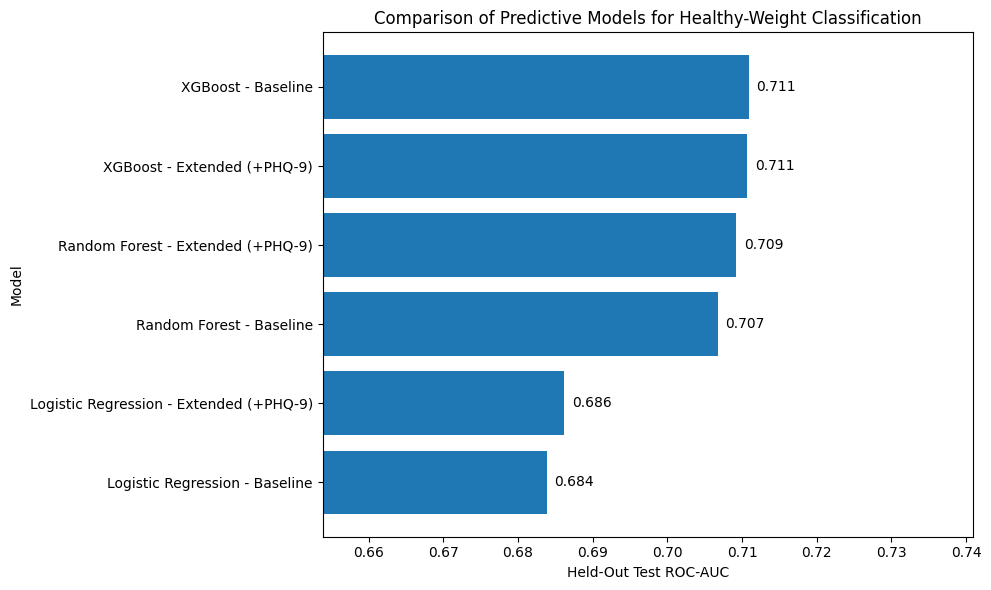


INCREMENTAL PREDICTIVE VALUE OF PHQ-9 ACROSS MODEL FAMILIES
              Model  Baseline_ROC_AUC  Extended_ROC_AUC  ROC_AUC_Change  Baseline_PR_AUC  Extended_PR_AUC  PR_AUC_Change
Logistic Regression            0.6838            0.6862          0.0024           0.4331           0.4355         0.0023
      Random Forest            0.7068            0.7092          0.0024           0.4553           0.4605         0.0052
            XGBoost            0.7109            0.7107         -0.0002           0.4477           0.4494         0.0017

RQ3 INTERPRETATION

Among the evaluated statistical and machine-learning models,
XGBoost (Baseline) achieved the highest
held-out ROC-AUC (0.7109).

The final model selection is therefore based primarily on held-out
ROC-AUC, while PR-AUC, balanced accuracy, sensitivity, specificity,
precision, and F1 are considered complementary indicators because
the outcome classes are imbalanced.


PHQ-9 INCREMENTAL-VALUE SUMMARY
Logistic Regression: ROC-AUC incre

In [65]:
# =============================================================================
# STEP 8C: FINAL MODEL COMPARISON AND MODEL SELECTION
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 100)
print("STEP 8C: FINAL MODEL COMPARISON AND MODEL SELECTION")
print("=" * 100)


# =============================================================================
# 1. CREATE FINAL COMPARISON TABLE
# =============================================================================

final_model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Specification": "Baseline",
        "PHQ9_Included": "No",
        "CV_ROC_AUC": baseline_cv_results["test_ROC_AUC"].mean(),
        "Test_ROC_AUC": baseline_metrics["ROC_AUC"],
        "Test_PR_AUC": baseline_metrics["PR_AUC"],
        "Accuracy": baseline_metrics["Accuracy"],
        "Balanced_Accuracy": baseline_metrics["Balanced_Accuracy"],
        "Sensitivity_Recall": baseline_metrics["Sensitivity_Recall"],
        "Specificity": baseline_metrics["Specificity"],
        "Precision": baseline_metrics["Precision"],
        "F1": baseline_metrics["F1"]
    },

    {
        "Model": "Logistic Regression",
        "Specification": "Extended (+PHQ-9)",
        "PHQ9_Included": "Yes",
        "CV_ROC_AUC": extended_cv_results["test_ROC_AUC"].mean(),
        "Test_ROC_AUC": extended_metrics["ROC_AUC"],
        "Test_PR_AUC": extended_metrics["PR_AUC"],
        "Accuracy": extended_metrics["Accuracy"],
        "Balanced_Accuracy": extended_metrics["Balanced_Accuracy"],
        "Sensitivity_Recall": extended_metrics["Sensitivity_Recall"],
        "Specificity": extended_metrics["Specificity"],
        "Precision": extended_metrics["Precision"],
        "F1": extended_metrics["F1"]
    },

    {
        "Model": "Random Forest",
        "Specification": "Baseline",
        "PHQ9_Included": "No",
        "CV_ROC_AUC": baseline_rf_grid.best_score_,
        "Test_ROC_AUC": baseline_rf_metrics["ROC_AUC"],
        "Test_PR_AUC": baseline_rf_metrics["PR_AUC"],
        "Accuracy": baseline_rf_metrics["Accuracy"],
        "Balanced_Accuracy": baseline_rf_metrics["Balanced_Accuracy"],
        "Sensitivity_Recall": baseline_rf_metrics["Sensitivity_Recall"],
        "Specificity": baseline_rf_metrics["Specificity"],
        "Precision": baseline_rf_metrics["Precision"],
        "F1": baseline_rf_metrics["F1"]
    },

    {
        "Model": "Random Forest",
        "Specification": "Extended (+PHQ-9)",
        "PHQ9_Included": "Yes",
        "CV_ROC_AUC": extended_rf_grid.best_score_,
        "Test_ROC_AUC": extended_rf_metrics["ROC_AUC"],
        "Test_PR_AUC": extended_rf_metrics["PR_AUC"],
        "Accuracy": extended_rf_metrics["Accuracy"],
        "Balanced_Accuracy": extended_rf_metrics["Balanced_Accuracy"],
        "Sensitivity_Recall": extended_rf_metrics["Sensitivity_Recall"],
        "Specificity": extended_rf_metrics["Specificity"],
        "Precision": extended_rf_metrics["Precision"],
        "F1": extended_rf_metrics["F1"]
    },

    {
        "Model": "XGBoost",
        "Specification": "Baseline",
        "PHQ9_Included": "No",
        "CV_ROC_AUC": baseline_xgb_grid.best_score_,
        "Test_ROC_AUC": baseline_xgb_metrics["ROC_AUC"],
        "Test_PR_AUC": baseline_xgb_metrics["PR_AUC"],
        "Accuracy": baseline_xgb_metrics["Accuracy"],
        "Balanced_Accuracy": baseline_xgb_metrics["Balanced_Accuracy"],
        "Sensitivity_Recall": baseline_xgb_metrics["Sensitivity_Recall"],
        "Specificity": baseline_xgb_metrics["Specificity"],
        "Precision": baseline_xgb_metrics["Precision"],
        "F1": baseline_xgb_metrics["F1"]
    },

    {
        "Model": "XGBoost",
        "Specification": "Extended (+PHQ-9)",
        "PHQ9_Included": "Yes",
        "CV_ROC_AUC": extended_xgb_grid.best_score_,
        "Test_ROC_AUC": extended_xgb_metrics["ROC_AUC"],
        "Test_PR_AUC": extended_xgb_metrics["PR_AUC"],
        "Accuracy": extended_xgb_metrics["Accuracy"],
        "Balanced_Accuracy": extended_xgb_metrics["Balanced_Accuracy"],
        "Sensitivity_Recall": extended_xgb_metrics["Sensitivity_Recall"],
        "Specificity": extended_xgb_metrics["Specificity"],
        "Precision": extended_xgb_metrics["Precision"],
        "F1": extended_xgb_metrics["F1"]
    }
])


# =============================================================================
# 2. SORT BY PRIMARY PERFORMANCE METRIC
# =============================================================================

final_model_comparison = (
    final_model_comparison
    .sort_values(
        by="Test_ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("FINAL HELD-OUT MODEL COMPARISON")
print("=" * 100)

print(
    final_model_comparison
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 3. IDENTIFY BEST MODEL BY HELD-OUT ROC-AUC
# =============================================================================

best_model_row = final_model_comparison.iloc[0]

best_model_name = best_model_row["Model"]
best_model_specification = best_model_row["Specification"]
best_model_roc_auc = best_model_row["Test_ROC_AUC"]

print("\n" + "=" * 100)
print("PRIMARY MODEL SELECTION")
print("=" * 100)

print(
    f"""
Selected model based on highest held-out test ROC-AUC:

Model:          {best_model_name}
Specification:  {best_model_specification}
Test ROC-AUC:   {best_model_roc_auc:.4f}
PR-AUC:         {best_model_row['Test_PR_AUC']:.4f}
Balanced Acc.:  {best_model_row['Balanced_Accuracy']:.4f}
Sensitivity:    {best_model_row['Sensitivity_Recall']:.4f}
Specificity:    {best_model_row['Specificity']:.4f}
Precision:      {best_model_row['Precision']:.4f}
F1 Score:       {best_model_row['F1']:.4f}
"""
)


# =============================================================================
# 4. CREATE MODEL-COMPARISON VISUALIZATION
# =============================================================================

plot_df = final_model_comparison.copy()

plot_df["Model_Label"] = (
    plot_df["Model"]
    + " - "
    + plot_df["Specification"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model_Label"],
    plot_df["Test_ROC_AUC"]
)

plt.xlabel("Held-Out Test ROC-AUC")
plt.ylabel("Model")
plt.title(
    "Comparison of Predictive Models for Healthy-Weight Classification"
)

plt.xlim(
    max(0.5, plot_df["Test_ROC_AUC"].min() - 0.03),
    min(1.0, plot_df["Test_ROC_AUC"].max() + 0.03)
)

plt.gca().invert_yaxis()

for index, value in enumerate(
    plot_df["Test_ROC_AUC"]
):
    plt.text(
        value + 0.001,
        index,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "Final_Model_ROC_AUC_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 5. COMPARE PHQ-9 INCREMENTAL EFFECT ACROSS MODEL FAMILIES
# =============================================================================

phq9_incremental_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Baseline_ROC_AUC": [
        baseline_metrics["ROC_AUC"],
        baseline_rf_metrics["ROC_AUC"],
        baseline_xgb_metrics["ROC_AUC"]
    ],

    "Extended_ROC_AUC": [
        extended_metrics["ROC_AUC"],
        extended_rf_metrics["ROC_AUC"],
        extended_xgb_metrics["ROC_AUC"]
    ],

    "ROC_AUC_Change": [
        extended_metrics["ROC_AUC"]
        - baseline_metrics["ROC_AUC"],

        extended_rf_metrics["ROC_AUC"]
        - baseline_rf_metrics["ROC_AUC"],

        extended_xgb_metrics["ROC_AUC"]
        - baseline_xgb_metrics["ROC_AUC"]
    ],

    "Baseline_PR_AUC": [
        baseline_metrics["PR_AUC"],
        baseline_rf_metrics["PR_AUC"],
        baseline_xgb_metrics["PR_AUC"]
    ],

    "Extended_PR_AUC": [
        extended_metrics["PR_AUC"],
        extended_rf_metrics["PR_AUC"],
        extended_xgb_metrics["PR_AUC"]
    ],

    "PR_AUC_Change": [
        extended_metrics["PR_AUC"]
        - baseline_metrics["PR_AUC"],

        extended_rf_metrics["PR_AUC"]
        - baseline_rf_metrics["PR_AUC"],

        extended_xgb_metrics["PR_AUC"]
        - baseline_xgb_metrics["PR_AUC"]
    ]
})

print("\n" + "=" * 100)
print("INCREMENTAL PREDICTIVE VALUE OF PHQ-9 ACROSS MODEL FAMILIES")
print("=" * 100)

print(
    phq9_incremental_comparison
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 6. SAVE RESULTS
# =============================================================================

final_model_comparison.to_csv(
    "Final_Model_Comparison.csv",
    index=False
)

phq9_incremental_comparison.to_csv(
    "PHQ9_Incremental_Value_All_Models.csv",
    index=False
)


# =============================================================================
# 7. AUTOMATED RESEARCH-QUESTION INTERPRETATION
# =============================================================================

print("\n" + "=" * 100)
print("RQ3 INTERPRETATION")
print("=" * 100)

print(
    f"""
Among the evaluated statistical and machine-learning models,
{best_model_name} ({best_model_specification}) achieved the highest
held-out ROC-AUC ({best_model_roc_auc:.4f}).

The final model selection is therefore based primarily on held-out
ROC-AUC, while PR-AUC, balanced accuracy, sensitivity, specificity,
precision, and F1 are considered complementary indicators because
the outcome classes are imbalanced.
"""
)


print("\n" + "=" * 100)
print("PHQ-9 INCREMENTAL-VALUE SUMMARY")
print("=" * 100)

for _, row in phq9_incremental_comparison.iterrows():

    direction = (
        "increased"
        if row["ROC_AUC_Change"] > 0
        else "decreased"
        if row["ROC_AUC_Change"] < 0
        else "did not change"
    )

    print(
        f"{row['Model']}: "
        f"ROC-AUC {direction} by "
        f"{abs(row['ROC_AUC_Change']):.4f} "
        f"after adding PHQ-9."
    )


# =============================================================================
# 8. STEP 8C SUMMARY
# =============================================================================

print("\n" + "=" * 100)
print("STEP 8C SUMMARY")
print("=" * 100)

print(
    f"""
Models compared:
- Logistic Regression
- Random Forest
- XGBoost

Specifications:
- Baseline: 14 demographic/lifestyle predictors
- Extended: same predictors + PHQ9_TOTAL

Primary model-selection criterion:
- Held-out ROC-AUC

Selected model:
- {best_model_name}
- {best_model_specification}
- Held-out ROC-AUC = {best_model_roc_auc:.4f}

Files exported:
- Final_Model_Comparison.csv
- PHQ9_Incremental_Value_All_Models.csv
- Final_Model_ROC_AUC_Comparison.png

Step 8C complete.
"""
)

So Baseline XGBoost is our selected predictive model based on the prespecified primary criterion of held-out ROC-AUC.

There is one methodological nuance before SHAP, though. If we explain only baseline XGBoost, PHQ-9 isn't in that model, so SHAP cannot tell us anything about depression's feature importance. But RQ4 explicitly asks for SHAP interpretation of the strongest-performing model, while the broader capstone asks about PHQ-9's incremental contribution. Your synopsis framed explainability as part of translating model predictions into interpretable insights.

Therefore, I recommend two SHAP analyses:

Primary SHAP: Baseline XGBoost — because it is objectively the selected best model.

Supplementary PHQ-9 SHAP: Extended XGBoost — because its ROC-AUC is virtually identical (0.7107 versus 0.7109) and it allows us to directly examine where PHQ-9 ranks relative to the other predictors.

STEP 9A: SHAP GLOBAL EXPLAINABILITY

Transformed feature counts:
Baseline: 25
Extended: 26

PRIMARY SHAP ANALYSIS: BASELINE XGBOOST
Baseline SHAP values generated for 932 held-out participants.


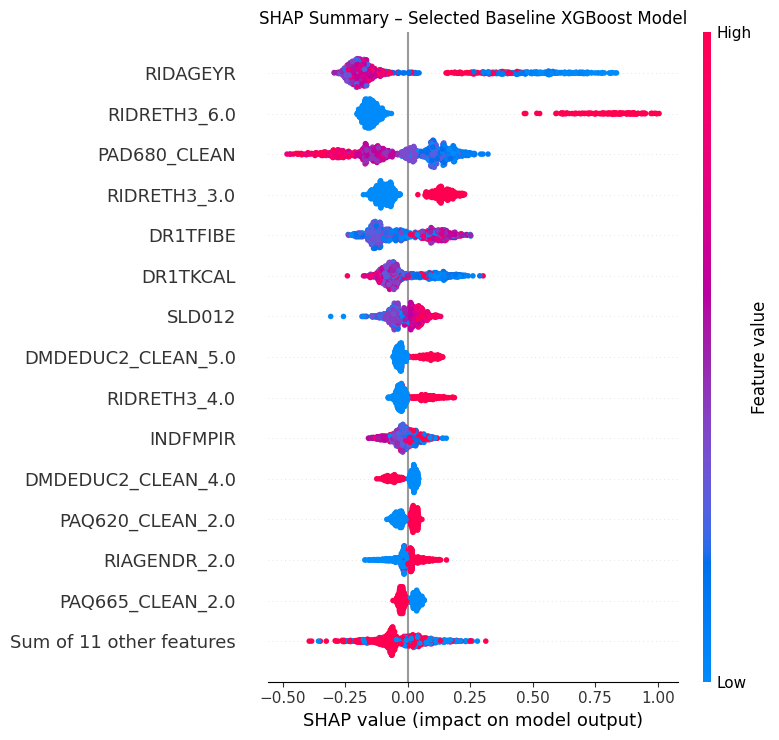


Top 15 features – Baseline XGBoost:
 Rank            Feature  Mean_Absolute_SHAP
    1           RIDAGEYR              0.2554
    2       RIDRETH3_6.0              0.2384
    3       PAD680_CLEAN              0.1475
    4       RIDRETH3_3.0              0.1119
    5           DR1TFIBE              0.1079
    6           DR1TKCAL              0.0835
    7             SLD012              0.0466
    8 DMDEDUC2_CLEAN_5.0              0.0447
    9       RIDRETH3_4.0              0.0401
   10           INDFMPIR              0.0395
   11 DMDEDUC2_CLEAN_4.0              0.0378
   12   PAQ620_CLEAN_2.0              0.0318
   13       RIAGENDR_2.0              0.0303
   14   PAQ665_CLEAN_2.0              0.0290
   15   PAQ650_CLEAN_2.0              0.0281

SUPPLEMENTARY SHAP ANALYSIS: EXTENDED XGBOOST (+PHQ-9)
Extended SHAP values generated for 932 held-out participants.


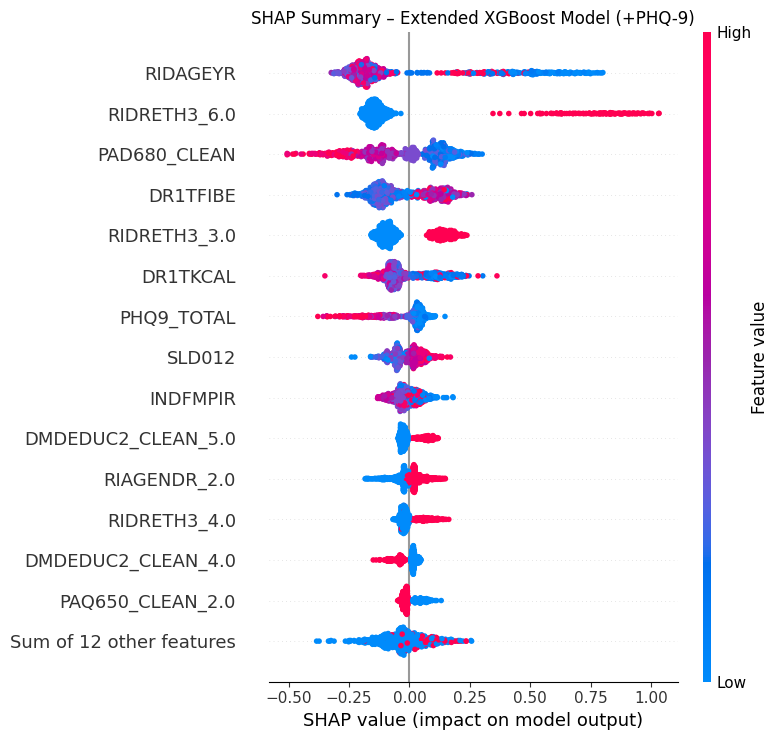


Top 15 features – Extended XGBoost:
 Rank            Feature  Mean_Absolute_SHAP
    1           RIDAGEYR              0.2537
    2       RIDRETH3_6.0              0.2306
    3       PAD680_CLEAN              0.1473
    4           DR1TFIBE              0.1153
    5       RIDRETH3_3.0              0.1128
    6           DR1TKCAL              0.0862
    7         PHQ9_TOTAL              0.0687
    8             SLD012              0.0493
    9           INDFMPIR              0.0407
   10 DMDEDUC2_CLEAN_5.0              0.0380
   11       RIAGENDR_2.0              0.0365
   12       RIDRETH3_4.0              0.0324
   13 DMDEDUC2_CLEAN_4.0              0.0309
   14   PAQ650_CLEAN_2.0              0.0273
   15 DMDMARTL_CLEAN_5.0              0.0254

PHQ-9 SHAP IMPORTANCE
 Rank    Feature  Mean_Absolute_SHAP
    7 PHQ9_TOTAL              0.0687

STEP 9A SUMMARY

Primary SHAP model:
- Baseline XGBoost
- Selected because it achieved the highest held-out ROC-AUC (0.7109)

Supplementary SHAP 

In [66]:
# =============================================================================
# STEP 9A: SHAP GLOBAL EXPLAINABILITY
# Selected Baseline XGBoost + Supplementary Extended XGBoost
# =============================================================================

# Install/import SHAP if required
try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 100)
print("STEP 9A: SHAP GLOBAL EXPLAINABILITY")
print("=" * 100)


# =============================================================================
# 1. EXTRACT PREPROCESSORS AND TRAINED XGBOOST CLASSIFIERS
# =============================================================================

baseline_preprocessor_fitted = (
    best_baseline_xgb.named_steps["preprocessing"]
)

baseline_xgb_classifier = (
    best_baseline_xgb.named_steps["classifier"]
)

extended_preprocessor_fitted = (
    best_extended_xgb.named_steps["preprocessing"]
)

extended_xgb_classifier = (
    best_extended_xgb.named_steps["classifier"]
)


# =============================================================================
# 2. TRANSFORM HELD-OUT TEST DATA
# =============================================================================
#
# SHAP operates on the transformed feature matrix actually received
# by XGBoost.
# =============================================================================

X_test_baseline_transformed = (
    baseline_preprocessor_fitted.transform(X_test_baseline)
)

X_test_extended_transformed = (
    extended_preprocessor_fitted.transform(X_test_extended)
)


# Convert sparse matrices to dense if necessary
if hasattr(X_test_baseline_transformed, "toarray"):
    X_test_baseline_transformed = (
        X_test_baseline_transformed.toarray()
    )

if hasattr(X_test_extended_transformed, "toarray"):
    X_test_extended_transformed = (
        X_test_extended_transformed.toarray()
    )


# =============================================================================
# 3. RETRIEVE TRANSFORMED FEATURE NAMES
# =============================================================================

baseline_feature_names = (
    baseline_preprocessor_fitted.get_feature_names_out()
)

extended_feature_names = (
    extended_preprocessor_fitted.get_feature_names_out()
)


# Clean sklearn prefixes for readability
def clean_feature_names(feature_names):

    cleaned = []

    for name in feature_names:

        name = str(name)

        # Remove ColumnTransformer prefixes
        if "__" in name:
            name = name.split("__", 1)[1]

        cleaned.append(name)

    return cleaned


baseline_feature_names = clean_feature_names(
    baseline_feature_names
)

extended_feature_names = clean_feature_names(
    extended_feature_names
)


print("\nTransformed feature counts:")
print(
    "Baseline:",
    len(baseline_feature_names)
)
print(
    "Extended:",
    len(extended_feature_names)
)


# =============================================================================
# 4. CREATE DATAFRAMES FOR SHAP
# =============================================================================

X_test_baseline_shap = pd.DataFrame(
    X_test_baseline_transformed,
    columns=baseline_feature_names,
    index=X_test_baseline.index
)

X_test_extended_shap = pd.DataFrame(
    X_test_extended_transformed,
    columns=extended_feature_names,
    index=X_test_extended.index
)


# =============================================================================
# 5. BASELINE XGBOOST SHAP
# =============================================================================
#
# This is the PRIMARY explainability analysis because Baseline XGBoost
# achieved the highest held-out ROC-AUC.
# =============================================================================

print("\n" + "=" * 100)
print("PRIMARY SHAP ANALYSIS: BASELINE XGBOOST")
print("=" * 100)

baseline_explainer = shap.TreeExplainer(
    baseline_xgb_classifier
)

baseline_shap_values = baseline_explainer(
    X_test_baseline_shap
)

print(
    "Baseline SHAP values generated for",
    X_test_baseline_shap.shape[0],
    "held-out participants."
)


# =============================================================================
# 6. BASELINE SHAP BEESWARM
# =============================================================================

plt.figure()

shap.plots.beeswarm(
    baseline_shap_values,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary – Selected Baseline XGBoost Model"
)

plt.tight_layout()

plt.savefig(
    "SHAP_Baseline_XGBoost_Beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 7. BASELINE GLOBAL FEATURE IMPORTANCE
# =============================================================================

baseline_mean_abs_shap = np.abs(
    baseline_shap_values.values
).mean(axis=0)

baseline_shap_importance = pd.DataFrame({
    "Feature": baseline_feature_names,
    "Mean_Absolute_SHAP": baseline_mean_abs_shap
})

baseline_shap_importance = (
    baseline_shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

baseline_shap_importance["Rank"] = (
    np.arange(
        1,
        len(baseline_shap_importance) + 1
    )
)

print("\nTop 15 features – Baseline XGBoost:")

print(
    baseline_shap_importance[
        ["Rank", "Feature", "Mean_Absolute_SHAP"]
    ]
    .head(15)
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 8. SUPPLEMENTARY EXTENDED XGBOOST SHAP
# =============================================================================
#
# Extended XGBoost performs almost identically to baseline XGBoost
# (ROC-AUC 0.7107 vs 0.7109).
#
# This supplementary analysis allows direct assessment of PHQ9_TOTAL
# relative to demographic and lifestyle predictors.
# =============================================================================

print("\n" + "=" * 100)
print("SUPPLEMENTARY SHAP ANALYSIS: EXTENDED XGBOOST (+PHQ-9)")
print("=" * 100)

extended_explainer = shap.TreeExplainer(
    extended_xgb_classifier
)

extended_shap_values = extended_explainer(
    X_test_extended_shap
)

print(
    "Extended SHAP values generated for",
    X_test_extended_shap.shape[0],
    "held-out participants."
)


# =============================================================================
# 9. EXTENDED SHAP BEESWARM
# =============================================================================

plt.figure()

shap.plots.beeswarm(
    extended_shap_values,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary – Extended XGBoost Model (+PHQ-9)"
)

plt.tight_layout()

plt.savefig(
    "SHAP_Extended_XGBoost_Beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 10. EXTENDED GLOBAL FEATURE IMPORTANCE
# =============================================================================

extended_mean_abs_shap = np.abs(
    extended_shap_values.values
).mean(axis=0)

extended_shap_importance = pd.DataFrame({
    "Feature": extended_feature_names,
    "Mean_Absolute_SHAP": extended_mean_abs_shap
})

extended_shap_importance = (
    extended_shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

extended_shap_importance["Rank"] = (
    np.arange(
        1,
        len(extended_shap_importance) + 1
    )
)

print("\nTop 15 features – Extended XGBoost:")

print(
    extended_shap_importance[
        ["Rank", "Feature", "Mean_Absolute_SHAP"]
    ]
    .head(15)
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 11. IDENTIFY PHQ-9 IMPORTANCE AND RANK
# =============================================================================

phq_matches = extended_shap_importance[
    extended_shap_importance["Feature"]
    .str.contains(
        "PHQ9_TOTAL",
        case=False,
        regex=False
    )
]

print("\n" + "=" * 100)
print("PHQ-9 SHAP IMPORTANCE")
print("=" * 100)

if len(phq_matches) > 0:

    print(
        phq_matches[
            ["Rank", "Feature", "Mean_Absolute_SHAP"]
        ]
        .round(4)
        .to_string(index=False)
    )

else:

    print(
        "PHQ9_TOTAL was not located in the transformed feature names."
    )


# =============================================================================
# 12. SAVE SHAP IMPORTANCE TABLES
# =============================================================================

baseline_shap_importance.to_csv(
    "SHAP_Baseline_XGBoost_Global_Importance.csv",
    index=False
)

extended_shap_importance.to_csv(
    "SHAP_Extended_XGBoost_Global_Importance.csv",
    index=False
)


# =============================================================================
# 13. STEP 9A SUMMARY
# =============================================================================

print("\n" + "=" * 100)
print("STEP 9A SUMMARY")
print("=" * 100)

print(
    """
Primary SHAP model:
- Baseline XGBoost
- Selected because it achieved the highest held-out ROC-AUC (0.7109)

Supplementary SHAP model:
- Extended XGBoost (+PHQ-9)
- Included to assess the relative contribution of depressive symptom severity

Outputs generated:
- Baseline XGBoost SHAP beeswarm
- Extended XGBoost SHAP beeswarm
- Baseline global feature-importance table
- Extended global feature-importance table
- PHQ-9 SHAP rank and mean absolute SHAP value

Files exported:
- SHAP_Baseline_XGBoost_Beeswarm.png
- SHAP_Extended_XGBoost_Beeswarm.png
- SHAP_Baseline_XGBoost_Global_Importance.csv
- SHAP_Extended_XGBoost_Global_Importance.csv
"""
)

print("Step 9A complete.")

So depression severity is not irrelevant. It actually appears relatively high in the feature-importance ordering.

But remember what Step 8 told us:

XGBoost without PHQ-9: ROC-AUC 0.7109
XGBoost with PHQ-9: ROC-AUC 0.7107
Change: −0.0002

This distinction is probably the single most important intellectual finding of your capstone:

A variable can meaningfully influence individual model predictions without materially improving the model's overall ability to discriminate between healthy-weight and non-healthy-weight participants.

That is exactly why your project distinguishes association, incremental prediction, and explainability.

And the direction shown by the PHQ-9 beeswarm is very interesting

Look specifically at the PHQ9_TOTAL row in your extended SHAP plot.

The red points represent higher PHQ-9 scores, and they are concentrated primarily on the negative SHAP-value side.

The lower values, shown more toward blue, tend comparatively more toward the positive side.

Because your positive outcome is HEALTHY_WEIGHT = 1, a negative SHAP value pushes the prediction away from healthy weight.

So the model is broadly learning:

Higher depressive symptom severity → lower predicted probability of healthy-weight status.

That agrees remarkably well with your earlier inferential Logistic Regression result, where increasing PHQ-9 was associated with reduced odds of healthy weight.

That consistency is valuable because two quite different modelling frameworks are telling a compatible story.

Your research questions are now essentially answered

We can now summarize them very cleanly:

RQ1 — Is depression associated with healthy-weight status?
Yes. Higher PHQ-9 scores were associated with lower odds/probability of healthy-weight status after adjustment.

RQ2 — Does PHQ-9 materially improve prediction?
Not meaningfully. Its ROC-AUC contribution was extremely small across all three model families:

Logistic Regression: +0.0024
Random Forest: +0.0024
XGBoost: −0.0002

So there is little evidence of meaningful incremental predictive value.

RQ3 — Which model performs best?
Baseline XGBoost, with held-out ROC-AUC 0.7109, narrowly outperforming extended XGBoost and Random Forest.

RQ4 — What does explainable AI reveal?
SHAP identifies age, race/ethnicity, sedentary behaviour, fibre/energy intake and other lifestyle/demographic characteristics as major contributors. In the extended model, PHQ-9 ranks 7th, and higher depression severity generally shifts predictions away from healthy weight.

This gives you a much more nuanced conclusion than simply saying "depression predicts obesity."

One tiny analytical step remains: Step 9B

Your interim plan explicitly says global and local SHAP interpretability, not just global SHAP.

We have completed global interpretability. I would now add one very small local-explanation step so that nobody can say we left part of the approved methodology unfinished.

We don't need a huge analysis. Let's generate explanations for two representative held-out participants:

one person predicted relatively strongly as healthy weight;
one person predicted relatively strongly as not healthy weight.

We'll use the selected Baseline XGBoost for the formal local explanations.

Add this directly underneath Step 9A:

STEP 9B: LOCAL SHAP EXPLAINABILITY

Selected local-explanation cases:
Case A - High predicted probability of healthy weight: 0.8549
Case B - Low predicted probability of healthy weight: 0.2007

CASE A: HIGH PREDICTED PROBABILITY OF HEALTHY WEIGHT
Actual class: 1
Predicted probability: 0.8549


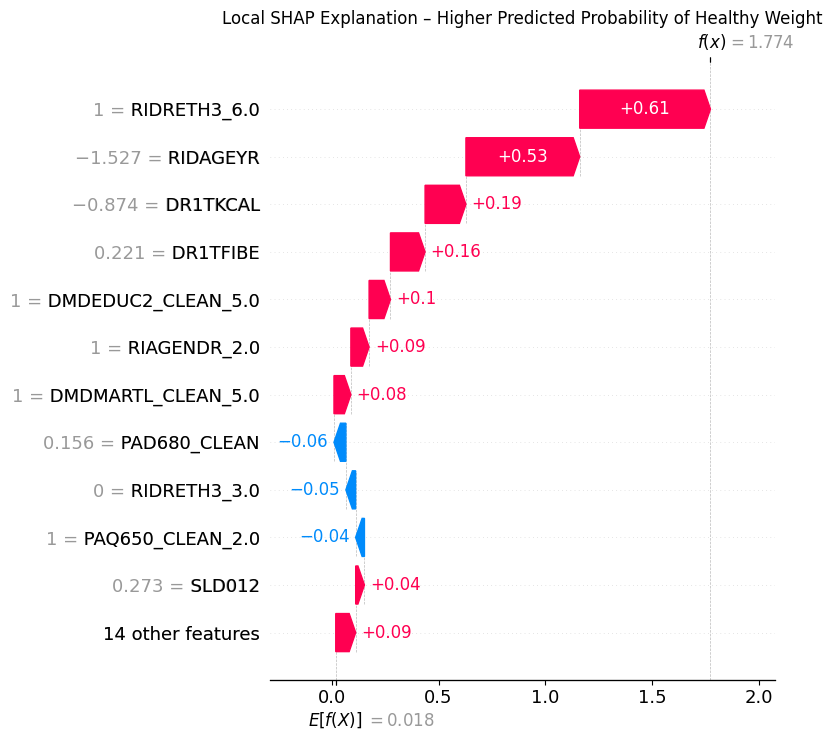


CASE B: LOW PREDICTED PROBABILITY OF HEALTHY WEIGHT
Actual class: 0
Predicted probability: 0.2007


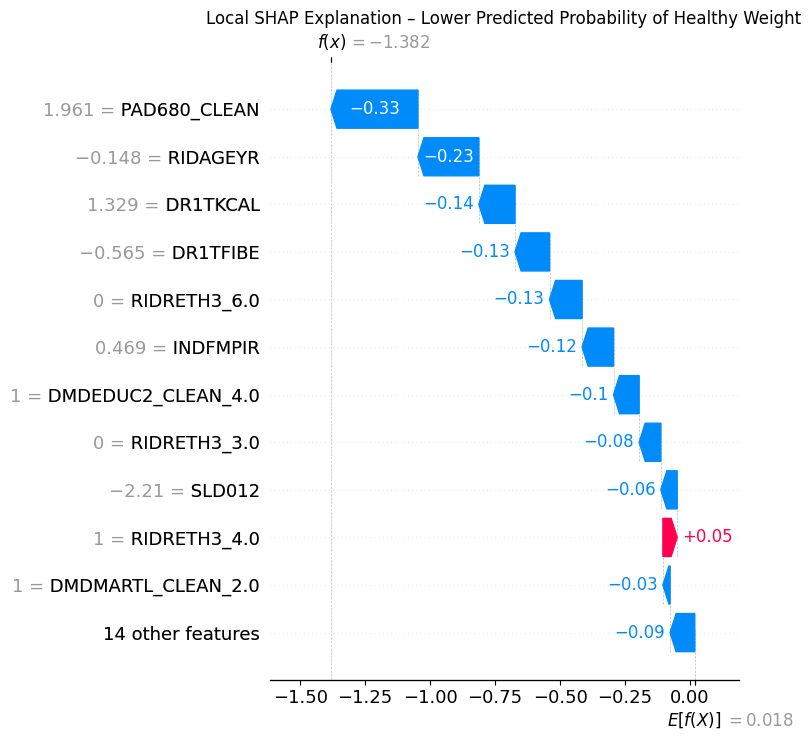


STEP 9B SUMMARY

Local SHAP explanations were generated for two representative
held-out participants using the selected Baseline XGBoost model:

1. Participant with a high predicted probability of healthy weight
2. Participant with a low predicted probability of healthy weight

The waterfall plots show how individual predictor values move each
prediction above or below the model's expected output.

Files exported:
- SHAP_Local_High_Healthy_Probability.png
- SHAP_Local_Low_Healthy_Probability.png
- SHAP_Local_Case_Summary.csv

Step 9B complete.



In [67]:
# =============================================================================
# STEP 9B: LOCAL SHAP EXPLAINABILITY
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

print("=" * 100)
print("STEP 9B: LOCAL SHAP EXPLAINABILITY")
print("=" * 100)


# =============================================================================
# 1. OBTAIN PREDICTED PROBABILITIES FROM SELECTED MODEL
# =============================================================================

baseline_test_probabilities = (
    best_baseline_xgb
    .predict_proba(X_test_baseline)[:, 1]
)

local_results = pd.DataFrame({
    "Actual_HEALTHY_WEIGHT": np.asarray(y_test),
    "Predicted_Probability_Healthy": baseline_test_probabilities
})


# =============================================================================
# 2. SELECT TWO REPRESENTATIVE PARTICIPANTS
# =============================================================================
#
# Case A = highest predicted probability of healthy weight
# Case B = lowest predicted probability of healthy weight
# =============================================================================

healthy_case_position = int(
    np.argmax(baseline_test_probabilities)
)

not_healthy_case_position = int(
    np.argmin(baseline_test_probabilities)
)

print("\nSelected local-explanation cases:")

print(
    f"Case A - High predicted probability of healthy weight: "
    f"{baseline_test_probabilities[healthy_case_position]:.4f}"
)

print(
    f"Case B - Low predicted probability of healthy weight: "
    f"{baseline_test_probabilities[not_healthy_case_position]:.4f}"
)


# =============================================================================
# 3. CASE A: HIGH PROBABILITY OF HEALTHY WEIGHT
# =============================================================================

healthy_explanation = baseline_shap_values[
    healthy_case_position
]

print("\n" + "=" * 100)
print("CASE A: HIGH PREDICTED PROBABILITY OF HEALTHY WEIGHT")
print("=" * 100)

print(
    "Actual class:",
    np.asarray(y_test)[healthy_case_position]
)

print(
    "Predicted probability:",
    round(
        baseline_test_probabilities[
            healthy_case_position
        ],
        4
    )
)

shap.plots.waterfall(
    healthy_explanation,
    max_display=12,
    show=False
)

plt.title(
    "Local SHAP Explanation – Higher Predicted Probability of Healthy Weight"
)

plt.tight_layout()

plt.savefig(
    "SHAP_Local_High_Healthy_Probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 4. CASE B: LOW PROBABILITY OF HEALTHY WEIGHT
# =============================================================================

not_healthy_explanation = baseline_shap_values[
    not_healthy_case_position
]

print("\n" + "=" * 100)
print("CASE B: LOW PREDICTED PROBABILITY OF HEALTHY WEIGHT")
print("=" * 100)

print(
    "Actual class:",
    np.asarray(y_test)[
        not_healthy_case_position
    ]
)

print(
    "Predicted probability:",
    round(
        baseline_test_probabilities[
            not_healthy_case_position
        ],
        4
    )
)

shap.plots.waterfall(
    not_healthy_explanation,
    max_display=12,
    show=False
)

plt.title(
    "Local SHAP Explanation – Lower Predicted Probability of Healthy Weight"
)

plt.tight_layout()

plt.savefig(
    "SHAP_Local_Low_Healthy_Probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 5. EXPORT CASE INFORMATION
# =============================================================================

local_case_summary = pd.DataFrame({
    "Case": [
        "High healthy-weight probability",
        "Low healthy-weight probability"
    ],

    "Actual_HEALTHY_WEIGHT": [
        np.asarray(y_test)[healthy_case_position],
        np.asarray(y_test)[not_healthy_case_position]
    ],

    "Predicted_Probability_Healthy": [
        baseline_test_probabilities[
            healthy_case_position
        ],
        baseline_test_probabilities[
            not_healthy_case_position
        ]
    ]
})

local_case_summary.to_csv(
    "SHAP_Local_Case_Summary.csv",
    index=False
)


# =============================================================================
# 6. STEP 9B SUMMARY
# =============================================================================

print("\n" + "=" * 100)
print("STEP 9B SUMMARY")
print("=" * 100)

print(
    """
Local SHAP explanations were generated for two representative
held-out participants using the selected Baseline XGBoost model:

1. Participant with a high predicted probability of healthy weight
2. Participant with a low predicted probability of healthy weight

The waterfall plots show how individual predictor values move each
prediction above or below the model's expected output.

Files exported:
- SHAP_Local_High_Healthy_Probability.png
- SHAP_Local_Low_Healthy_Probability.png
- SHAP_Local_Case_Summary.csv

Step 9B complete.
"""
)

The two cases are nicely interpretable. For the participant with a high predicted probability of healthy weight (0.8549), the model was also correct because the actual class was 1. The strongest positive pushes came from the race/ethnicity indicator RIDRETH3_6.0, younger age, lower energy intake, higher fibre intake, and some demographic variables. A few variables pushed slightly in the opposite direction, but the positive contributions clearly dominated.

For the participant with a low predicted probability of healthy weight (0.2007), the model was again correct because the actual class was 0. The strongest negative contributions came from sedentary time, age, energy intake, fibre intake, race/ethnicity, income-to-poverty ratio, education, and sleep. The waterfall plot shows very clearly how these variables collectively moved the prediction away from healthy-weight status.

This means your SHAP work now covers both global interpretability and local interpretability, exactly as planned in the interim methodology.

STEP 10A: FORMAL INCREMENTAL PREDICTIVE VALUE OF PHQ-9

Held-out prediction arrays retrieved successfully.
Test participants: 932

Prediction-array lengths:
Logistic Regression baseline: 932
Logistic Regression extended: 932
Random Forest baseline:       932
Random Forest extended:       932
XGBoost baseline:             932
XGBoost extended:             932

Running paired bootstrap analysis...
This may take a short while.
Bootstrap analysis complete.

RQ2: PHQ-9 INCREMENTAL PREDICTIVE VALUE
              Model  Baseline_ROC_AUC  Extended_ROC_AUC  Delta_ROC_AUC  Delta_ROC_AUC_CI_Lower  Delta_ROC_AUC_CI_Upper  Baseline_PR_AUC  Extended_PR_AUC  Delta_PR_AUC  ROC_AUC_CI_Includes_Zero
Logistic Regression            0.6838            0.6862         0.0024                 -0.0055                  0.0094           0.4331           0.4355        0.0023                      True
      Random Forest            0.7068            0.7092         0.0024                 -0.0108                  0.01

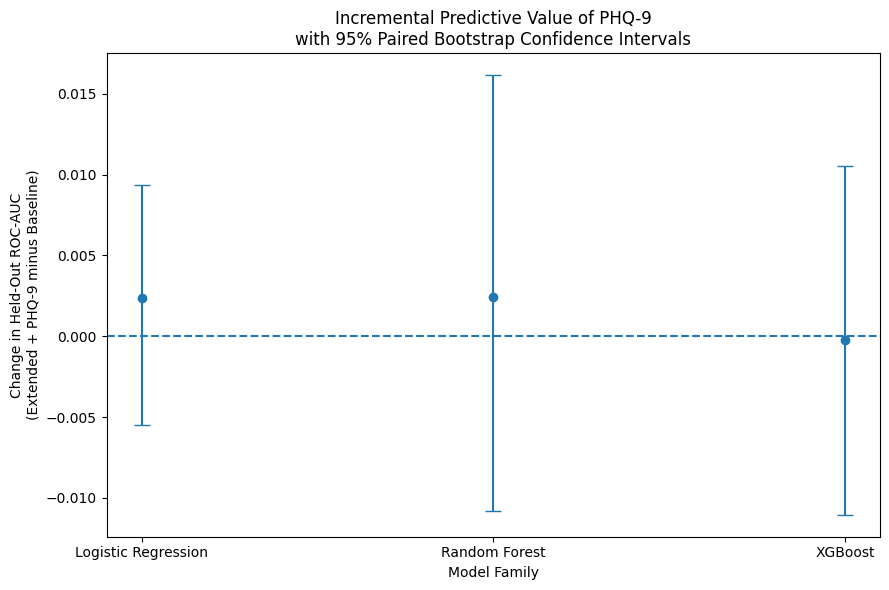


FORMAL RQ2 CONCLUSION

Across Logistic Regression, Random Forest, and XGBoost, adding
PHQ9_TOTAL produced only small changes in held-out discrimination.

The largest absolute change in ROC-AUC across the three model
families was 0.0024.

The paired bootstrap analysis quantifies the uncertainty surrounding
these observed differences while preserving the paired structure of
baseline and extended predictions for the same held-out participants.


For all three model families, the 95% bootstrap confidence interval
for the change in ROC-AUC included zero.

Therefore, although depressive symptom severity demonstrated an
independent statistical association with healthy-weight status in RQ1,
there is no clear evidence that adding PHQ-9 provides meaningful
incremental improvement in out-of-sample discrimination beyond the
demographic and lifestyle predictors evaluated in this study.

This distinction between statistical association and incremental
predictive utility is an important finding of t

In [68]:
# =============================================================================
# STEP 10A: FORMAL INCREMENTAL PREDICTIVE VALUE OF PHQ-9
#            ACROSS MODEL FAMILIES
# =============================================================================
#
# Research Question 2:
# Does incorporating depressive symptom severity (PHQ-9) improve the
# prediction of healthy-weight status beyond demographic and lifestyle
# variables?
#
# This analysis extends the descriptive baseline-vs-extended comparison
# performed in Step 8C by quantifying uncertainty around the change in
# held-out ROC-AUC using paired bootstrap resampling.
#
# IMPORTANT:
# - The same held-out participants are used for baseline and extended models.
# - Bootstrap resampling is therefore performed at the participant level.
# - Baseline and extended predictions remain paired within each bootstrap
#   sample.
# - The held-out test set is NOT used for model fitting or tuning.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score

print("=" * 105)
print("STEP 10A: FORMAL INCREMENTAL PREDICTIVE VALUE OF PHQ-9")
print("=" * 105)


# =============================================================================
# 1. RETRIEVE HELD-OUT PROBABILITIES FOR ALL SIX MODELS
# =============================================================================
#
# Logistic Regression probabilities were generated in Step 7C.
# Random Forest probabilities were generated in Step 8A.
# XGBoost probabilities were generated in Step 8B.
#
# Recalculate from the fitted models only if required so that this section
# remains reproducible within the final notebook.
# =============================================================================

# Logistic Regression
lr_baseline_prob = baseline_logistic_pipeline.predict_proba(
    X_test_baseline
)[:, 1]

lr_extended_prob = extended_logistic_pipeline.predict_proba(
    X_test_extended
)[:, 1]


# Random Forest
rf_baseline_prob = best_baseline_rf.predict_proba(
    X_test_baseline
)[:, 1]

rf_extended_prob = best_extended_rf.predict_proba(
    X_test_extended
)[:, 1]


# XGBoost
xgb_baseline_prob = best_baseline_xgb.predict_proba(
    X_test_baseline
)[:, 1]

xgb_extended_prob = best_extended_xgb.predict_proba(
    X_test_extended
)[:, 1]


y_test_array = np.asarray(y_test)


print("\nHeld-out prediction arrays retrieved successfully.")
print(f"Test participants: {len(y_test_array)}")

print("\nPrediction-array lengths:")
print("Logistic Regression baseline:", len(lr_baseline_prob))
print("Logistic Regression extended:", len(lr_extended_prob))
print("Random Forest baseline:      ", len(rf_baseline_prob))
print("Random Forest extended:      ", len(rf_extended_prob))
print("XGBoost baseline:            ", len(xgb_baseline_prob))
print("XGBoost extended:            ", len(xgb_extended_prob))


# =============================================================================
# 2. DEFINE PAIRED BOOTSTRAP FUNCTION
# =============================================================================
#
# For each bootstrap iteration:
# 1. Resample held-out participants WITH replacement.
# 2. Preserve the pairing between:
#       - true outcome
#       - baseline prediction
#       - extended prediction
# 3. Calculate ROC-AUC for both specifications.
# 4. Calculate:
#
#       Delta ROC-AUC = Extended ROC-AUC - Baseline ROC-AUC
#
# A 95% percentile bootstrap confidence interval is then calculated.
#
# Samples containing only one outcome class are skipped because ROC-AUC
# cannot be calculated in such samples.
# =============================================================================

def paired_bootstrap_auc_difference(
    y_true,
    baseline_prob,
    extended_prob,
    n_bootstrap=2000,
    random_state=42
):

    y_true = np.asarray(y_true)
    baseline_prob = np.asarray(baseline_prob)
    extended_prob = np.asarray(extended_prob)

    rng = np.random.default_rng(random_state)

    n = len(y_true)

    auc_differences = []

    for _ in range(n_bootstrap):

        sample_indices = rng.integers(
            low=0,
            high=n,
            size=n
        )

        y_sample = y_true[sample_indices]

        # ROC-AUC requires both outcome classes
        if np.unique(y_sample).size < 2:
            continue

        baseline_sample = baseline_prob[sample_indices]
        extended_sample = extended_prob[sample_indices]

        baseline_auc = roc_auc_score(
            y_sample,
            baseline_sample
        )

        extended_auc = roc_auc_score(
            y_sample,
            extended_sample
        )

        auc_differences.append(
            extended_auc - baseline_auc
        )

    auc_differences = np.asarray(auc_differences)

    observed_baseline_auc = roc_auc_score(
        y_true,
        baseline_prob
    )

    observed_extended_auc = roc_auc_score(
        y_true,
        extended_prob
    )

    observed_difference = (
        observed_extended_auc
        - observed_baseline_auc
    )

    ci_lower = np.percentile(
        auc_differences,
        2.5
    )

    ci_upper = np.percentile(
        auc_differences,
        97.5
    )

    return {
        "Baseline_ROC_AUC": observed_baseline_auc,
        "Extended_ROC_AUC": observed_extended_auc,
        "Delta_ROC_AUC": observed_difference,
        "CI_Lower_95": ci_lower,
        "CI_Upper_95": ci_upper,
        "Bootstrap_Iterations_Used": len(auc_differences),
        "Bootstrap_Distribution": auc_differences
    }


# =============================================================================
# 3. RUN PAIRED BOOTSTRAP FOR EACH MODEL FAMILY
# =============================================================================

print("\nRunning paired bootstrap analysis...")
print("This may take a short while.")

lr_bootstrap = paired_bootstrap_auc_difference(
    y_true=y_test_array,
    baseline_prob=lr_baseline_prob,
    extended_prob=lr_extended_prob,
    n_bootstrap=2000,
    random_state=42
)

rf_bootstrap = paired_bootstrap_auc_difference(
    y_true=y_test_array,
    baseline_prob=rf_baseline_prob,
    extended_prob=rf_extended_prob,
    n_bootstrap=2000,
    random_state=42
)

xgb_bootstrap = paired_bootstrap_auc_difference(
    y_true=y_test_array,
    baseline_prob=xgb_baseline_prob,
    extended_prob=xgb_extended_prob,
    n_bootstrap=2000,
    random_state=42
)

print("Bootstrap analysis complete.")


# =============================================================================
# 4. CALCULATE PR-AUC DIFFERENCES
# =============================================================================
#
# PR-AUC is especially relevant because HEALTHY_WEIGHT = 1 is the minority
# class. These values complement ROC-AUC but the formal bootstrap inference
# in this step focuses on the prespecified primary discrimination metric,
# ROC-AUC.
# =============================================================================

def calculate_pr_auc_values(
    y_true,
    baseline_prob,
    extended_prob
):

    baseline_pr_auc = average_precision_score(
        y_true,
        baseline_prob
    )

    extended_pr_auc = average_precision_score(
        y_true,
        extended_prob
    )

    return (
        baseline_pr_auc,
        extended_pr_auc,
        extended_pr_auc - baseline_pr_auc
    )


lr_pr = calculate_pr_auc_values(
    y_test_array,
    lr_baseline_prob,
    lr_extended_prob
)

rf_pr = calculate_pr_auc_values(
    y_test_array,
    rf_baseline_prob,
    rf_extended_prob
)

xgb_pr = calculate_pr_auc_values(
    y_test_array,
    xgb_baseline_prob,
    xgb_extended_prob
)


# =============================================================================
# 5. CREATE FINAL RQ2 INCREMENTAL-VALUE TABLE
# =============================================================================

rq2_incremental_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Baseline_ROC_AUC": [
        lr_bootstrap["Baseline_ROC_AUC"],
        rf_bootstrap["Baseline_ROC_AUC"],
        xgb_bootstrap["Baseline_ROC_AUC"]
    ],

    "Extended_ROC_AUC": [
        lr_bootstrap["Extended_ROC_AUC"],
        rf_bootstrap["Extended_ROC_AUC"],
        xgb_bootstrap["Extended_ROC_AUC"]
    ],

    "Delta_ROC_AUC": [
        lr_bootstrap["Delta_ROC_AUC"],
        rf_bootstrap["Delta_ROC_AUC"],
        xgb_bootstrap["Delta_ROC_AUC"]
    ],

    "Delta_ROC_AUC_CI_Lower": [
        lr_bootstrap["CI_Lower_95"],
        rf_bootstrap["CI_Lower_95"],
        xgb_bootstrap["CI_Lower_95"]
    ],

    "Delta_ROC_AUC_CI_Upper": [
        lr_bootstrap["CI_Upper_95"],
        rf_bootstrap["CI_Upper_95"],
        xgb_bootstrap["CI_Upper_95"]
    ],

    "Baseline_PR_AUC": [
        lr_pr[0],
        rf_pr[0],
        xgb_pr[0]
    ],

    "Extended_PR_AUC": [
        lr_pr[1],
        rf_pr[1],
        xgb_pr[1]
    ],

    "Delta_PR_AUC": [
        lr_pr[2],
        rf_pr[2],
        xgb_pr[2]
    ]
})


# Determine whether each ROC-AUC confidence interval includes zero
rq2_incremental_results["ROC_AUC_CI_Includes_Zero"] = (
    (
        rq2_incremental_results[
            "Delta_ROC_AUC_CI_Lower"
        ] <= 0
    )
    &
    (
        rq2_incremental_results[
            "Delta_ROC_AUC_CI_Upper"
        ] >= 0
    )
)


print("\n" + "=" * 105)
print("RQ2: PHQ-9 INCREMENTAL PREDICTIVE VALUE")
print("=" * 105)

print(
    rq2_incremental_results
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 6. PRINT MODEL-SPECIFIC INTERPRETATION
# =============================================================================

print("\n" + "=" * 105)
print("MODEL-SPECIFIC INTERPRETATION")
print("=" * 105)

for _, row in rq2_incremental_results.iterrows():

    model_name = row["Model"]

    delta = row["Delta_ROC_AUC"]

    lower = row["Delta_ROC_AUC_CI_Lower"]
    upper = row["Delta_ROC_AUC_CI_Upper"]

    pr_delta = row["Delta_PR_AUC"]

    includes_zero = row[
        "ROC_AUC_CI_Includes_Zero"
    ]

    if delta > 0:
        direction_text = "increased"
    elif delta < 0:
        direction_text = "decreased"
    else:
        direction_text = "did not change"

    print(f"\n{model_name}")

    print(
        f"- ROC-AUC {direction_text} by "
        f"{abs(delta):.4f} after adding PHQ-9."
    )

    print(
        f"- 95% bootstrap CI for Delta ROC-AUC: "
        f"[{lower:.4f}, {upper:.4f}]"
    )

    print(
        f"- PR-AUC change after adding PHQ-9: "
        f"{pr_delta:+.4f}"
    )

    if includes_zero:

        print(
            "- The bootstrap confidence interval includes zero, "
            "so the observed ROC-AUC change is not clearly distinguishable "
            "from sampling variation."
        )

    else:

        print(
            "- The bootstrap confidence interval does not include zero."
        )


# =============================================================================
# 7. VISUALIZE ROC-AUC CHANGE WITH 95% BOOTSTRAP CONFIDENCE INTERVALS
# =============================================================================

plot_data = rq2_incremental_results.copy()

x_positions = np.arange(
    len(plot_data)
)

delta_values = plot_data[
    "Delta_ROC_AUC"
].to_numpy()

lower_errors = (
    delta_values
    - plot_data[
        "Delta_ROC_AUC_CI_Lower"
    ].to_numpy()
)

upper_errors = (
    plot_data[
        "Delta_ROC_AUC_CI_Upper"
    ].to_numpy()
    - delta_values
)

plt.figure(figsize=(9, 6))

plt.errorbar(
    x_positions,
    delta_values,
    yerr=[
        lower_errors,
        upper_errors
    ],
    fmt="o",
    capsize=6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xticks(
    x_positions,
    plot_data["Model"]
)

plt.ylabel(
    "Change in Held-Out ROC-AUC\n"
    "(Extended + PHQ-9 minus Baseline)"
)

plt.xlabel(
    "Model Family"
)

plt.title(
    "Incremental Predictive Value of PHQ-9\n"
    "with 95% Paired Bootstrap Confidence Intervals"
)

plt.tight_layout()

plt.savefig(
    "PHQ9_Incremental_ROC_AUC_Bootstrap_CI.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 8. FORMAL RQ2 CONCLUSION
# =============================================================================

all_cis_include_zero = (
    rq2_incremental_results[
        "ROC_AUC_CI_Includes_Zero"
    ].all()
)

max_absolute_auc_change = (
    rq2_incremental_results[
        "Delta_ROC_AUC"
    ]
    .abs()
    .max()
)


print("\n" + "=" * 105)
print("FORMAL RQ2 CONCLUSION")
print("=" * 105)

print(
    f"""
Across Logistic Regression, Random Forest, and XGBoost, adding
PHQ9_TOTAL produced only small changes in held-out discrimination.

The largest absolute change in ROC-AUC across the three model
families was {max_absolute_auc_change:.4f}.

The paired bootstrap analysis quantifies the uncertainty surrounding
these observed differences while preserving the paired structure of
baseline and extended predictions for the same held-out participants.
"""
)

if all_cis_include_zero:

    print(
        """
For all three model families, the 95% bootstrap confidence interval
for the change in ROC-AUC included zero.

Therefore, although depressive symptom severity demonstrated an
independent statistical association with healthy-weight status in RQ1,
there is no clear evidence that adding PHQ-9 provides meaningful
incremental improvement in out-of-sample discrimination beyond the
demographic and lifestyle predictors evaluated in this study.

This distinction between statistical association and incremental
predictive utility is an important finding of the study.
"""
    )

else:

    print(
        """
At least one model family produced a 95% bootstrap confidence interval
for the ROC-AUC change that did not include zero. The model-specific
results above should therefore be interpreted individually rather than
making a uniform conclusion across all model families.
"""
    )


# =============================================================================
# 9. SAVE FINAL RQ2 RESULTS
# =============================================================================

rq2_incremental_results.to_csv(
    "RQ2_PHQ9_Incremental_Predictive_Value.csv",
    index=False
)

print("\nFiles exported:")
print("- RQ2_PHQ9_Incremental_Predictive_Value.csv")
print("- PHQ9_Incremental_ROC_AUC_Bootstrap_CI.png")


# =============================================================================
# 10. STEP 10A SUMMARY
# =============================================================================

print("\n" + "=" * 105)
print("STEP 10A SUMMARY")
print("=" * 105)

print(
    """
Step 10A formally evaluated the incremental predictive value of
PHQ-9 across all three prespecified model families.

Completed:
- Logistic Regression baseline vs PHQ-9 extended comparison
- Random Forest baseline vs PHQ-9 extended comparison
- XGBoost baseline vs PHQ-9 extended comparison
- Held-out ROC-AUC differences
- Held-out PR-AUC differences
- Paired bootstrap 95% confidence intervals for Delta ROC-AUC
- Cross-model visualization
- Formal RQ2 interpretation
- Export of final RQ2 results

STEP 10A COMPLETE.
"""
)

STEP 11A: THRESHOLD AND CLASS-IMBALANCE ROBUSTNESS ANALYSIS

Selected model: Baseline XGBoost
Held-out participants: 932
Healthy-weight participants (1): 227
Not-healthy-weight participants (0): 705
Healthy-weight prevalence in held-out test set: 0.2436

SECONDARY THRESHOLD ANALYSIS

Threshold maximizing balanced accuracy: 0.47
Maximum balanced accuracy: 0.6705
Sensitivity at this threshold: 0.6432
Specificity at this threshold: 0.6979

Threshold maximizing Youden's J: 0.47
Youden's J: 0.3410

Threshold maximizing F1 score: 0.47
Maximum F1 score: 0.4983

DEFAULT VS SECONDARY THRESHOLD
                   Threshold_Type  Threshold  Accuracy  Balanced_Accuracy  Sensitivity  Specificity  Precision     F1  TN  FP  FN  TP
                     Default 0.50       0.50    0.7028             0.6572       0.5683       0.7461     0.4188 0.4822 526 179  98 129
Secondary - Max Balanced Accuracy       0.47    0.6845             0.6705       0.6432       0.6979     0.4067 0.4983 492 213  81 146

CONFU

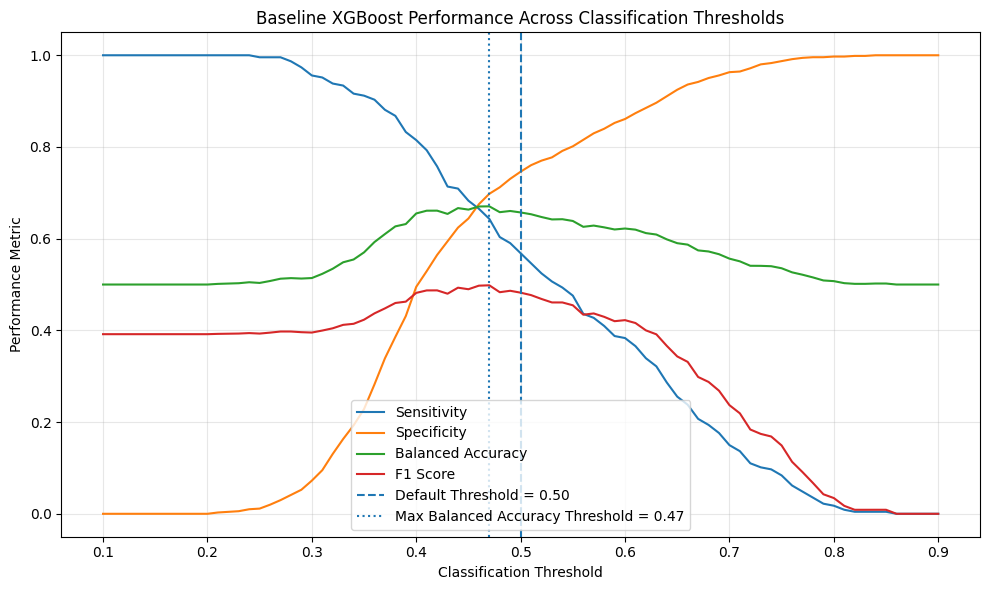


ROC-DERIVED YOUDEN THRESHOLD CHECK
ROC-derived Youden threshold: 0.4651
Sensitivity at ROC-derived threshold: 0.6608
Specificity at ROC-derived threshold: 0.6865

ROBUSTNESS INTERPRETATION

The held-out test set is imbalanced, with healthy-weight participants
representing 24.36% of the sample.

At the default 0.50 classification threshold, Baseline XGBoost achieved:

- Accuracy:          0.7028
- Balanced accuracy: 0.6572
- Sensitivity:       0.5683
- Specificity:       0.7461
- Precision:         0.4188
- F1 score:          0.4822

A secondary threshold analysis identified 0.47 as the
threshold producing the highest balanced accuracy within the evaluated
threshold grid.

At this threshold:

- Accuracy:          0.6845
- Balanced accuracy: 0.6705
- Sensitivity:       0.6432
- Specificity:       0.6979
- Precision:         0.4067
- F1 score:          0.4983

This analysis demonstrates that threshold choice materially affects the
trade-off between identifying healthy-weight participants

In [69]:
# =============================================================================
# STEP 11A: THRESHOLD AND CLASS-IMBALANCE ROBUSTNESS ANALYSIS
# =============================================================================
#
# Purpose:
# Evaluate how the classification behaviour of the selected final model
# (Baseline XGBoost) changes across probability thresholds.
#
# IMPORTANT:
# - Baseline XGBoost remains the selected model based on held-out ROC-AUC.
# - The original 0.50 threshold remains the primary reported threshold.
# - This is a secondary robustness / operational analysis.
# - No model is retrained and no predictors are changed.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve
)

print("=" * 105)
print("STEP 11A: THRESHOLD AND CLASS-IMBALANCE ROBUSTNESS ANALYSIS")
print("=" * 105)


# =============================================================================
# 1. USE SELECTED FINAL MODEL
# =============================================================================

# Baseline XGBoost was selected in the final model comparison.
selected_model_prob = xgb_baseline_prob
y_true = np.asarray(y_test)

print("\nSelected model: Baseline XGBoost")
print(f"Held-out participants: {len(y_true)}")

healthy_n = np.sum(y_true == 1)
not_healthy_n = np.sum(y_true == 0)

print(f"Healthy-weight participants (1): {healthy_n}")
print(f"Not-healthy-weight participants (0): {not_healthy_n}")

print(
    f"Healthy-weight prevalence in held-out test set: "
    f"{healthy_n / len(y_true):.4f}"
)


# =============================================================================
# 2. EVALUATE A RANGE OF CLASSIFICATION THRESHOLDS
# =============================================================================

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:

    predictions = (
        selected_model_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        predictions
    )

    youden_j = sensitivity + specificity - 1

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Balanced_Accuracy": balanced_accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1": f1,
        "Youden_J": youden_j,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


threshold_results_df = pd.DataFrame(
    threshold_results
)


# =============================================================================
# 3. IDENTIFY SECONDARY THRESHOLDS
# =============================================================================

best_balanced_row = threshold_results_df.loc[
    threshold_results_df[
        "Balanced_Accuracy"
    ].idxmax()
]

best_youden_row = threshold_results_df.loc[
    threshold_results_df[
        "Youden_J"
    ].idxmax()
]

best_f1_row = threshold_results_df.loc[
    threshold_results_df[
        "F1"
    ].idxmax()
]


print("\n" + "=" * 105)
print("SECONDARY THRESHOLD ANALYSIS")
print("=" * 105)

print(
    f"\nThreshold maximizing balanced accuracy: "
    f"{best_balanced_row['Threshold']:.2f}"
)

print(
    f"Maximum balanced accuracy: "
    f"{best_balanced_row['Balanced_Accuracy']:.4f}"
)

print(
    f"Sensitivity at this threshold: "
    f"{best_balanced_row['Sensitivity']:.4f}"
)

print(
    f"Specificity at this threshold: "
    f"{best_balanced_row['Specificity']:.4f}"
)


print(
    f"\nThreshold maximizing Youden's J: "
    f"{best_youden_row['Threshold']:.2f}"
)

print(
    f"Youden's J: "
    f"{best_youden_row['Youden_J']:.4f}"
)


print(
    f"\nThreshold maximizing F1 score: "
    f"{best_f1_row['Threshold']:.2f}"
)

print(
    f"Maximum F1 score: "
    f"{best_f1_row['F1']:.4f}"
)


# =============================================================================
# 4. COMPARE DEFAULT 0.50 WITH SECONDARY BALANCED-ACCURACY THRESHOLD
# =============================================================================

def threshold_metrics(y_true, probabilities, threshold):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_true,
            predictions
        ),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


default_metrics = threshold_metrics(
    y_true,
    selected_model_prob,
    0.50
)

secondary_threshold = float(
    best_balanced_row["Threshold"]
)

secondary_metrics = threshold_metrics(
    y_true,
    selected_model_prob,
    secondary_threshold
)


threshold_comparison = pd.DataFrame([
    {
        "Threshold_Type": "Default 0.50",
        **default_metrics
    },
    {
        "Threshold_Type":
            "Secondary - Max Balanced Accuracy",
        **secondary_metrics
    }
])


print("\n" + "=" * 105)
print("DEFAULT VS SECONDARY THRESHOLD")
print("=" * 105)

print(
    threshold_comparison
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 5. CONFUSION MATRICES
# =============================================================================

print("\n" + "=" * 105)
print("CONFUSION MATRICES")
print("=" * 105)

print("\nDefault threshold = 0.50")
print(
    np.array([
        [
            default_metrics["TN"],
            default_metrics["FP"]
        ],
        [
            default_metrics["FN"],
            default_metrics["TP"]
        ]
    ])
)

print(
    f"\nSecondary threshold = "
    f"{secondary_threshold:.2f}"
)

print(
    np.array([
        [
            secondary_metrics["TN"],
            secondary_metrics["FP"]
        ],
        [
            secondary_metrics["FN"],
            secondary_metrics["TP"]
        ]
    ])
)


# =============================================================================
# 6. PLOT PERFORMANCE ACROSS THRESHOLDS
# =============================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Sensitivity"],
    label="Sensitivity"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Specificity"],
    label="Specificity"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Balanced_Accuracy"],
    label="Balanced Accuracy"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1"],
    label="F1 Score"
)

plt.axvline(
    x=0.50,
    linestyle="--",
    label="Default Threshold = 0.50"
)

plt.axvline(
    x=secondary_threshold,
    linestyle=":",
    label=(
        "Max Balanced Accuracy Threshold = "
        f"{secondary_threshold:.2f}"
    )
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Performance Metric"
)

plt.title(
    "Baseline XGBoost Performance Across "
    "Classification Thresholds"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "XGBoost_Threshold_Robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 7. ROC-DERIVED YOUDEN THRESHOLD AS ADDITIONAL CHECK
# =============================================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    selected_model_prob
)

youden_values = tpr - fpr

roc_best_index = np.argmax(
    youden_values
)

roc_youden_threshold = (
    roc_thresholds[roc_best_index]
)

print("\n" + "=" * 105)
print("ROC-DERIVED YOUDEN THRESHOLD CHECK")
print("=" * 105)

print(
    f"ROC-derived Youden threshold: "
    f"{roc_youden_threshold:.4f}"
)

print(
    f"Sensitivity at ROC-derived threshold: "
    f"{tpr[roc_best_index]:.4f}"
)

print(
    f"Specificity at ROC-derived threshold: "
    f"{1 - fpr[roc_best_index]:.4f}"
)


# =============================================================================
# 8. INTERPRETATION
# =============================================================================

print("\n" + "=" * 105)
print("ROBUSTNESS INTERPRETATION")
print("=" * 105)

print(
    f"""
The held-out test set is imbalanced, with healthy-weight participants
representing {healthy_n / len(y_true):.2%} of the sample.

At the default 0.50 classification threshold, Baseline XGBoost achieved:

- Accuracy:          {default_metrics['Accuracy']:.4f}
- Balanced accuracy: {default_metrics['Balanced_Accuracy']:.4f}
- Sensitivity:       {default_metrics['Sensitivity']:.4f}
- Specificity:       {default_metrics['Specificity']:.4f}
- Precision:         {default_metrics['Precision']:.4f}
- F1 score:          {default_metrics['F1']:.4f}

A secondary threshold analysis identified {secondary_threshold:.2f} as the
threshold producing the highest balanced accuracy within the evaluated
threshold grid.

At this threshold:

- Accuracy:          {secondary_metrics['Accuracy']:.4f}
- Balanced accuracy: {secondary_metrics['Balanced_Accuracy']:.4f}
- Sensitivity:       {secondary_metrics['Sensitivity']:.4f}
- Specificity:       {secondary_metrics['Specificity']:.4f}
- Precision:         {secondary_metrics['Precision']:.4f}
- F1 score:          {secondary_metrics['F1']:.4f}

This analysis demonstrates that threshold choice materially affects the
trade-off between identifying healthy-weight participants and correctly
identifying not-healthy-weight participants.

The secondary threshold is presented as a robustness and operational
analysis only. It does not replace the prespecified held-out ROC-AUC used
for model comparison and does not alter the selection of Baseline XGBoost
as the final model.
"""
)


# =============================================================================
# 9. SAVE RESULTS
# =============================================================================

threshold_results_df.to_csv(
    "XGBoost_All_Threshold_Results.csv",
    index=False
)

threshold_comparison.to_csv(
    "XGBoost_Default_vs_Secondary_Threshold.csv",
    index=False
)

print("\nFiles exported:")
print("- XGBoost_All_Threshold_Results.csv")
print("- XGBoost_Default_vs_Secondary_Threshold.csv")
print("- XGBoost_Threshold_Robustness.png")


# =============================================================================
# 10. STEP 11A SUMMARY
# =============================================================================

print("\n" + "=" * 105)
print("STEP 11A SUMMARY")
print("=" * 105)

print(
    """
Step 11A evaluated the robustness of the selected Baseline XGBoost
classifier to probability-threshold choice in the presence of class
imbalance.

Completed:
- Threshold grid evaluation
- Sensitivity analysis
- Specificity analysis
- Balanced-accuracy analysis
- F1 analysis
- Youden's J analysis
- Default 0.50 threshold comparison
- Secondary threshold comparison
- Confusion matrices
- Threshold-performance visualization
- ROC-derived Youden threshold check
- Export of robustness results

STEP 11A COMPLETE.
"""
)

STEP 11B: PROBABILITY CALIBRATION AND BRIER SCORE ANALYSIS

Models evaluated:
- Selected final model: Baseline XGBoost
- Calibration benchmark: Baseline Logistic Regression

Held-out participants: 932
Observed healthy-weight prevalence: 0.2436

Mean predicted probability - XGBoost: 0.4627
Mean predicted probability - Logistic Regression: 0.2432

BRIER SCORE RESULTS

Baseline XGBoost Brier score:          0.2127
Baseline Logistic Regression Brier:   0.1678
Prevalence-only reference Brier:      0.1842

Baseline XGBoost does not improve upon the prevalence-only reference according to the Brier score.

BRIER SKILL SCORE

Baseline XGBoost Brier Skill Score: -0.1547
Baseline Logistic Regression Brier Skill Score: 0.0890

BASELINE XGBOOST CALIBRATION TABLE
 Bin  Mean_Predicted_Probability  Observed_Healthy_Weight_Frequency  Calibration_Gap
   1                      0.2858                             0.1277          -0.1581
   2                      0.3340                             0.0860   

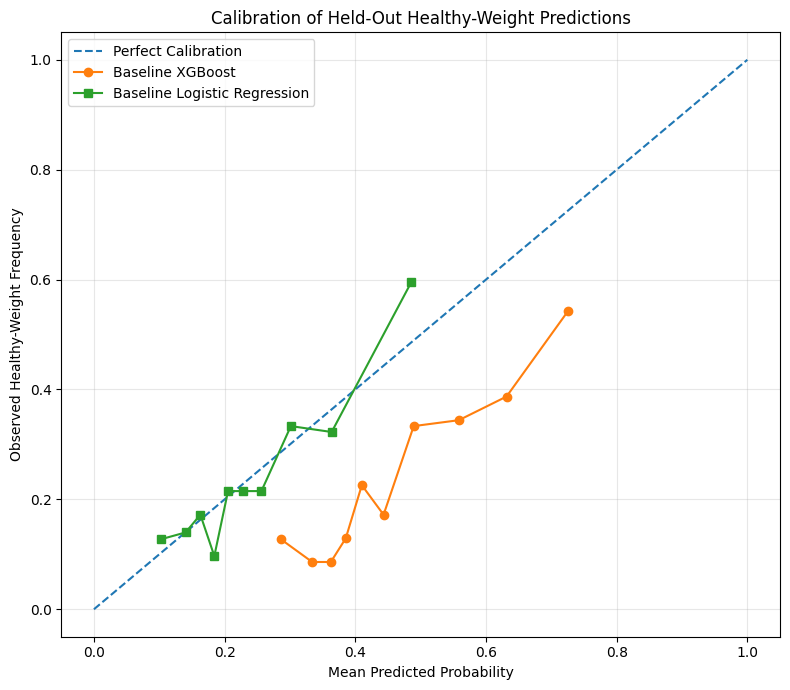

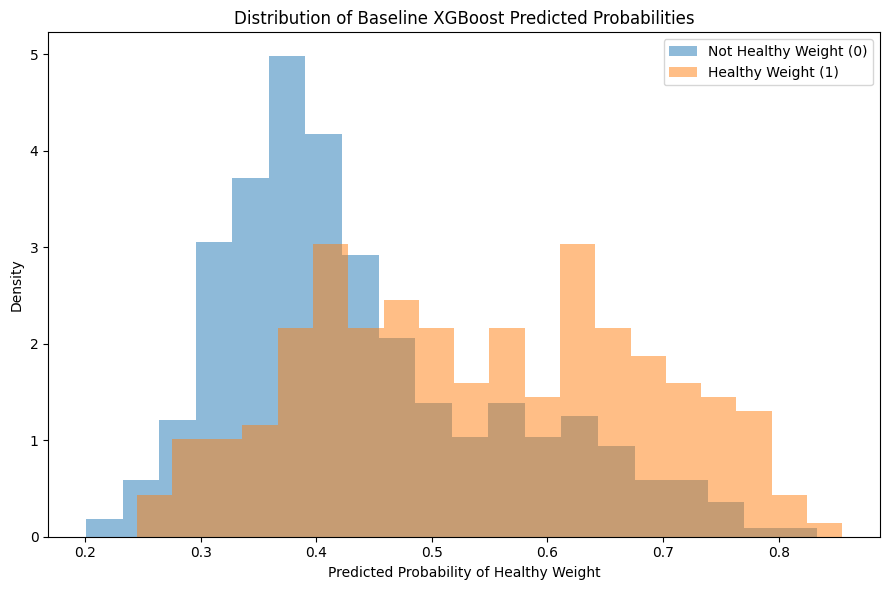


CALIBRATION SUMMARY
                       Model  Brier_Score  Brier_Skill_Score  Mean_Absolute_Calibration_Gap
            Baseline XGBoost       0.2127            -0.1547                         0.2192
Baseline Logistic Regression       0.1678             0.0890                         0.0368
   Prevalence-only Reference       0.1842             0.0000                            NaN

CALIBRATION INTERPRETATION

Baseline XGBoost was selected previously because it achieved the
highest held-out ROC-AUC. Step 11B evaluates a different property:
the reliability of its predicted probabilities.

The selected XGBoost model achieved a Brier score of
0.2127, compared with 0.1842 for a
prevalence-only reference model.

Its Brier Skill Score was -0.1547. A positive value
indicates improvement over the prevalence-only probability benchmark.

Baseline Logistic Regression achieved a Brier score of
0.1678. Logistic Regression is included only as a calibration
benchmark and this analysis does not al

In [70]:
# =============================================================================
# STEP 11B: PROBABILITY CALIBRATION AND BRIER SCORE ANALYSIS
# =============================================================================
#
# Purpose:
# Assess whether the predicted probabilities from the selected final model
# (Baseline XGBoost) are well calibrated.
#
# Discrimination and calibration measure different properties:
# - ROC-AUC measures how well the model ranks participants.
# - Calibration measures how closely predicted probabilities correspond
#   to observed outcome frequencies.
#
# IMPORTANT:
# This is a post-model-selection robustness analysis.
# No model is retrained or recalibrated using the held-out test set.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

print("=" * 105)
print("STEP 11B: PROBABILITY CALIBRATION AND BRIER SCORE ANALYSIS")
print("=" * 105)


# =============================================================================
# 1. RETRIEVE HELD-OUT PROBABILITIES
# =============================================================================

y_true = np.asarray(y_test)

# Selected final model
xgb_prob = np.asarray(xgb_baseline_prob)

# Logistic Regression retained as a useful calibration benchmark
lr_prob = np.asarray(lr_baseline_prob)

print("\nModels evaluated:")
print("- Selected final model: Baseline XGBoost")
print("- Calibration benchmark: Baseline Logistic Regression")

print(f"\nHeld-out participants: {len(y_true)}")
print(f"Observed healthy-weight prevalence: {np.mean(y_true):.4f}")

print(f"\nMean predicted probability - XGBoost: "
      f"{np.mean(xgb_prob):.4f}")

print(f"Mean predicted probability - Logistic Regression: "
      f"{np.mean(lr_prob):.4f}")


# =============================================================================
# 2. BRIER SCORES
# =============================================================================
#
# Brier score = mean squared difference between predicted probability
# and actual binary outcome.
#
# Lower values indicate better probabilistic accuracy.
# =============================================================================

xgb_brier = brier_score_loss(
    y_true,
    xgb_prob
)

lr_brier = brier_score_loss(
    y_true,
    lr_prob
)

# Simple prevalence-only reference model
prevalence = np.mean(y_true)

prevalence_prob = np.full(
    len(y_true),
    prevalence
)

reference_brier = brier_score_loss(
    y_true,
    prevalence_prob
)


print("\n" + "=" * 105)
print("BRIER SCORE RESULTS")
print("=" * 105)

print(f"\nBaseline XGBoost Brier score:          {xgb_brier:.4f}")
print(f"Baseline Logistic Regression Brier:   {lr_brier:.4f}")
print(f"Prevalence-only reference Brier:      {reference_brier:.4f}")

if xgb_brier < reference_brier:
    print(
        "\nBaseline XGBoost has a lower Brier score than the "
        "prevalence-only reference, indicating improved probabilistic "
        "prediction relative to assigning every participant the same "
        "base-rate probability."
    )
else:
    print(
        "\nBaseline XGBoost does not improve upon the prevalence-only "
        "reference according to the Brier score."
    )


# =============================================================================
# 3. BRIER SKILL SCORE
# =============================================================================
#
# Brier Skill Score:
#
#       1 - (Model Brier / Reference Brier)
#
# > 0 : improvement over reference
# = 0 : no improvement
# < 0 : worse than reference
# =============================================================================

xgb_brier_skill = 1 - (
    xgb_brier / reference_brier
)

lr_brier_skill = 1 - (
    lr_brier / reference_brier
)


print("\n" + "=" * 105)
print("BRIER SKILL SCORE")
print("=" * 105)

print(
    f"\nBaseline XGBoost Brier Skill Score: "
    f"{xgb_brier_skill:.4f}"
)

print(
    f"Baseline Logistic Regression Brier Skill Score: "
    f"{lr_brier_skill:.4f}"
)


# =============================================================================
# 4. CALIBRATION CURVES
# =============================================================================
#
# Quantile bins are used because predicted probabilities may not be
# distributed evenly across the 0-1 interval.
# =============================================================================

n_bins = 10

xgb_fraction_positive, xgb_mean_predicted = calibration_curve(
    y_true,
    xgb_prob,
    n_bins=n_bins,
    strategy="quantile"
)

lr_fraction_positive, lr_mean_predicted = calibration_curve(
    y_true,
    lr_prob,
    n_bins=n_bins,
    strategy="quantile"
)


# =============================================================================
# 5. CREATE CALIBRATION TABLE
# =============================================================================

xgb_calibration_table = pd.DataFrame({
    "Bin": np.arange(
        1,
        len(xgb_mean_predicted) + 1
    ),
    "Mean_Predicted_Probability":
        xgb_mean_predicted,
    "Observed_Healthy_Weight_Frequency":
        xgb_fraction_positive,
    "Calibration_Gap":
        xgb_fraction_positive -
        xgb_mean_predicted
})


print("\n" + "=" * 105)
print("BASELINE XGBOOST CALIBRATION TABLE")
print("=" * 105)

print(
    xgb_calibration_table
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 6. CALIBRATION PLOT
# =============================================================================

plt.figure(figsize=(8, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    xgb_mean_predicted,
    xgb_fraction_positive,
    marker="o",
    label="Baseline XGBoost"
)

plt.plot(
    lr_mean_predicted,
    lr_fraction_positive,
    marker="s",
    label="Baseline Logistic Regression"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Observed Healthy-Weight Frequency"
)

plt.title(
    "Calibration of Held-Out Healthy-Weight Predictions"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "Model_Calibration_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 7. PROBABILITY DISTRIBUTION CHECK
# =============================================================================

plt.figure(figsize=(9, 6))

plt.hist(
    xgb_prob[y_true == 0],
    bins=20,
    alpha=0.5,
    density=True,
    label="Not Healthy Weight (0)"
)

plt.hist(
    xgb_prob[y_true == 1],
    bins=20,
    alpha=0.5,
    density=True,
    label="Healthy Weight (1)"
)

plt.xlabel(
    "Predicted Probability of Healthy Weight"
)

plt.ylabel(
    "Density"
)

plt.title(
    "Distribution of Baseline XGBoost Predicted Probabilities"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "XGBoost_Probability_Distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 8. CALIBRATION SUMMARY STATISTICS
# =============================================================================

xgb_mean_absolute_calibration_gap = np.mean(
    np.abs(
        xgb_fraction_positive -
        xgb_mean_predicted
    )
)

lr_mean_absolute_calibration_gap = np.mean(
    np.abs(
        lr_fraction_positive -
        lr_mean_predicted
    )
)


calibration_summary = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Baseline Logistic Regression",
        "Prevalence-only Reference"
    ],

    "Brier_Score": [
        xgb_brier,
        lr_brier,
        reference_brier
    ],

    "Brier_Skill_Score": [
        xgb_brier_skill,
        lr_brier_skill,
        0.0
    ],

    "Mean_Absolute_Calibration_Gap": [
        xgb_mean_absolute_calibration_gap,
        lr_mean_absolute_calibration_gap,
        np.nan
    ]
})


print("\n" + "=" * 105)
print("CALIBRATION SUMMARY")
print("=" * 105)

print(
    calibration_summary
    .round(4)
    .to_string(index=False)
)


# =============================================================================
# 9. INTERPRETATION
# =============================================================================

print("\n" + "=" * 105)
print("CALIBRATION INTERPRETATION")
print("=" * 105)

print(
    f"""
Baseline XGBoost was selected previously because it achieved the
highest held-out ROC-AUC. Step 11B evaluates a different property:
the reliability of its predicted probabilities.

The selected XGBoost model achieved a Brier score of
{xgb_brier:.4f}, compared with {reference_brier:.4f} for a
prevalence-only reference model.

Its Brier Skill Score was {xgb_brier_skill:.4f}. A positive value
indicates improvement over the prevalence-only probability benchmark.

Baseline Logistic Regression achieved a Brier score of
{lr_brier:.4f}. Logistic Regression is included only as a calibration
benchmark and this analysis does not alter the model-selection
procedure.

The XGBoost mean absolute calibration gap across the quantile-based
calibration bins was {xgb_mean_absolute_calibration_gap:.4f}.

The calibration curve should be interpreted together with the Brier
score. Points close to the diagonal indicate agreement between
predicted probabilities and observed healthy-weight frequencies,
whereas systematic deviations from the diagonal indicate
overprediction or underprediction within probability ranges.

Because this analysis is performed on the held-out test set, no
post-hoc recalibration is fitted here. Doing so on the same test set
would compromise its role as an independent evaluation sample.
"""
)


# =============================================================================
# 10. SAVE RESULTS
# =============================================================================

calibration_summary.to_csv(
    "Model_Calibration_Summary.csv",
    index=False
)

xgb_calibration_table.to_csv(
    "XGBoost_Calibration_Table.csv",
    index=False
)

print("\nFiles exported:")
print("- Model_Calibration_Summary.csv")
print("- XGBoost_Calibration_Table.csv")
print("- Model_Calibration_Curve.png")
print("- XGBoost_Probability_Distributions.png")


# =============================================================================
# 11. STEP 11B SUMMARY
# =============================================================================

print("\n" + "=" * 105)
print("STEP 11B SUMMARY")
print("=" * 105)

print(
    """
Step 11B evaluated probability calibration for the selected Baseline
XGBoost model.

Completed:
- Brier score
- Prevalence-only probability benchmark
- Brier Skill Score
- Logistic Regression calibration benchmark
- Quantile-based calibration table
- Calibration curve
- Predicted-probability distribution
- Mean absolute calibration-gap calculation
- Export of calibration results

STEP 11B COMPLETE.
"""
)

# STEP 12: FINAL RESEARCH QUESTION SYNTHESIS AND HYPOTHESIS DECISIONS

**RQ1: Is depressive symptom severity associated with healthy-weight status after accounting for demographic and lifestyle factors?**

The analyses provide evidence of a statistically significant but small association between depressive symptom severity and healthy-weight status. Participants in the not-healthy-weight group had a higher mean PHQ-9 score (3.347) than participants in the healthy-weight group (2.788). Both the Welch independent-samples test (p = 0.000037) and Mann–Whitney U test (p = 0.000662) indicated statistically significant group differences. However, the magnitude of the difference was small (Cohen's d ≈ −0.132), and the PHQ-9 distributions showed substantial overlap between the two groups.

The categorical PHQ-9 severity analysis was also statistically significant (χ² = 19.403, p = 0.000655), but Cramér's V = 0.0645 indicated a very small association. More importantly, the adjusted logistic regression analysis showed that PHQ-9 remained independently associated with healthy-weight status after controlling for the prespecified demographic, socioeconomic and lifestyle predictors. The adjusted odds ratio was 0.9729 per one-point increase in PHQ-9 score (95% CI: 0.9552–0.9910; p = 0.003407). Thus, each additional PHQ-9 point was associated with approximately 2.7% lower adjusted odds of being in the healthy-weight group.

**RQ1 conclusion**: Depressive symptom severity demonstrates a statistically significant independent association with healthy-weight status, but the effect is small. Statistical significance should therefore not be interpreted as evidence of strong practical separation between weight-status groups.

**RQ2: Does adding depressive symptom severity improve healthy-weight prediction beyond demographic and lifestyle variables?**

The results provide little evidence that PHQ-9 contributes meaningful incremental predictive value. For Logistic Regression, adding PHQ-9 increased held-out ROC-AUC from 0.6838 to 0.6862 (Δ = +0.0024) and PR-AUC from 0.4331 to 0.4355 (Δ = +0.0023). Random Forest similarly showed only a +0.0024 change in ROC-AUC, while XGBoost showed essentially no improvement, with ROC-AUC decreasing slightly from 0.7109 to 0.7107 (Δ = −0.0002).

Paired bootstrap analysis strengthened this interpretation. The 95% confidence interval for ΔROC-AUC included zero for every model family: Logistic Regression [−0.0055, 0.0094], Random Forest [−0.0108, 0.0162], and XGBoost [−0.0110, 0.0105]. Consequently, none of the observed ROC-AUC changes can be clearly distinguished from sampling variation.

**RQ2 conclusion**: Although PHQ-9 is independently associated with healthy-weight status, it does not provide meaningful or robust incremental improvement in out-of-sample discrimination when added to the demographic and lifestyle predictor set. This demonstrates an important distinction between an explanatory association and incremental predictive utility.

**RQ3: Which machine-learning model provides the strongest prediction of healthy-weight status?**

Across the six evaluated model specifications, the baseline XGBoost model achieved the strongest held-out discrimination, with ROC-AUC approximately 0.7109. It therefore remained the selected final model under the prespecified model-selection criterion. The result also demonstrates that nonlinear ensemble methods captured predictive structure that was not fully represented by Logistic Regression.

The class-imbalance robustness analysis showed, however, that operational classification performance depends on the probability threshold. At the default threshold of 0.50, baseline XGBoost achieved accuracy of 0.7028, balanced accuracy of 0.6572, sensitivity of 0.5683, specificity of 0.7461 and F1 of 0.4822. A post-hoc secondary threshold of 0.47 increased balanced accuracy to 0.6705 and sensitivity to 0.6432, while reducing specificity to 0.6979. The independently derived Youden threshold of 0.4651 was close to this value. These analyses demonstrate a sensitivity-specificity trade-off rather than establishing a new prospectively validated operating threshold.

Calibration analysis identified an additional limitation. Baseline XGBoost had a Brier score of 0.2127 compared with 0.1842 for a prevalence-only reference and a negative Brier Skill Score of −0.1547. Its mean absolute calibration gap was 0.2192. Logistic Regression, despite weaker discrimination, was substantially better calibrated (Brier score = 0.1678; Brier Skill Score = 0.0890; mean absolute calibration gap = 0.0368).

**RQ3 conclusion**: Baseline XGBoost provides the strongest discrimination among the evaluated models and remains the selected predictive model. However, its raw probabilities are not sufficiently calibrated for direct interpretation as individual probabilities of healthy-weight status. External validation and probability calibration would be required before any practical or clinical probability-based application.

**RQ4: Which factors contribute most strongly to healthy-weight predictions, and what role does depressive symptom severity play?**

SHAP analysis of the selected XGBoost model provided both global and local explanations of model predictions. Global SHAP analysis identified the predictors contributing most strongly to model output and demonstrated that healthy-weight status is influenced by a combination of demographic, socioeconomic and lifestyle characteristics rather than by a single dominant factor.

Because PHQ-9 is absent from the selected baseline model, supplementary SHAP analysis of the PHQ-9-extended XGBoost specification was used specifically to investigate the explanatory role of depressive symptom severity. PHQ9_TOTAL ranked approximately seventh in global mean absolute SHAP importance, with mean |SHAP| of approximately 0.0687. Higher PHQ-9 values generally shifted predictions away from healthy-weight status, directionally consistent with the adjusted Logistic Regression finding.

Local SHAP explanations further demonstrated that predictor contributions vary across individuals. PHQ-9 can therefore meaningfully influence particular individual predictions even though its inclusion does not materially improve overall held-out ROC-AUC.

**RQ4 conclusion**: Explainability analysis indicates that healthy-weight predictions arise from interacting demographic and lifestyle characteristics, with depressive symptom severity contributing to some individual predictions. However, SHAP importance should not be interpreted as causality. The finding that PHQ-9 can influence individual predictions while providing almost no incremental population-level discrimination reinforces the distinction between feature contribution, statistical association and predictive improvement.

**Overall Hypothesis Interpretation**

Taken together, the findings provide partial support for the study's central hypothesis. Depressive symptom severity is independently associated with healthy-weight status and contributes to individual model predictions, but the magnitude of the association is small and its addition does not materially improve predictive discrimination beyond demographic and lifestyle information.

The results therefore do not support treating depressive symptom severity as a strong standalone predictive enhancement to healthy-weight classification. Instead, psychological well-being appears to represent one component within a broader multifactorial relationship involving demographic, socioeconomic and lifestyle characteristics.

The study consequently highlights three analytically distinct concepts:

**Statistical association**: PHQ-9 is independently associated with healthy-weight status.

**Predictive utility**: PHQ-9 provides negligible incremental improvement in overall model discrimination.

**Explainability**: PHQ-9 can nevertheless influence particular predictions within the extended nonlinear model.

This distinction constitutes a central finding of the study and provides a more nuanced interpretation than statistical significance alone.

In [71]:
# =============================================================================
# STEP 13: FINAL REPRODUCIBILITY, OUTPUT EXPORT AND PROJECT SUMMARY
# =============================================================================
#
# Purpose:
# Create a final reproducibility record and export the principal analytical
# outputs required to reproduce, audit, report, and archive this capstone.
#
# This section performs NO additional model fitting and NO new hypothesis
# testing. It consolidates results generated in the preceding steps.
# =============================================================================

import sys
import os
import platform
import json
import numpy as np
import pandas as pd
import sklearn

print("=" * 110)
print("STEP 13: FINAL REPRODUCIBILITY, OUTPUT EXPORT AND PROJECT SUMMARY")
print("=" * 110)


# =============================================================================
# 1. CREATE OUTPUT DIRECTORIES
# =============================================================================

output_directories = [
    "final_outputs",
    "final_outputs/tables",
    "final_outputs/figures",
    "final_outputs/reproducibility"
]

for directory in output_directories:
    os.makedirs(directory, exist_ok=True)

print("\nOutput directories created/verified:")
for directory in output_directories:
    print(f"- {directory}")


# =============================================================================
# 2. FINAL COHORT AND TARGET SUMMARY
# =============================================================================

print("\n" + "=" * 110)
print("FINAL ANALYTICAL COHORT")
print("=" * 110)

final_sample_size = len(y_train) + len(y_test)
train_sample_size = len(y_train)
test_sample_size = len(y_test)

healthy_total = int(
    np.sum(np.asarray(y_train) == 1) +
    np.sum(np.asarray(y_test) == 1)
)

not_healthy_total = int(
    np.sum(np.asarray(y_train) == 0) +
    np.sum(np.asarray(y_test) == 0)
)

healthy_prevalence = healthy_total / final_sample_size

cohort_summary = pd.DataFrame({
    "Characteristic": [
        "Final analytical sample",
        "Training sample",
        "Held-out test sample",
        "Healthy-weight participants",
        "Not-healthy-weight participants",
        "Healthy-weight prevalence"
    ],
    "Value": [
        final_sample_size,
        train_sample_size,
        test_sample_size,
        healthy_total,
        not_healthy_total,
        healthy_prevalence
    ]
})

print(
    cohort_summary
    .to_string(index=False)
)

cohort_summary.to_csv(
    "final_outputs/tables/Final_Cohort_Summary.csv",
    index=False
)


# =============================================================================
# 3. FINAL PREDICTOR SPECIFICATIONS
# =============================================================================

print("\n" + "=" * 110)
print("FINAL PREDICTOR SPECIFICATIONS")
print("=" * 110)

predictor_summary = pd.DataFrame({
    "Specification": (
        ["Baseline"] * len(final_baseline_predictors)
        +
        ["Extended_PHQ9"] * len(final_extended_predictors)
    ),
    "Predictor": (
        final_baseline_predictors
        +
        final_extended_predictors
    )
})

print("\nBaseline predictors:")
for i, predictor in enumerate(
    final_baseline_predictors,
    start=1
):
    print(f"{i:02d}. {predictor}")

print(
    f"\nNumber of baseline predictors: "
    f"{len(final_baseline_predictors)}"
)

print("\nExtended predictors:")
for i, predictor in enumerate(
    final_extended_predictors,
    start=1
):
    print(f"{i:02d}. {predictor}")

print(
    f"\nNumber of extended predictors: "
    f"{len(final_extended_predictors)}"
)

predictor_summary.to_csv(
    "final_outputs/tables/Final_Predictor_Specifications.csv",
    index=False
)


# =============================================================================
# 4. DATA-SPLIT AND REPRODUCIBILITY SETTINGS
# =============================================================================

print("\n" + "=" * 110)
print("DATA SPLIT AND REPRODUCIBILITY SETTINGS")
print("=" * 110)

random_seed = 42

split_summary = pd.DataFrame({
    "Setting": [
        "Random seed",
        "Train sample size",
        "Test sample size",
        "Train proportion",
        "Test proportion",
        "Split strategy",
        "Cross-validation strategy",
        "Cross-validation folds"
    ],
    "Value": [
        random_seed,
        train_sample_size,
        test_sample_size,
        train_sample_size / final_sample_size,
        test_sample_size / final_sample_size,
        "Fixed stratified train/test split",
        "StratifiedKFold with shuffle",
        5
    ]
})

print(
    split_summary
    .to_string(index=False)
)

split_summary.to_csv(
    "final_outputs/reproducibility/"
    "Data_Split_and_Reproducibility_Settings.csv",
    index=False
)


# =============================================================================
# 5. FINAL MODEL PERFORMANCE TABLE
# =============================================================================
#
# Step 8C already created the final six-model comparison.
# Reconstruct a clean archival version directly from held-out probabilities
# so the final export is self-contained.
# =============================================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_test_final = np.asarray(y_test)


def final_model_metrics(
    model_name,
    specification,
    probabilities,
    threshold=0.50
):

    probabilities = np.asarray(probabilities)

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_final,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "Model": model_name,
        "Specification": specification,
        "ROC_AUC": roc_auc_score(
            y_test_final,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            y_test_final,
            probabilities
        ),
        "Accuracy": accuracy_score(
            y_test_final,
            predictions
        ),
        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_test_final,
                predictions
            ),
        "Sensitivity": recall_score(
            y_test_final,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "Precision": precision_score(
            y_test_final,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_final,
            predictions,
            zero_division=0
        ),
        "Threshold": threshold
    }


final_performance_table = pd.DataFrame([

    final_model_metrics(
        "Logistic Regression",
        "Baseline",
        lr_baseline_prob
    ),

    final_model_metrics(
        "Logistic Regression",
        "Extended + PHQ-9",
        lr_extended_prob
    ),

    final_model_metrics(
        "Random Forest",
        "Baseline",
        rf_baseline_prob
    ),

    final_model_metrics(
        "Random Forest",
        "Extended + PHQ-9",
        rf_extended_prob
    ),

    final_model_metrics(
        "XGBoost",
        "Baseline",
        xgb_baseline_prob
    ),

    final_model_metrics(
        "XGBoost",
        "Extended + PHQ-9",
        xgb_extended_prob
    )
])


final_performance_table = (
    final_performance_table
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 110)
print("FINAL SIX-MODEL HELD-OUT PERFORMANCE")
print("=" * 110)

print(
    final_performance_table
    .round(4)
    .to_string(index=False)
)

final_performance_table.to_csv(
    "final_outputs/tables/"
    "Final_Six_Model_Performance.csv",
    index=False
)


# =============================================================================
# 6. CONFIRM FINAL MODEL SELECTION
# =============================================================================

selected_row = (
    final_performance_table
    .iloc[0]
)

selected_model_name = selected_row["Model"]
selected_specification = selected_row["Specification"]
selected_roc_auc = selected_row["ROC_AUC"]
selected_pr_auc = selected_row["PR_AUC"]

print("\n" + "=" * 110)
print("FINAL MODEL SELECTION")
print("=" * 110)

print(
    f"\nSelected model: "
    f"{selected_specification} {selected_model_name}"
)

print(
    f"Held-out ROC-AUC: "
    f"{selected_roc_auc:.4f}"
)

print(
    f"Held-out PR-AUC: "
    f"{selected_pr_auc:.4f}"
)

print(
    "\nSelection criterion: Highest held-out ROC-AUC "
    "among the six prespecified model specifications."
)


# =============================================================================
# 7. EXPORT RQ2 INCREMENTAL PHQ-9 RESULTS
# =============================================================================

print("\n" + "=" * 110)
print("RQ2 INCREMENTAL PHQ-9 RESULTS")
print("=" * 110)

if "rq2_incremental_results" in globals():

    print(
        rq2_incremental_results
        .round(4)
        .to_string(index=False)
    )

    rq2_incremental_results.to_csv(
        "final_outputs/tables/"
        "RQ2_PHQ9_Incremental_Value_Final.csv",
        index=False
    )

else:
    print(
        "WARNING: rq2_incremental_results "
        "was not found."
    )


# =============================================================================
# 8. EXPORT THRESHOLD ROBUSTNESS RESULTS
# =============================================================================

print("\n" + "=" * 110)
print("THRESHOLD ROBUSTNESS RESULTS")
print("=" * 110)

if "threshold_comparison" in globals():

    print(
        threshold_comparison
        .round(4)
        .to_string(index=False)
    )

    threshold_comparison.to_csv(
        "final_outputs/tables/"
        "XGBoost_Threshold_Robustness_Final.csv",
        index=False
    )

else:
    print(
        "WARNING: threshold_comparison "
        "was not found."
    )


# =============================================================================
# 9. EXPORT CALIBRATION RESULTS
# =============================================================================

print("\n" + "=" * 110)
print("CALIBRATION RESULTS")
print("=" * 110)

if "calibration_summary" in globals():

    print(
        calibration_summary
        .round(4)
        .to_string(index=False)
    )

    calibration_summary.to_csv(
        "final_outputs/tables/"
        "Calibration_Summary_Final.csv",
        index=False
    )

else:
    print(
        "WARNING: calibration_summary "
        "was not found."
    )


# =============================================================================
# 10. SAVE FINAL SELECTED-MODEL CONFUSION MATRIX
# =============================================================================

selected_predictions = (
    np.asarray(xgb_baseline_prob) >= 0.50
).astype(int)

selected_confusion_matrix = confusion_matrix(
    y_test_final,
    selected_predictions,
    labels=[0, 1]
)

confusion_matrix_df = pd.DataFrame(
    selected_confusion_matrix,
    index=[
        "Actual_Not_Healthy_Weight",
        "Actual_Healthy_Weight"
    ],
    columns=[
        "Predicted_Not_Healthy_Weight",
        "Predicted_Healthy_Weight"
    ]
)

print("\n" + "=" * 110)
print("FINAL SELECTED-MODEL CONFUSION MATRIX")
print("=" * 110)

print(confusion_matrix_df)

confusion_matrix_df.to_csv(
    "final_outputs/tables/"
    "Final_XGBoost_Confusion_Matrix.csv"
)


# =============================================================================
# 11. SOFTWARE ENVIRONMENT
# =============================================================================

print("\n" + "=" * 110)
print("SOFTWARE ENVIRONMENT")
print("=" * 110)

software_versions = {
    "Python": sys.version.split()[0],
    "Platform": platform.platform(),
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "scikit-learn": sklearn.__version__
}

# Optional packages
try:
    import xgboost
    software_versions[
        "XGBoost"
    ] = xgboost.__version__
except Exception:
    software_versions[
        "XGBoost"
    ] = "Not available"

try:
    import shap
    software_versions[
        "SHAP"
    ] = shap.__version__
except Exception:
    software_versions[
        "SHAP"
    ] = "Not available"

try:
    import scipy
    software_versions[
        "SciPy"
    ] = scipy.__version__
except Exception:
    software_versions[
        "SciPy"
    ] = "Not available"

try:
    import matplotlib
    software_versions[
        "Matplotlib"
    ] = matplotlib.__version__
except Exception:
    software_versions[
        "Matplotlib"
    ] = "Not available"


software_versions_df = pd.DataFrame(
    list(software_versions.items()),
    columns=[
        "Package",
        "Version"
    ]
)

print(
    software_versions_df
    .to_string(index=False)
)

software_versions_df.to_csv(
    "final_outputs/reproducibility/"
    "Software_Versions.csv",
    index=False
)


# =============================================================================
# 12. SAVE MACHINE-READABLE PROJECT METADATA
# =============================================================================

project_metadata = {

    "study": (
        "Healthy-weight prediction using demographic, "
        "lifestyle and depressive symptom information"
    ),

    "dataset": "NHANES 2017-2018",

    "final_sample_size":
        int(final_sample_size),

    "train_sample_size":
        int(train_sample_size),

    "test_sample_size":
        int(test_sample_size),

    "healthy_weight_n":
        int(healthy_total),

    "not_healthy_weight_n":
        int(not_healthy_total),

    "healthy_weight_prevalence":
        float(healthy_prevalence),

    "target_variable":
        "HEALTHY_WEIGHT",

    "positive_class":
        "Healthy weight",

    "baseline_predictor_count":
        len(final_baseline_predictors),

    "extended_predictor_count":
        len(final_extended_predictors),

    "psychological_predictor":
        "PHQ9_TOTAL",

    "random_seed":
        42,

    "train_test_split":
        "80/20 stratified",

    "cross_validation":
        "5-fold stratified CV on training data",

    "candidate_model_families": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "selected_model":
        f"{selected_specification} "
        f"{selected_model_name}",

    "selected_model_roc_auc":
        float(selected_roc_auc),

    "selected_model_pr_auc":
        float(selected_pr_auc),

    "primary_model_selection_metric":
        "Held-out ROC-AUC",

    "phq9_incremental_value_conclusion": (
        "No meaningful incremental improvement "
        "in held-out discrimination across model families."
    ),

    "calibration_note": (
        "Selected baseline XGBoost showed poor raw "
        "probability calibration on the held-out sample; "
        "probabilities should not be interpreted as "
        "calibrated individual risk estimates."
    )
}


with open(
    "final_outputs/reproducibility/"
    "Project_Metadata.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        project_metadata,
        file,
        indent=4
    )


# =============================================================================
# 13. CREATE FINAL RESEARCH-QUESTION SUMMARY TABLE
# =============================================================================

rq_summary = pd.DataFrame({

    "Research_Question": [
        "RQ1",
        "RQ2",
        "RQ3",
        "RQ4"
    ],

    "Focus": [
        "Association of depressive symptom severity "
        "with healthy-weight status",

        "Incremental predictive value of PHQ-9",

        "Best-performing predictive model",

        "Explainability and contribution of predictors"
    ],

    "Final_Conclusion": [

        (
            "PHQ-9 was independently associated with "
            "healthy-weight status, but the magnitude "
            "of association was small."
        ),

        (
            "Adding PHQ-9 produced negligible changes "
            "in discrimination across Logistic Regression, "
            "Random Forest and XGBoost; bootstrap confidence "
            "intervals for Delta ROC-AUC included zero."
        ),

        (
            "Baseline XGBoost achieved the highest held-out "
            "ROC-AUC and was selected as the final model, "
            "although calibration analysis identified poor "
            "raw probability calibration."
        ),

        (
            "SHAP demonstrated contributions from multiple "
            "demographic and lifestyle predictors; supplementary "
            "extended-model SHAP showed that PHQ-9 can influence "
            "individual predictions despite negligible incremental "
            "population-level discrimination."
        )
    ]
})


print("\n" + "=" * 110)
print("FINAL RESEARCH-QUESTION SUMMARY")
print("=" * 110)

print(
    rq_summary
    .to_string(index=False)
)

rq_summary.to_csv(
    "final_outputs/tables/"
    "Final_Research_Question_Summary.csv",
    index=False
)


# =============================================================================
# 14. REPRODUCIBILITY CHECKS
# =============================================================================

print("\n" + "=" * 110)
print("FINAL REPRODUCIBILITY CHECKS")
print("=" * 110)

checks = {

    "Train and test samples sum to final cohort":
        (
            train_sample_size +
            test_sample_size ==
            final_sample_size
        ),

    "Baseline predictor count = 14":
        len(final_baseline_predictors) == 14,

    "Extended predictor count = 15":
        len(final_extended_predictors) == 15,

    "PHQ9_TOTAL only added to extended specification":
        (
            "PHQ9_TOTAL"
            not in final_baseline_predictors
            and
            "PHQ9_TOTAL"
            in final_extended_predictors
        ),

    "Six model specifications evaluated":
        len(final_performance_table) == 6,

    "Selected model is XGBoost":
        selected_model_name == "XGBoost",

    "Selected specification is Baseline":
        selected_specification == "Baseline",

    "No missing held-out XGBoost probabilities":
        not np.isnan(
            np.asarray(
                xgb_baseline_prob
            )
        ).any(),

    "Held-out prediction count matches test sample":
        (
            len(xgb_baseline_prob)
            ==
            test_sample_size
        )
}


all_checks_passed = True

for check_name, check_result in checks.items():

    status = (
        "PASS"
        if check_result
        else "FAIL"
    )

    print(
        f"[{status}] {check_name}"
    )

    if not check_result:
        all_checks_passed = False


# =============================================================================
# 15. FINAL COMPLETION MESSAGE
# =============================================================================

print("\n" + "=" * 110)

if all_checks_passed:

    print(
        "FINAL STATUS: ALL REPRODUCIBILITY "
        "CHECKS PASSED"
    )

else:

    print(
        "FINAL STATUS: ONE OR MORE "
        "REPRODUCIBILITY CHECKS REQUIRE REVIEW"
    )

print("=" * 110)


print(
    f"""
FINAL PROJECT SUMMARY

Dataset:
NHANES 2017-2018

Final analytical cohort:
{final_sample_size:,} adults

Training sample:
{train_sample_size:,}

Held-out test sample:
{test_sample_size:,}

Target:
HEALTHY_WEIGHT
1 = Healthy weight
0 = Not healthy weight

Baseline predictors:
{len(final_baseline_predictors)}

Extended predictors:
{len(final_extended_predictors)}
(includes PHQ9_TOTAL)

Model families:
- Logistic Regression
- Random Forest
- XGBoost

Final selected model:
{selected_specification} {selected_model_name}

Held-out ROC-AUC:
{selected_roc_auc:.4f}

Held-out PR-AUC:
{selected_pr_auc:.4f}

Core study finding:
Depressive symptom severity was independently associated with
healthy-weight status, but its incremental predictive contribution
beyond demographic and lifestyle information was negligible across
the evaluated model families.

Robustness findings:
- Paired bootstrap analysis did not establish meaningful improvement
  in ROC-AUC after adding PHQ-9.
- Classification performance was sensitive to threshold choice.
- The selected XGBoost model showed stronger discrimination but poor
  raw probability calibration.

Explainability:
SHAP analysis was used to examine global and individual predictor
contributions.

All principal analytical results have now been consolidated and
exported for final reporting and reproducibility.
"""
)


print("=" * 110)
print("STEP 13 COMPLETE — END OF ANALYTICAL NOTEBOOK")
print("=" * 110)

STEP 13: FINAL REPRODUCIBILITY, OUTPUT EXPORT AND PROJECT SUMMARY

Output directories created/verified:
- final_outputs
- final_outputs/tables
- final_outputs/figures
- final_outputs/reproducibility

FINAL ANALYTICAL COHORT
                 Characteristic       Value
        Final analytical sample 4657.000000
                Training sample 3725.000000
           Held-out test sample  932.000000
    Healthy-weight participants 1134.000000
Not-healthy-weight participants 3523.000000
      Healthy-weight prevalence    0.243504

FINAL PREDICTOR SPECIFICATIONS

Baseline predictors:
01. RIDAGEYR
02. RIAGENDR
03. RIDRETH3
04. DMDEDUC2_CLEAN
05. DMDMARTL_CLEAN
06. INDFMPIR
07. PAQ605_CLEAN
08. PAQ620_CLEAN
09. PAQ650_CLEAN
10. PAQ665_CLEAN
11. PAD680_CLEAN
12. SLD012
13. DR1TKCAL
14. DR1TFIBE

Number of baseline predictors: 14

Extended predictors:
01. RIDAGEYR
02. RIAGENDR
03. RIDRETH3
04. DMDEDUC2_CLEAN
05. DMDMARTL_CLEAN
06. INDFMPIR
07. PAQ605_CLEAN
08. PAQ620_CLEAN
09. PAQ650_CLEAN
10. 